# Imports

In [1]:
#!pip install torch_geometric

In [2]:
#!pip install pandas

In [3]:
#!pip install numpy scipy  matplotlib scikit-learn networkx tqdm

In [4]:
#!pip install graphlime

In [5]:
#!pip install captum

In [6]:
import torch
import sys


from torch_geometric.datasets import Planetoid

c:\faculdade\Tabalho-Final-XAI\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
import random
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, GATConv, SAGEConv
from torch_geometric.datasets import DBLP
import os
import pandas as pd

In [8]:
from sklearn.metrics import accuracy_score

In [9]:
from graphlime import GraphLIME


In [10]:
from itertools import combinations
from tqdm import tqdm
import re
from scipy.stats import spearmanr
from torch_geometric.explain import (
    Explainer,
    GNNExplainer
)

In [11]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

In [12]:
import numpy as np
import warnings
import pickle
from pathlib import Path

In [13]:
from torch_geometric.explain import Explainer
from torch_geometric.explain.algorithm import PGExplainer
from torch_geometric.explain.config import ModelConfig

In [14]:
from captum.attr import DeepLift
import torch.nn as nn

In [ ]:
from torch_geometric.utils import k_hop_subgraph
from sklearn.tree import DecisionTreeClassifier


In [ ]:
from itertools import combinations
import pandas as pd
import numpy as np



# Dados

In [4]:
def load_dataset(name):

    if name in [
        "Cora",
        "CiteSeer",
        "PubMed"
    ]:

        dataset = Planetoid(
            root=f"data/{name}",
            name=name
        )

        return dataset

    elif name == "DBLP":

        dataset = DBLP(
            root="data/DBLP"
        )

        return dataset

    else:

        raise ValueError(
            f"Dataset {name} não suportado."
        )

Cora

In [5]:
PLdataset = Planetoid(root='data/Planetoid', name='Cora')
cora = PLdataset[0]

print(cora)

Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])


In [6]:
print(f"Nós: {cora.num_nodes}")
print(f"Arestas: {cora.num_edges}")
print(f"Features: {cora.num_features}")
print(f"Classes: {PLdataset.num_classes}")

Nós: 2708
Arestas: 10556
Features: 1433
Classes: 7


In [112]:
class_counts = torch.bincount(cora.y)

for i, count in enumerate(class_counts):
    print(f"Classe {i}: {count}")

Classe 0: 351
Classe 1: 217
Classe 2: 418
Classe 3: 818
Classe 4: 426
Classe 5: 298
Classe 6: 180


In [113]:
def load_cora():
    dataset = Planetoid(
        root='data/Planetoid',
        name='Cora'
    )

    return dataset[0]

In [114]:
random.seed(42)

candidate_nodes = [
    i for i in range(cora.num_nodes)
    if cora.test_mask[i]
]

selected_nodes = random.sample(candidate_nodes, 20)

print(selected_nodes)

[2362, 1822, 1733, 2467, 1989, 1958, 1936, 1850, 2462, 1812, 2400, 2466, 2621, 2266, 1797, 2312, 2140, 1740, 1738, 1803]


CitesSeer

In [7]:
CSdataset = Planetoid(
    root='data/Planetoid',
    name='CiteSeer'
)

In [8]:
citeseer = CSdataset[0]

print(citeseer)

Data(x=[3327, 3703], edge_index=[2, 9104], y=[3327], train_mask=[3327], val_mask=[3327], test_mask=[3327])


In [117]:
print(f"Nós: {citeseer.num_nodes}")
print(f"Arestas: {citeseer.num_edges}")
print(f"Features: {citeseer.num_features}")
print(f"Classes: {CSdataset.num_classes}")

Nós: 3327
Arestas: 9104
Features: 3703
Classes: 6


PubMed

In [9]:
MPdataset = Planetoid(
    root='data/Planetoid',
    name='PubMed'
)

In [10]:
pubmed = MPdataset[0]

print(pubmed)

Data(x=[19717, 500], edge_index=[2, 88648], y=[19717], train_mask=[19717], val_mask=[19717], test_mask=[19717])


In [120]:
print(f"Nós: {pubmed.num_nodes}")
print(f"Arestas: {pubmed.num_edges}")
print(f"Features: {pubmed.num_features}")
print(f"Classes: {MPdataset.num_classes}")

Nós: 19717
Arestas: 88648
Features: 500
Classes: 3


DBLP

In [121]:
DBdataset = DBLP(
    root='data/DBLP'
)

KeyboardInterrupt: 

In [ ]:
dblp = DBdataset[0]

print(dblp)

HeteroData(
  author={
    x=[4057, 334],
    y=[4057],
    train_mask=[4057],
    val_mask=[4057],
    test_mask=[4057],
  },
  paper={ x=[14328, 4231] },
  term={ x=[7723, 50] },
  conference={ num_nodes=20 },
  (author, to, paper)={ edge_index=[2, 19645] },
  (paper, to, author)={ edge_index=[2, 19645] },
  (paper, to, term)={ edge_index=[2, 85810] },
  (paper, to, conference)={ edge_index=[2, 14328] },
  (term, to, paper)={ edge_index=[2, 85810] },
  (conference, to, paper)={ edge_index=[2, 14328] }
)


# Model

In [15]:
seed=42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

GCN

In [16]:
class GCN(torch.nn.Module):

    def __init__(
        self,
        in_channels,
        hidden_channels,
        out_channels,
        dropout=0.5
    ):
        super().__init__()

        self.conv1 = GCNConv(
            in_channels,
            hidden_channels
        )

        self.conv2 = GCNConv(
            hidden_channels,
            out_channels
        )

        self.dropout = torch.nn.Dropout(
            dropout
        )

    def forward(
        self,
        x,
        edge_index
    ):

        act = {}

        x = self.conv1(
            x,
            edge_index
        )

        act["conv1"] = x.clone()

        x = F.relu(x)

        act["relu1"] = x.clone()

        x = self.dropout(x)

        x = self.conv2(
            x,
            edge_index
        )

        act["conv2"] = x.clone()

        return x, act

GAT

In [17]:
class GAT(torch.nn.Module):

    def __init__(
        self,
        in_channels,
        hidden_channels,
        out_channels,
        heads=8,
        dropout=0.6
    ):
        super().__init__()

        self.gat1 = GATConv(
            in_channels,
            hidden_channels,
            heads=heads,
            dropout=dropout
        )

        self.gat2 = GATConv(
            hidden_channels * heads,
            out_channels,
            heads=1,
            concat=False,
            dropout=dropout
        )

        self.dropout = dropout

    def forward(
        self,
        x,
        edge_index
    ):

        act = {}

        x = F.dropout(
            x,
            p=self.dropout,
            training=self.training
        )

        h = self.gat1(
            x,
            edge_index
        )

        act["gat1"] = h.clone()

        h = F.elu(h)

        act["elu1"] = h.clone()

        h = F.dropout(
            h,
            p=self.dropout,
            training=self.training
        )

        out = self.gat2(
            h,
            edge_index
        )

        act["gat2"] = out.clone()

        return out, act

GraphSage

In [18]:
class GraphSAGE(torch.nn.Module):

    def __init__(
        self,
        in_channels,
        hidden_channels,
        out_channels,
        dropout=0.5
    ):
        super().__init__()

        self.conv1 = SAGEConv(
            in_channels,
            hidden_channels
        )

        self.conv2 = SAGEConv(
            hidden_channels,
            out_channels
        )

        self.dropout = dropout

    def forward(
        self,
        x,
        edge_index
    ):

        act = {}

        h = self.conv1(
            x,
            edge_index
        )

        act["conv1"] = h.clone()

        h = F.relu(h)

        act["relu1"] = h.clone()

        h = F.dropout(
            h,
            p=self.dropout,
            training=self.training
        )

        out = self.conv2(
            h,
            edge_index
        )

        act["conv2"] = out.clone()

        return out, act

funções de apoio

In [19]:
def build_model(
    model_name,
    in_channels,
    out_channels,
    config
):

    hidden_channels = config["hidden_channels"]

    if model_name == "GCN":

        return GCN(
            in_channels=in_channels,
            hidden_channels=hidden_channels,
            out_channels=out_channels,
            dropout=config["dropout"]
        )

    elif model_name == "GAT":

        return GAT(
            in_channels=in_channels,
            hidden_channels=hidden_channels,
            out_channels=out_channels,
            heads=config["heads"],
            dropout=config["dropout"]
        )

    elif model_name == "GraphSAGE":

        return GraphSAGE(
            in_channels=in_channels,
            hidden_channels=hidden_channels,
            out_channels=out_channels,
            dropout=config["dropout"]
        )

    else:

        raise ValueError(
            f"Modelo {model_name} não suportado."
        )

In [20]:
from itertools import product


def generate_model_variants(model_name):

    variants = []

    if model_name == "GCN":

        hidden_sizes = [16, 32, 64]
        dropouts = [0.3, 0.5, 0.7]

        for hidden, dropout in product(
            hidden_sizes,
            dropouts
        ):

            variants.append({
                "hidden_channels": hidden,
                "dropout": dropout
            })

    elif model_name == "GAT":

        hidden_sizes = [8, 16, 32]
        heads_list = [4, 8]
        dropouts = [0.4, 0.6]

        for hidden, heads, dropout in product(
            hidden_sizes,
            heads_list,
            dropouts
        ):

            variants.append({
                "hidden_channels": hidden,
                "heads": heads,
                "dropout": dropout
            })

    elif model_name == "GraphSAGE":

        hidden_sizes = [16, 32, 64]
        dropouts = [0.3, 0.5, 0.7]

        for hidden, dropout in product(
            hidden_sizes,
            dropouts
        ):

            variants.append({
                "hidden_channels": hidden,
                "dropout": dropout
            })

    else:

        raise ValueError(
            f"Modelo '{model_name}' não suportado."
        )

    return variants

# Treinamento

## Apoio

In [21]:
def train(model,data,optimizer):

    model.train()

    optimizer.zero_grad()

    out = model(
        data.x,
        data.edge_index
    )

    loss = F.cross_entropy(
        out[data.train_mask],
        data.y[data.train_mask]
    )

    loss.backward()

    optimizer.step()

    return loss.item()

In [22]:
@torch.no_grad()
def evaluate(model,data):

    model.eval()

    out = model(
        data.x,
        data.edge_index
    )

    pred = out.argmax(dim=1)

    train_acc = (
        pred[data.train_mask]
        == data.y[data.train_mask]
    ).float().mean().item()

    val_acc = (
        pred[data.val_mask]
        == data.y[data.val_mask]
    ).float().mean().item()

    test_acc = (
        pred[data.test_mask]
        == data.y[data.test_mask]
    ).float().mean().item()

    return train_acc, val_acc, test_acc

## GCN Baseline

Cora

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

cora = Planetoid(
    root="data/Planetoid",
    name="Cora"
)

Coradata = cora[0].to(device)

gcn_base_cora = GCN(
    in_channels=cora.num_features,
    hidden_channels=16,
    out_channels=cora.num_classes
).to(device)

optimizer = torch.optim.Adam(
    gcn_base_cora.parameters(),
    lr=0.01,
    weight_decay=5e-4
)

In [ ]:
best_val = 0
best_test = 0

for epoch in range(1, 201):

    loss = train(gcn_base_cora,Coradata)

    train_acc, val_acc, test_acc = evaluate(gcn_base_cora,Coradata)

    if val_acc > best_val:
        best_val = val_acc
        best_test = test_acc

    if epoch % 10 == 0:

        print(
            f"Epoch {epoch:03d} | "
            f"Loss {loss:.4f} | "
            f"Train {train_acc:.4f} | "
            f"Val {val_acc:.4f} | "
            f"Test {test_acc:.4f}"
        )

print()
print(f"Best Validation: {best_val:.4f}")
print(f"Corresponding Test: {best_test:.4f}")

Epoch 010 | Loss 0.7552 | Train 0.9857 | Val 0.7920 | Test 0.7960
Epoch 020 | Loss 0.2232 | Train 1.0000 | Val 0.7900 | Test 0.7990
Epoch 030 | Loss 0.0896 | Train 1.0000 | Val 0.7820 | Test 0.7940
Epoch 040 | Loss 0.0446 | Train 1.0000 | Val 0.7860 | Test 0.7980
Epoch 050 | Loss 0.0313 | Train 1.0000 | Val 0.7840 | Test 0.7930
Epoch 060 | Loss 0.0382 | Train 1.0000 | Val 0.7860 | Test 0.7920
Epoch 070 | Loss 0.0380 | Train 1.0000 | Val 0.7840 | Test 0.7990
Epoch 080 | Loss 0.0423 | Train 1.0000 | Val 0.7680 | Test 0.7880
Epoch 090 | Loss 0.0294 | Train 1.0000 | Val 0.7780 | Test 0.8070
Epoch 100 | Loss 0.0408 | Train 1.0000 | Val 0.7660 | Test 0.7920
Epoch 110 | Loss 0.0418 | Train 1.0000 | Val 0.7840 | Test 0.8120
Epoch 120 | Loss 0.0275 | Train 1.0000 | Val 0.7820 | Test 0.8050
Epoch 130 | Loss 0.0206 | Train 1.0000 | Val 0.7680 | Test 0.8030
Epoch 140 | Loss 0.0328 | Train 1.0000 | Val 0.7740 | Test 0.8050
Epoch 150 | Loss 0.0263 | Train 1.0000 | Val 0.7800 | Test 0.8160
Epoch 160 

CiteSeer

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

citeseer = Planetoid(
    root="data/Planetoid",
    name="CiteSeer"
)

citeseerdata = citeseer[0].to(device)

gcn_base_citeseer = GCN(
    in_channels=citeseer.num_features,
    hidden_channels=16,
    out_channels=citeseer.num_classes
).to(device)

optimizer = torch.optim.Adam(
    gcn_base_citeseer.parameters(),
    lr=0.01,
    weight_decay=5e-4
)

Processing...
Done!


In [ ]:
best_val = 0
best_test = 0

for epoch in range(1, 201):

    loss = train(gcn_base_citeseer,citeseerdata)

    train_acc, val_acc, test_acc = evaluate(gcn_base_citeseer,citeseerdata)

    if val_acc > best_val:
        best_val = val_acc
        best_test = test_acc

    if epoch % 10 == 0:

        print(
            f"Epoch {epoch:03d} | "
            f"Loss {loss:.4f} | "
            f"Train {train_acc:.4f} | "
            f"Val {val_acc:.4f} | "
            f"Test {test_acc:.4f}"
        )

print()
print(f"Best Validation: {best_val:.4f}")
print(f"Corresponding Test: {best_test:.4f}")

Epoch 010 | Loss 0.4224 | Train 0.9750 | Val 0.6660 | Test 0.6620
Epoch 020 | Loss 0.1463 | Train 1.0000 | Val 0.6680 | Test 0.6640
Epoch 030 | Loss 0.0751 | Train 1.0000 | Val 0.6600 | Test 0.6590
Epoch 040 | Loss 0.0540 | Train 1.0000 | Val 0.6600 | Test 0.6590
Epoch 050 | Loss 0.0445 | Train 1.0000 | Val 0.6600 | Test 0.6620
Epoch 060 | Loss 0.0366 | Train 1.0000 | Val 0.6700 | Test 0.6690
Epoch 070 | Loss 0.0257 | Train 1.0000 | Val 0.6780 | Test 0.6480
Epoch 080 | Loss 0.0323 | Train 1.0000 | Val 0.6800 | Test 0.6750
Epoch 090 | Loss 0.0204 | Train 1.0000 | Val 0.6880 | Test 0.6720
Epoch 100 | Loss 0.0418 | Train 1.0000 | Val 0.6840 | Test 0.6790
Epoch 110 | Loss 0.0208 | Train 1.0000 | Val 0.6880 | Test 0.6730
Epoch 120 | Loss 0.0168 | Train 1.0000 | Val 0.6940 | Test 0.6720
Epoch 130 | Loss 0.0308 | Train 1.0000 | Val 0.6700 | Test 0.6650
Epoch 140 | Loss 0.0450 | Train 1.0000 | Val 0.6980 | Test 0.6790
Epoch 150 | Loss 0.0136 | Train 1.0000 | Val 0.6820 | Test 0.6770
Epoch 160 

PubMed

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

pubmed = Planetoid(
    root="data/Planetoid",
    name="PubMed"
)

pubmeddata = pubmed[0].to(device)

gcn_base_pubmed = GCN(
    in_channels=pubmed.num_features,
    hidden_channels=16,
    out_channels=pubmed.num_classes
).to(device)

optimizer = torch.optim.Adam(
    gcn_base_pubmed.parameters(),
    lr=0.01,
    weight_decay=5e-4
)

Processing...
Done!


In [ ]:
best_val = 0
best_test = 0

for epoch in range(1, 201):

    loss = train(gcn_base_pubmed,pubmeddata)

    train_acc, val_acc, test_acc = evaluate(gcn_base_pubmed,pubmeddata)

    if val_acc > best_val:
        best_val = val_acc
        best_test = test_acc

    if epoch % 10 == 0:

        print(
            f"Epoch {epoch:03d} | "
            f"Loss {loss:.4f} | "
            f"Train {train_acc:.4f} | "
            f"Val {val_acc:.4f} | "
            f"Test {test_acc:.4f}"
        )

print()
print(f"Best Validation: {best_val:.4f}")
print(f"Corresponding Test: {best_test:.4f}")

Epoch 010 | Loss 0.9280 | Train 0.9333 | Val 0.7300 | Test 0.6950
Epoch 020 | Loss 0.6786 | Train 0.9333 | Val 0.7440 | Test 0.7350
Epoch 030 | Loss 0.4297 | Train 0.9500 | Val 0.7620 | Test 0.7480
Epoch 040 | Loss 0.3438 | Train 0.9667 | Val 0.7540 | Test 0.7460
Epoch 050 | Loss 0.2841 | Train 1.0000 | Val 0.7800 | Test 0.7700
Epoch 060 | Loss 0.2008 | Train 1.0000 | Val 0.7800 | Test 0.7710
Epoch 070 | Loss 0.1629 | Train 1.0000 | Val 0.7880 | Test 0.7830
Epoch 080 | Loss 0.1411 | Train 1.0000 | Val 0.7900 | Test 0.7870
Epoch 090 | Loss 0.1527 | Train 1.0000 | Val 0.7920 | Test 0.7940
Epoch 100 | Loss 0.1343 | Train 1.0000 | Val 0.7820 | Test 0.7910
Epoch 110 | Loss 0.1210 | Train 1.0000 | Val 0.7900 | Test 0.7890
Epoch 120 | Loss 0.1095 | Train 1.0000 | Val 0.7900 | Test 0.7920
Epoch 130 | Loss 0.0954 | Train 1.0000 | Val 0.7860 | Test 0.7900
Epoch 140 | Loss 0.1026 | Train 1.0000 | Val 0.7840 | Test 0.7930
Epoch 150 | Loss 0.0945 | Train 1.0000 | Val 0.7880 | Test 0.7920
Epoch 160 

## GAT Baseline

Cora

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

cora = Planetoid(
    root="data/Planetoid",
    name="Cora"
)

Coradata = cora[0].to(device)

gat_base_cora = GAT(
    in_channels=cora.num_features,
    hidden_channels=16,
    out_channels=cora.num_classes
).to(device)

optimizer = torch.optim.Adam(
    gat_base_cora.parameters(),
    lr=0.01,
    weight_decay=5e-4
)

In [ ]:
best_val = 0
best_test = 0

for epoch in range(1, 201):

    loss = train(gat_base_cora,Coradata)

    train_acc, val_acc, test_acc = evaluate(gat_base_cora,Coradata)

    if val_acc > best_val:
        best_val = val_acc
        best_test = test_acc

    if epoch % 10 == 0:

        print(
            f"Epoch {epoch:03d} | "
            f"Loss {loss:.4f} | "
            f"Train {train_acc:.4f} | "
            f"Val {val_acc:.4f} | "
            f"Test {test_acc:.4f}"
        )

print()
print(f"Best Validation: {best_val:.4f}")
print(f"Corresponding Test: {best_test:.4f}")

Epoch 010 | Loss 0.8114 | Train 0.9643 | Val 0.7920 | Test 0.8080
Epoch 020 | Loss 0.6770 | Train 0.9929 | Val 0.8000 | Test 0.8190
Epoch 030 | Loss 0.6182 | Train 1.0000 | Val 0.7840 | Test 0.8030
Epoch 040 | Loss 0.5063 | Train 1.0000 | Val 0.7860 | Test 0.8130
Epoch 050 | Loss 0.4248 | Train 1.0000 | Val 0.7880 | Test 0.8090
Epoch 060 | Loss 0.4360 | Train 1.0000 | Val 0.7940 | Test 0.8030
Epoch 070 | Loss 0.3654 | Train 1.0000 | Val 0.7820 | Test 0.8020
Epoch 080 | Loss 0.3695 | Train 1.0000 | Val 0.7880 | Test 0.8160
Epoch 090 | Loss 0.4871 | Train 1.0000 | Val 0.7720 | Test 0.7890
Epoch 100 | Loss 0.4894 | Train 1.0000 | Val 0.7780 | Test 0.8030
Epoch 110 | Loss 0.4538 | Train 1.0000 | Val 0.7900 | Test 0.8160
Epoch 120 | Loss 0.4553 | Train 1.0000 | Val 0.7820 | Test 0.7960
Epoch 130 | Loss 0.3499 | Train 1.0000 | Val 0.7940 | Test 0.8000
Epoch 140 | Loss 0.3236 | Train 1.0000 | Val 0.7940 | Test 0.7990
Epoch 150 | Loss 0.3413 | Train 1.0000 | Val 0.7780 | Test 0.7970
Epoch 160 

CiteSeer

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

citeseer = Planetoid(
    root="data/Planetoid",
    name="CiteSeer"
)

citeseerdata = citeseer[0].to(device)

gat_base_citeseer = GAT(
    in_channels=citeseer.num_features,
    hidden_channels=16,
    out_channels=citeseer.num_classes
).to(device)

optimizer = torch.optim.Adam(
    gat_base_citeseer.parameters(),
    lr=0.01,
    weight_decay=5e-4
)

In [ ]:
best_val = 0
best_test = 0

for epoch in range(1, 201):

    loss = train(gat_base_citeseer,citeseerdata)

    train_acc, val_acc, test_acc = evaluate(gat_base_citeseer,citeseerdata)

    if val_acc > best_val:
        best_val = val_acc
        best_test = test_acc

    if epoch % 10 == 0:

        print(
            f"Epoch {epoch:03d} | "
            f"Loss {loss:.4f} | "
            f"Train {train_acc:.4f} | "
            f"Val {val_acc:.4f} | "
            f"Test {test_acc:.4f}"
        )

print()
print(f"Best Validation: {best_val:.4f}")
print(f"Corresponding Test: {best_test:.4f}")

Epoch 010 | Loss 0.9805 | Train 0.9583 | Val 0.6900 | Test 0.6850
Epoch 020 | Loss 0.6753 | Train 0.9750 | Val 0.6840 | Test 0.6760
Epoch 030 | Loss 0.6246 | Train 1.0000 | Val 0.6700 | Test 0.6740
Epoch 040 | Loss 0.5504 | Train 1.0000 | Val 0.6660 | Test 0.6670
Epoch 050 | Loss 0.6171 | Train 1.0000 | Val 0.6740 | Test 0.6740
Epoch 060 | Loss 0.5193 | Train 1.0000 | Val 0.6720 | Test 0.6720
Epoch 070 | Loss 0.4640 | Train 0.9917 | Val 0.6580 | Test 0.6450
Epoch 080 | Loss 0.4958 | Train 1.0000 | Val 0.6540 | Test 0.6700
Epoch 090 | Loss 0.4917 | Train 0.9917 | Val 0.6520 | Test 0.6660
Epoch 100 | Loss 0.8129 | Train 1.0000 | Val 0.6460 | Test 0.6510
Epoch 110 | Loss 0.5042 | Train 1.0000 | Val 0.6460 | Test 0.6300
Epoch 120 | Loss 0.5903 | Train 1.0000 | Val 0.6680 | Test 0.6700
Epoch 130 | Loss 0.5385 | Train 1.0000 | Val 0.6640 | Test 0.6620
Epoch 140 | Loss 0.5233 | Train 0.9917 | Val 0.6540 | Test 0.6440
Epoch 150 | Loss 0.4978 | Train 1.0000 | Val 0.6500 | Test 0.6480
Epoch 160 

PubMed

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

pubmed = Planetoid(
    root="data/Planetoid",
    name="PubMed"
)

pubmeddata = pubmed[0].to(device)

gat_base_pubmed = GAT(
    in_channels=pubmed.num_features,
    hidden_channels=16,
    out_channels=pubmed.num_classes
).to(device)

optimizer = torch.optim.Adam(
    gat_base_pubmed.parameters(),
    lr=0.01,
    weight_decay=5e-4
)

In [ ]:
best_val = 0
best_test = 0

for epoch in range(1, 201):

    loss = train(gat_base_pubmed,pubmeddata)

    train_acc, val_acc, test_acc = evaluate(gat_base_pubmed,pubmeddata)

    if val_acc > best_val:
        best_val = val_acc
        best_test = test_acc

    if epoch % 10 == 0:

        print(
            f"Epoch {epoch:03d} | "
            f"Loss {loss:.4f} | "
            f"Train {train_acc:.4f} | "
            f"Val {val_acc:.4f} | "
            f"Test {test_acc:.4f}"
        )

print()
print(f"Best Validation: {best_val:.4f}")
print(f"Corresponding Test: {best_test:.4f}")

Epoch 010 | Loss 0.2310 | Train 1.0000 | Val 0.7580 | Test 0.7560
Epoch 020 | Loss 0.3725 | Train 1.0000 | Val 0.7720 | Test 0.7750
Epoch 030 | Loss 0.2509 | Train 1.0000 | Val 0.7780 | Test 0.7760
Epoch 040 | Loss 0.1567 | Train 1.0000 | Val 0.7640 | Test 0.7630
Epoch 050 | Loss 0.2694 | Train 1.0000 | Val 0.7680 | Test 0.7730
Epoch 060 | Loss 0.4003 | Train 1.0000 | Val 0.7700 | Test 0.7790
Epoch 070 | Loss 0.2592 | Train 1.0000 | Val 0.7760 | Test 0.7700
Epoch 080 | Loss 0.2941 | Train 1.0000 | Val 0.7780 | Test 0.7620
Epoch 090 | Loss 0.3284 | Train 1.0000 | Val 0.7880 | Test 0.7660
Epoch 100 | Loss 0.2948 | Train 1.0000 | Val 0.7820 | Test 0.7710
Epoch 110 | Loss 0.3087 | Train 1.0000 | Val 0.7740 | Test 0.7680
Epoch 120 | Loss 0.2986 | Train 1.0000 | Val 0.7980 | Test 0.7770
Epoch 130 | Loss 0.2902 | Train 1.0000 | Val 0.7900 | Test 0.7740
Epoch 140 | Loss 0.3560 | Train 1.0000 | Val 0.7640 | Test 0.7590
Epoch 150 | Loss 0.3052 | Train 1.0000 | Val 0.7980 | Test 0.7790
Epoch 160 

## GraphSage Baseline

Cora

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

cora = Planetoid(
    root="data/Planetoid",
    name="Cora"
)

Coradata = cora[0].to(device)

graphsage_base_cora = GraphSAGE(
    in_channels=cora.num_features,
    hidden_channels=16,
    out_channels=cora.num_classes
).to(device)

optimizer = torch.optim.Adam(
    graphsage_base_cora.parameters(),
    lr=0.01,
    weight_decay=5e-4
)

In [ ]:
best_val = 0
best_test = 0

for epoch in range(1, 201):

    loss = train(graphsage_base_cora,Coradata)

    train_acc, val_acc, test_acc = evaluate(graphsage_base_cora,Coradata)

    if val_acc > best_val:
        best_val = val_acc
        best_test = test_acc

    if epoch % 10 == 0:

        print(
            f"Epoch {epoch:03d} | "
            f"Loss {loss:.4f} | "
            f"Train {train_acc:.4f} | "
            f"Val {val_acc:.4f} | "
            f"Test {test_acc:.4f}"
        )

print()
print(f"Best Validation: {best_val:.4f}")
print(f"Corresponding Test: {best_test:.4f}")

Epoch 010 | Loss 0.4015 | Train 1.0000 | Val 0.7480 | Test 0.7630
Epoch 020 | Loss 0.0849 | Train 1.0000 | Val 0.7440 | Test 0.7800
Epoch 030 | Loss 0.0229 | Train 1.0000 | Val 0.7440 | Test 0.7730
Epoch 040 | Loss 0.0372 | Train 1.0000 | Val 0.7480 | Test 0.7790
Epoch 050 | Loss 0.0180 | Train 1.0000 | Val 0.7320 | Test 0.7780
Epoch 060 | Loss 0.0143 | Train 1.0000 | Val 0.7360 | Test 0.7820
Epoch 070 | Loss 0.0378 | Train 1.0000 | Val 0.7420 | Test 0.7770
Epoch 080 | Loss 0.0185 | Train 1.0000 | Val 0.7380 | Test 0.7770
Epoch 090 | Loss 0.0149 | Train 1.0000 | Val 0.7400 | Test 0.7810
Epoch 100 | Loss 0.0084 | Train 1.0000 | Val 0.7500 | Test 0.7970
Epoch 110 | Loss 0.0260 | Train 1.0000 | Val 0.7520 | Test 0.8000
Epoch 120 | Loss 0.0406 | Train 1.0000 | Val 0.7480 | Test 0.7940
Epoch 130 | Loss 0.0160 | Train 1.0000 | Val 0.7460 | Test 0.8000
Epoch 140 | Loss 0.0154 | Train 1.0000 | Val 0.7500 | Test 0.7870
Epoch 150 | Loss 0.0169 | Train 1.0000 | Val 0.7560 | Test 0.8020
Epoch 160 

CiteSeer

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

citeseer = Planetoid(
    root="data/Planetoid",
    name="CiteSeer"
)

citeseerdata = citeseer[0].to(device)

graphsage_base_citeseer = GraphSAGE(
    in_channels=citeseer.num_features,
    hidden_channels=16,
    out_channels=citeseer.num_classes
).to(device)

optimizer = torch.optim.Adam(
    graphsage_base_citeseer.parameters(),
    lr=0.01,
    weight_decay=5e-4
)

In [ ]:
best_val = 0
best_test = 0

for epoch in range(1, 201):

    loss = train(graphsage_base_citeseer,citeseerdata)

    train_acc, val_acc, test_acc = evaluate(graphsage_base_citeseer,citeseerdata)

    if val_acc > best_val:
        best_val = val_acc
        best_test = test_acc

    if epoch % 10 == 0:

        print(
            f"Epoch {epoch:03d} | "
            f"Loss {loss:.4f} | "
            f"Train {train_acc:.4f} | "
            f"Val {val_acc:.4f} | "
            f"Test {test_acc:.4f}"
        )

print()
print(f"Best Validation: {best_val:.4f}")
print(f"Corresponding Test: {best_test:.4f}")

Epoch 010 | Loss 0.1517 | Train 1.0000 | Val 0.6520 | Test 0.6460
Epoch 020 | Loss 0.0125 | Train 1.0000 | Val 0.6680 | Test 0.6580
Epoch 030 | Loss 0.0206 | Train 1.0000 | Val 0.6720 | Test 0.6690
Epoch 040 | Loss 0.0164 | Train 1.0000 | Val 0.6440 | Test 0.6610
Epoch 050 | Loss 0.0197 | Train 1.0000 | Val 0.6560 | Test 0.6740
Epoch 060 | Loss 0.0372 | Train 1.0000 | Val 0.6600 | Test 0.6760
Epoch 070 | Loss 0.0417 | Train 1.0000 | Val 0.6720 | Test 0.6810
Epoch 080 | Loss 0.0142 | Train 1.0000 | Val 0.6760 | Test 0.6660
Epoch 090 | Loss 0.0224 | Train 1.0000 | Val 0.6700 | Test 0.6730
Epoch 100 | Loss 0.0226 | Train 1.0000 | Val 0.6740 | Test 0.6800
Epoch 110 | Loss 0.0228 | Train 1.0000 | Val 0.6800 | Test 0.6890
Epoch 120 | Loss 0.0072 | Train 1.0000 | Val 0.6700 | Test 0.6890
Epoch 130 | Loss 0.0131 | Train 1.0000 | Val 0.6680 | Test 0.6920
Epoch 140 | Loss 0.0154 | Train 1.0000 | Val 0.6660 | Test 0.6840
Epoch 150 | Loss 0.0062 | Train 1.0000 | Val 0.6680 | Test 0.6820
Epoch 160 

PubMed

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

pubmed = Planetoid(
    root="data/Planetoid",
    name="PubMed"
)

pubmeddata = pubmed[0].to(device)

graphsage_base_pubmed = GraphSAGE(
    in_channels=pubmed.num_features,
    hidden_channels=16,
    out_channels=pubmed.num_classes
).to(device)

optimizer = torch.optim.Adam(
    graphsage_base_pubmed.parameters(),
    lr=0.01,
    weight_decay=5e-4
)

In [ ]:
best_val = 0
best_test = 0

for epoch in range(1, 201):

    loss = train(graphsage_base_pubmed,pubmeddata)

    train_acc, val_acc, test_acc = evaluate(graphsage_base_pubmed,pubmeddata)

    if val_acc > best_val:
        best_val = val_acc
        best_test = test_acc

    if epoch % 10 == 0:

        print(
            f"Epoch {epoch:03d} | "
            f"Loss {loss:.4f} | "
            f"Train {train_acc:.4f} | "
            f"Val {val_acc:.4f} | "
            f"Test {test_acc:.4f}"
        )

print()
print(f"Best Validation: {best_val:.4f}")
print(f"Corresponding Test: {best_test:.4f}")

Epoch 010 | Loss 0.7809 | Train 0.9667 | Val 0.7560 | Test 0.7330
Epoch 020 | Loss 0.3665 | Train 0.9667 | Val 0.7660 | Test 0.7370
Epoch 030 | Loss 0.1628 | Train 1.0000 | Val 0.7660 | Test 0.7560
Epoch 040 | Loss 0.0975 | Train 1.0000 | Val 0.7800 | Test 0.7450
Epoch 050 | Loss 0.0528 | Train 1.0000 | Val 0.8020 | Test 0.7630
Epoch 060 | Loss 0.0549 | Train 1.0000 | Val 0.7900 | Test 0.7640
Epoch 070 | Loss 0.0437 | Train 1.0000 | Val 0.7820 | Test 0.7520
Epoch 080 | Loss 0.0402 | Train 1.0000 | Val 0.7880 | Test 0.7720
Epoch 090 | Loss 0.0269 | Train 1.0000 | Val 0.8020 | Test 0.7640
Epoch 100 | Loss 0.0615 | Train 1.0000 | Val 0.7940 | Test 0.7730
Epoch 110 | Loss 0.0492 | Train 1.0000 | Val 0.7940 | Test 0.7690
Epoch 120 | Loss 0.0476 | Train 1.0000 | Val 0.7840 | Test 0.7710
Epoch 130 | Loss 0.0363 | Train 1.0000 | Val 0.7940 | Test 0.7620
Epoch 140 | Loss 0.0296 | Train 1.0000 | Val 0.7920 | Test 0.7710
Epoch 150 | Loss 0.0332 | Train 1.0000 | Val 0.7940 | Test 0.7630
Epoch 160 

## Variantes

In [ ]:
def generate_han_variants():

    variants = []

    for hidden_channels in [32, 64, 128]:

        for heads in [2, 4, 8]:

            for dropout in [0.3, 0.5, 0.7]:

                variants.append({

                    "hidden_channels":
                        hidden_channels,

                    "heads":
                        heads,

                    "dropout":
                        dropout

                })

    return variants

In [ ]:



SAVE_DIR = "C:\faculdade\Tabalho-Final-XAI\top_models"

os.makedirs(SAVE_DIR, exist_ok=True)

results = []

for dataset_name in ["Cora", "CiteSeer", "PubMed"]:

    print(f"\n{'='*50}")
    print(f"Dataset: {dataset_name}")
    print(f"{'='*50}")

    dataset = Planetoid(
        root="data/Planetoid",
        name=dataset_name
    )

    data = dataset[0].to(device)

    for model_name in ["GCN", "GAT", "GraphSAGE"]:

        print(f"\nModel: {model_name}")

        variants = generate_model_variants(model_name)

        for variant_id, config in enumerate(variants):

            model = build_model(
                model_name=model_name,
                in_channels=dataset.num_features,
                out_channels=dataset.num_classes,
                config=config
            ).to(device)

            optimizer = torch.optim.Adam(
                model.parameters(),
                lr=0.01,
                weight_decay=5e-4
            )

            best_val = 0
            best_test = 0

            for epoch in range(1, 201):

                loss = train(
                    model,
                    data,
                    optimizer
                )

                train_acc, val_acc, test_acc = evaluate(
                    model,
                    data
                )

                if val_acc > best_val:

                    best_val = val_acc
                    best_test = test_acc

            result = {
                "dataset": dataset_name,
                "model": model_name,
                "variant_id": variant_id,
                "hidden_channels": config["hidden_channels"],
                "dropout": config["dropout"],
                "best_val": best_val,
                "best_test": best_test
            }

            if "heads" in config:
                result["heads"] = config["heads"]

            results.append(result)

            print(
                f"Variant {variant_id} | "
                f"Val={best_val:.4f} | "
                f"Test={best_test:.4f}"
            )


Dataset: Cora

Model: GCN
Variant 0 | Val=0.7820 | Test=0.8040
Variant 1 | Val=0.7980 | Test=0.8180
Variant 2 | Val=0.7920 | Test=0.7860
Variant 3 | Val=0.7840 | Test=0.8080
Variant 4 | Val=0.7800 | Test=0.8090
Variant 5 | Val=0.7980 | Test=0.8010
Variant 6 | Val=0.7980 | Test=0.8040
Variant 7 | Val=0.8060 | Test=0.8210
Variant 8 | Val=0.7960 | Test=0.8200

Model: GAT
Variant 0 | Val=0.7920 | Test=0.8070
Variant 1 | Val=0.8100 | Test=0.8240
Variant 2 | Val=0.7960 | Test=0.8150
Variant 3 | Val=0.8060 | Test=0.8210
Variant 4 | Val=0.7780 | Test=0.7820
Variant 5 | Val=0.8140 | Test=0.8140
Variant 6 | Val=0.8060 | Test=0.7860
Variant 7 | Val=0.8080 | Test=0.8030
Variant 8 | Val=0.8080 | Test=0.8110
Variant 9 | Val=0.8000 | Test=0.8210
Variant 10 | Val=0.7900 | Test=0.7900
Variant 11 | Val=0.7940 | Test=0.7950

Model: GraphSAGE
Variant 0 | Val=0.7780 | Test=0.7820
Variant 1 | Val=0.7820 | Test=0.7910
Variant 2 | Val=0.7900 | Test=0.8060
Variant 3 | Val=0.7900 | Test=0.8100
Variant 4 | Val=

In [ ]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="best_test",
    ascending=False
)

results_df.head()

,dataset,model,variant_id,hidden_channels,dropout,best_val,best_test,heads
10,Cora,GAT,1,8,0.6,0.810,0.824,4.0
7,Cora,GCN,7,64,0.5,0.806,0.821,NaN
12,Cora,GAT,3,8,0.6,0.806,0.821,8.0
18,Cora,GAT,9,32,0.6,0.800,0.821,4.0
8,Cora,GCN,8,64,0.7,0.796,0.820,NaN


In [ ]:
results_df.to_csv(
    f"{SAVE_DIR}/all_results.csv",
    index=False
)

In [ ]:
top_models = (
    results_df
    .sort_values("best_test", ascending=False)
    .groupby(
        ["dataset", "model"],
        group_keys=False
    )
    .head(3)
)

In [ ]:
TOP_DIR = "/content/drive/MyDrive/XAI_final/top_models"

In [ ]:
for _, row in top_models.iterrows():

    dataset_name = row["dataset"]
    model_name = row["model"]

    dataset = Planetoid(
        root="data/Planetoid",
        name=dataset_name
    )

    data = dataset[0].to(device)

    config = {
        "hidden_channels": int(
            row["hidden_channels"]
        ),
        "dropout": float(
            row["dropout"]
        )
    }

    if "heads" in row and not pd.isna(row["heads"]):
        config["heads"] = int(row["heads"])

    model = build_model(
        model_name=model_name,
        in_channels=dataset.num_features,
        out_channels=dataset.num_classes,
        config=config
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.01,
        weight_decay=5e-4
    )

    for epoch in range(200):

        train(
            model,
            data,
            optimizer
        )

    filename = (
        f"{dataset_name}_"
        f"{model_name}_"
        f"h{config['hidden_channels']}_"
        f"d{config['dropout']}"
    )

    if "heads" in config:
        filename += f"_heads{config['heads']}"

    torch.save(
        model.state_dict(),
        f"{TOP_DIR}/{filename}.pth"
    )

# Conformidade

In [263]:
TOP_DIR = "C:\\faculdade\\Tabalho-Final-XAI\\top_models"

### Dados

In [269]:
PLdataset = Planetoid(root='data/Planetoid', name='Cora')
cora = PLdataset[0]

In [270]:
CSdataset = Planetoid(root='data/Planetoid',name='CiteSeer')
citeseer = CSdataset[0]


In [271]:
MPdataset = Planetoid(root='data/Planetoid',name='PubMed')
pubmed = MPdataset[0]

### Apoio

In [60]:
from itertools import combinations
import pandas as pd

import torch

def agreement_all_models(
    models,
    data,
    node_mask=None
):

    if node_mask is None:
        node_mask = torch.ones(
            data.num_nodes,
            dtype=torch.bool,
            device=data.x.device
        )

    predictions = []

    for model in models.values():

        model.eval()

        with torch.no_grad():

            pred = model(
                data.x,
                data.edge_index
            ).argmax(dim=1)

        predictions.append(pred)

    predictions = torch.stack(predictions)

    agreement = (
        predictions ==
        predictions[0]
    ).all(dim=0)

    agreement = agreement[node_mask]

    percentage = (
        agreement.float().mean().item()
        * 100
    )

    return percentage

In [61]:
from itertools import combinations
import pandas as pd

def pairwise_agreement(
    models,
    data,
    node_mask=None
):

    if node_mask is None:
        node_mask = torch.ones(
            data.num_nodes,
            dtype=torch.bool,
            device=data.x.device
        )

    predictions = {}

    for model_name, model in models.items():

        model.eval()

        with torch.no_grad():

            pred = model(
                data.x,
                data.edge_index
            ).argmax(dim=1)

        predictions[model_name] = pred

    results = []

    for model_a, model_b in combinations(
        models.keys(),
        2
    ):

        agreement = (

            predictions[model_a][node_mask]
            ==
            predictions[model_b][node_mask]

        ).float().mean().item()

        results.append({

            "Model A": model_a,

            "Model B": model_b,

            "Agreement (%)":
                agreement * 100

        })

    return pd.DataFrame(
        results
    )

### Cora

GCN

In [264]:
cora_gcn_models = load_saved_models(
    "Cora",
    "GCN"
)

In [ ]:
agreement_GCN_cora = agreement_all_models(
    cora_gcn_models,
    cora,
    node_mask=cora.test_mask
)

print(
    f"Concordância dos 3 modelos: {agreement_GCN_cora:.2f}%"
)

Concordância dos 3 modelos: 92.40%


In [291]:
pairwise__GCN_cora_df = pairwise_agreement(
    cora_gcn_models,
    cora,
    node_mask=cora.test_mask
)

pairwise__GCN_cora_df

,Model A,Model B,Agreement (%)
0,Cora_GCN_h16_d0.5.pth,Cora_GCN_h64_d0.5.pth,93.500000
1,Cora_GCN_h16_d0.5.pth,Cora_GCN_h64_d0.7.pth,94.800001
2,Cora_GCN_h64_d0.5.pth,Cora_GCN_h64_d0.7.pth,96.200001


GAT

In [265]:
cora_GAT_models = load_saved_models(
    "Cora",
    "GAT"
)

In [292]:
agreement_GAT_cora = agreement_all_models(
    cora_GAT_models,
    cora,
    node_mask=cora.test_mask
)

print(
    f"Concordância dos 3 modelos: {agreement_GAT_cora:.2f}%"
)

Concordância dos 3 modelos: 88.40%


In [293]:
pairwise__GAT_cora_df = pairwise_agreement(
    cora_GAT_models,
    cora,
    node_mask=cora.test_mask
)

pairwise__GAT_cora_df

,Model A,Model B,Agreement (%)
0,Cora_GAT_h32_d0.6_heads4.pth,Cora_GAT_h8_d0.6_heads4.pth,92.600000
1,Cora_GAT_h32_d0.6_heads4.pth,Cora_GAT_h8_d0.6_heads8.pth,92.699999
2,Cora_GAT_h8_d0.6_heads4.pth,Cora_GAT_h8_d0.6_heads8.pth,91.000003


GraphSAGE

In [278]:
cora_GraphSAGE_models = load_saved_models(
    "Cora",
    "GraphSAGE"
)

In [296]:
agreement_GraphSAGE_cora = agreement_all_models(
    cora_GraphSAGE_models,
    cora,
    node_mask=cora.test_mask
)

print(
    f"Concordância dos 3 modelos: {agreement_GraphSAGE_cora:.2f}%"
)

Concordância dos 3 modelos: 91.10%


In [295]:
pairwise__GraphSAGE_cora_df = pairwise_agreement(
    cora_GraphSAGE_models,
    cora,
    node_mask=cora.test_mask
)

pairwise__GraphSAGE_cora_df

,Model A,Model B,Agreement (%)
0,Cora_GraphSAGE_h32_d0.3.pth,Cora_GraphSAGE_h32_d0.7.pth,92.199999
1,Cora_GraphSAGE_h32_d0.3.pth,Cora_GraphSAGE_h64_d0.3.pth,97.200000
2,Cora_GraphSAGE_h32_d0.7.pth,Cora_GraphSAGE_h64_d0.3.pth,92.299998


### CiteSeer

GCN

In [315]:
citeseer_gcn_models = load_saved_models(
    "CiteSeer",
    "GCN"
)

In [316]:
agreement_GCN_citeseer = agreement_all_models(
    citeseer_gcn_models,
    citeseer,
    node_mask=citeseer.test_mask
)

print(
    f"Concordância dos 3 modelos: {agreement_GCN_citeseer:.2f}%"
)

Concordância dos 3 modelos: 91.50%


In [317]:
pairwise__GCN_citeseer_df = pairwise_agreement(
    citeseer_gcn_models,
    citeseer,
    node_mask=citeseer.test_mask
)

pairwise__GCN_citeseer_df

,Model A,Model B,Agreement (%)
0,CiteSeer_GCN_h64_d0.3.pth,CiteSeer_GCN_h64_d0.5.pth,94.499999
1,CiteSeer_GCN_h64_d0.3.pth,CiteSeer_GCN_h64_d0.7.pth,92.600000
2,CiteSeer_GCN_h64_d0.5.pth,CiteSeer_GCN_h64_d0.7.pth,95.700002


GAT

In [318]:
citeseer_GAT_models = load_saved_models(
    "CiteSeer",
    "GAT"
)

In [319]:
agreement_GAT_citeseer = agreement_all_models(
    citeseer_GAT_models,
    citeseer,
    node_mask=citeseer.test_mask
)

print(
    f"Concordância dos 3 modelos: {agreement_GAT_citeseer:.2f}%"
)

Concordância dos 3 modelos: 78.20%


In [320]:
pairwise__GAT_citeseer_df = pairwise_agreement(
    citeseer_GAT_models,
    citeseer,
    node_mask=citeseer.test_mask
)

pairwise__GAT_citeseer_df

,Model A,Model B,Agreement (%)
0,CiteSeer_GAT_h32_d0.4_heads4.pth,CiteSeer_GAT_h32_d0.6_heads8.pth,82.800001
1,CiteSeer_GAT_h32_d0.4_heads4.pth,CiteSeer_GAT_h8_d0.4_heads4.pth,85.799998
2,CiteSeer_GAT_h32_d0.6_heads8.pth,CiteSeer_GAT_h8_d0.4_heads4.pth,86.199999


GraphSAGE

In [321]:
citeseer_GraphSAGE_models = load_saved_models(
    "CiteSeer",
    "GraphSAGE"
)

In [322]:
agreement_GraphSAGE_citeseer = agreement_all_models(
    citeseer_GraphSAGE_models,
    citeseer,
    node_mask=citeseer.test_mask
)

print(
    f"Concordância dos 3 modelos: {agreement_GraphSAGE_citeseer:.2f}%"
)

Concordância dos 3 modelos: 91.00%


In [323]:
pairwise__GraphSAGE_citeseer_df = pairwise_agreement(
    citeseer_GraphSAGE_models,
    citeseer,
    node_mask=citeseer.test_mask
)

pairwise__GraphSAGE_citeseer_df

,Model A,Model B,Agreement (%)
0,CiteSeer_GraphSAGE_h32_d0.3.pth,CiteSeer_GraphSAGE_h64_d0.3.pth,94.700003
1,CiteSeer_GraphSAGE_h32_d0.3.pth,CiteSeer_GraphSAGE_h64_d0.5.pth,92.799997
2,CiteSeer_GraphSAGE_h64_d0.3.pth,CiteSeer_GraphSAGE_h64_d0.5.pth,94.300002


### PubMed

GCN

In [324]:
pubmed_gcn_models = load_saved_models(
    "PubMed",
    "GCN"
)

In [325]:
agreement_GCN_pubmed = agreement_all_models(
    pubmed_gcn_models,
    pubmed,
    node_mask=pubmed.test_mask
)

print(
    f"Concordância dos 3 modelos: {agreement_GCN_pubmed:.2f}%"
)

Concordância dos 3 modelos: 95.70%


In [326]:
pairwise__GCN_pubmed_df = pairwise_agreement(
    pubmed_gcn_models,
    pubmed,
    node_mask=pubmed.test_mask
)

pairwise__GCN_pubmed_df

,Model A,Model B,Agreement (%)
0,PubMed_GCN_h16_d0.7.pth,PubMed_GCN_h32_d0.3.pth,96.799999
1,PubMed_GCN_h16_d0.7.pth,PubMed_GCN_h32_d0.5.pth,96.300000
2,PubMed_GCN_h32_d0.3.pth,PubMed_GCN_h32_d0.5.pth,98.299998


GAT

In [327]:
pubmed_GAT_models = load_saved_models(
    "PubMed",
    "GAT"
)

In [328]:
agreement_GAT_pubmed = agreement_all_models(
    pubmed_GAT_models,
    pubmed,
    node_mask=pubmed.test_mask
)

print(
    f"Concordância dos 3 modelos: {agreement_GAT_pubmed:.2f}%"
)

Concordância dos 3 modelos: 91.40%


In [329]:
pairwise__GAT_pubmed_df = pairwise_agreement(
    pubmed_GAT_models,
    pubmed,
    node_mask=pubmed.test_mask
)

pairwise__GAT_pubmed_df

,Model A,Model B,Agreement (%)
0,PubMed_GAT_h16_d0.4_heads4.pth,PubMed_GAT_h32_d0.6_heads8.pth,93.099999
1,PubMed_GAT_h16_d0.4_heads4.pth,PubMed_GAT_h8_d0.6_heads8.pth,94.499999
2,PubMed_GAT_h32_d0.6_heads8.pth,PubMed_GAT_h8_d0.6_heads8.pth,95.200002


GraphSAGE

In [330]:
pubmed_GraphSAGE_models = load_saved_models(
    "PubMed",
    "GraphSAGE"
)

In [331]:
agreement_GraphSAGE_pubmed = agreement_all_models(
    pubmed_GraphSAGE_models,
    pubmed,
    node_mask=pubmed.test_mask
)

print(
    f"Concordância dos 3 modelos: {agreement_GraphSAGE_pubmed:.2f}%"
)

Concordância dos 3 modelos: 91.70%


In [332]:
pairwise__GraphSAGE_pubmed_df = pairwise_agreement(
    pubmed_GraphSAGE_models,
    pubmed,
    node_mask=pubmed.test_mask
)

pairwise__GraphSAGE_pubmed_df

,Model A,Model B,Agreement (%)
0,PubMed_GraphSAGE_h16_d0.5.pth,PubMed_GraphSAGE_h32_d0.3.pth,96.499997
1,PubMed_GraphSAGE_h16_d0.5.pth,PubMed_GraphSAGE_h64_d0.5.pth,93.199998
2,PubMed_GraphSAGE_h32_d0.3.pth,PubMed_GraphSAGE_h64_d0.5.pth,93.699998


# Estabilidade V3

In [23]:
TOP_DIR = "C:\\faculdade\\Tabalho-Final-XAI\\top_models"

## Dados

In [281]:
PLdataset = Planetoid(root='data/Planetoid', name='Cora')
cora = PLdataset[0]

In [282]:
CSdataset = Planetoid(root='data/Planetoid',name='CiteSeer')
citeseer = CSdataset[0]


In [283]:
MPdataset = Planetoid(root='data/Planetoid',name='PubMed')
pubmed = MPdataset[0]

## Apoio

In [72]:


warnings.filterwarnings(
    "ignore",
    category=UserWarning
)

warnings.filterwarnings(
    "ignore",
    category=FutureWarning
)

warnings.filterwarnings(
    "ignore"
)

In [73]:
def load_saved_models(
    dataset_name,
    model_name
):

    files = [

        f for f in os.listdir(TOP_DIR)

        if f.startswith(
            f"{dataset_name}_{model_name}"
        )

    ]

    models = {}

    for file in files:

        models[file] = load_model_from_file(
            file,
            dataset_name,
            model_name
        )

    return models

In [74]:
def load_model_from_file(filename, dataset_name, model_type):

    config = {}
    if model_type == "GCN" or model_type == "GraphSAGE":
        match = re.search(
            fr'{dataset_name}_{model_type}_h(\d+)_d(\d+\.\d+)',
            filename
        )
        if match:
            config["hidden_channels"] = int(match.group(1))
            config["dropout"] = float(match.group(2))
        else:
            raise ValueError(f"Filename {filename} does not match {model_type} pattern.")
    elif model_type == "GAT":
        match = re.search(
            fr'{dataset_name}_{model_type}_h(\d+)_d(\d+\.\d+)_heads(\d+)',
            filename
        )
        if match:
            config["hidden_channels"] = int(match.group(1))
            config["dropout"] = float(match.group(2))
            config["heads"] = int(match.group(3))
        else:
            raise ValueError(f"Filename {filename} does not match {model_type} pattern.")
    else:
        raise ValueError(f"Unknown model type: {model_type}")

    dataset = Planetoid(
        root="data/Planetoid",
        name=dataset_name
    )

    model = build_model(
        model_name=model_type,
        in_channels=dataset.num_features,
        out_channels=dataset.num_classes,
        config=config
    ).to(device)

    model.load_state_dict(
        torch.load(
            os.path.join(
                TOP_DIR,
                filename
            ),
            map_location=device
        )
    )

    model.eval()

    return model

In [75]:
def get_consensus_nodes(
    models,
    data,
    node_mask=None
):

    if node_mask is None:
        node_mask = data.test_mask

    predictions = []

    for model in models.values():

        model.eval()

        with torch.no_grad():

            out,l = model(
                data.x,
                data.edge_index
            )

            pred = out.argmax(dim=1)

        predictions.append(pred)

    predictions = torch.stack(predictions)

    candidate_nodes = node_mask.nonzero(
        as_tuple=True
    )[0]

    consensus_nodes = []

    for node_id in candidate_nodes:

        preds = predictions[
            :,
            node_id
        ]

        same_prediction = (
            preds == preds[0]
        ).all()

        correct_prediction = (
            preds[0]
            ==
            data.y[node_id]
        )

        if same_prediction and correct_prediction:

            consensus_nodes.append(
                node_id.item()
            )

    return consensus_nodes

In [76]:
def sample_consensus_nodes(
    models,
    data,
    n_nodes=20,
    seed=42,
    node_mask=None
):

    random.seed(seed)

    valid_nodes = get_consensus_nodes(
        models,
        data,
        node_mask
    )

    print(
        f"Nós elegíveis: {len(valid_nodes)}"
    )

    selected_nodes = random.sample(

        valid_nodes,

        min(
            n_nodes,
            len(valid_nodes)
        )
    )

    return selected_nodes

In [77]:
def create_explainer(model):

    return Explainer(

        model=model,

        algorithm=GNNExplainer(
            epochs=100
        ),

        explanation_type="model",

        node_mask_type="attributes",

        edge_mask_type="object",

        model_config=dict(
            mode="multiclass_classification",
            task_level="node",
            return_type="log_probs"
        )
    )

In [78]:
def get_top_features(
    explanation,
    node_id,
    k=10
):

    scores = explanation.node_mask

    if scores.ndim == 2:

        scores = scores[node_id]

    top_features = (
        torch.argsort(
            scores,
            descending=True
        )[:k]
        .cpu()
        .tolist()
    )

    return top_features

In [79]:
def make_explanations(
    models,
    selected_nodes,
    data,
    k=10
):

    explanations = {}

    for model_name, model in models.items():

        print(
            f"Explicando {model_name}"
        )

        explainer = create_explainer(
            model
        )

        explanations[
            model_name
        ] = {}

        for node_id in tqdm(selected_nodes):

            explanation = explainer(

                x=data.x,

                edge_index=data.edge_index,

                index=node_id
            )

            top_features = get_top_features(

                explanation,

                node_id=node_id,

                k=k
            )

            explanations[
                model_name
            ][node_id] = top_features

    return explanations

In [80]:
from torch_geometric.explain import Explainer
from torch_geometric.explain.algorithm import CaptumExplainer

def create_integrated_gradients(model):

    explainer = Explainer(

        model=model,

        algorithm=CaptumExplainer(
            "IntegratedGradients"
        ),

        explanation_type="model",

        node_mask_type="attributes",

        edge_mask_type=None,

        model_config=dict(

            mode="multiclass_classification",

            task_level="node",

            return_type="raw"

        )
    )

    return explainer

In [81]:
def make_explanations_integrated_gradients(
    models,
    selected_nodes,
    data,
    k=10
):

    explanations = {}

    for model_name, model in models.items():

        print(
            f"Explicando {model_name}"
        )

        explainer = create_integrated_gradients(
            model
        )

        explanations[
            model_name
        ] = {}

        for node_id in tqdm(selected_nodes):

            explanation = explainer(

                x=data.x,

                edge_index=data.edge_index,

                index=node_id

            )

            top_features = get_top_features(

                explanation,

                node_id=node_id,

                k=k

            )

            explanations[
                model_name
            ][node_id] = top_features

    return explanations

In [82]:
def get_graphlime_top_features(
    feature_scores,
    k=10
):

    return np.argsort(
        np.abs(feature_scores)
    )[::-1][:k].tolist()

In [83]:


def make_graphlime_explanations(
    models,
    selected_nodes,
    data,
    k=10
):

    explanations = {}

    for model_name, model in models.items():

        print(
            f"Explicando {model_name}"
        )

        graphlime = GraphLIME(
            model,
            hop=2,
            rho=0.1
        )

        explanations[
            model_name
        ] = {}

        for node_id in tqdm(selected_nodes):

            feature_scores = graphlime.explain_node(

                node_id,

                data.x,

                data.edge_index
            )

            top_features = get_graphlime_top_features(

                feature_scores,

                k=k
            )

            explanations[
                model_name
            ][node_id] = top_features

    return explanations

In [84]:
def stability(
    explanations,
    selected_nodes
):

    model_ids = list(
        explanations.keys()
    )

    if len(model_ids) < 2:

        raise ValueError(
            "São necessários pelo menos 2 modelos."
        )

    stability_results = []

    for node_id in selected_nodes:

        jaccards = []
        overlaps = []
        spearmans = []

        for model_a, model_b in combinations(
            model_ids,
            2
        ):

            features_a = explanations[
                model_a
            ][node_id]

            features_b = explanations[
                model_b
            ][node_id]

            score_jaccard = (
                jaccard_similarity(
                    features_a,
                    features_b
                )
            )

            score_overlap = (
                overlap_at_k(
                    features_a,
                    features_b
                )
            )

            score_spearman = (
                spearman_topk(
                    features_a,
                    features_b
                )
            )

            if np.isnan(
                score_spearman
            ):
                score_spearman = 0

            jaccards.append(
                score_jaccard
            )

            overlaps.append(
                score_overlap
            )

            spearmans.append(
                score_spearman
            )

        stability_results.append({

            "node": node_id,

            "mean_jaccard":
                np.mean(jaccards),

            "mean_overlap":
                np.mean(overlaps),

            "mean_spearman":
                np.mean(spearmans),

            "std_jaccard":
                np.std(jaccards),

            "std_overlap":
                np.std(overlaps),

            "std_spearman":
                np.std(spearmans)

        })

    return pd.DataFrame(
        stability_results
    )

In [85]:
from itertools import combinations
import pandas as pd
import numpy as np

def stability_pairwise(
    explanations,
    selected_nodes
):

    model_ids = list(
        explanations.keys()
    )

    pair_results = []

    for model_a, model_b in combinations(
        model_ids,
        2
    ):

        node_jaccards = []
        node_overlaps = []
        node_spearmans = []

        for node_id in selected_nodes:

            feat_a = explanations[
                model_a
            ][node_id]

            feat_b = explanations[
                model_b
            ][node_id]

            score_jaccard = jaccard_similarity(
                feat_a,
                feat_b
            )

            score_overlap = overlap_at_k(
                feat_a,
                feat_b
            )

            score_spearman = spearman_topk(
                feat_a,
                feat_b
            )

            node_jaccards.append(
                score_jaccard
            )

            node_overlaps.append(
                score_overlap
            )

            node_spearmans.append(
                score_spearman
            )

        pair_results.append({

            "Model_A": model_a,

            "Model_B": model_b,

            "Mean_Jaccard":
                np.mean(node_jaccards),

            "Mean_Overlap":
                np.mean(node_overlaps),

            "Mean_Spearman":
                np.mean(node_spearmans),

            "Std_Jaccard":
                np.std(node_jaccards)

        })

    return pd.DataFrame(
        pair_results
    )

In [86]:


def save_explanations(
    explanations,
    dataset,
    model,
    explainer,
    save_dir
):

    save_dir = Path(save_dir)

    save_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    filename = (
        f"{dataset}_"
        f"{model}_"
        f"{explainer}.pkl"
    )

    filepath = save_dir / filename

    with open(
        filepath,
        "wb"
    ) as f:

        pickle.dump(
            explanations,
            f
        )

    print(
        f"Salvo em: {filepath}"
    )

In [87]:


def load_explanations(
    dataset,
    model,
    explainer,
    save_dir
):

    filepath = (

        Path(save_dir)

        /

        f"{dataset}_{model}_{explainer}.pkl"
    )

    with open(
        filepath,
        "rb"
    ) as f:

        return pickle.load(f)

## Metricas

In [88]:
def jaccard_similarity(a, b):

    a = set(a)
    b = set(b)

    return len(a & b) / len(a | b)

In [89]:
def overlap_at_k(a, b):

    return len(
        set(a) & set(b)
    )

In [90]:


def spearman_topk(a, b):

    common = list(
        set(a) & set(b)
    )

    if len(common) < 2:
        return 0

    rank_a = [
        a.index(x)
        for x in common
    ]

    rank_b = [
        b.index(x)
        for x in common
    ]

    corr, _ = spearmanr(
        rank_a,
        rank_b
    )

    return corr

## seleção de nodes

In [80]:
SEED=42

### Cora

In [81]:
cora_GCN_models = load_saved_models(
    "Cora",
    "GCN"
)

In [82]:
cora_GAT_models = load_saved_models(
    "Cora",
    "GAT"
)

In [83]:
cora_GraphSAGE_models = load_saved_models(
    "Cora",
    "GraphSAGE"
)

In [84]:
selected_nodes_cora_GCN = sample_consensus_nodes(
    models=cora_GCN_models,
    data=cora,
    n_nodes=20,
    seed=SEED,
    node_mask=cora.test_mask
)
print(selected_nodes_cora_GCN)

AttributeError: 'tuple' object has no attribute 'argmax'

In [ ]:
selected_nodes_cora_GAT = sample_consensus_nodes(
    models=cora_GAT_models,
    data=cora,
    n_nodes=20,
    seed=SEED,
    node_mask=cora.test_mask
)
print(selected_nodes_cora_GAT)

Nós elegíveis: 752
[2575, 1846, 1737, 2069, 2027, 1985, 1881, 1831, 2633, 2457, 1816, 2514, 2267, 1746, 1744, 1822, 1978, 2002, 2393, 2526]


In [ ]:
selected_nodes_cora_GraphSAGE = sample_consensus_nodes(
    models=cora_GraphSAGE_models,
    data=cora,
    n_nodes=20,
    seed=SEED,
    node_mask=cora.test_mask
)
print(selected_nodes_cora_GraphSAGE)

Nós elegíveis: 770
[2550, 1842, 1737, 2693, 2061, 2005, 1975, 1874, 2685, 1829, 2610, 2691, 2430, 1814, 2493, 2251, 1746, 1744, 1820, 1969]


### CiteSeer

In [ ]:
citeseer_GCN_models = load_saved_models(
    "CiteSeer",
    "GCN"
)

In [ ]:
citeseer_GAT_models = load_saved_models(
    "CiteSeer",
    "GAT"
)

In [ ]:
citeseer_GraphSAGE_models = load_saved_models(
    "CiteSeer",
    "GraphSAGE"
)

In [ ]:
selected_nodes_citeseer_GCN = sample_consensus_nodes(
    models=citeseer_GCN_models,
    data=citeseer,
    n_nodes=20,
    seed=SEED,
    node_mask=cora.test_mask
)
print(selected_nodes_citeseer_GCN)

Nós elegíveis: 620
[1905, 1745, 2187, 2140, 2103, 1951, 1887, 2615, 1860, 2687, 2404, 1758, 1755, 1870, 2097, 2118, 2546, 2704, 1752, 2640]


In [ ]:
selected_nodes_citeseer_GAT = sample_consensus_nodes(
    models=citeseer_GAT_models,
    data=citeseer,
    n_nodes=20,
    seed=SEED,
    node_mask=cora.test_mask
)
print(selected_nodes_citeseer_GAT)

Nós elegíveis: 575
[1928, 1753, 2226, 2180, 2139, 1973, 1908, 2684, 1880, 2452, 1762, 1760, 1889, 2124, 2159, 2614, 1755, 2707, 2094, 2449]


In [ ]:
selected_nodes_citeseer_GraphSAGE = sample_consensus_nodes(
    models=citeseer_GraphSAGE_models,
    data=citeseer,
    n_nodes=20,
    seed=SEED,
    node_mask=cora.test_mask
)
print(selected_nodes_citeseer_GraphSAGE)

Nós elegíveis: 641
[1887, 1741, 2164, 2109, 2071, 1932, 1867, 2594, 1845, 2655, 2383, 1754, 1752, 1855, 2066, 2091, 2512, 2673, 1745, 2613]


### PubMed

In [ ]:
pubmed_GCN_models = load_saved_models(
    "PubMed",
    "GCN"
)

In [ ]:
pubmed_GAT_models = load_saved_models(
    "PubMed",
    "GAT"
)

In [ ]:
pubmed_GraphSAGE_models = load_saved_models(
    "PubMed",
    "GraphSAGE"
)

In [ ]:
selected_nodes_pubmed_GCN = sample_consensus_nodes(
    models=pubmed_GCN_models,
    data=pubmed,
    n_nodes=20,
    seed=SEED,
    node_mask=cora.test_mask
)
print(selected_nodes_pubmed_GCN)

Nós elegíveis: 739
[2597, 1856, 1742, 2094, 2039, 2011, 1889, 1843, 2644, 2465, 1828, 2525, 2289, 1751, 1747, 1834, 2003, 2023, 2403, 2543]


In [ ]:
selected_nodes_pubmed_GAT = sample_consensus_nodes(
    models=pubmed_GAT_models,
    data=pubmed,
    n_nodes=20,
    seed=SEED,
    node_mask=cora.test_mask
)
print(selected_nodes_pubmed_GAT)

Nós elegíveis: 712
[2623, 1864, 1747, 2105, 2052, 2022, 1901, 1852, 2675, 2484, 1833, 2551, 2305, 1756, 1753, 1839, 2015, 2036, 2420, 2570]


In [ ]:
selected_nodes_pubmed_GraphSAGE = sample_consensus_nodes(
    models=pubmed_GraphSAGE_models,
    data=pubmed,
    n_nodes=20,
    seed=SEED,
    node_mask=cora.test_mask
)
print(selected_nodes_pubmed_GraphSAGE)

Nós elegíveis: 711
[2632, 1868, 1748, 2116, 2061, 2031, 1907, 1856, 2678, 2495, 1836, 2566, 2317, 1758, 1756, 1842, 2024, 2045, 2437, 2581]


## GNNExplainer

### CORA

#### GCN

In [310]:
cora_gcn_models = load_saved_models(
    "Cora",
    "GCN"
)


In [ ]:
cora_gcn_models

{'Cora_GCN_h16_d0.5.pth': GCN(
   (conv1): GCNConv(1433, 16)
   (conv2): GCNConv(16, 7)
 ),
 'Cora_GCN_h64_d0.5.pth': GCN(
   (conv1): GCNConv(1433, 64)
   (conv2): GCNConv(64, 7)
 ),
 'Cora_GCN_h64_d0.7.pth': GCN(
   (conv1): GCNConv(1433, 64)
   (conv2): GCNConv(64, 7)
 )}

In [311]:
explanations_cora_GCN_conf = make_explanations(cora_gcn_models, selected_nodes_cora_GCN, cora)

Explicando Cora_GCN_h16_d0.5.pth


  0%|          | 0/20 [00:00<?, ?it/s]

100%|██████████| 20/20 [03:16<00:00,  9.84s/it]


Explicando Cora_GCN_h64_d0.5.pth


100%|██████████| 20/20 [04:10<00:00, 12.51s/it]


Explicando Cora_GCN_h64_d0.7.pth


100%|██████████| 20/20 [03:01<00:00,  9.08s/it]


In [312]:
stability_cora_GCN_df_conf = stability(explanations_cora_GCN_conf, selected_nodes_cora_GCN)
stability_cora_GCN_df_conf.head()

,node,mean_jaccard,mean_overlap,mean_spearman,std_jaccard,std_overlap,std_spearman
0,2541,0.777778,8.666667,-0.042857,0.157135,0.942809,0.432487
1,1836,0.465201,6.333333,-0.221429,0.051803,0.471405,0.139362
2,1735,0.631702,7.666667,-0.133333,0.131861,0.942809,0.018748
3,2688,1.000000,10.000000,0.858586,0.000000,0.000000,0.050787
4,2054,0.674437,8.000000,-0.050000,0.114327,0.816497,0.416782


In [313]:
print(
    stability_cora_GCN_df_conf[
        [
            "mean_jaccard",
            "mean_overlap",
            "mean_spearman"
        ]
    ].mean()
)

mean_jaccard     0.703752
mean_overlap     8.150000
mean_spearman    0.233770
dtype: float64


In [304]:
explanations_cora_GCN_conf=load_explanations(
    dataset="Cora",
    model="GCN",
    explainer="GNNExplainer",
    save_dir="C:\\faculdade\\Tabalho-Final-XAI\\explicacoes"
)

In [306]:
pairwise_gcn_cora = stability_pairwise(

    explanations_cora_GCN_conf,

    selected_nodes_cora_GCN
)

pairwise_gcn_cora

,Model_A,Model_B,Mean_Jaccard,Mean_Overlap,Mean_Spearman,Std_Jaccard
0,Cora_GCN_h16_d0.5.pth,Cora_GCN_h64_d0.5.pth,0.693923,8.10,0.258929,0.151826
1,Cora_GCN_h16_d0.5.pth,Cora_GCN_h64_d0.7.pth,0.679937,8.00,0.307500,0.152617
2,Cora_GCN_h64_d0.5.pth,Cora_GCN_h64_d0.7.pth,0.737396,8.35,0.134881,0.184771


In [314]:
save_explanations(
    explanations=explanations_cora_GCN_conf,
    dataset="Cora",
    model="GCN",
    explainer="GNNExplainer",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

Salvo em: C:\faculdade\Tabalho-Final-XAI\explicacoes\Cora_GCN_GNNExplainer.pkl


#### GAT

In [333]:
cora_GAT_models = load_saved_models(
    "Cora",
    "GAT"
)

In [334]:
cora_GAT_models

{'Cora_GAT_h32_d0.6_heads4.pth': GAT(
   (gat1): GATConv(1433, 32, heads=4)
   (gat2): GATConv(128, 7, heads=1)
 ),
 'Cora_GAT_h8_d0.6_heads4.pth': GAT(
   (gat1): GATConv(1433, 8, heads=4)
   (gat2): GATConv(32, 7, heads=1)
 ),
 'Cora_GAT_h8_d0.6_heads8.pth': GAT(
   (gat1): GATConv(1433, 8, heads=8)
   (gat2): GATConv(64, 7, heads=1)
 )}

In [335]:
explanations_cora_GAT_conf = make_explanations(cora_GAT_models, selected_nodes_cora_GAT, cora)

Explicando Cora_GAT_h32_d0.6_heads4.pth


100%|██████████| 20/20 [04:37<00:00, 13.89s/it]


Explicando Cora_GAT_h8_d0.6_heads4.pth


100%|██████████| 20/20 [03:45<00:00, 11.27s/it]


Explicando Cora_GAT_h8_d0.6_heads8.pth


100%|██████████| 20/20 [03:47<00:00, 11.39s/it]


In [336]:
stability_cora_GAT_df_conf  = stability(explanations_cora_GAT_conf, selected_nodes_cora_GAT)
stability_cora_GAT_df_conf.head()

,node,mean_jaccard,mean_overlap,mean_spearman,std_jaccard,std_overlap,std_spearman
0,2575,0.623932,7.666667,0.031746,0.060436,0.471405,0.281271
1,1846,1.000000,10.000000,0.907071,0.000000,0.000000,0.046771
2,1737,0.285014,4.333333,-0.042857,0.105856,1.247219,0.395037
3,2069,0.587302,7.333333,-0.158730,0.112239,0.942809,0.191794
4,2027,0.544567,7.000000,0.187302,0.097298,0.816497,0.284690


In [337]:
print(
    stability_cora_GAT_df_conf[
        [
            "mean_jaccard",
            "mean_overlap",
            "mean_spearman"
        ]
    ].mean()
)

mean_jaccard     0.579527
mean_overlap     7.100000
mean_spearman    0.129131
dtype: float64


In [307]:
explanations_cora_GAT_conf=load_explanations(
    dataset="Cora",
    model="GAT",
    explainer="GNNExplainer",
    save_dir="C:\\faculdade\\Tabalho-Final-XAI\\explicacoes"
)

In [308]:
pairwise_GAT_cora = stability_pairwise(

    explanations_cora_GAT_conf,

    selected_nodes_cora_GAT
)

pairwise_GAT_cora

,Model_A,Model_B,Mean_Jaccard,Mean_Overlap,Mean_Spearman,Std_Jaccard
0,Cora_GAT_h32_d0.6_heads4.pth,Cora_GAT_h8_d0.6_heads4.pth,0.551007,6.85,0.104481,0.226349
1,Cora_GAT_h32_d0.6_heads4.pth,Cora_GAT_h8_d0.6_heads8.pth,0.587645,7.15,0.152262,0.226569
2,Cora_GAT_h8_d0.6_heads4.pth,Cora_GAT_h8_d0.6_heads8.pth,0.599929,7.30,0.130649,0.207743


In [338]:
save_explanations(
    explanations=explanations_cora_GAT_conf,
    dataset="Cora",
    model="GAT",
    explainer="GNNExplainer",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

Salvo em: C:\faculdade\Tabalho-Final-XAI\explicacoes\Cora_GAT_GNNExplainer.pkl


#### GraphSAGE

In [339]:
cora_GraphSAGE_models = load_saved_models(
    "Cora",
    "GraphSAGE"
)

In [340]:
cora_GraphSAGE_models

{'Cora_GraphSAGE_h32_d0.3.pth': GraphSAGE(
   (conv1): SAGEConv(1433, 32, aggr=mean)
   (conv2): SAGEConv(32, 7, aggr=mean)
 ),
 'Cora_GraphSAGE_h32_d0.7.pth': GraphSAGE(
   (conv1): SAGEConv(1433, 32, aggr=mean)
   (conv2): SAGEConv(32, 7, aggr=mean)
 ),
 'Cora_GraphSAGE_h64_d0.3.pth': GraphSAGE(
   (conv1): SAGEConv(1433, 64, aggr=mean)
   (conv2): SAGEConv(64, 7, aggr=mean)
 )}

In [341]:
explanations_cora_GraphSAGE_conf = make_explanations(cora_GraphSAGE_models, selected_nodes_cora_GraphSAGE, cora)

Explicando Cora_GraphSAGE_h32_d0.3.pth


100%|██████████| 20/20 [14:29<00:00, 43.49s/it]


Explicando Cora_GraphSAGE_h32_d0.7.pth


100%|██████████| 20/20 [14:17<00:00, 42.90s/it]


Explicando Cora_GraphSAGE_h64_d0.3.pth


100%|██████████| 20/20 [15:28<00:00, 46.44s/it]


In [342]:
stability_cora_GraphSAGE_df_conf = stability(explanations_cora_GraphSAGE_conf, selected_nodes_cora_GraphSAGE)
stability_cora_GraphSAGE_df_conf.head()

,node,mean_jaccard,mean_overlap,mean_spearman,std_jaccard,std_overlap,std_spearman
0,2550,1.000000,10.000000,0.903030,0.000000,0.000000,0.026185
1,1842,0.365079,5.333333,0.338095,0.044896,0.471405,0.453607
2,1737,0.305556,4.666667,-0.133333,0.039284,0.471405,0.679869
3,2693,0.717172,8.333333,0.071429,0.071425,0.471405,0.421906
4,2061,0.674437,8.000000,-0.123810,0.114327,0.816497,0.328692


In [343]:
print(
    stability_cora_GraphSAGE_df_conf[
        [
            "mean_jaccard",
            "mean_overlap",
            "mean_spearman"
        ]
    ].mean()
)

mean_jaccard     0.67978
mean_overlap     7.90000
mean_spearman    0.27114
dtype: float64


In [309]:
explanations_cora_GraphSAGE_conf=load_explanations(
    dataset="Cora",
    model="GraphSAGE",
    explainer="GNNExplainer",
    save_dir="C:\\faculdade\\Tabalho-Final-XAI\\explicacoes"
)

In [310]:
pairwise_GraphSAGE_cora = stability_pairwise(

    explanations_cora_GraphSAGE_conf,

    selected_nodes_cora_GraphSAGE
)

pairwise_GraphSAGE_cora

,Model_A,Model_B,Mean_Jaccard,Mean_Overlap,Mean_Spearman,Std_Jaccard
0,Cora_GraphSAGE_h32_d0.3.pth,Cora_GraphSAGE_h32_d0.7.pth,0.637729,7.60,0.392684,0.207595
1,Cora_GraphSAGE_h32_d0.3.pth,Cora_GraphSAGE_h64_d0.3.pth,0.741242,8.35,0.252035,0.201942
2,Cora_GraphSAGE_h32_d0.7.pth,Cora_GraphSAGE_h64_d0.3.pth,0.660369,7.75,0.168701,0.213778


In [344]:
save_explanations(
    explanations=explanations_cora_GraphSAGE_conf,
    dataset="Cora",
    model="GraphSAGE",
    explainer="GNNExplainer",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

Salvo em: C:\faculdade\Tabalho-Final-XAI\explicacoes\Cora_GraphSAGE_GNNExplainer.pkl


### CiteSeer

#### GCN

In [345]:
citeseer_gcn_models = load_saved_models(
    "CiteSeer",
    "GCN"
)


In [346]:
citeseer_gcn_models

{'CiteSeer_GCN_h64_d0.3.pth': GCN(
   (conv1): GCNConv(3703, 64)
   (conv2): GCNConv(64, 6)
 ),
 'CiteSeer_GCN_h64_d0.5.pth': GCN(
   (conv1): GCNConv(3703, 64)
   (conv2): GCNConv(64, 6)
 ),
 'CiteSeer_GCN_h64_d0.7.pth': GCN(
   (conv1): GCNConv(3703, 64)
   (conv2): GCNConv(64, 6)
 )}

In [347]:
explanations_citeseer_GCN_conf = make_explanations(citeseer_gcn_models, selected_nodes_citeseer_GCN, citeseer)

Explicando CiteSeer_GCN_h64_d0.3.pth


100%|██████████| 20/20 [10:58<00:00, 32.95s/it]


Explicando CiteSeer_GCN_h64_d0.5.pth


100%|██████████| 20/20 [07:06<00:00, 21.32s/it]


Explicando CiteSeer_GCN_h64_d0.7.pth


100%|██████████| 20/20 [07:15<00:00, 21.77s/it]


In [348]:
stability_citeseer_GCN_df_conf = stability(explanations_citeseer_GCN_conf, selected_nodes_citeseer_GCN)
stability_citeseer_GCN_df_conf.head()

,node,mean_jaccard,mean_overlap,mean_spearman,std_jaccard,std_overlap,std_spearman
0,1905,0.818182,9.000000,-0.072222,0.000000,0.000000,0.314564
1,1745,0.225490,3.666667,-0.500000,0.034662,0.471405,0.244949
2,2187,0.309524,4.666667,0.142857,0.084179,0.942809,0.511633
3,2140,0.206972,3.333333,-0.900000,0.093250,1.247219,0.141421
4,2103,0.225490,3.666667,-0.766667,0.034662,0.471405,0.205480


In [349]:
print(
    stability_citeseer_GCN_df_conf[
        [
            "mean_jaccard",
            "mean_overlap",
            "mean_spearman"
        ]
    ].mean()
)

mean_jaccard     0.407731
mean_overlap     5.483333
mean_spearman   -0.137619
dtype: float64


In [317]:
explanations_Citeseer_GCN_conf=load_explanations(
    dataset="Citeseer",
    model="GCN",
    explainer="GNNExplainer",
    save_dir="C:\\faculdade\\Tabalho-Final-XAI\\explicacoes"
)

In [318]:
pairwise_GCN_Citeseer = stability_pairwise(

    explanations_Citeseer_GCN_conf,

    selected_nodes_citeseer_GCN
)

pairwise_GCN_Citeseer

,Model_A,Model_B,Mean_Jaccard,Mean_Overlap,Mean_Spearman,Std_Jaccard
0,CiteSeer_GCN_h64_d0.3.pth,CiteSeer_GCN_h64_d0.5.pth,0.405786,5.40,-0.189762,0.241343
1,CiteSeer_GCN_h64_d0.3.pth,CiteSeer_GCN_h64_d0.7.pth,0.396884,5.35,-0.096310,0.218894
2,CiteSeer_GCN_h64_d0.5.pth,CiteSeer_GCN_h64_d0.7.pth,0.420524,5.70,-0.126786,0.182879


In [350]:
save_explanations(
    explanations=explanations_citeseer_GCN_conf,
    dataset="Citeseer",
    model="GCN",
    explainer="GNNExplainer",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

Salvo em: C:\faculdade\Tabalho-Final-XAI\explicacoes\Citeseer_GCN_GNNExplainer.pkl


#### GAT

In [328]:
citeseer_GAT_models = load_saved_models(
    "CiteSeer",
    "GAT"
)

In [357]:
citeseer_GAT_models

{'CiteSeer_GAT_h32_d0.4_heads4.pth': GAT(
   (gat1): GATConv(3703, 32, heads=4)
   (gat2): GATConv(128, 6, heads=1)
 ),
 'CiteSeer_GAT_h32_d0.6_heads8.pth': GAT(
   (gat1): GATConv(3703, 32, heads=8)
   (gat2): GATConv(256, 6, heads=1)
 ),
 'CiteSeer_GAT_h8_d0.4_heads4.pth': GAT(
   (gat1): GATConv(3703, 8, heads=4)
   (gat2): GATConv(32, 6, heads=1)
 )}

In [329]:
explanations_citeseer_GAT_conf = make_explanations(citeseer_GAT_models, selected_nodes_citeseer_GAT, citeseer)

Explicando CiteSeer_GAT_h32_d0.4_heads4.pth


100%|██████████| 20/20 [08:29<00:00, 25.48s/it]


Explicando CiteSeer_GAT_h32_d0.6_heads8.pth


100%|██████████| 20/20 [10:49<00:00, 32.47s/it]


Explicando CiteSeer_GAT_h8_d0.4_heads4.pth


100%|██████████| 20/20 [06:49<00:00, 20.49s/it]


In [330]:
stability_citeseer_GAT_df_conf = stability(explanations_citeseer_GAT_conf, selected_nodes_citeseer_GAT)
stability_citeseer_GAT_df_conf.head()

,node,mean_jaccard,mean_overlap,mean_spearman,std_jaccard,std_overlap,std_spearman
0,1928,0.253268,4.000000,0.533333,0.064081,0.816497,0.124722
1,1753,0.200980,3.333333,0.266667,0.034662,0.471405,0.899383
2,2226,0.228758,3.666667,0.200000,0.073946,0.942809,0.804156
3,2180,0.507937,6.666667,-0.293651,0.112239,0.942809,0.338784
4,2139,0.428571,6.000000,0.561905,0.000000,0.000000,0.296311


In [331]:
print(
    stability_citeseer_GAT_df_conf[
        [
            "mean_jaccard",
            "mean_overlap",
            "mean_spearman"
        ]
    ].mean()
)

mean_jaccard     0.338587
mean_overlap     4.883333
mean_spearman    0.056190
dtype: float64


In [319]:
explanations_Citeseer_GAT_conf=load_explanations(
    dataset="Citeseer",
    model="GAT",
    explainer="GNNExplainer",
    save_dir="C:\\faculdade\\Tabalho-Final-XAI\\explicacoes"
)

In [320]:
pairwise_GAT_Citeseer = stability_pairwise(

    explanations_Citeseer_GAT_conf,

    selected_nodes_citeseer_GAT
)

pairwise_GAT_Citeseer

,Model_A,Model_B,Mean_Jaccard,Mean_Overlap,Mean_Spearman,Std_Jaccard
0,CiteSeer_GAT_h32_d0.4_heads4.pth,CiteSeer_GAT_h32_d0.6_heads8.pth,0.288229,4.35,0.042857,0.113445
1,CiteSeer_GAT_h32_d0.4_heads4.pth,CiteSeer_GAT_h8_d0.4_heads4.pth,0.354126,5.10,-0.045000,0.129145
2,CiteSeer_GAT_h32_d0.6_heads8.pth,CiteSeer_GAT_h8_d0.4_heads4.pth,0.373405,5.20,0.170714,0.176536


In [332]:
save_explanations(
    explanations=explanations_citeseer_GAT_conf,
    dataset="Citeseer",
    model="GAT",
    explainer="GNNExplainer",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

Salvo em: C:\faculdade\Tabalho-Final-XAI\explicacoes\Citeseer_GAT_GNNExplainer.pkl


#### GraphSAGE

In [361]:
citeseer_GraphSAGE_models = load_saved_models(
    "CiteSeer",
    "GraphSAGE"
)

In [ ]:
citeseer_GraphSAGE_models

{'CiteSeer_GraphSAGE_h32_d0.3.pth': GraphSAGE(
   (conv1): SAGEConv(3703, 32, aggr=mean)
   (conv2): SAGEConv(32, 6, aggr=mean)
 ),
 'CiteSeer_GraphSAGE_h64_d0.3.pth': GraphSAGE(
   (conv1): SAGEConv(3703, 64, aggr=mean)
   (conv2): SAGEConv(64, 6, aggr=mean)
 ),
 'CiteSeer_GraphSAGE_h64_d0.5.pth': GraphSAGE(
   (conv1): SAGEConv(3703, 64, aggr=mean)
   (conv2): SAGEConv(64, 6, aggr=mean)
 )}

In [362]:
explanations_citeseer_GraphSAGE_conf = make_explanations(citeseer_GraphSAGE_models, selected_nodes_citeseer_GraphSAGE, citeseer)

Explicando CiteSeer_GraphSAGE_h32_d0.3.pth


100%|██████████| 20/20 [17:24<00:00, 52.22s/it]


Explicando CiteSeer_GraphSAGE_h64_d0.3.pth


100%|██████████| 20/20 [16:58<00:00, 50.94s/it]


Explicando CiteSeer_GraphSAGE_h64_d0.5.pth


100%|██████████| 20/20 [17:52<00:00, 53.60s/it]


In [363]:
stability_citeseer_GraphSAGE_df_conf = stability(explanations_citeseer_GraphSAGE_conf, selected_nodes_citeseer_GraphSAGE)
stability_citeseer_GraphSAGE_df_conf.head()

,node,mean_jaccard,mean_overlap,mean_spearman,std_jaccard,std_overlap,std_spearman
0,1887,0.465201,6.333333,-0.321429,0.051803,0.471405,0.450661
1,1741,0.501832,6.666667,0.042857,0.051803,0.471405,0.095476
2,2164,0.405678,5.666667,0.271429,0.118871,1.247219,0.278724
3,2109,0.581197,7.333333,-0.003968,0.060436,0.471405,0.196419
4,2071,0.818182,9.000000,-0.105556,0.000000,0.000000,0.415740


In [364]:
print(
    stability_citeseer_GraphSAGE_df_conf[
        [
            "mean_jaccard",
            "mean_overlap",
            "mean_spearman"
        ]
    ].mean()
)

mean_jaccard     0.452192
mean_overlap     6.066667
mean_spearman    0.037976
dtype: float64


In [321]:
explanations_Citeseer_GraphSAGE_conf=load_explanations(
    dataset="Citeseer",
    model="GraphSAGE",
    explainer="GNNExplainer",
    save_dir="C:\\faculdade\\Tabalho-Final-XAI\\explicacoes"
)

In [322]:
pairwise_GraphSAGE_Citeseer = stability_pairwise(

    explanations_Citeseer_GraphSAGE_conf,

    selected_nodes_citeseer_GraphSAGE
)

pairwise_GraphSAGE_Citeseer

,Model_A,Model_B,Mean_Jaccard,Mean_Overlap,Mean_Spearman,Std_Jaccard
0,CiteSeer_GraphSAGE_h32_d0.3.pth,CiteSeer_GraphSAGE_h64_d0.3.pth,0.460225,6.10,0.117976,0.176646
1,CiteSeer_GraphSAGE_h32_d0.3.pth,CiteSeer_GraphSAGE_h64_d0.5.pth,0.445932,6.05,-0.001786,0.134540
2,CiteSeer_GraphSAGE_h64_d0.3.pth,CiteSeer_GraphSAGE_h64_d0.5.pth,0.450419,6.05,-0.002262,0.157061


In [365]:
save_explanations(
    explanations=explanations_citeseer_GraphSAGE_conf,
    dataset="Citeseer",
    model="GraphSAGE",
    explainer="GNNExplainer",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

Salvo em: C:\faculdade\Tabalho-Final-XAI\explicacoes\Citeseer_GraphSAGE_GNNExplainer.pkl


### PubmMed

#### GCN

In [366]:
pubmed_gcn_models = load_saved_models(
    "PubMed",
    "GCN"
)


In [367]:
pubmed_gcn_models

{'PubMed_GCN_h16_d0.7.pth': GCN(
   (conv1): GCNConv(500, 16)
   (conv2): GCNConv(16, 3)
 ),
 'PubMed_GCN_h32_d0.3.pth': GCN(
   (conv1): GCNConv(500, 32)
   (conv2): GCNConv(32, 3)
 ),
 'PubMed_GCN_h32_d0.5.pth': GCN(
   (conv1): GCNConv(500, 32)
   (conv2): GCNConv(32, 3)
 )}

In [368]:
explanations_pubmed_GCN_conf = make_explanations(pubmed_gcn_models, selected_nodes_pubmed_GCN, pubmed)

Explicando PubMed_GCN_h16_d0.7.pth


100%|██████████| 20/20 [05:47<00:00, 17.39s/it]


Explicando PubMed_GCN_h32_d0.3.pth


100%|██████████| 20/20 [06:39<00:00, 19.96s/it]


Explicando PubMed_GCN_h32_d0.5.pth


100%|██████████| 20/20 [06:46<00:00, 20.34s/it]


In [369]:
stability_pubmed_GCN_df_conf = stability(explanations_pubmed_GCN_conf, selected_nodes_pubmed_GCN)
stability_pubmed_GCN_df_conf.head()

,node,mean_jaccard,mean_overlap,mean_spearman,std_jaccard,std_overlap,std_spearman
0,2597,0.321644,4.666667,-0.295238,0.156224,1.699673,0.571587
1,1856,0.344538,5.000000,-0.061905,0.118841,1.414214,0.529450
2,1742,0.253268,4.000000,0.066667,0.064081,0.816497,0.736357
3,2094,0.154684,2.666667,-0.500000,0.030811,0.471405,0.707107
4,2039,0.465201,6.333333,0.135714,0.051803,0.471405,0.544952


In [370]:
print(
    stability_pubmed_GCN_df_conf[
        [
            "mean_jaccard",
            "mean_overlap",
            "mean_spearman"
        ]
    ].mean()
)

mean_jaccard     0.265057
mean_overlap     4.016667
mean_spearman   -0.063968
dtype: float64


In [323]:
explanations_Pubmed_GCN_conf=load_explanations(
    dataset="Pubmed",
    model="GCN",
    explainer="GNNExplainer",
    save_dir="C:\\faculdade\\Tabalho-Final-XAI\\explicacoes"
)

In [324]:
pairwise_GCN_Pubmed = stability_pairwise(

    explanations_Pubmed_GCN_conf,

    selected_nodes_pubmed_GCN
)

pairwise_GCN_Pubmed

,Model_A,Model_B,Mean_Jaccard,Mean_Overlap,Mean_Spearman,Std_Jaccard
0,PubMed_GCN_h16_d0.7.pth,PubMed_GCN_h32_d0.3.pth,0.232318,3.60,-0.023571,0.132557
1,PubMed_GCN_h16_d0.7.pth,PubMed_GCN_h32_d0.5.pth,0.292679,4.35,-0.240476,0.143349
2,PubMed_GCN_h32_d0.3.pth,PubMed_GCN_h32_d0.5.pth,0.270174,4.10,0.072143,0.129868


In [371]:
save_explanations(
    explanations=explanations_pubmed_GCN_conf,
    dataset="Pubmed",
    model="GCN",
    explainer="GNNExplainer",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

Salvo em: C:\faculdade\Tabalho-Final-XAI\explicacoes\Pubmed_GCN_GNNExplainer.pkl


#### GAT

In [372]:
pubmed_GAT_models = load_saved_models(
    "PubMed",
    "GAT"
)

In [373]:
pubmed_GAT_models

{'PubMed_GAT_h16_d0.4_heads4.pth': GAT(
   (gat1): GATConv(500, 16, heads=4)
   (gat2): GATConv(64, 3, heads=1)
 ),
 'PubMed_GAT_h32_d0.6_heads8.pth': GAT(
   (gat1): GATConv(500, 32, heads=8)
   (gat2): GATConv(256, 3, heads=1)
 ),
 'PubMed_GAT_h8_d0.6_heads8.pth': GAT(
   (gat1): GATConv(500, 8, heads=8)
   (gat2): GATConv(64, 3, heads=1)
 )}

In [374]:
explanations_pubmed_GAT_conf = make_explanations(pubmed_GAT_models, selected_nodes_pubmed_GAT, pubmed)

Explicando PubMed_GAT_h16_d0.4_heads4.pth


100%|██████████| 20/20 [09:38<00:00, 28.92s/it]


Explicando PubMed_GAT_h32_d0.6_heads8.pth


100%|██████████| 20/20 [21:16<00:00, 63.85s/it]


Explicando PubMed_GAT_h8_d0.6_heads8.pth


100%|██████████| 20/20 [11:16<00:00, 33.81s/it]


In [375]:
stability_pubmed_GAT_df_conf = stability(explanations_pubmed_GAT_conf, selected_nodes_pubmed_GAT)
stability_pubmed_GAT_df_conf.head()

,node,mean_jaccard,mean_overlap,mean_spearman,std_jaccard,std_overlap,std_spearman
0,2623,0.091618,1.666667,0.000000e+00,0.027568,0.471405,0.816497
1,1864,0.179194,3.000000,1.666667e-01,0.056734,0.816497,0.623610
2,1747,0.203704,3.333333,-4.000000e-01,0.065473,0.942809,0.432049
3,2105,0.305556,4.666667,-1.850372e-17,0.039284,0.471405,0.355903
4,2052,0.093911,1.666667,1.666667e-01,0.058378,0.942809,0.235702


In [376]:
print(
    stability_pubmed_GAT_df_conf[
        [
            "mean_jaccard",
            "mean_overlap",
            "mean_spearman"
        ]
    ].mean()
)

mean_jaccard     0.228724
mean_overlap     3.516667
mean_spearman   -0.078532
dtype: float64


In [325]:
explanations_Pubmed_GAT_conf=load_explanations(
    dataset="Pubmed",
    model="GAT",
    explainer="GNNExplainer",
    save_dir="C:\\faculdade\\Tabalho-Final-XAI\\explicacoes"
)

In [326]:
pairwise_GAT_Pubmed = stability_pairwise(

    explanations_Pubmed_GAT_conf,

    selected_nodes_pubmed_GAT
)

pairwise_GAT_Pubmed

,Model_A,Model_B,Mean_Jaccard,Mean_Overlap,Mean_Spearman,Std_Jaccard
0,PubMed_GAT_h16_d0.4_heads4.pth,PubMed_GAT_h32_d0.6_heads8.pth,0.221446,3.45,0.190952,0.136185
1,PubMed_GAT_h16_d0.4_heads4.pth,PubMed_GAT_h8_d0.6_heads8.pth,0.211779,3.25,-0.265476,0.158535
2,PubMed_GAT_h32_d0.6_heads8.pth,PubMed_GAT_h8_d0.6_heads8.pth,0.252947,3.85,-0.161071,0.138484


In [377]:
save_explanations(
    explanations=explanations_pubmed_GAT_conf,
    dataset="Pubmed",
    model="GAT",
    explainer="GNNExplainer",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

Salvo em: C:\faculdade\Tabalho-Final-XAI\explicacoes\Pubmed_GAT_GNNExplainer.pkl


#### GraphSAGE

In [378]:
pubmed_GraphSAGE_models = load_saved_models(
    "PubMed",
    "GraphSAGE"
)

In [379]:
pubmed_GraphSAGE_models

{'PubMed_GraphSAGE_h16_d0.5.pth': GraphSAGE(
   (conv1): SAGEConv(500, 16, aggr=mean)
   (conv2): SAGEConv(16, 3, aggr=mean)
 ),
 'PubMed_GraphSAGE_h32_d0.3.pth': GraphSAGE(
   (conv1): SAGEConv(500, 32, aggr=mean)
   (conv2): SAGEConv(32, 3, aggr=mean)
 ),
 'PubMed_GraphSAGE_h64_d0.5.pth': GraphSAGE(
   (conv1): SAGEConv(500, 64, aggr=mean)
   (conv2): SAGEConv(64, 3, aggr=mean)
 )}

In [380]:
explanations_pubmed_GraphSAGE_conf = make_explanations(pubmed_GraphSAGE_models, selected_nodes_pubmed_GraphSAGE, pubmed)

Explicando PubMed_GraphSAGE_h16_d0.5.pth


100%|██████████| 20/20 [19:46<00:00, 59.31s/it]


Explicando PubMed_GraphSAGE_h32_d0.3.pth


100%|██████████| 20/20 [19:49<00:00, 59.49s/it]


Explicando PubMed_GraphSAGE_h64_d0.5.pth


100%|██████████| 20/20 [21:35<00:00, 64.78s/it]


In [381]:
stability_pubmed_GraphSAGE_df_conf = stability(explanations_pubmed_GraphSAGE_conf, selected_nodes_pubmed_GraphSAGE)
stability_pubmed_GraphSAGE_df_conf.head()

,node,mean_jaccard,mean_overlap,mean_spearman,std_jaccard,std_overlap,std_spearman
0,2632,0.111111,2.000000,0.333333,0.000000,0.000000,0.942809
1,1868,0.253268,4.000000,-0.700000,0.064081,0.816497,0.141421
2,1748,0.253268,4.000000,-0.100000,0.064081,0.816497,0.294392
3,2116,0.216931,3.333333,-0.104762,0.149652,1.885618,0.829829
4,2061,0.052632,1.000000,0.000000,0.000000,0.000000,0.000000


In [382]:
print(
    stability_pubmed_GraphSAGE_df_conf[
        [
            "mean_jaccard",
            "mean_overlap",
            "mean_spearman"
        ]
    ].mean()
)

mean_jaccard     0.282567
mean_overlap     4.133333
mean_spearman   -0.008690
dtype: float64


In [327]:
explanations_Pubmed_GraphSAGE_conf=load_explanations(
    dataset="Pubmed",
    model="GraphSAGE",
    explainer="GNNExplainer",
    save_dir="C:\\faculdade\\Tabalho-Final-XAI\\explicacoes"
)

In [328]:
pairwise_GraphSAGE_Pubmed = stability_pairwise(

    explanations_Pubmed_GraphSAGE_conf,

    selected_nodes_pubmed_GraphSAGE
)

pairwise_GraphSAGE_Pubmed

,Model_A,Model_B,Mean_Jaccard,Mean_Overlap,Mean_Spearman,Std_Jaccard
0,PubMed_GraphSAGE_h16_d0.5.pth,PubMed_GraphSAGE_h32_d0.3.pth,0.267670,3.95,-0.022738,0.171540
1,PubMed_GraphSAGE_h16_d0.5.pth,PubMed_GraphSAGE_h64_d0.5.pth,0.280984,4.10,-0.097381,0.179405
2,PubMed_GraphSAGE_h32_d0.3.pth,PubMed_GraphSAGE_h64_d0.5.pth,0.299048,4.35,0.094048,0.170494


In [383]:
save_explanations(
    explanations=explanations_pubmed_GraphSAGE_conf,
    dataset="Pubmed",
    model="GraphSAGE",
    explainer="GNNExplainer",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

Salvo em: C:\faculdade\Tabalho-Final-XAI\explicacoes\Pubmed_GraphSAGE_GNNExplainer.pkl


In [384]:
all_results = {

    "Cora_GCN":
        stability_cora_GCN_df_conf,

    "Cora_GAT":
        stability_cora_GAT_df_conf,

    "Cora_GraphSAGE":
        stability_cora_GraphSAGE_df_conf,


    "CiteSeer_GCN":
        stability_citeseer_GCN_df_conf,  

    "CiteSeer_GAT":
        stability_citeseer_GAT_df_conf,
    "CiteSeer_GraphSAGE":
        stability_citeseer_GraphSAGE_df_conf,
    "PubMed_GCN":
        stability_pubmed_GCN_df_conf,    
    "PubMed_GAT":
        stability_pubmed_GAT_df_conf,
    "PubMed_GraphSAGE":     
        stability_pubmed_GraphSAGE_df_conf
}
import pickle

with open(
    r"C:\faculdade\Tabalho-Final-XAI\results\all_stability_resultsV2.pkl",
    "wb"
) as f:

    pickle.dump(
        all_results,
        f
    )

## GraphLIME

### CORA

#### GCN

In [164]:
cora_gcn_models = load_saved_models(
    "Cora",
    "GCN"
)


In [165]:
cora_gcn_models

{'Cora_GCN_h16_d0.5.pth': GCN(
   (conv1): GCNConv(1433, 16)
   (conv2): GCNConv(16, 7)
 ),
 'Cora_GCN_h64_d0.5.pth': GCN(
   (conv1): GCNConv(1433, 64)
   (conv2): GCNConv(64, 7)
 ),
 'Cora_GCN_h64_d0.7.pth': GCN(
   (conv1): GCNConv(1433, 64)
   (conv2): GCNConv(64, 7)
 )}

In [166]:
explanations_graphlime_cora_GCN_conf = make_graphlime_explanations(cora_gcn_models, selected_nodes_cora_GCN, cora)

Explicando Cora_GCN_h16_d0.5.pth


100%|██████████| 20/20 [00:25<00:00,  1.27s/it]


Explicando Cora_GCN_h64_d0.5.pth


100%|██████████| 20/20 [00:18<00:00,  1.09it/s]


Explicando Cora_GCN_h64_d0.7.pth


100%|██████████| 20/20 [00:13<00:00,  1.54it/s]


In [167]:
stability_graphlime_cora_GCN_df_conf = stability(explanations_graphlime_cora_GCN_conf, selected_nodes_cora_GCN)
stability_graphlime_cora_GCN_df_conf.head()

,node,mean_jaccard,mean_overlap,mean_spearman,std_jaccard,std_overlap,std_spearman
0,2541,0.777778,8.666667,0.793651,0.157135,0.942809,0.145911
1,1836,1.000000,10.000000,0.967677,0.000000,0.000000,0.015118
2,1735,0.674437,8.000000,1.000000,0.114327,0.816497,0.000000
3,2688,1.000000,10.000000,0.886869,0.000000,0.000000,0.065897
4,2054,0.072125,1.333333,0.333333,0.027568,0.471405,0.471405


In [168]:
print(
    stability_graphlime_cora_GCN_df_conf[
        [
            "mean_jaccard",
            "mean_overlap",
            "mean_spearman"
        ]
    ].mean()
)

mean_jaccard     0.523854
mean_overlap     6.283333
mean_spearman    0.633095
dtype: float64


In [329]:
explanations_cora_GCN_GraphLIME=load_explanations(
    dataset="Cora",
    model="GCN",
    explainer="GraphLIME",
    save_dir="C:\\faculdade\\Tabalho-Final-XAI\\explicacoes"
)

In [330]:
pairwise_gcn_cora_GraphLIME = stability_pairwise(

    explanations_cora_GCN_GraphLIME,

    selected_nodes_cora_GCN
)

pairwise_gcn_cora_GraphLIME

,Model_A,Model_B,Mean_Jaccard,Mean_Overlap,Mean_Spearman,Std_Jaccard
0,Cora_GCN_h16_d0.5.pth,Cora_GCN_h64_d0.5.pth,0.513588,6.25,0.598442,0.299866
1,Cora_GCN_h16_d0.5.pth,Cora_GCN_h64_d0.7.pth,0.512296,6.15,0.580476,0.320703
2,Cora_GCN_h64_d0.5.pth,Cora_GCN_h64_d0.7.pth,0.545678,6.45,0.720368,0.330955


In [ ]:
save_explanations(
    explanations=explanations_graphlime_cora_GCN_conf,
    dataset="Cora",
    model="GCN",
    explainer="GraphLIME",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

Salvo em: C:\faculdade\Tabalho-Final-XAI\explicacoes\Cora_GCN_GraphLIME.pkl


#### GAT

In [170]:
cora_GAT_models = load_saved_models(
    "Cora",
    "GAT"
)

In [171]:
cora_GAT_models

{'Cora_GAT_h32_d0.6_heads4.pth': GAT(
   (gat1): GATConv(1433, 32, heads=4)
   (gat2): GATConv(128, 7, heads=1)
 ),
 'Cora_GAT_h8_d0.6_heads4.pth': GAT(
   (gat1): GATConv(1433, 8, heads=4)
   (gat2): GATConv(32, 7, heads=1)
 ),
 'Cora_GAT_h8_d0.6_heads8.pth': GAT(
   (gat1): GATConv(1433, 8, heads=8)
   (gat2): GATConv(64, 7, heads=1)
 )}

In [172]:
explanations_graphlime_cora_GAT_conf = make_graphlime_explanations(cora_GAT_models, selected_nodes_cora_GAT, cora)

Explicando Cora_GAT_h32_d0.6_heads4.pth


  0%|          | 0/20 [00:00<?, ?it/s]

100%|██████████| 20/20 [00:09<00:00,  2.02it/s]


Explicando Cora_GAT_h8_d0.6_heads4.pth


100%|██████████| 20/20 [00:10<00:00,  1.92it/s]


Explicando Cora_GAT_h8_d0.6_heads8.pth


100%|██████████| 20/20 [00:10<00:00,  1.97it/s]


In [173]:
stability_graphlime_cora_GAT_df_conf = stability(explanations_graphlime_cora_GAT_conf, selected_nodes_cora_GAT)
stability_graphlime_cora_GAT_df_conf.head()

,node,mean_jaccard,mean_overlap,mean_spearman,std_jaccard,std_overlap,std_spearman
0,2575,0.777778,8.666667,0.698413,0.157135,0.942809,0.213254
1,1846,0.717172,8.333333,1.000000,0.071425,0.471405,0.000000
2,1737,1.000000,10.000000,1.000000,0.000000,0.000000,0.000000
3,2069,0.544567,7.000000,0.272222,0.097298,0.816497,0.445462
4,2027,0.253268,4.000000,0.500000,0.064081,0.816497,0.081650


In [174]:
print(
    stability_graphlime_cora_GAT_df_conf[
        [
            "mean_jaccard",
            "mean_overlap",
            "mean_spearman"
        ]
    ].mean()
)

mean_jaccard     0.735250
mean_overlap     7.983333
mean_spearman    0.786613
dtype: float64


In [331]:
explanations_cora_GAT_GraphLIME=load_explanations(
    dataset="Cora",
    model="GAT",
    explainer="GraphLIME",
    save_dir="C:\\faculdade\\Tabalho-Final-XAI\\explicacoes"
)

In [332]:
pairwise_GAT_cora_GraphLIME = stability_pairwise(

    explanations_cora_GAT_GraphLIME,

    selected_nodes_cora_GAT
)

pairwise_GAT_cora_GraphLIME

,Model_A,Model_B,Mean_Jaccard,Mean_Overlap,Mean_Spearman,Std_Jaccard
0,Cora_GAT_h32_d0.6_heads4.pth,Cora_GAT_h8_d0.6_heads4.pth,0.739520,8.05,0.769621,0.306553
1,Cora_GAT_h32_d0.6_heads4.pth,Cora_GAT_h8_d0.6_heads8.pth,0.748120,8.05,0.835833,0.328569
2,Cora_GAT_h8_d0.6_heads4.pth,Cora_GAT_h8_d0.6_heads8.pth,0.718111,7.85,0.754383,0.322939


In [175]:
save_explanations(
    explanations=explanations_graphlime_cora_GAT_conf,
    dataset="Cora",
    model="GAT",
    explainer="GraphLIME",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

Salvo em: C:\faculdade\Tabalho-Final-XAI\explicacoes\Cora_GAT_GraphLIME.pkl


#### GraphSAGE

In [176]:
cora_GraphSAGE_models = load_saved_models(
    "Cora",
    "GraphSAGE"
)

In [177]:
cora_GraphSAGE_models

{'Cora_GraphSAGE_h32_d0.3.pth': GraphSAGE(
   (conv1): SAGEConv(1433, 32, aggr=mean)
   (conv2): SAGEConv(32, 7, aggr=mean)
 ),
 'Cora_GraphSAGE_h32_d0.7.pth': GraphSAGE(
   (conv1): SAGEConv(1433, 32, aggr=mean)
   (conv2): SAGEConv(32, 7, aggr=mean)
 ),
 'Cora_GraphSAGE_h64_d0.3.pth': GraphSAGE(
   (conv1): SAGEConv(1433, 64, aggr=mean)
   (conv2): SAGEConv(64, 7, aggr=mean)
 )}

In [178]:
explanations_graphlime_cora_GraphSAGE_conf = make_graphlime_explanations(cora_GraphSAGE_models, selected_nodes_cora_GraphSAGE, cora)

Explicando Cora_GraphSAGE_h32_d0.3.pth


100%|██████████| 20/20 [00:10<00:00,  1.92it/s]


Explicando Cora_GraphSAGE_h32_d0.7.pth


100%|██████████| 20/20 [00:10<00:00,  1.97it/s]


Explicando Cora_GraphSAGE_h64_d0.3.pth


100%|██████████| 20/20 [00:10<00:00,  2.00it/s]


In [179]:
stability_graphlime_cora_GraphSAGE_df_conf = stability(explanations_graphlime_cora_GraphSAGE_conf, selected_nodes_cora_GraphSAGE)
stability_graphlime_cora_GraphSAGE_df_conf.head()

,node,mean_jaccard,mean_overlap,mean_spearman,std_jaccard,std_overlap,std_spearman
0,2550,0.595072,7.333333,0.019048,0.164017,1.247219,0.361466
1,1842,0.074074,1.333333,0.000000,0.052378,0.942809,0.816497
2,1737,0.717172,8.333333,1.000000,0.071425,0.471405,0.000000
3,2693,1.000000,10.000000,1.000000,0.000000,0.000000,0.000000
4,2061,0.692308,8.000000,0.976190,0.217571,1.414214,0.016836


In [180]:
print(
    stability_graphlime_cora_GraphSAGE_df_conf[
        [
            "mean_jaccard",
            "mean_overlap",
            "mean_spearman"
        ]
    ].mean()
)

mean_jaccard     0.503815
mean_overlap     5.950000
mean_spearman    0.479127
dtype: float64


In [333]:
explanations_cora_GraphSAGE_GraphLIME=load_explanations(
    dataset="Cora",
    model="GraphSAGE",
    explainer="GraphLIME",
    save_dir="C:\\faculdade\\Tabalho-Final-XAI\\explicacoes"
)

In [334]:
pairwise_GraphSAGE_cora_GraphLIME = stability_pairwise(

    explanations_cora_GraphSAGE_GraphLIME,

    selected_nodes_cora_GraphSAGE
)

pairwise_GraphSAGE_cora_GraphLIME

,Model_A,Model_B,Mean_Jaccard,Mean_Overlap,Mean_Spearman,Std_Jaccard
0,Cora_GraphSAGE_h32_d0.3.pth,Cora_GraphSAGE_h32_d0.7.pth,0.480642,5.70,0.479881,0.342810
1,Cora_GraphSAGE_h32_d0.3.pth,Cora_GraphSAGE_h64_d0.3.pth,0.529921,6.25,0.560357,0.330800
2,Cora_GraphSAGE_h32_d0.7.pth,Cora_GraphSAGE_h64_d0.3.pth,0.500881,5.90,0.397143,0.352791


In [181]:
save_explanations(
    explanations=explanations_graphlime_cora_GraphSAGE_conf,
    dataset="Cora",
    model="GraphSAGE",
    explainer="GraphLIME",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

Salvo em: C:\faculdade\Tabalho-Final-XAI\explicacoes\Cora_GraphSAGE_GraphLIME.pkl


### CiteSeer

#### GCN

In [182]:
citeseer_gcn_models = load_saved_models(
    "CiteSeer",
    "GCN"
)


In [183]:
citeseer_gcn_models

{'CiteSeer_GCN_h64_d0.3.pth': GCN(
   (conv1): GCNConv(3703, 64)
   (conv2): GCNConv(64, 6)
 ),
 'CiteSeer_GCN_h64_d0.5.pth': GCN(
   (conv1): GCNConv(3703, 64)
   (conv2): GCNConv(64, 6)
 ),
 'CiteSeer_GCN_h64_d0.7.pth': GCN(
   (conv1): GCNConv(3703, 64)
   (conv2): GCNConv(64, 6)
 )}

In [184]:
explanations_graphlime_citeseer_GCN_conf = make_graphlime_explanations(citeseer_gcn_models, selected_nodes_citeseer_GCN, citeseer)

Explicando CiteSeer_GCN_h64_d0.3.pth


100%|██████████| 20/20 [00:05<00:00,  3.95it/s]


Explicando CiteSeer_GCN_h64_d0.5.pth


100%|██████████| 20/20 [00:04<00:00,  4.67it/s]


Explicando CiteSeer_GCN_h64_d0.7.pth


100%|██████████| 20/20 [00:04<00:00,  4.51it/s]


In [185]:
stability_graphlime_citeseer_GCN_df_conf = stability(explanations_graphlime_citeseer_GCN_conf, selected_nodes_citeseer_GCN)
stability_graphlime_citeseer_GCN_df_conf.head()

,node,mean_jaccard,mean_overlap,mean_spearman,std_jaccard,std_overlap,std_spearman
0,1905,1.000000,10.0,1.000000,0.000000,0.000000,0.000000
1,1745,1.000000,10.0,1.000000,0.000000,0.000000,0.000000
2,2187,0.692308,8.0,0.642857,0.217571,1.414214,0.252538
3,2140,1.000000,10.0,1.000000,0.000000,0.000000,0.000000
4,2103,1.000000,10.0,0.802020,0.000000,0.000000,0.128787


In [186]:
print(
    stability_graphlime_citeseer_GCN_df_conf[
        [
            "mean_jaccard",
            "mean_overlap",
            "mean_spearman"
        ]
    ].mean()
)

mean_jaccard     0.655719
mean_overlap     7.366667
mean_spearman    0.605657
dtype: float64


In [335]:
explanations_Citeseer_GCN_GraphLIME=load_explanations(
    dataset="Citeseer",
    model="GCN",
    explainer="GraphLIME",
    save_dir="C:\\faculdade\\Tabalho-Final-XAI\\explicacoes"
)

In [336]:
pairwise_GCN_Citeseer_GraphLIME = stability_pairwise(

    explanations_Citeseer_GCN_GraphLIME,

    selected_nodes_citeseer_GCN
)

pairwise_GCN_Citeseer_GraphLIME

,Model_A,Model_B,Mean_Jaccard,Mean_Overlap,Mean_Spearman,Std_Jaccard
0,CiteSeer_GCN_h64_d0.3.pth,CiteSeer_GCN_h64_d0.5.pth,0.705563,7.8,0.632825,0.314517
1,CiteSeer_GCN_h64_d0.3.pth,CiteSeer_GCN_h64_d0.7.pth,0.625451,7.1,0.682435,0.336117
2,CiteSeer_GCN_h64_d0.5.pth,CiteSeer_GCN_h64_d0.7.pth,0.636142,7.2,0.501710,0.336831


In [187]:
save_explanations(
    explanations=explanations_graphlime_citeseer_GCN_conf,
    dataset="Citeseer",
    model="GCN",
    explainer="GraphLIME",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

Salvo em: C:\faculdade\Tabalho-Final-XAI\explicacoes\Citeseer_GCN_GraphLIME.pkl


#### GAT

In [188]:
citeseer_GAT_models = load_saved_models(
    "CiteSeer",
    "GAT"
)

In [189]:
citeseer_GAT_models

{'CiteSeer_GAT_h32_d0.4_heads4.pth': GAT(
   (gat1): GATConv(3703, 32, heads=4)
   (gat2): GATConv(128, 6, heads=1)
 ),
 'CiteSeer_GAT_h32_d0.6_heads8.pth': GAT(
   (gat1): GATConv(3703, 32, heads=8)
   (gat2): GATConv(256, 6, heads=1)
 ),
 'CiteSeer_GAT_h8_d0.4_heads4.pth': GAT(
   (gat1): GATConv(3703, 8, heads=4)
   (gat2): GATConv(32, 6, heads=1)
 )}

In [190]:
explanations_graphlime_citeseer_GAT_conf = make_graphlime_explanations(citeseer_GAT_models, selected_nodes_citeseer_GAT, citeseer)

Explicando CiteSeer_GAT_h32_d0.4_heads4.pth


100%|██████████| 20/20 [00:10<00:00,  1.94it/s]


Explicando CiteSeer_GAT_h32_d0.6_heads8.pth


100%|██████████| 20/20 [00:10<00:00,  1.99it/s]


Explicando CiteSeer_GAT_h8_d0.4_heads4.pth


100%|██████████| 20/20 [00:06<00:00,  3.27it/s]


In [191]:
stability_graphlime_citeseer_GAT_df_conf = stability(explanations_graphlime_citeseer_GAT_conf, selected_nodes_citeseer_GAT)
stability_graphlime_citeseer_GAT_df_conf.head()

,node,mean_jaccard,mean_overlap,mean_spearman,std_jaccard,std_overlap,std_spearman
0,1928,1.000000,10.000000,1.000000,0.000000,0.000000,0.000000
1,1753,1.000000,10.000000,1.000000,0.000000,0.000000,0.000000
2,2226,0.072125,1.333333,0.333333,0.027568,0.471405,0.471405
3,2180,0.118421,2.000000,0.133333,0.093040,1.414214,0.188562
4,2139,0.465201,6.333333,0.980952,0.051803,0.471405,0.026937


In [192]:
print(
    stability_graphlime_citeseer_GAT_df_conf[
        [
            "mean_jaccard",
            "mean_overlap",
            "mean_spearman"
        ]
    ].mean()
)

mean_jaccard     0.694488
mean_overlap     7.566667
mean_spearman    0.710245
dtype: float64


In [337]:
explanations_Citeseer_GAT_GraphLIME=load_explanations(
    dataset="Citeseer",
    model="GAT",
    explainer="GraphLIME",
    save_dir="C:\\faculdade\\Tabalho-Final-XAI\\explicacoes"
)

In [338]:
pairwise_GAT_Citeseer_GraphLIME = stability_pairwise(

    explanations_Citeseer_GAT_GraphLIME,

    selected_nodes_citeseer_GAT
)

pairwise_GAT_Citeseer_GraphLIME

,Model_A,Model_B,Mean_Jaccard,Mean_Overlap,Mean_Spearman,Std_Jaccard
0,CiteSeer_GAT_h32_d0.4_heads4.pth,CiteSeer_GAT_h32_d0.6_heads8.pth,0.848853,8.7,0.900000,0.315877
1,CiteSeer_GAT_h32_d0.4_heads4.pth,CiteSeer_GAT_h8_d0.4_heads4.pth,0.609911,6.9,0.631439,0.352955
2,CiteSeer_GAT_h32_d0.6_heads8.pth,CiteSeer_GAT_h8_d0.4_heads4.pth,0.624699,7.1,0.599297,0.335896


In [193]:
save_explanations(
    explanations=explanations_graphlime_citeseer_GAT_conf,
    dataset="Citeseer",
    model="GAT",
    explainer="GraphLIME",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

Salvo em: C:\faculdade\Tabalho-Final-XAI\explicacoes\Citeseer_GAT_GraphLIME.pkl


#### GraphSAGE

In [194]:
citeseer_GraphSAGE_models = load_saved_models(
    "CiteSeer",
    "GraphSAGE"
)

In [195]:
citeseer_GraphSAGE_models

{'CiteSeer_GraphSAGE_h32_d0.3.pth': GraphSAGE(
   (conv1): SAGEConv(3703, 32, aggr=mean)
   (conv2): SAGEConv(32, 6, aggr=mean)
 ),
 'CiteSeer_GraphSAGE_h64_d0.3.pth': GraphSAGE(
   (conv1): SAGEConv(3703, 64, aggr=mean)
   (conv2): SAGEConv(64, 6, aggr=mean)
 ),
 'CiteSeer_GraphSAGE_h64_d0.5.pth': GraphSAGE(
   (conv1): SAGEConv(3703, 64, aggr=mean)
   (conv2): SAGEConv(64, 6, aggr=mean)
 )}

In [196]:
explanations_graphlime_citeseer_GraphSAGE_conf = make_graphlime_explanations(citeseer_GraphSAGE_models, selected_nodes_citeseer_GraphSAGE, citeseer)

Explicando CiteSeer_GraphSAGE_h32_d0.3.pth


100%|██████████| 20/20 [00:03<00:00,  5.03it/s]


Explicando CiteSeer_GraphSAGE_h64_d0.3.pth


100%|██████████| 20/20 [00:04<00:00,  4.62it/s]


Explicando CiteSeer_GraphSAGE_h64_d0.5.pth


100%|██████████| 20/20 [00:04<00:00,  4.75it/s]


In [197]:
stability_graphlime_citeseer_GraphSAGE_df_conf = stability(explanations_graphlime_citeseer_GraphSAGE_conf, selected_nodes_citeseer_GraphSAGE)
stability_graphlime_citeseer_GraphSAGE_df_conf.head()

,node,mean_jaccard,mean_overlap,mean_spearman,std_jaccard,std_overlap,std_spearman
0,1887,0.203704,3.333333,-0.066667,0.065473,0.942809,0.736357
1,1741,1.000000,10.000000,1.000000,0.000000,0.000000,0.000000
2,2164,1.000000,10.000000,1.000000,0.000000,0.000000,0.000000
3,2109,1.000000,10.000000,0.967677,0.000000,0.000000,0.022856
4,2071,1.000000,10.000000,1.000000,0.000000,0.000000,0.000000


In [198]:
print(
    stability_graphlime_citeseer_GraphSAGE_df_conf[
        [
            "mean_jaccard",
            "mean_overlap",
            "mean_spearman"
        ]
    ].mean()
)

mean_jaccard     0.561899
mean_overlap     6.466667
mean_spearman    0.573918
dtype: float64


In [339]:
explanations_Citeseer_GraphSAGE_GraphLIME=load_explanations(
    dataset="Citeseer",
    model="GraphSAGE",
    explainer="GraphLIME",
    save_dir="C:\\faculdade\\Tabalho-Final-XAI\\explicacoes"
)

In [340]:
pairwise_GraphSAGE_Citeseer_GraphLIME = stability_pairwise(

    explanations_Citeseer_GraphSAGE_GraphLIME,

    selected_nodes_citeseer_GraphSAGE
)

pairwise_GraphSAGE_Citeseer_GraphLIME

,Model_A,Model_B,Mean_Jaccard,Mean_Overlap,Mean_Spearman,Std_Jaccard
0,CiteSeer_GraphSAGE_h32_d0.3.pth,CiteSeer_GraphSAGE_h64_d0.3.pth,0.540933,6.40,0.600790,0.331688
1,CiteSeer_GraphSAGE_h32_d0.3.pth,CiteSeer_GraphSAGE_h64_d0.5.pth,0.528099,6.15,0.516028,0.353319
2,CiteSeer_GraphSAGE_h64_d0.3.pth,CiteSeer_GraphSAGE_h64_d0.5.pth,0.616667,6.85,0.604935,0.378594


In [199]:
save_explanations(
    explanations=explanations_graphlime_citeseer_GraphSAGE_conf,
    dataset="Citeseer",
    model="GraphSAGE",
    explainer="GraphLIME",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

Salvo em: C:\faculdade\Tabalho-Final-XAI\explicacoes\Citeseer_GraphSAGE_GraphLIME.pkl


### PubmMed

#### GCN

In [200]:
pubmed_gcn_models = load_saved_models(
    "PubMed",
    "GCN"
)


In [201]:
pubmed_gcn_models

{'PubMed_GCN_h16_d0.7.pth': GCN(
   (conv1): GCNConv(500, 16)
   (conv2): GCNConv(16, 3)
 ),
 'PubMed_GCN_h32_d0.3.pth': GCN(
   (conv1): GCNConv(500, 32)
   (conv2): GCNConv(32, 3)
 ),
 'PubMed_GCN_h32_d0.5.pth': GCN(
   (conv1): GCNConv(500, 32)
   (conv2): GCNConv(32, 3)
 )}

In [202]:
explanations_graphlime_pubmed_GCN_conf = make_graphlime_explanations(pubmed_gcn_models, selected_nodes_pubmed_GCN, pubmed)

Explicando PubMed_GCN_h16_d0.7.pth


100%|██████████| 20/20 [00:06<00:00,  3.09it/s]


Explicando PubMed_GCN_h32_d0.3.pth


100%|██████████| 20/20 [00:06<00:00,  3.22it/s]


Explicando PubMed_GCN_h32_d0.5.pth


100%|██████████| 20/20 [00:05<00:00,  3.40it/s]


In [203]:
stability_graphlime_pubmed_GCN_df_conf = stability(explanations_graphlime_pubmed_GCN_conf, selected_nodes_pubmed_GCN)
stability_graphlime_pubmed_GCN_df_conf.head()

,node,mean_jaccard,mean_overlap,mean_spearman,std_jaccard,std_overlap,std_spearman
0,2597,0.373932,5.333333,0.359524,0.121212,1.247219,2.256007e-01
1,1856,0.439394,5.666667,-0.044444,0.267843,2.357023,5.028315e-01
2,1742,0.717172,8.333333,0.722222,0.071425,0.471405,1.105428e-01
3,2094,0.777778,8.666667,1.000000,0.157135,0.942809,6.409876e-17
4,2039,0.388889,5.333333,0.976190,0.196419,1.885618,3.367175e-02


In [204]:
print(
    stability_graphlime_pubmed_GCN_df_conf[
        [
            "mean_jaccard",
            "mean_overlap",
            "mean_spearman"
        ]
    ].mean()
)

mean_jaccard     0.502212
mean_overlap     6.066667
mean_spearman    0.476667
dtype: float64


In [341]:
explanations_Pubmed_GCN_GraphLIME=load_explanations(
    dataset="Pubmed",
    model="GCN",
    explainer="GraphLIME",
    save_dir="C:\\faculdade\\Tabalho-Final-XAI\\explicacoes"
)

In [342]:
pairwise_GCN_Pubmed_GraphLIME = stability_pairwise(

    explanations_Pubmed_GCN_GraphLIME,

    selected_nodes_pubmed_GCN
)

pairwise_GCN_Pubmed_GraphLIME

,Model_A,Model_B,Mean_Jaccard,Mean_Overlap,Mean_Spearman,Std_Jaccard
0,PubMed_GCN_h16_d0.7.pth,PubMed_GCN_h32_d0.3.pth,0.399687,5.05,0.278929,0.316017
1,PubMed_GCN_h16_d0.7.pth,PubMed_GCN_h32_d0.5.pth,0.452474,5.60,0.451667,0.322971
2,PubMed_GCN_h32_d0.3.pth,PubMed_GCN_h32_d0.5.pth,0.654476,7.55,0.699405,0.266548


In [205]:
save_explanations(
    explanations=explanations_graphlime_pubmed_GCN_conf,
    dataset="Pubmed",
    model="GCN",
    explainer="GraphLIME",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

Salvo em: C:\faculdade\Tabalho-Final-XAI\explicacoes\Pubmed_GCN_GraphLIME.pkl


#### GAT

In [206]:
pubmed_GAT_models = load_saved_models(
    "PubMed",
    "GAT"
)

In [207]:
pubmed_GAT_models

{'PubMed_GAT_h16_d0.4_heads4.pth': GAT(
   (gat1): GATConv(500, 16, heads=4)
   (gat2): GATConv(64, 3, heads=1)
 ),
 'PubMed_GAT_h32_d0.6_heads8.pth': GAT(
   (gat1): GATConv(500, 32, heads=8)
   (gat2): GATConv(256, 3, heads=1)
 ),
 'PubMed_GAT_h8_d0.6_heads8.pth': GAT(
   (gat1): GATConv(500, 8, heads=8)
   (gat2): GATConv(64, 3, heads=1)
 )}

In [208]:
explanations_graphlime_pubmed_GAT_conf = make_graphlime_explanations(pubmed_GAT_models, selected_nodes_pubmed_GAT, pubmed)

Explicando PubMed_GAT_h16_d0.4_heads4.pth


100%|██████████| 20/20 [00:14<00:00,  1.37it/s]


Explicando PubMed_GAT_h32_d0.6_heads8.pth


100%|██████████| 20/20 [00:15<00:00,  1.32it/s]


Explicando PubMed_GAT_h8_d0.6_heads8.pth


100%|██████████| 20/20 [00:10<00:00,  1.85it/s]


In [209]:
stability_graphlime_pubmed_GAT_df_conf = stability(explanations_graphlime_pubmed_GAT_conf, selected_nodes_pubmed_GAT)
stability_graphlime_pubmed_GAT_df_conf.head()

,node,mean_jaccard,mean_overlap,mean_spearman,std_jaccard,std_overlap,std_spearman
0,2623,1.000000,10.000000,1.000000,0.000000,0.000000,0.000000
1,1864,0.157407,2.666667,0.333333,0.065473,0.942809,0.942809
2,1747,0.113404,2.000000,0.500000,0.050583,0.816497,0.408248
3,2105,0.238718,3.666667,0.528571,0.136873,1.699673,0.373802
4,2052,1.000000,10.000000,1.000000,0.000000,0.000000,0.000000


In [210]:
print(
    stability_graphlime_pubmed_GAT_df_conf[
        [
            "mean_jaccard",
            "mean_overlap",
            "mean_spearman"
        ]
    ].mean()
)

mean_jaccard     0.386290
mean_overlap     4.716667
mean_spearman    0.454603
dtype: float64


In [343]:
explanations_Pubmed_GAT_GraphLIME=load_explanations(
    dataset="Pubmed",
    model="GAT",
    explainer="GraphLIME",
    save_dir="C:\\faculdade\\Tabalho-Final-XAI\\explicacoes"
)

In [344]:
pairwise_GAT_Pubmed_GraphLIME = stability_pairwise(

    explanations_Pubmed_GAT_GraphLIME,

    selected_nodes_pubmed_GAT
)

pairwise_GAT_Pubmed_GraphLIME

,Model_A,Model_B,Mean_Jaccard,Mean_Overlap,Mean_Spearman,Std_Jaccard
0,PubMed_GAT_h16_d0.4_heads4.pth,PubMed_GAT_h32_d0.6_heads8.pth,0.336344,4.05,0.363929,0.374198
1,PubMed_GAT_h16_d0.4_heads4.pth,PubMed_GAT_h8_d0.6_heads8.pth,0.405555,4.95,0.437143,0.359582
2,PubMed_GAT_h32_d0.6_heads8.pth,PubMed_GAT_h8_d0.6_heads8.pth,0.416971,5.15,0.562738,0.341892


In [211]:
save_explanations(
    explanations=explanations_graphlime_pubmed_GAT_conf,
    dataset="Pubmed",
    model="GAT",
    explainer="GraphLIME",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

Salvo em: C:\faculdade\Tabalho-Final-XAI\explicacoes\Pubmed_GAT_GraphLIME.pkl


#### GraphSAGE

In [212]:
pubmed_GraphSAGE_models = load_saved_models(
    "PubMed",
    "GraphSAGE"
)

In [213]:
pubmed_GraphSAGE_models

{'PubMed_GraphSAGE_h16_d0.5.pth': GraphSAGE(
   (conv1): SAGEConv(500, 16, aggr=mean)
   (conv2): SAGEConv(16, 3, aggr=mean)
 ),
 'PubMed_GraphSAGE_h32_d0.3.pth': GraphSAGE(
   (conv1): SAGEConv(500, 32, aggr=mean)
   (conv2): SAGEConv(32, 3, aggr=mean)
 ),
 'PubMed_GraphSAGE_h64_d0.5.pth': GraphSAGE(
   (conv1): SAGEConv(500, 64, aggr=mean)
   (conv2): SAGEConv(64, 3, aggr=mean)
 )}

In [214]:
explanations_graphlime_pubmed_GraphSAGE_conf = make_graphlime_explanations(pubmed_GraphSAGE_models, selected_nodes_pubmed_GraphSAGE, pubmed)

Explicando PubMed_GraphSAGE_h16_d0.5.pth


100%|██████████| 20/20 [16:22<00:00, 49.14s/it] 


Explicando PubMed_GraphSAGE_h32_d0.3.pth


100%|██████████| 20/20 [15:36<00:00, 46.81s/it] 


Explicando PubMed_GraphSAGE_h64_d0.5.pth


100%|██████████| 20/20 [15:16<00:00, 45.82s/it] 


In [215]:
stability_graphlime_pubmed_GraphSAGE_df_conf = stability(explanations_graphlime_pubmed_GraphSAGE_conf, selected_nodes_pubmed_GraphSAGE)
stability_graphlime_pubmed_GraphSAGE_df_conf.head()

,node,mean_jaccard,mean_overlap,mean_spearman,std_jaccard,std_overlap,std_spearman
0,2632,0.396825,5.666667,0.100000,0.044896,0.471405,0.487532
1,1868,0.309524,4.666667,0.914286,0.084179,0.942809,0.084112
2,1748,0.277778,4.333333,-0.066667,0.039284,0.471405,0.249444
3,2116,1.000000,10.000000,1.000000,0.000000,0.000000,0.000000
4,2061,0.257310,3.333333,0.325397,0.289459,3.299832,0.460181


In [216]:
print(
    stability_graphlime_pubmed_GraphSAGE_df_conf[
        [
            "mean_jaccard",
            "mean_overlap",
            "mean_spearman"
        ]
    ].mean()
)

mean_jaccard     0.501892
mean_overlap     5.883333
mean_spearman    0.447222
dtype: float64


In [345]:
explanations_Pubmed_GraphSAGE_GraphLIME=load_explanations(
    dataset="Pubmed",
    model="GraphSAGE",
    explainer="GraphLIME",
    save_dir="C:\\faculdade\\Tabalho-Final-XAI\\explicacoes"
)

In [346]:
pairwise_GraphSAGE_Pubmed_GraphLIME = stability_pairwise(

    explanations_Pubmed_GraphSAGE_GraphLIME,

    selected_nodes_pubmed_GraphSAGE
)

pairwise_GraphSAGE_Pubmed_GraphLIME

,Model_A,Model_B,Mean_Jaccard,Mean_Overlap,Mean_Spearman,Std_Jaccard
0,PubMed_GraphSAGE_h16_d0.5.pth,PubMed_GraphSAGE_h32_d0.3.pth,0.431141,5.05,0.395000,0.391056
1,PubMed_GraphSAGE_h16_d0.5.pth,PubMed_GraphSAGE_h64_d0.5.pth,0.494456,5.85,0.424643,0.359570
2,PubMed_GraphSAGE_h32_d0.3.pth,PubMed_GraphSAGE_h64_d0.5.pth,0.580077,6.75,0.522024,0.335993


In [217]:
save_explanations(
    explanations=explanations_graphlime_pubmed_GraphSAGE_conf,
    dataset="Pubmed",
    model="GraphSAGE",
    explainer="GraphLIME",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

Salvo em: C:\faculdade\Tabalho-Final-XAI\explicacoes\Pubmed_GraphSAGE_GraphLIME.pkl


## Integrated Gradients

### Cora

#### GCN

In [59]:
cora_gcn_models = load_saved_models(
    "Cora",
    "GCN"
)


In [60]:
cora_gcn_models

{'Cora_GCN_h16_d0.5.pth': GCN(
   (conv1): GCNConv(1433, 16)
   (conv2): GCNConv(16, 7)
 ),
 'Cora_GCN_h64_d0.5.pth': GCN(
   (conv1): GCNConv(1433, 64)
   (conv2): GCNConv(64, 7)
 ),
 'Cora_GCN_h64_d0.7.pth': GCN(
   (conv1): GCNConv(1433, 64)
   (conv2): GCNConv(64, 7)
 )}

In [98]:
explanations_integrated_gradients_cora_GCN = make_explanations_integrated_gradients(cora_gcn_models, selected_nodes_cora_GCN, cora)

Explicando Cora_GCN_h16_d0.5.pth


100%|██████████| 20/20 [01:00<00:00,  3.01s/it]


Explicando Cora_GCN_h64_d0.5.pth


100%|██████████| 20/20 [01:04<00:00,  3.20s/it]


Explicando Cora_GCN_h64_d0.7.pth


100%|██████████| 20/20 [01:01<00:00,  3.06s/it]


In [99]:
stability_integrated_gradients_cora_GCN_df = stability(explanations_integrated_gradients_cora_GCN, selected_nodes_cora_GCN)
stability_integrated_gradients_cora_GCN_df.head()

,node,mean_jaccard,mean_overlap,mean_spearman,std_jaccard,std_overlap,std_spearman
0,2541,1.000000,10.000000,0.757576,0.000000,0.000000,0.133150
1,1836,0.818182,9.000000,0.883333,0.000000,0.000000,0.049065
2,1735,0.767677,8.666667,0.880952,0.071425,0.471405,0.078752
3,2688,0.818182,9.000000,0.950000,0.000000,0.000000,0.000000
4,2054,1.000000,10.000000,0.919192,0.000000,0.000000,0.024907


In [100]:
print(
    stability_integrated_gradients_cora_GCN_df[
        [
            "mean_jaccard",
            "mean_overlap",
            "mean_spearman"
        ]
    ].mean()
)

mean_jaccard     0.799689
mean_overlap     8.816667
mean_spearman    0.893947
dtype: float64


In [347]:
explanations_cora_GCN_IntegratedGradients=load_explanations(
    dataset="Cora",
    model="GCN",
    explainer="IntegratedGradients",
    save_dir="C:\\faculdade\\Tabalho-Final-XAI\\explicacoes"
)

In [348]:
pairwise_gcn_cora_IntegratedGradients = stability_pairwise(

    explanations_cora_GCN_IntegratedGradients,

    selected_nodes_cora_GCN
)

pairwise_gcn_cora_IntegratedGradients

,Model_A,Model_B,Mean_Jaccard,Mean_Overlap,Mean_Spearman,Std_Jaccard
0,Cora_GCN_h16_d0.5.pth,Cora_GCN_h64_d0.5.pth,0.765618,8.60,0.864903,0.140255
1,Cora_GCN_h16_d0.5.pth,Cora_GCN_h64_d0.7.pth,0.782284,8.70,0.894773,0.147142
2,Cora_GCN_h64_d0.5.pth,Cora_GCN_h64_d0.7.pth,0.851166,9.15,0.922165,0.117853


In [101]:
save_explanations(
    explanations=explanations_integrated_gradients_cora_GCN,
    dataset="Cora",
    model="GCN",
    explainer="IntegratedGradients",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

Salvo em: C:\faculdade\Tabalho-Final-XAI\explicacoes\Cora_GCN_IntegratedGradients.pkl


#### GAT

In [106]:
cora_GAT_models = load_saved_models(
    "Cora",
    "GAT"
)

In [107]:
cora_GAT_models

{'Cora_GAT_h32_d0.6_heads4.pth': GAT(
   (gat1): GATConv(1433, 32, heads=4)
   (gat2): GATConv(128, 7, heads=1)
 ),
 'Cora_GAT_h8_d0.6_heads4.pth': GAT(
   (gat1): GATConv(1433, 8, heads=4)
   (gat2): GATConv(32, 7, heads=1)
 ),
 'Cora_GAT_h8_d0.6_heads8.pth': GAT(
   (gat1): GATConv(1433, 8, heads=8)
   (gat2): GATConv(64, 7, heads=1)
 )}

In [108]:
explanations_integrated_gradients_cora_GAT = make_explanations_integrated_gradients(cora_GAT_models, selected_nodes_cora_GAT, cora)

Explicando Cora_GAT_h32_d0.6_heads4.pth


100%|██████████| 20/20 [01:32<00:00,  4.61s/it]


Explicando Cora_GAT_h8_d0.6_heads4.pth


100%|██████████| 20/20 [01:11<00:00,  3.57s/it]


Explicando Cora_GAT_h8_d0.6_heads8.pth


100%|██████████| 20/20 [01:53<00:00,  5.67s/it]


In [109]:
stability_integrated_gradients_cora_GAT_df = stability(explanations_integrated_gradients_cora_GAT, selected_nodes_cora_GAT)
stability_integrated_gradients_cora_GAT_df.head()

,node,mean_jaccard,mean_overlap,mean_spearman,std_jaccard,std_overlap,std_spearman
0,2575,0.631702,7.666667,0.890476,0.131861,0.942809,0.052273
1,1846,0.674437,8.000000,0.986508,0.114327,0.816497,0.009976
2,1737,0.818182,9.000000,0.638889,0.000000,0.000000,0.170149
3,2069,0.581197,7.333333,0.269841,0.060436,0.471405,0.303876
4,2027,0.501832,6.666667,0.766667,0.051803,0.471405,0.137561


In [110]:
print(
    stability_integrated_gradients_cora_GAT_df[
        [
            "mean_jaccard",
            "mean_overlap",
            "mean_spearman"
        ]
    ].mean()
)

mean_jaccard     0.671728
mean_overlap     7.900000
mean_spearman    0.729877
dtype: float64


In [349]:
explanations_cora_GAT_IntegratedGradients=load_explanations(
    dataset="Cora",
    model="GAT",
    explainer="IntegratedGradients",
    save_dir="C:\\faculdade\\Tabalho-Final-XAI\\explicacoes"
)

In [350]:
pairwise_GAT_cora_IntegratedGradients = stability_pairwise(

    explanations_cora_GAT_IntegratedGradients,

    selected_nodes_cora_GAT
)

pairwise_GAT_cora_IntegratedGradients

,Model_A,Model_B,Mean_Jaccard,Mean_Overlap,Mean_Spearman,Std_Jaccard
0,Cora_GAT_h32_d0.6_heads4.pth,Cora_GAT_h8_d0.6_heads4.pth,0.691808,8.05,0.739286,0.170129
1,Cora_GAT_h32_d0.6_heads4.pth,Cora_GAT_h8_d0.6_heads8.pth,0.661022,7.85,0.670952,0.158188
2,Cora_GAT_h8_d0.6_heads4.pth,Cora_GAT_h8_d0.6_heads8.pth,0.662354,7.80,0.779394,0.197295


In [111]:
save_explanations(
    explanations=explanations_integrated_gradients_cora_GAT,
    dataset="Cora",
    model="GAT",
    explainer="IntegratedGradients",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

Salvo em: C:\faculdade\Tabalho-Final-XAI\explicacoes\Cora_GAT_IntegratedGradients.pkl


#### GraphSAGE

In [112]:
cora_GraphSAGE_models = load_saved_models(
    "Cora",
    "GraphSAGE"
)

In [113]:
cora_GraphSAGE_models

{'Cora_GraphSAGE_h32_d0.3.pth': GraphSAGE(
   (conv1): SAGEConv(1433, 32, aggr=mean)
   (conv2): SAGEConv(32, 7, aggr=mean)
 ),
 'Cora_GraphSAGE_h32_d0.7.pth': GraphSAGE(
   (conv1): SAGEConv(1433, 32, aggr=mean)
   (conv2): SAGEConv(32, 7, aggr=mean)
 ),
 'Cora_GraphSAGE_h64_d0.3.pth': GraphSAGE(
   (conv1): SAGEConv(1433, 64, aggr=mean)
   (conv2): SAGEConv(64, 7, aggr=mean)
 )}

In [114]:
explanations_integrated_gradients_cora_GraphSAGE = make_explanations_integrated_gradients(cora_GraphSAGE_models, selected_nodes_cora_GraphSAGE, cora)

Explicando Cora_GraphSAGE_h32_d0.3.pth


100%|██████████| 20/20 [03:22<00:00, 10.11s/it]


Explicando Cora_GraphSAGE_h32_d0.7.pth


100%|██████████| 20/20 [02:59<00:00,  8.98s/it]


Explicando Cora_GraphSAGE_h64_d0.3.pth


100%|██████████| 20/20 [03:15<00:00,  9.78s/it]


In [115]:
stability_integrated_gradients_cora_GraphSAGE_df = stability(explanations_integrated_gradients_cora_GraphSAGE, selected_nodes_cora_GraphSAGE)
stability_integrated_gradients_cora_GraphSAGE_df.head()

,node,mean_jaccard,mean_overlap,mean_spearman,std_jaccard,std_overlap,std_spearman
0,2550,0.878788,9.333333,0.990404,0.085710,0.471405,0.007035
1,1842,0.767677,8.666667,0.700794,0.071425,0.471405,0.154136
2,1737,0.878788,9.333333,0.907071,0.085710,0.471405,0.039555
3,2693,0.878788,9.333333,0.916162,0.085710,0.471405,0.000714
4,2061,0.767677,8.666667,0.828571,0.071425,0.471405,0.074485


In [116]:
print(
    stability_integrated_gradients_cora_GraphSAGE_df[
        [
            "mean_jaccard",
            "mean_overlap",
            "mean_spearman"
        ]
    ].mean()
)

mean_jaccard     0.796775
mean_overlap     8.800000
mean_spearman    0.875657
dtype: float64


In [351]:
explanations_cora_GraphSAGE_IntegratedGradients=load_explanations(
    dataset="Cora",
    model="GraphSAGE",
    explainer="IntegratedGradients",
    save_dir="C:\\faculdade\\Tabalho-Final-XAI\\explicacoes"
)

In [352]:
pairwise_GraphSAGE_cora_IntegratedGradients = stability_pairwise(

    explanations_cora_GraphSAGE_IntegratedGradients,

    selected_nodes_cora_GraphSAGE
)

pairwise_GraphSAGE_cora_IntegratedGradients

,Model_A,Model_B,Mean_Jaccard,Mean_Overlap,Mean_Spearman,Std_Jaccard
0,Cora_GraphSAGE_h32_d0.3.pth,Cora_GraphSAGE_h32_d0.7.pth,0.789860,8.75,0.880216,0.144878
1,Cora_GraphSAGE_h32_d0.3.pth,Cora_GraphSAGE_h64_d0.3.pth,0.836014,9.05,0.905065,0.130212
2,Cora_GraphSAGE_h32_d0.7.pth,Cora_GraphSAGE_h64_d0.3.pth,0.764452,8.60,0.841688,0.133907


In [117]:
save_explanations(
    explanations=explanations_integrated_gradients_cora_GraphSAGE,
    dataset="Cora",
    model="GraphSAGE",
    explainer="IntegratedGradients",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

Salvo em: C:\faculdade\Tabalho-Final-XAI\explicacoes\Cora_GraphSAGE_IntegratedGradients.pkl


### CiteSeer

#### GCN

In [118]:
citeseer_gcn_models = load_saved_models(
    "CiteSeer",
    "GCN"
)


In [119]:
citeseer_gcn_models

{'CiteSeer_GCN_h64_d0.3.pth': GCN(
   (conv1): GCNConv(3703, 64)
   (conv2): GCNConv(64, 6)
 ),
 'CiteSeer_GCN_h64_d0.5.pth': GCN(
   (conv1): GCNConv(3703, 64)
   (conv2): GCNConv(64, 6)
 ),
 'CiteSeer_GCN_h64_d0.7.pth': GCN(
   (conv1): GCNConv(3703, 64)
   (conv2): GCNConv(64, 6)
 )}

In [120]:
explanations_integrated_gradients_citeseer_GCN = make_explanations_integrated_gradients(citeseer_gcn_models, selected_nodes_citeseer_GCN, citeseer)

Explicando CiteSeer_GCN_h64_d0.3.pth


100%|██████████| 20/20 [02:21<00:00,  7.08s/it]


Explicando CiteSeer_GCN_h64_d0.5.pth


100%|██████████| 20/20 [02:31<00:00,  7.57s/it]


Explicando CiteSeer_GCN_h64_d0.7.pth


100%|██████████| 20/20 [02:23<00:00,  7.17s/it]


In [121]:
stability_integrated_gradients_citeseer_GCN_df = stability(explanations_integrated_gradients_citeseer_GCN, selected_nodes_citeseer_GCN)
stability_integrated_gradients_citeseer_GCN_df.head()

,node,mean_jaccard,mean_overlap,mean_spearman,std_jaccard,std_overlap,std_spearman
0,1905,0.818182,9.000000,0.966667,0.00000,0.000000,0.023570
1,1745,0.878788,9.333333,0.936364,0.08571,0.471405,0.038945
2,2187,1.000000,10.000000,0.898990,0.00000,0.000000,0.045712
3,2140,1.000000,10.000000,0.886869,0.00000,0.000000,0.074282
4,2103,0.878788,9.333333,0.953030,0.08571,0.471405,0.017452


In [122]:
print(
    stability_integrated_gradients_citeseer_GCN_df[
        [
            "mean_jaccard",
            "mean_overlap",
            "mean_spearman"
        ]
    ].mean()
)

mean_jaccard     0.830070
mean_overlap     9.016667
mean_spearman    0.918694
dtype: float64


In [353]:
explanations_Citeseer_GCN_IntegratedGradients=load_explanations(
    dataset="Citeseer",
    model="GCN",
    explainer="IntegratedGradients",
    save_dir="C:\\faculdade\\Tabalho-Final-XAI\\explicacoes"
)

In [354]:
pairwise_GCN_Citeseer_IntegratedGradients = stability_pairwise(

    explanations_Citeseer_GCN_IntegratedGradients,

    selected_nodes_citeseer_GCN
)

pairwise_GCN_Citeseer_IntegratedGradients

,Model_A,Model_B,Mean_Jaccard,Mean_Overlap,Mean_Spearman,Std_Jaccard
0,CiteSeer_GCN_h64_d0.3.pth,CiteSeer_GCN_h64_d0.5.pth,0.853030,9.15,0.930032,0.133221
1,CiteSeer_GCN_h64_d0.3.pth,CiteSeer_GCN_h64_d0.7.pth,0.810256,8.90,0.896461,0.122688
2,CiteSeer_GCN_h64_d0.5.pth,CiteSeer_GCN_h64_d0.7.pth,0.826923,9.00,0.929589,0.124675


In [123]:
save_explanations(
    explanations=explanations_integrated_gradients_citeseer_GCN,
    dataset="Citeseer",
    model="GCN",
    explainer="IntegratedGradients",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

Salvo em: C:\faculdade\Tabalho-Final-XAI\explicacoes\Citeseer_GCN_IntegratedGradients.pkl


#### GAT

In [124]:
citeseer_GAT_models = load_saved_models(
    "CiteSeer",
    "GAT"
)

In [125]:
citeseer_GAT_models

{'CiteSeer_GAT_h32_d0.4_heads4.pth': GAT(
   (gat1): GATConv(3703, 32, heads=4)
   (gat2): GATConv(128, 6, heads=1)
 ),
 'CiteSeer_GAT_h32_d0.6_heads8.pth': GAT(
   (gat1): GATConv(3703, 32, heads=8)
   (gat2): GATConv(256, 6, heads=1)
 ),
 'CiteSeer_GAT_h8_d0.4_heads4.pth': GAT(
   (gat1): GATConv(3703, 8, heads=4)
   (gat2): GATConv(32, 6, heads=1)
 )}

In [126]:
explanations_integrated_gradients_citeseer_GAT = make_explanations_integrated_gradients(citeseer_GAT_models, selected_nodes_citeseer_GAT, citeseer)

Explicando CiteSeer_GAT_h32_d0.4_heads4.pth


100%|██████████| 20/20 [02:59<00:00,  8.95s/it]


Explicando CiteSeer_GAT_h32_d0.6_heads8.pth


100%|██████████| 20/20 [03:45<00:00, 11.30s/it]


Explicando CiteSeer_GAT_h8_d0.4_heads4.pth


100%|██████████| 20/20 [02:20<00:00,  7.00s/it]


In [127]:
stability_integrated_gradients_citeseer_GAT_df = stability(explanations_integrated_gradients_citeseer_GAT, selected_nodes_citeseer_GAT)
stability_integrated_gradients_citeseer_GAT_df.head()

,node,mean_jaccard,mean_overlap,mean_spearman,std_jaccard,std_overlap,std_spearman
0,1928,0.476190,6.333333,0.206349,0.140187,1.247219,0.334405
1,1753,0.666667,8.000000,0.722222,0.000000,0.000000,0.029696
2,2226,0.538462,7.000000,0.797619,0.000000,0.000000,0.073386
3,2180,0.587302,7.333333,0.458730,0.112239,0.942809,0.248969
4,2139,0.373932,5.333333,0.400000,0.121212,1.247219,0.141421


In [128]:
print(
    stability_integrated_gradients_citeseer_GAT_df[
        [
            "mean_jaccard",
            "mean_overlap",
            "mean_spearman"
        ]
    ].mean()
)

mean_jaccard     0.583177
mean_overlap     7.283333
mean_spearman    0.595119
dtype: float64


In [355]:
explanations_Citeseer_GAT_IntegratedGradients=load_explanations(
    dataset="Citeseer",
    model="GAT",
    explainer="IntegratedGradients",
    save_dir="C:\\faculdade\\Tabalho-Final-XAI\\explicacoes"
)

In [356]:
pairwise_GAT_Citeseer_IntegratedGradients = stability_pairwise(

    explanations_Citeseer_GAT_IntegratedGradients,

    selected_nodes_citeseer_GAT
)

pairwise_GAT_Citeseer_IntegratedGradients

,Model_A,Model_B,Mean_Jaccard,Mean_Overlap,Mean_Spearman,Std_Jaccard
0,CiteSeer_GAT_h32_d0.4_heads4.pth,CiteSeer_GAT_h32_d0.6_heads8.pth,0.578155,7.25,0.563690,0.122862
1,CiteSeer_GAT_h32_d0.4_heads4.pth,CiteSeer_GAT_h8_d0.4_heads4.pth,0.594385,7.35,0.614405,0.142597
2,CiteSeer_GAT_h32_d0.6_heads8.pth,CiteSeer_GAT_h8_d0.4_heads4.pth,0.576990,7.25,0.607262,0.113656


In [129]:
save_explanations(
    explanations=explanations_integrated_gradients_citeseer_GAT,
    dataset="Citeseer",
    model="GAT",
    explainer="IntegratedGradients",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

Salvo em: C:\faculdade\Tabalho-Final-XAI\explicacoes\Citeseer_GAT_IntegratedGradients.pkl


#### GraphSAGE

In [130]:
citeseer_GraphSAGE_models = load_saved_models(
    "CiteSeer",
    "GraphSAGE"
)

In [131]:
citeseer_GraphSAGE_models

{'CiteSeer_GraphSAGE_h32_d0.3.pth': GraphSAGE(
   (conv1): SAGEConv(3703, 32, aggr=mean)
   (conv2): SAGEConv(32, 6, aggr=mean)
 ),
 'CiteSeer_GraphSAGE_h64_d0.3.pth': GraphSAGE(
   (conv1): SAGEConv(3703, 64, aggr=mean)
   (conv2): SAGEConv(64, 6, aggr=mean)
 ),
 'CiteSeer_GraphSAGE_h64_d0.5.pth': GraphSAGE(
   (conv1): SAGEConv(3703, 64, aggr=mean)
   (conv2): SAGEConv(64, 6, aggr=mean)
 )}

In [132]:
explanations_integrated_gradients_citeseer_GraphSAGE = make_explanations_integrated_gradients(citeseer_GraphSAGE_models, selected_nodes_citeseer_GraphSAGE, citeseer)

Explicando CiteSeer_GraphSAGE_h32_d0.3.pth


100%|██████████| 20/20 [06:10<00:00, 18.51s/it]


Explicando CiteSeer_GraphSAGE_h64_d0.3.pth


100%|██████████| 20/20 [06:28<00:00, 19.45s/it]


Explicando CiteSeer_GraphSAGE_h64_d0.5.pth


100%|██████████| 20/20 [06:24<00:00, 19.25s/it]


In [133]:
stability_integrated_gradients_citeseer_GraphSAGE_df = stability(explanations_integrated_gradients_citeseer_GraphSAGE, selected_nodes_citeseer_GraphSAGE)
stability_integrated_gradients_citeseer_GraphSAGE_df.head()

,node,mean_jaccard,mean_overlap,mean_spearman,std_jaccard,std_overlap,std_spearman
0,1887,0.818182,9.000000,0.866667,0.000000,0.000000,0.072008
1,1741,0.767677,8.666667,0.969841,0.071425,0.471405,0.004490
2,2164,0.581197,7.333333,0.876984,0.060436,0.471405,0.099286
3,2109,0.767677,8.666667,0.973016,0.071425,0.471405,0.019952
4,2071,0.878788,9.333333,0.976768,0.085710,0.471405,0.009285


In [134]:
print(
    stability_integrated_gradients_citeseer_GraphSAGE_df[
        [
            "mean_jaccard",
            "mean_overlap",
            "mean_spearman"
        ]
    ].mean()
)

mean_jaccard     0.756138
mean_overlap     8.550000
mean_spearman    0.902074
dtype: float64


In [357]:
explanations_Citeseer_GraphSAGE_IntegratedGradients=load_explanations(
    dataset="Citeseer",
    model="GraphSAGE",
    explainer="IntegratedGradients",
    save_dir="C:\\faculdade\\Tabalho-Final-XAI\\explicacoes"
)

In [358]:
pairwise_GraphSAGE_Citeseer_IntegratedGradients = stability_pairwise(

    explanations_Citeseer_GraphSAGE_IntegratedGradients,

    selected_nodes_citeseer_GraphSAGE
)

pairwise_GraphSAGE_Citeseer_IntegratedGradients

,Model_A,Model_B,Mean_Jaccard,Mean_Overlap,Mean_Spearman,Std_Jaccard
0,CiteSeer_GraphSAGE_h32_d0.3.pth,CiteSeer_GraphSAGE_h64_d0.3.pth,0.764452,8.60,0.917976,0.133907
1,CiteSeer_GraphSAGE_h32_d0.3.pth,CiteSeer_GraphSAGE_h64_d0.5.pth,0.741026,8.45,0.903398,0.126253
2,CiteSeer_GraphSAGE_h64_d0.3.pth,CiteSeer_GraphSAGE_h64_d0.5.pth,0.762937,8.60,0.884848,0.122332


In [135]:
save_explanations(
    explanations=explanations_integrated_gradients_citeseer_GraphSAGE,
    dataset="Citeseer",
    model="GraphSAGE",
    explainer="IntegratedGradients",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

Salvo em: C:\faculdade\Tabalho-Final-XAI\explicacoes\Citeseer_GraphSAGE_IntegratedGradients.pkl


### PubmMed

#### GCN

In [136]:
pubmed_gcn_models = load_saved_models(
    "PubMed",
    "GCN"
)


In [137]:
pubmed_gcn_models

{'PubMed_GCN_h16_d0.7.pth': GCN(
   (conv1): GCNConv(500, 16)
   (conv2): GCNConv(16, 3)
 ),
 'PubMed_GCN_h32_d0.3.pth': GCN(
   (conv1): GCNConv(500, 32)
   (conv2): GCNConv(32, 3)
 ),
 'PubMed_GCN_h32_d0.5.pth': GCN(
   (conv1): GCNConv(500, 32)
   (conv2): GCNConv(32, 3)
 )}

In [138]:
explanations_integrated_gradients_pubmed_GCN = make_explanations_integrated_gradients(pubmed_gcn_models, selected_nodes_pubmed_GCN, pubmed)

Explicando PubMed_GCN_h16_d0.7.pth


100%|██████████| 20/20 [02:04<00:00,  6.25s/it]


Explicando PubMed_GCN_h32_d0.3.pth


100%|██████████| 20/20 [02:24<00:00,  7.21s/it]


Explicando PubMed_GCN_h32_d0.5.pth


100%|██████████| 20/20 [02:26<00:00,  7.35s/it]


In [139]:
stability_integrated_gradients_pubmed_GCN_df = stability(explanations_integrated_gradients_pubmed_GCN, selected_nodes_pubmed_GCN)
stability_integrated_gradients_pubmed_GCN_df.head()

,node,mean_jaccard,mean_overlap,mean_spearman,std_jaccard,std_overlap,std_spearman
0,2597,0.878788,9.333333,0.897980,0.08571,0.471405,0.045779
1,1856,0.878788,9.333333,0.988889,0.08571,0.471405,0.007857
2,1742,0.878788,9.333333,0.853030,0.08571,0.471405,0.093212
3,2094,1.000000,10.000000,0.846465,0.00000,0.000000,0.100117
4,2039,0.818182,9.000000,0.866667,0.00000,0.000000,0.075768


In [140]:
print(
    stability_integrated_gradients_pubmed_GCN_df[
        [
            "mean_jaccard",
            "mean_overlap",
            "mean_spearman"
        ]
    ].mean()
)

mean_jaccard     0.887374
mean_overlap     9.366667
mean_spearman    0.934719
dtype: float64


In [359]:
explanations_Pubmed_GCN_IntegratedGradients=load_explanations(
    dataset="Pubmed",
    model="GCN",
    explainer="IntegratedGradients",
    save_dir="C:\\faculdade\\Tabalho-Final-XAI\\explicacoes"
)

In [360]:
pairwise_GCN_Pubmed_IntegratedGradients = stability_pairwise(

    explanations_Pubmed_GCN_IntegratedGradients,

    selected_nodes_pubmed_GCN
)

pairwise_GCN_Pubmed_IntegratedGradients

,Model_A,Model_B,Mean_Jaccard,Mean_Overlap,Mean_Spearman,Std_Jaccard
0,PubMed_GCN_h16_d0.7.pth,PubMed_GCN_h32_d0.3.pth,0.875758,9.30,0.910011,0.110471
1,PubMed_GCN_h16_d0.7.pth,PubMed_GCN_h32_d0.5.pth,0.868182,9.25,0.930736,0.119024
2,PubMed_GCN_h32_d0.3.pth,PubMed_GCN_h32_d0.5.pth,0.918182,9.55,0.963409,0.090453


In [141]:
save_explanations(
    explanations=explanations_integrated_gradients_pubmed_GCN,
    dataset="Pubmed",
    model="GCN",
    explainer="IntegratedGradients",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

Salvo em: C:\faculdade\Tabalho-Final-XAI\explicacoes\Pubmed_GCN_IntegratedGradients.pkl


#### GAT

In [142]:
pubmed_GAT_models = load_saved_models(
    "PubMed",
    "GAT"
)

In [143]:
pubmed_GAT_models

{'PubMed_GAT_h16_d0.4_heads4.pth': GAT(
   (gat1): GATConv(500, 16, heads=4)
   (gat2): GATConv(64, 3, heads=1)
 ),
 'PubMed_GAT_h32_d0.6_heads8.pth': GAT(
   (gat1): GATConv(500, 32, heads=8)
   (gat2): GATConv(256, 3, heads=1)
 ),
 'PubMed_GAT_h8_d0.6_heads8.pth': GAT(
   (gat1): GATConv(500, 8, heads=8)
   (gat2): GATConv(64, 3, heads=1)
 )}

In [144]:
explanations_integrated_gradients_pubmed_GAT = make_explanations_integrated_gradients(pubmed_GAT_models, selected_nodes_pubmed_GAT, pubmed)

Explicando PubMed_GAT_h16_d0.4_heads4.pth


100%|██████████| 20/20 [03:32<00:00, 10.63s/it]


Explicando PubMed_GAT_h32_d0.6_heads8.pth


100%|██████████| 20/20 [07:53<00:00, 23.66s/it]


Explicando PubMed_GAT_h8_d0.6_heads8.pth


100%|██████████| 20/20 [04:04<00:00, 12.24s/it]


In [145]:
stability_integrated_gradients_pubmed_GAT_df = stability(explanations_integrated_gradients_pubmed_GAT, selected_nodes_pubmed_GAT)
stability_integrated_gradients_pubmed_GAT_df.head()

,node,mean_jaccard,mean_overlap,mean_spearman,std_jaccard,std_overlap,std_spearman
0,2623,0.717172,8.333333,0.984127,0.071425,0.471405,0.011224
1,1864,0.717172,8.333333,0.959524,0.071425,0.471405,0.029928
2,1747,0.623932,7.666667,0.853175,0.060436,0.471405,0.034136
3,2105,0.767677,8.666667,0.838095,0.071425,0.471405,0.033220
4,2052,0.631702,7.666667,0.965079,0.131861,0.942809,0.029182


In [146]:
print(
    stability_integrated_gradients_pubmed_GAT_df[
        [
            "mean_jaccard",
            "mean_overlap",
            "mean_spearman"
        ]
    ].mean()
)

mean_jaccard     0.684016
mean_overlap     8.066667
mean_spearman    0.862446
dtype: float64


In [361]:
explanations_Pubmed_GAT_IntegratedGradients=load_explanations(
    dataset="Pubmed",
    model="GAT",
    explainer="IntegratedGradients",
    save_dir="C:\\faculdade\\Tabalho-Final-XAI\\explicacoes"
)

In [362]:
pairwise_GAT_Pubmed_IntegratedGradients = stability_pairwise(

    explanations_Pubmed_GAT_IntegratedGradients,

    selected_nodes_pubmed_GAT
)

pairwise_GAT_Pubmed_IntegratedGradients

,Model_A,Model_B,Mean_Jaccard,Mean_Overlap,Mean_Spearman,Std_Jaccard
0,PubMed_GAT_h16_d0.4_heads4.pth,PubMed_GAT_h32_d0.6_heads8.pth,0.674575,8.0,0.871786,0.113782
1,PubMed_GAT_h16_d0.4_heads4.pth,PubMed_GAT_h8_d0.6_heads8.pth,0.705228,8.2,0.856385,0.131922
2,PubMed_GAT_h32_d0.6_heads8.pth,PubMed_GAT_h8_d0.6_heads8.pth,0.672244,8.0,0.859167,0.095070


In [147]:
save_explanations(
    explanations=explanations_integrated_gradients_pubmed_GAT,
    dataset="Pubmed",
    model="GAT",
    explainer="IntegratedGradients",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

Salvo em: C:\faculdade\Tabalho-Final-XAI\explicacoes\Pubmed_GAT_IntegratedGradients.pkl


#### GraphSAGE

In [148]:
pubmed_GraphSAGE_models = load_saved_models(
    "PubMed",
    "GraphSAGE"
)

In [149]:
pubmed_GraphSAGE_models

{'PubMed_GraphSAGE_h16_d0.5.pth': GraphSAGE(
   (conv1): SAGEConv(500, 16, aggr=mean)
   (conv2): SAGEConv(16, 3, aggr=mean)
 ),
 'PubMed_GraphSAGE_h32_d0.3.pth': GraphSAGE(
   (conv1): SAGEConv(500, 32, aggr=mean)
   (conv2): SAGEConv(32, 3, aggr=mean)
 ),
 'PubMed_GraphSAGE_h64_d0.5.pth': GraphSAGE(
   (conv1): SAGEConv(500, 64, aggr=mean)
   (conv2): SAGEConv(64, 3, aggr=mean)
 )}

In [150]:
explanations_integrated_gradients_pubmed_GraphSAGE = make_explanations_integrated_gradients(pubmed_GraphSAGE_models, selected_nodes_pubmed_GraphSAGE, pubmed)

Explicando PubMed_GraphSAGE_h16_d0.5.pth


100%|██████████| 20/20 [06:54<00:00, 20.74s/it]


Explicando PubMed_GraphSAGE_h32_d0.3.pth


100%|██████████| 20/20 [07:02<00:00, 21.14s/it]


Explicando PubMed_GraphSAGE_h64_d0.5.pth


100%|██████████| 20/20 [07:46<00:00, 23.32s/it]


In [151]:
stability_integrated_gradients_pubmed_GraphSAGE_df = stability(explanations_integrated_gradients_pubmed_GraphSAGE, selected_nodes_pubmed_GraphSAGE)
stability_integrated_gradients_pubmed_GraphSAGE_df.head()

,node,mean_jaccard,mean_overlap,mean_spearman,std_jaccard,std_overlap,std_spearman
0,2632,0.818182,9.000000,0.766667,0.000000,0.000000,0.106284
1,1868,0.818182,9.000000,0.911111,0.000000,0.000000,0.062854
2,1748,0.767677,8.666667,0.892063,0.071425,0.471405,0.064398
3,2116,0.767677,8.666667,0.994444,0.071425,0.471405,0.007857
4,2061,0.878788,9.333333,0.944949,0.085710,0.471405,0.008237


In [152]:
print(
    stability_integrated_gradients_pubmed_GraphSAGE_df[
        [
            "mean_jaccard",
            "mean_overlap",
            "mean_spearman"
        ]
    ].mean()
)

mean_jaccard     0.823071
mean_overlap     8.966667
mean_spearman    0.847421
dtype: float64


In [363]:
explanations_Pubmed_GraphSAGE_IntegratedGradients=load_explanations(
    dataset="Pubmed",
    model="GraphSAGE",
    explainer="IntegratedGradients",
    save_dir="C:\\faculdade\\Tabalho-Final-XAI\\explicacoes"
)

In [364]:
pairwise_GraphSAGE_Pubmed_IntegratedGradients = stability_pairwise(

    explanations_Pubmed_GraphSAGE_IntegratedGradients,

    selected_nodes_pubmed_GraphSAGE
)

pairwise_GraphSAGE_Pubmed_IntegratedGradients

,Model_A,Model_B,Mean_Jaccard,Mean_Overlap,Mean_Spearman,Std_Jaccard
0,PubMed_GraphSAGE_h16_d0.5.pth,PubMed_GraphSAGE_h32_d0.3.pth,0.803846,8.85,0.785909,0.132943
1,PubMed_GraphSAGE_h16_d0.5.pth,PubMed_GraphSAGE_h64_d0.5.pth,0.804762,8.85,0.810108,0.136428
2,PubMed_GraphSAGE_h32_d0.3.pth,PubMed_GraphSAGE_h64_d0.5.pth,0.860606,9.20,0.946245,0.126549


In [153]:
save_explanations(
    explanations=explanations_integrated_gradients_pubmed_GraphSAGE,
    dataset="Pubmed",
    model="GraphSAGE",
    explainer="IntegratedGradients",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

Salvo em: C:\faculdade\Tabalho-Final-XAI\explicacoes\Pubmed_GraphSAGE_IntegratedGradients.pkl


## Resultados

In [220]:
import pickle

with open(
    r"C:\faculdade\Tabalho-Final-XAI\results\all_stability_resultsV2.pkl",
    "rb"
) as f:

    all_results_gnnexplainer = pickle.load(f)

In [113]:
import pandas as pd

summary_rows = []

for experiment_name, df in all_results_gnnexplainer.items():

    dataset, model = experiment_name.split("_")

    summary_rows.append({

        "Dataset": dataset,

        "Modelo": model,

        "Explicador": "GNNExplainer",

        "Jaccard":
            df["mean_jaccard"].mean(),

        "Overlap@10":
            df["mean_overlap"].mean(),

        "Spearman":
            df["mean_spearman"].mean(),

        "Jaccard Std":
            df["mean_jaccard"].std()

    })

summary_df = pd.DataFrame(
    summary_rows
)

summary_df

,Dataset,Modelo,Explicador,Jaccard,Overlap@10,Spearman,Jaccard Std
0,Cora,GCN,GNNExplainer,0.703752,8.150000,0.233770,0.148330
1,Cora,GAT,GNNExplainer,0.579527,7.100000,0.129131,0.205590
2,Cora,GraphSAGE,GNNExplainer,0.679780,7.900000,0.271140,0.202846
3,CiteSeer,GCN,GNNExplainer,0.407731,5.483333,-0.137619,0.204636
4,CiteSeer,GAT,GNNExplainer,0.341761,4.983333,-0.014881,0.082806
5,CiteSeer,GraphSAGE,GNNExplainer,0.452192,6.066667,0.037976,0.142583
6,PubMed,GCN,GNNExplainer,0.265057,4.016667,-0.063968,0.118881
7,PubMed,GAT,GNNExplainer,0.228724,3.516667,-0.078532,0.132584
8,PubMed,GraphSAGE,GNNExplainer,0.282567,4.133333,-0.008690,0.160023


In [218]:
all_results_graphlime = {

    "Cora_GCN":
        stability_graphlime_cora_GCN_df_conf,

    "Cora_GAT":
        stability_graphlime_cora_GAT_df_conf,

    "Cora_GraphSAGE":
        stability_graphlime_cora_GraphSAGE_df_conf,

    "CiteSeer_GCN":
        stability_graphlime_citeseer_GCN_df_conf,

    "CiteSeer_GAT":
        stability_graphlime_citeseer_GAT_df_conf,

    "CiteSeer_GraphSAGE":   
        stability_graphlime_citeseer_GraphSAGE_df_conf,

    "PubMed_GCN":
        stability_graphlime_pubmed_GCN_df_conf,
        
    "PubMed_GAT":
        stability_graphlime_pubmed_GAT_df_conf,
    "PubMed_GraphSAGE":
        stability_graphlime_pubmed_GraphSAGE_df_conf
}

In [219]:
import pickle

with open(
    r"C:\faculdade\Tabalho-Final-XAI\results\all_stability_results_graphlimeV2.pkl",
    "wb"
) as f:

    pickle.dump(
        all_results_graphlime,
        f
    )

In [115]:
summary_rows = []

for explainer_name, results in {

    "GNNExplainer":
        all_results_gnnexplainer,

    "GraphLIME":
        all_results_graphlime

}.items():

    for experiment_name, df in results.items():

        dataset, model = experiment_name.split("_")

        summary_rows.append({

            "Dataset": dataset,

            "Modelo": model,

            "Explicador": explainer_name,

            "Jaccard":
                df["mean_jaccard"].mean(),

            "Overlap@10":
                df["mean_overlap"].mean(),

            "Spearman":
                df["mean_spearman"].mean(),

            "Jaccard Std":
                df["mean_jaccard"].std()

        })

estabilidade_summary_df = pd.DataFrame(
    summary_rows
)

estabilidade_summary_df

,Dataset,Modelo,Explicador,Jaccard,Overlap@10,Spearman,Jaccard Std
0,Cora,GCN,GNNExplainer,0.703752,8.150000,0.233770,0.148330
1,Cora,GAT,GNNExplainer,0.579527,7.100000,0.129131,0.205590
2,Cora,GraphSAGE,GNNExplainer,0.679780,7.900000,0.271140,0.202846
3,CiteSeer,GCN,GNNExplainer,0.407731,5.483333,-0.137619,0.204636
4,CiteSeer,GAT,GNNExplainer,0.341761,4.983333,-0.014881,0.082806
5,CiteSeer,GraphSAGE,GNNExplainer,0.452192,6.066667,0.037976,0.142583
6,PubMed,GCN,GNNExplainer,0.265057,4.016667,-0.063968,0.118881
7,PubMed,GAT,GNNExplainer,0.228724,3.516667,-0.078532,0.132584
8,PubMed,GraphSAGE,GNNExplainer,0.282567,4.133333,-0.008690,0.160023
9,Cora,GCN,GraphLIME,0.523854,6.283333,0.633095,0.312560


In [116]:
estabilidade_summary_df = estabilidade_summary_df.sort_values(

    [
        "Dataset",
        "Modelo",
        "Explicador"
    ]
)

estabilidade_summary_df

,Dataset,Modelo,Explicador,Jaccard,Overlap@10,Spearman,Jaccard Std
4,CiteSeer,GAT,GNNExplainer,0.341761,4.983333,-0.014881,0.082806
13,CiteSeer,GAT,GraphLIME,0.694488,7.566667,0.710245,0.310995
3,CiteSeer,GCN,GNNExplainer,0.407731,5.483333,-0.137619,0.204636
12,CiteSeer,GCN,GraphLIME,0.655719,7.366667,0.605657,0.321787
5,CiteSeer,GraphSAGE,GNNExplainer,0.452192,6.066667,0.037976,0.142583
14,CiteSeer,GraphSAGE,GraphLIME,0.561899,6.466667,0.573918,0.352038
1,Cora,GAT,GNNExplainer,0.579527,7.100000,0.129131,0.205590
10,Cora,GAT,GraphLIME,0.735250,7.983333,0.786613,0.320134
0,Cora,GCN,GNNExplainer,0.703752,8.150000,0.233770,0.148330
9,Cora,GCN,GraphLIME,0.523854,6.283333,0.633095,0.312560


In [117]:
estabilidade_summary_df.to_csv(
    r"C:\faculdade\Tabalho-Final-XAI\results\estabilidade_dfV2.csv",
    index=False
)

In [404]:
all_results_pairwise = {

    "Cora_GCN_GNNExplainer":
        pairwise_gcn_cora,

    "Cora_GAT_GNNExplainer":
        pairwise_GAT_cora,

    "Cora_GraphSAGE_GNNExplainer":
        pairwise_GraphSAGE_cora,

    "CiteSeer_GCN_GNNExplainer":
        pairwise_GCN_Citeseer,

    "CiteSeer_GAT_GNNExplainer":
        pairwise_GAT_Citeseer,

    "CiteSeer_GraphSAGE_GNNExplainer":   
        pairwise_GraphSAGE_Citeseer,

    "PubMed_GCN_GNNExplainer":
        pairwise_GCN_Pubmed,
        
    "PubMed_GAT_GNNExplainer":
        pairwise_GAT_Pubmed,

    "PubMed_GraphSAGE_GNNExplainer":
        pairwise_GraphSAGE_Pubmed,

    "cora_gcn_graphlime":
        pairwise_gcn_cora_GraphLIME,
    
    "cora_gat_graphlime":
        pairwise_GAT_cora_GraphLIME,

    "cora_graphsage_graphlime":
        pairwise_GraphSAGE_cora_GraphLIME,
    
    "CiteSeer_GCN_GraphLIME":
        pairwise_GCN_Citeseer_GraphLIME,

    "CiteSeer_GAT_GraphLIME":
        pairwise_GAT_Citeseer_GraphLIME,

    "CiteSeer_GraphSAGE_GraphLIME":
        pairwise_GraphSAGE_Citeseer_GraphLIME,

    "PubMed_GCN_GraphLIME":
        pairwise_GCN_Pubmed_GraphLIME,

    "PubMed_GAT_GraphLIME":
        pairwise_GAT_Pubmed_GraphLIME,

    "PubMed_GraphSAGE_GraphLIME":
        pairwise_GraphSAGE_Pubmed_GraphLIME,
    
    "Cora_GCN_IntegratedGradients":
        pairwise_gcn_cora_IntegratedGradients,

    "Cora_GAT_IntegratedGradients":
        pairwise_GAT_cora_IntegratedGradients,
    
    "Cora_GraphSAGE_IntegratedGradients":
        pairwise_GraphSAGE_cora_IntegratedGradients,
    
    "CiteSeer_GCN_IntegratedGradients":
        pairwise_GCN_Citeseer_IntegratedGradients,
    
    "CiteSeer_GAT_IntegratedGradients":
        pairwise_GAT_Citeseer_IntegratedGradients,
    
    "CiteSeer_GraphSAGE_IntegratedGradients":
        pairwise_GraphSAGE_Citeseer_IntegratedGradients,    

    "PubMed_GCN_IntegratedGradients":
        pairwise_GCN_Pubmed_IntegratedGradients,

    "PubMed_GAT_IntegratedGradients":
        pairwise_GAT_Pubmed_IntegratedGradients,

    "PubMed_GraphSAGE_IntegratedGradients":
        pairwise_GraphSAGE_Pubmed_IntegratedGradients,

}

In [405]:
import pickle

with open(
    r"C:\faculdade\Tabalho-Final-XAI\results\all_results_pairwise.pkl",
    "wb"
) as f:

    pickle.dump(
        all_results_pairwise,
        f
    )

In [163]:
import pickle

with open(
    r"C:\faculdade\Tabalho-Final-XAI\results\all_stability_results_integrated_gradients.pkl",
    "wb"
) as f:

    pickle.dump(
        all_results_integrated_gradients,
        f
    )

In [221]:
summary_rows = []

for explainer_name, results in {

    "GNNExplainer":
        all_results_gnnexplainer,

    "GraphLIME":
        all_results_graphlime,
    
    "IntegratedGradients":
        all_results_integrated_gradients

}.items():

    for experiment_name, df in results.items():

        dataset, model = experiment_name.split("_")

        summary_rows.append({

            "Dataset": dataset,

            "Modelo": model,

            "Explicador": explainer_name,

            "Jaccard":
                df["mean_jaccard"].mean(),

            "Overlap@10":
                df["mean_overlap"].mean(),

            "Spearman":
                df["mean_spearman"].mean(),

            "Jaccard Std":
                df["mean_jaccard"].std()

        })

estabilidade_summary_df = pd.DataFrame(
    summary_rows
)

estabilidade_summary_df

,Dataset,Modelo,Explicador,Jaccard,Overlap@10,Spearman,Jaccard Std
0,Cora,GCN,GNNExplainer,0.703752,8.150000,0.233770,0.148330
1,Cora,GAT,GNNExplainer,0.579527,7.100000,0.129131,0.205590
2,Cora,GraphSAGE,GNNExplainer,0.679780,7.900000,0.271140,0.202846
3,CiteSeer,GCN,GNNExplainer,0.407731,5.483333,-0.137619,0.204636
4,CiteSeer,GAT,GNNExplainer,0.341761,4.983333,-0.014881,0.082806
5,CiteSeer,GraphSAGE,GNNExplainer,0.452192,6.066667,0.037976,0.142583
6,PubMed,GCN,GNNExplainer,0.265057,4.016667,-0.063968,0.118881
7,PubMed,GAT,GNNExplainer,0.228724,3.516667,-0.078532,0.132584
8,PubMed,GraphSAGE,GNNExplainer,0.282567,4.133333,-0.008690,0.160023
9,Cora,GCN,GraphLIME,0.523854,6.283333,0.633095,0.312560


In [222]:
estabilidade_summary_df.to_csv(
    r"C:\faculdade\Tabalho-Final-XAI\results\estabilidade_dfV2.csv",
    index=False
)

In [ ]:
all_results_integrated_gradients = {

    "Cora_GCN":
        stability_integrated_gradients_cora_GCN_df,

    "Cora_GAT":
        stability_integrated_gradients_cora_GAT_df,

    "Cora_GraphSAGE":
        stability_integrated_gradients_cora_GraphSAGE_df,

    "CiteSeer_GCN":
        stability_integrated_gradients_citeseer_GCN_df,

    "CiteSeer_GAT":
        stability_integrated_gradients_citeseer_GAT_df,

    "CiteSeer_GraphSAGE":   
        stability_integrated_gradients_citeseer_GraphSAGE_df,

    "PubMed_GCN":
        stability_integrated_gradients_pubmed_GCN_df,
        
    "PubMed_GAT":
        stability_integrated_gradients_pubmed_GAT_df,
    "PubMed_GraphSAGE":
        stability_integrated_gradients_pubmed_GraphSAGE_df
}

In [365]:
import numpy as np
import matplotlib.pyplot as plt

def plot_pairwise_heatmap(df, title):

    models = list(
        set(df["Model_A"]).union(
            set(df["Model_B"])
        )
    )

    matrix = np.eye(
        len(models)
    )

    model_to_idx = {
        model: i
        for i, model in enumerate(models)
    }

    for _, row in df.iterrows():

        i = model_to_idx[
            row["Model_A"]
        ]

        j = model_to_idx[
            row["Model_B"]
        ]

        matrix[i, j] = row["Mean_Jaccard"]
        matrix[j, i] = row["Mean_Jaccard"]

    plt.figure(figsize=(8,6))
    plt.imshow(matrix)

    plt.xticks(
        range(len(models)),
        models,
        rotation=45
    )

    plt.yticks(
        range(len(models)),
        models
    )

    plt.colorbar(
        label="Jaccard"
    )

    plt.title(title)

    plt.tight_layout()
    plt.show()

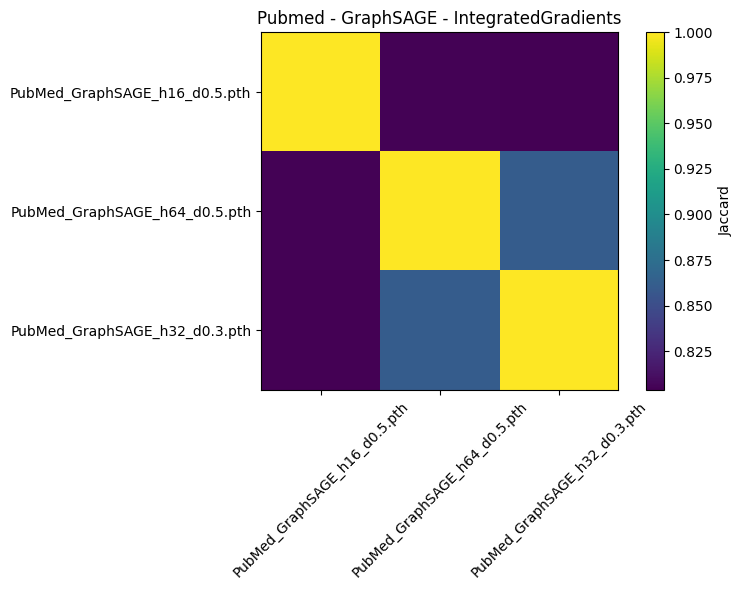

In [366]:
plot_pairwise_heatmap(
    pairwise_GraphSAGE_Pubmed_IntegratedGradients,
    "Pubmed - GraphSAGE - IntegratedGradients"
)

In [367]:
def plot_trajectory(df, title):

    labels = []

    values = []

    for _, row in df.iterrows():

        labels.append(
            f"{row['Model_A']} ↔ {row['Model_B']}"
        )

        values.append(
            row["Mean_Jaccard"]
        )

    plt.figure(figsize=(10,5))

    plt.plot(
        labels,
        values,
        marker="o"
    )

    plt.ylabel("Jaccard")
    plt.title(title)

    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

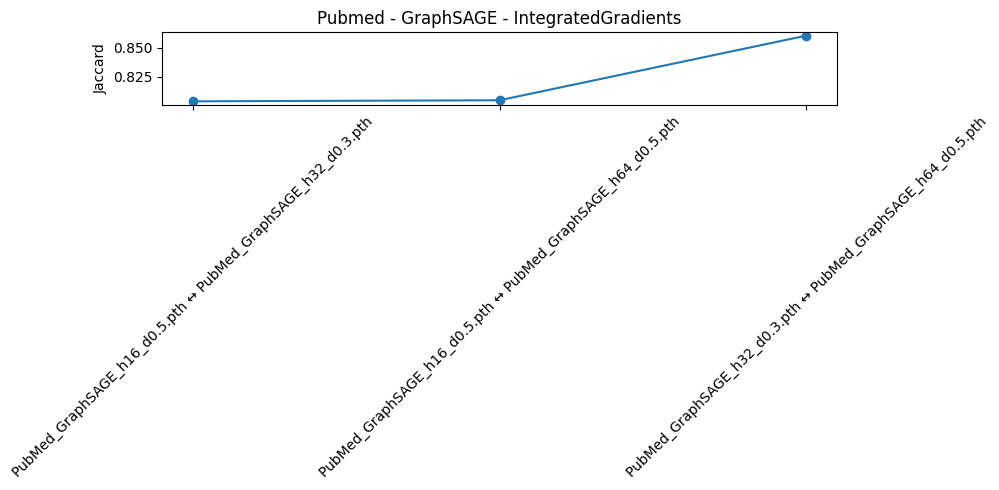

In [368]:
plot_trajectory(
    pairwise_GraphSAGE_Pubmed_IntegratedGradients,
    "Pubmed - GraphSAGE - IntegratedGradients"
)

In [409]:
import matplotlib.pyplot as plt

def plot_boxplot_by_model(
    pairwise_results_df,
    model_name
):

    df = pairwise_results_df[
        pairwise_results_df["Modelo"] == model_name
    ]

    explainers = df[
        "Explicador"
    ].unique()

    data = []

    for explainer in explainers:

        values = df[
            df["Explicador"] == explainer
        ][
            "Mean_Jaccard"
        ]

        data.append(values)

    plt.figure(figsize=(32,18))

    plt.boxplot(
        data,
        tick_labels=explainers
    )

    plt.ylabel("Pairwise Jaccard")

    plt.title(
        f"{model_name} Stability Distribution"
    )

    plt.grid(True)

    plt.show()

In [406]:
all_pairwise_rows = []

for explainer_name, df in all_results_pairwise.items():

    df = df.copy()

    df["Explicador"] = explainer_name

    # extrai arquitetura do nome
    df["Modelo"] = df["Model_A"].apply(

        lambda x: x.split("_")[1]
    )

    all_pairwise_rows.append(df)

all_pairwise_df = pd.concat(
    all_pairwise_rows,
    ignore_index=True
)

In [394]:
print(all_pairwise_df.columns)

Index(['Model_A', 'Model_B', 'Mean_Jaccard', 'Mean_Overlap', 'Mean_Spearman',
       'Std_Jaccard', 'Explicador', 'Modelo'],
      dtype='str')


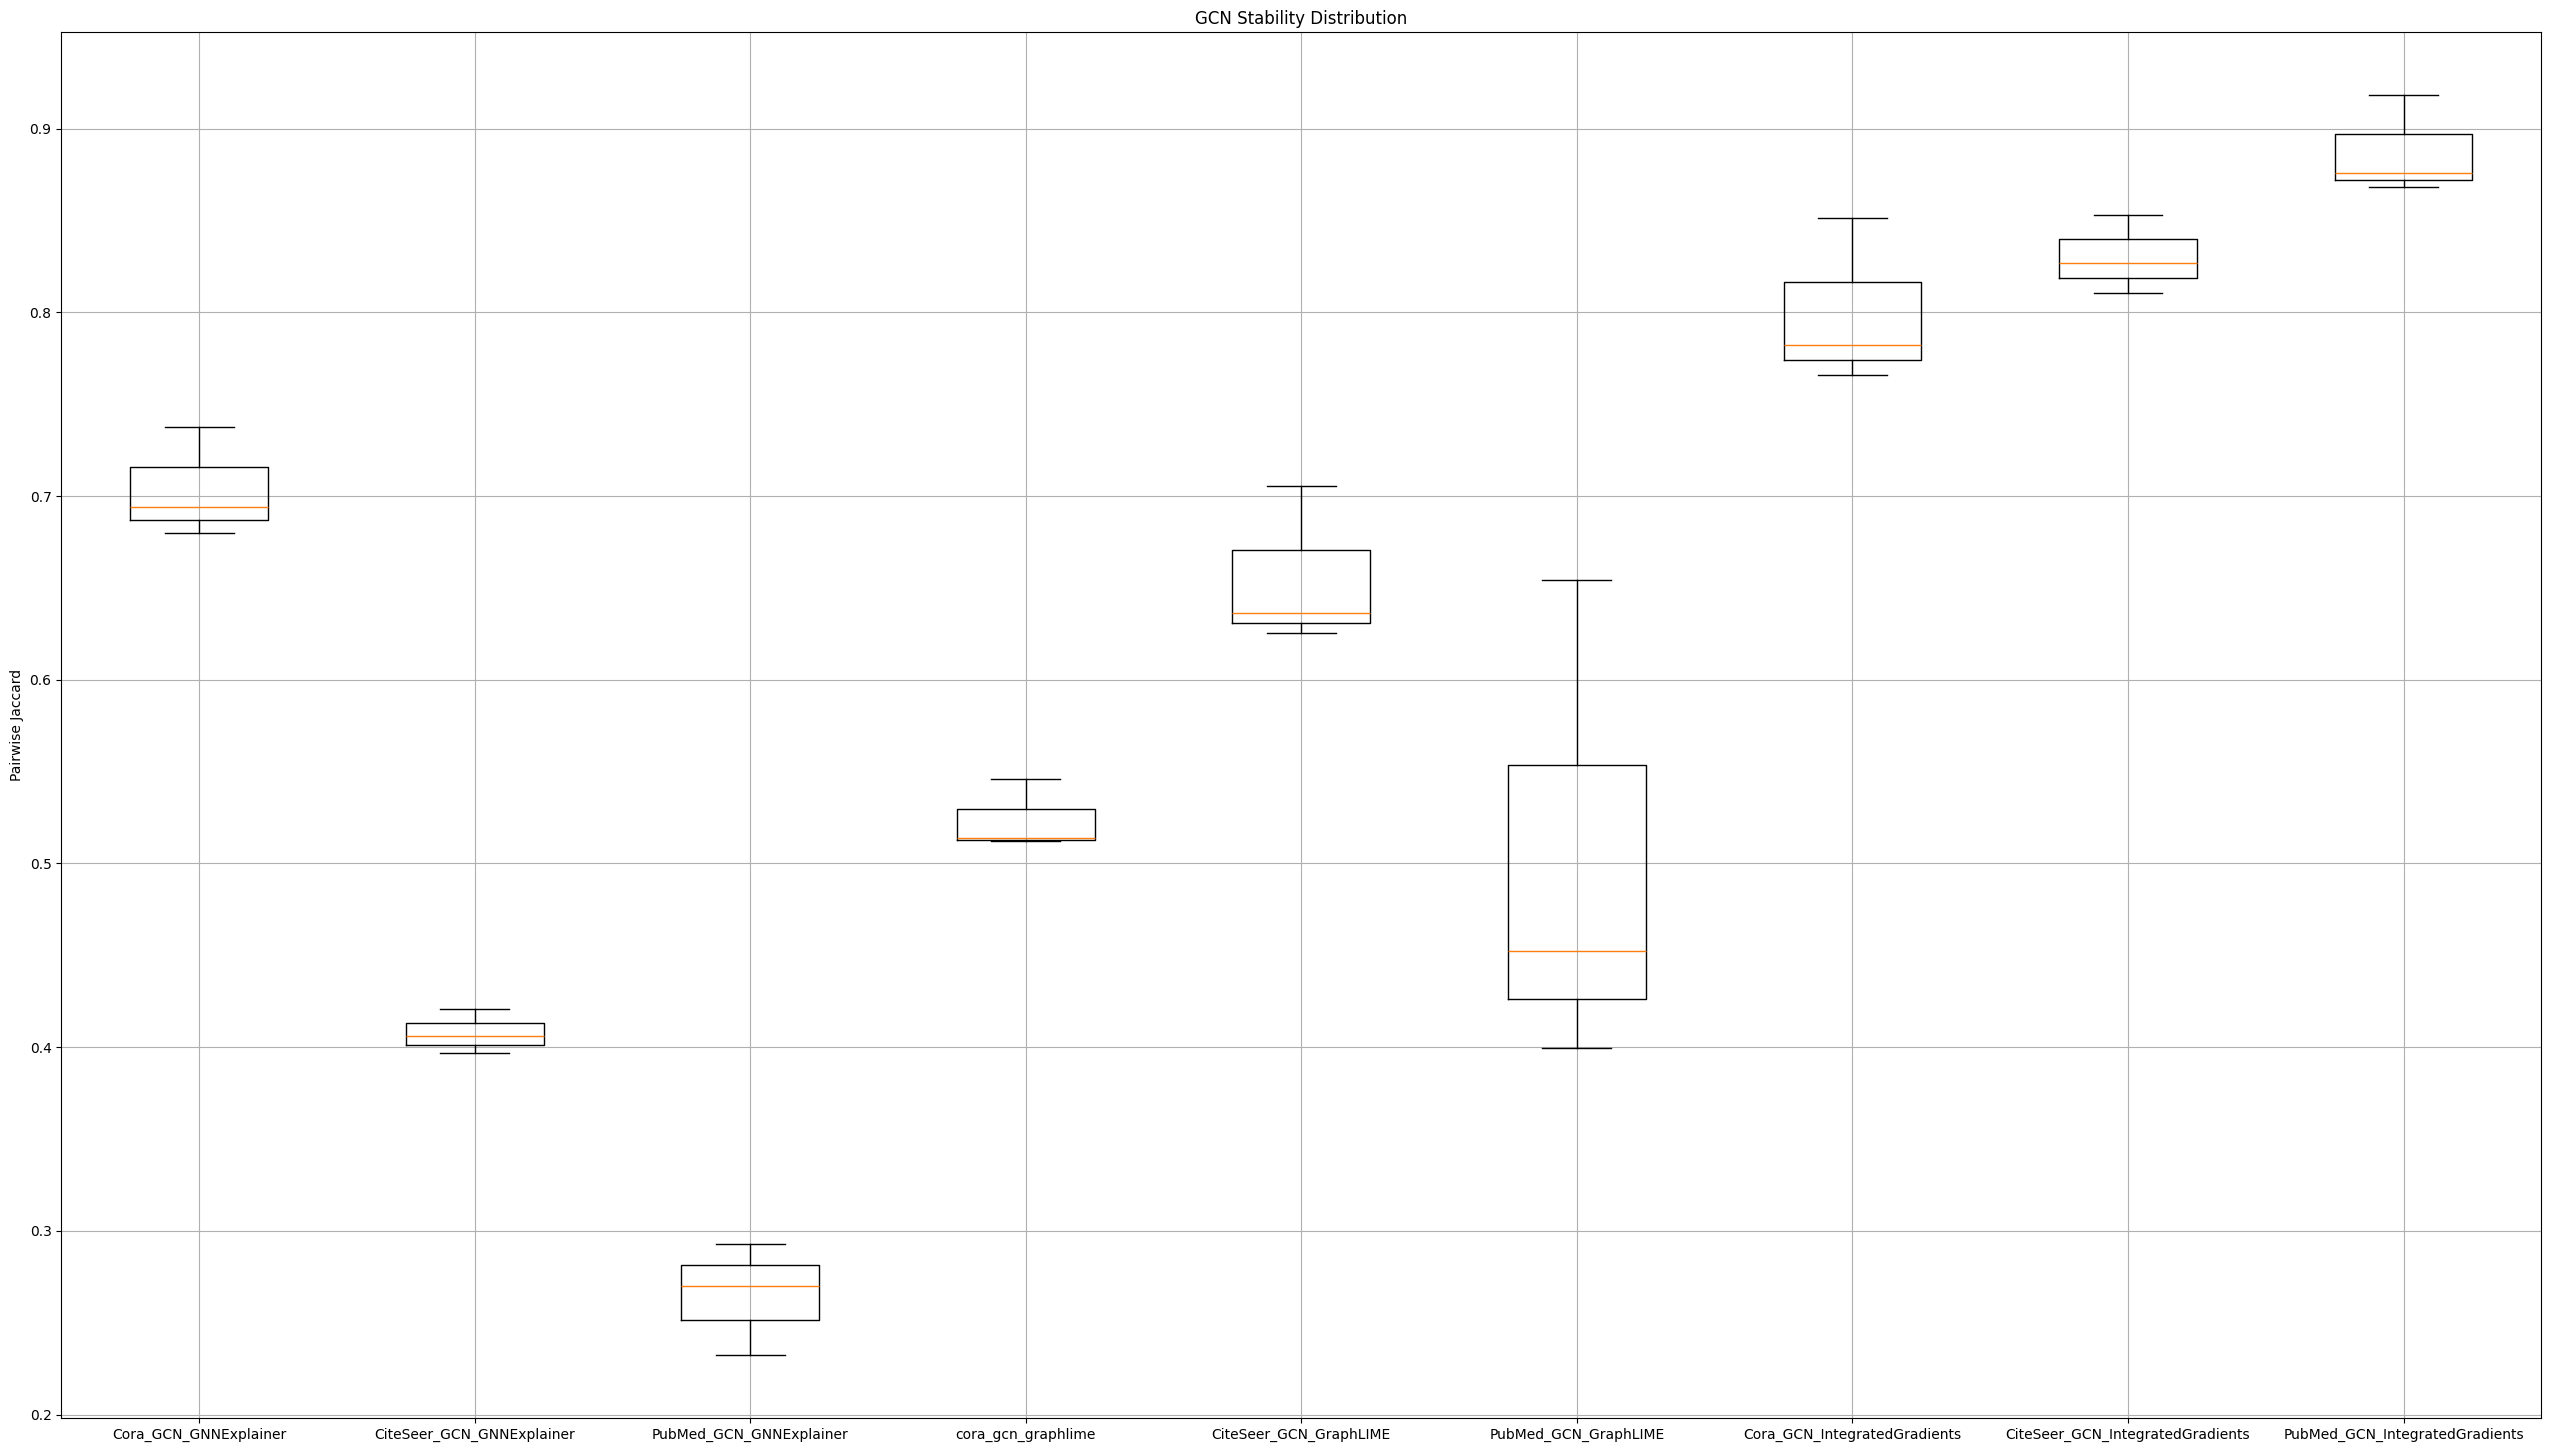

In [410]:
plot_boxplot_by_model(
    all_pairwise_df,
    "GCN"
)

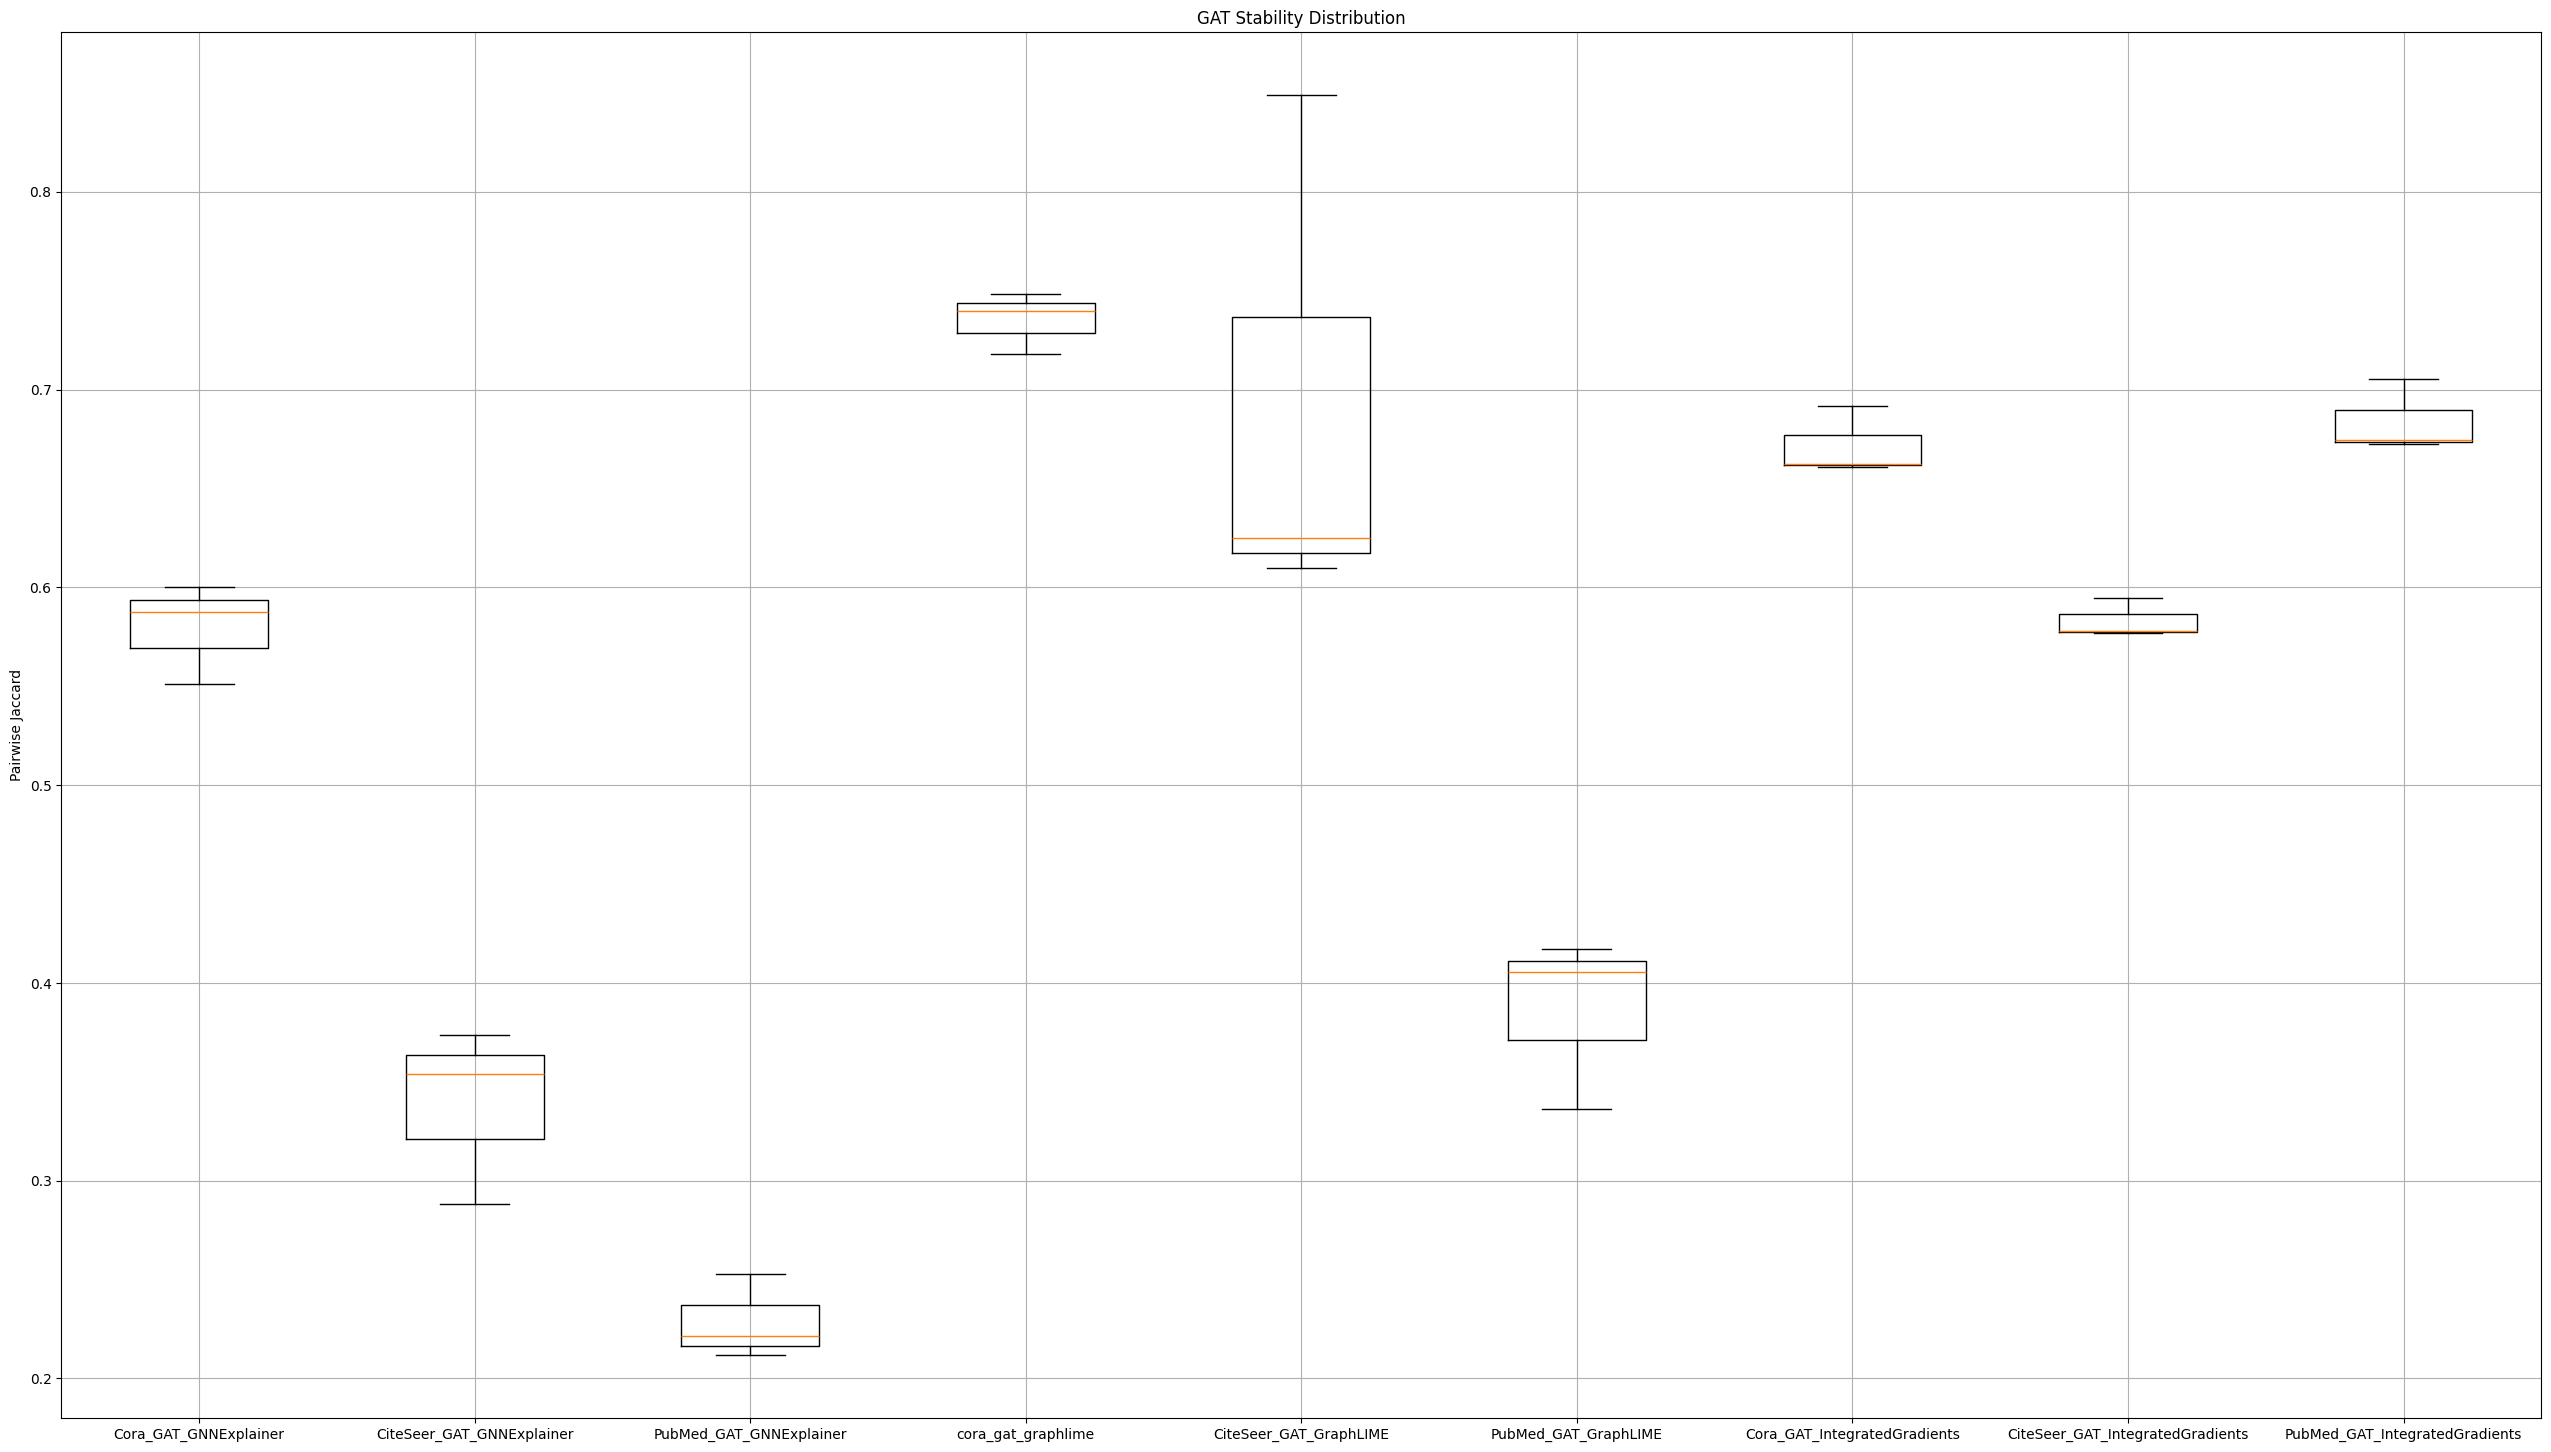

In [411]:
plot_boxplot_by_model(
    all_pairwise_df,
    "GAT"
)

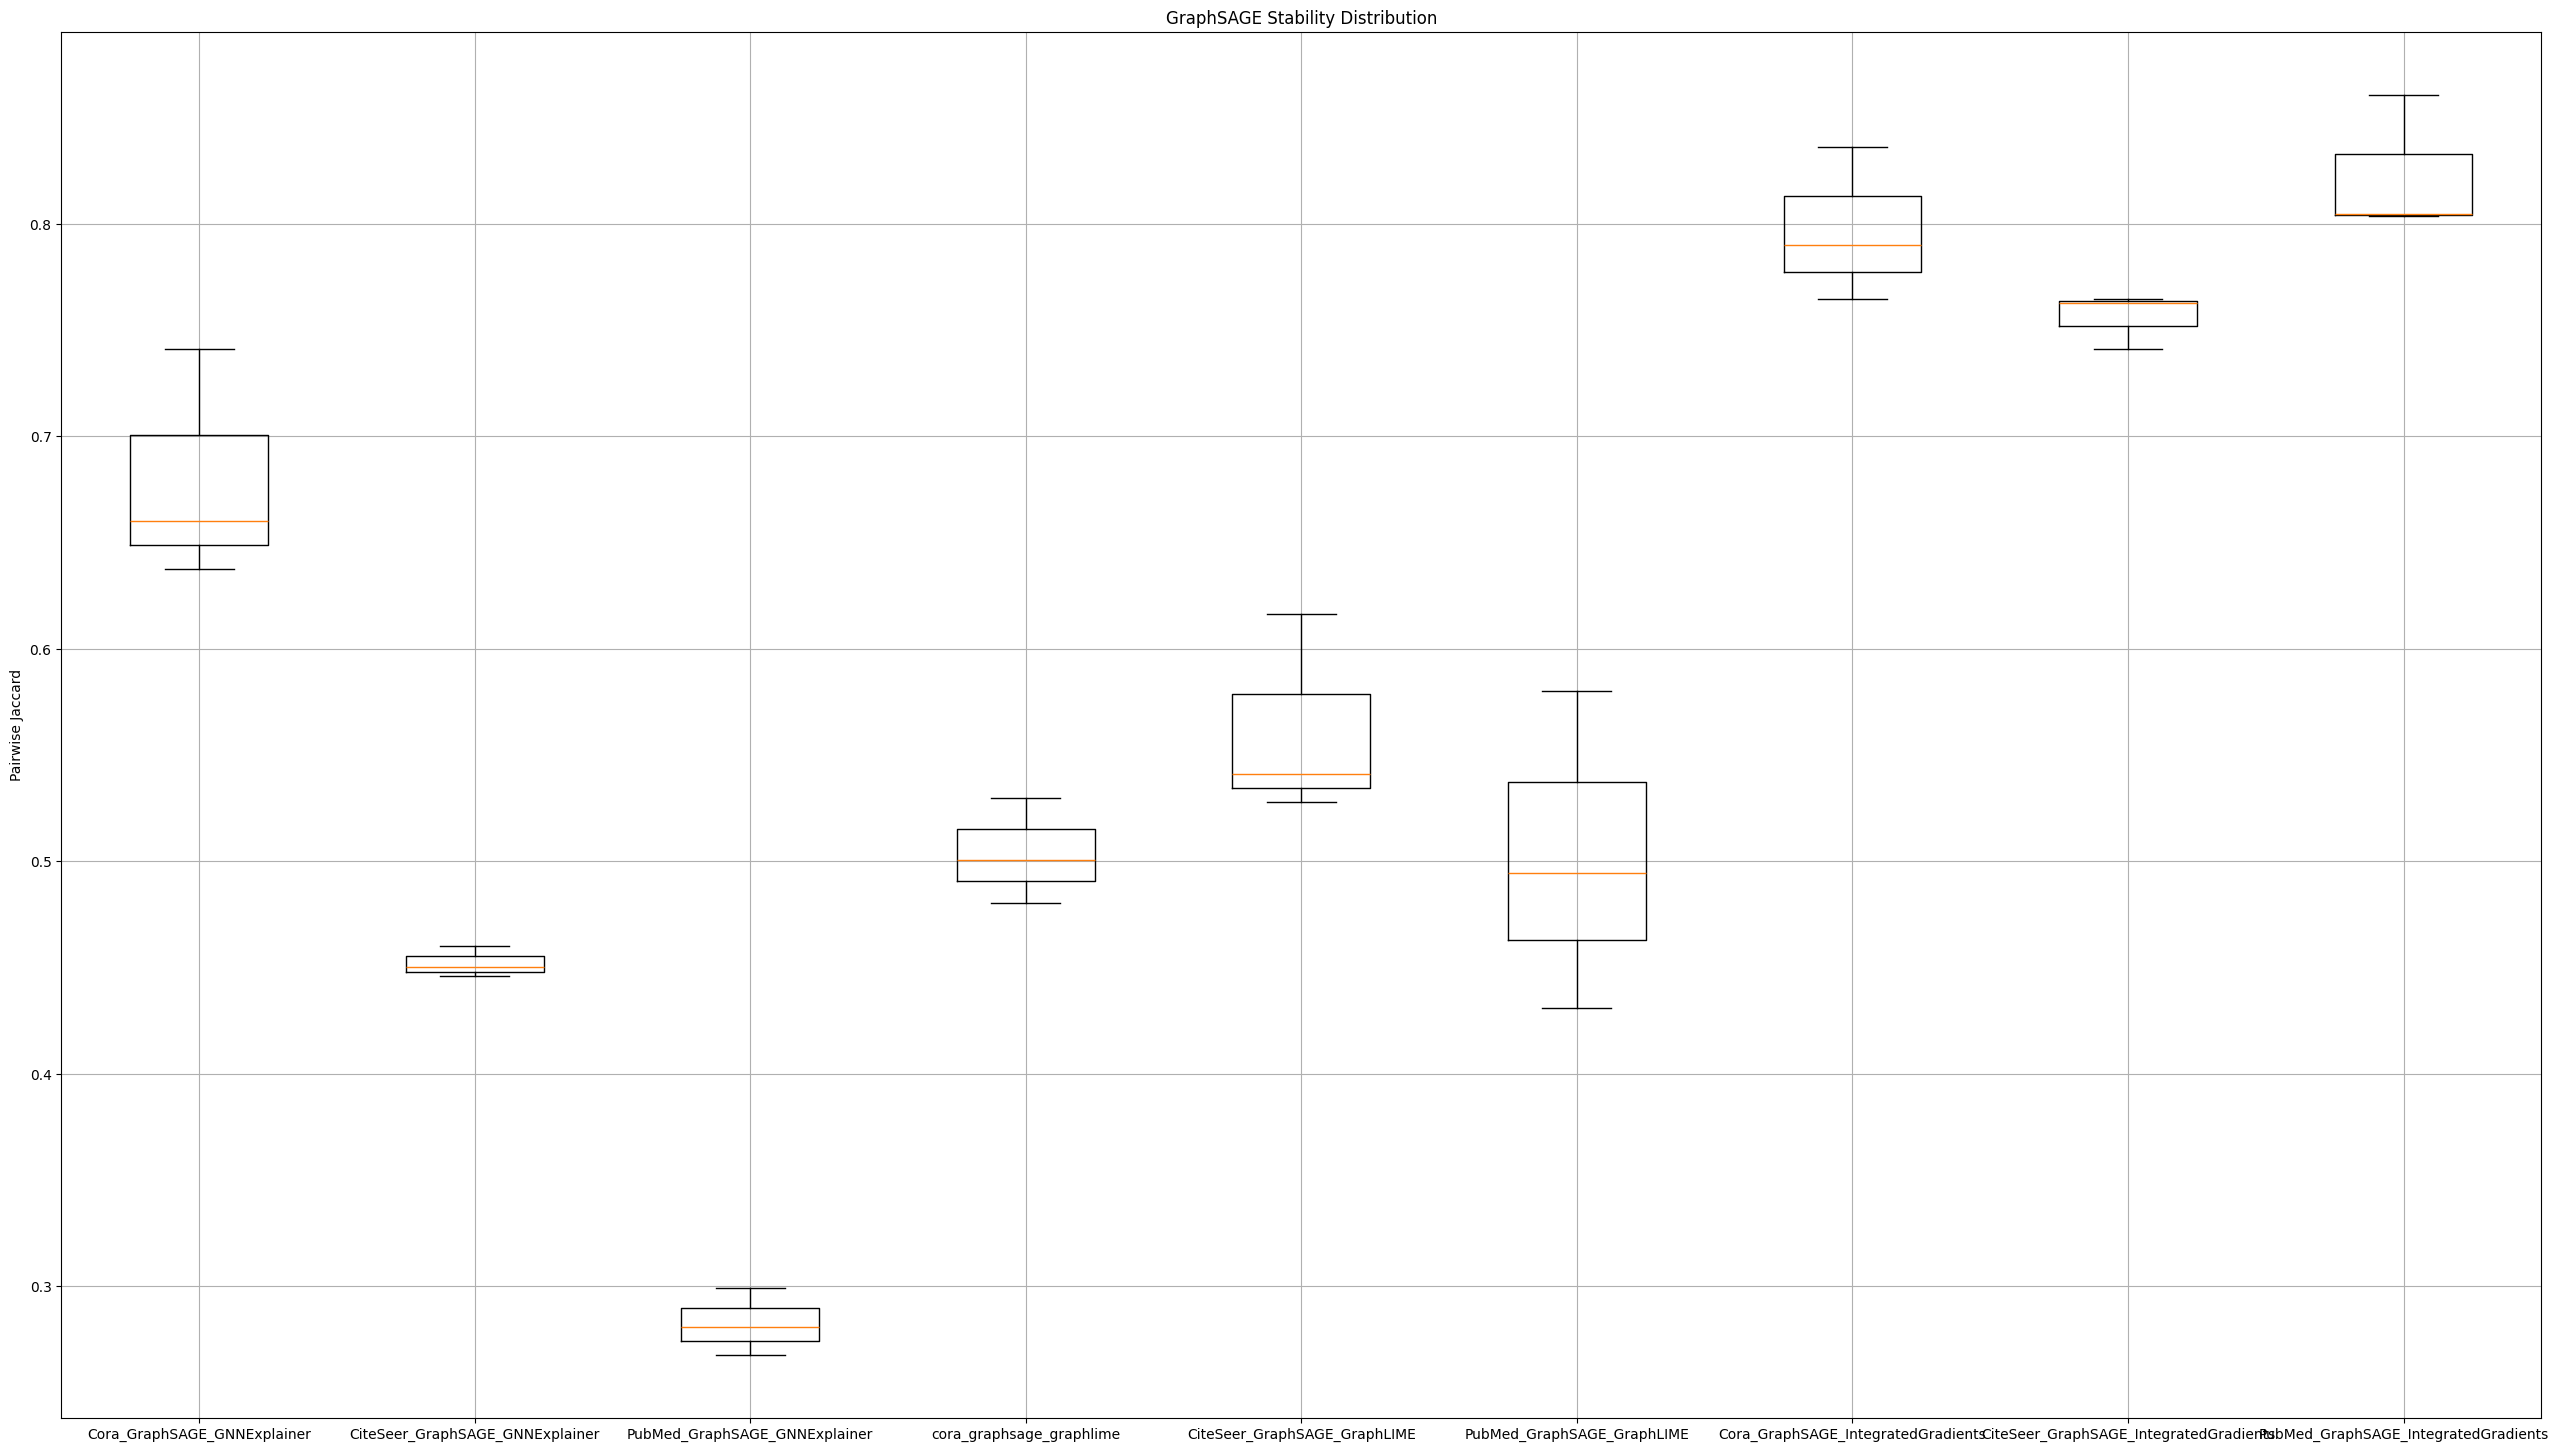

In [412]:
plot_boxplot_by_model(
    all_pairwise_df,
    "GraphSAGE"
)

In [413]:
import matplotlib.pyplot as plt
import numpy as np

def plot_improved_boxplots(
    pairwise_df,
    model_name
):

    datasets = pairwise_df["Dataset"].unique()

    for dataset in datasets:

        df = pairwise_df[
            (pairwise_df["Modelo"] == model_name) &
            (pairwise_df["Dataset"] == dataset)
        ]

        explainers = sorted(
            df["Explicador"].unique()
        )

        data = []
        means = []

        for explainer in explainers:

            values = df[
                df["Explicador"] == explainer
            ][
                "Mean_Jaccard"
            ].values

            data.append(values)
            means.append(
                np.mean(values)
            )

        plt.figure(figsize=(9,6))

        bp = plt.boxplot(
            data,
            tick_labels=explainers,
            patch_artist=True
        )

        # adicionar média
        for i, mean_val in enumerate(means):

            plt.scatter(
                i + 1,
                mean_val,
                marker="o",
                s=80,
                zorder=3,
                label="Mean" if i == 0 else ""
            )

        plt.ylabel("Pairwise Jaccard")
        plt.xlabel("Explainer")

        plt.title(
            f"{dataset} - {model_name} Stability Distribution"
        )

        plt.grid(
            axis="y",
            linestyle="--",
            alpha=0.6
        )

        plt.legend()

        plt.tight_layout()
        plt.show()

In [415]:
all_pairwise_rows = []

for explainer_name, df in all_results_pairwise.items():

    df = df.copy()

    df["Explicador"] = explainer_name

    df["Modelo"] = df["Model_A"].apply(
        lambda x: x.split("_")[1]
    )

    df["Dataset"] = df["Model_A"].apply(
        lambda x: x.split("_")[0]
    )

    all_pairwise_rows.append(df)

all_pairwise_df = pd.concat(
    all_pairwise_rows,
    ignore_index=True
)

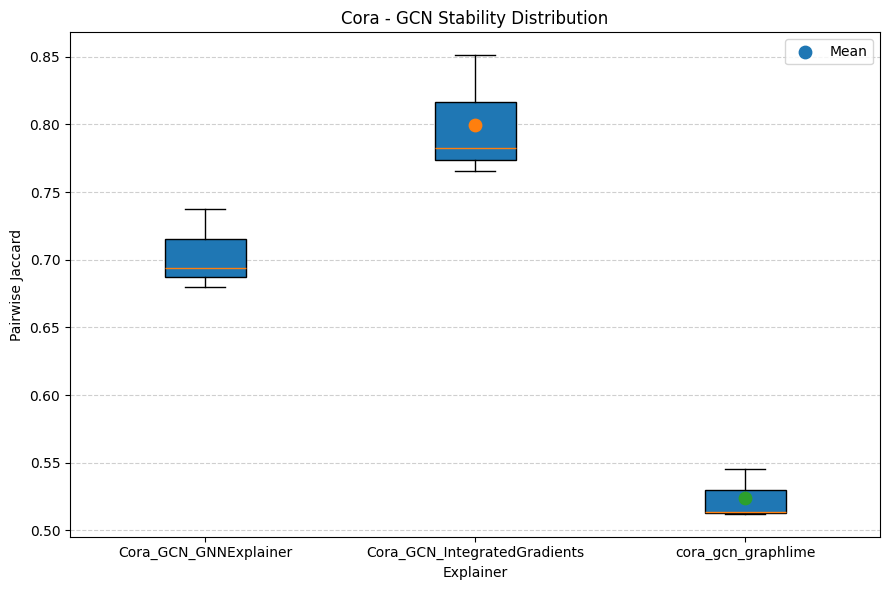

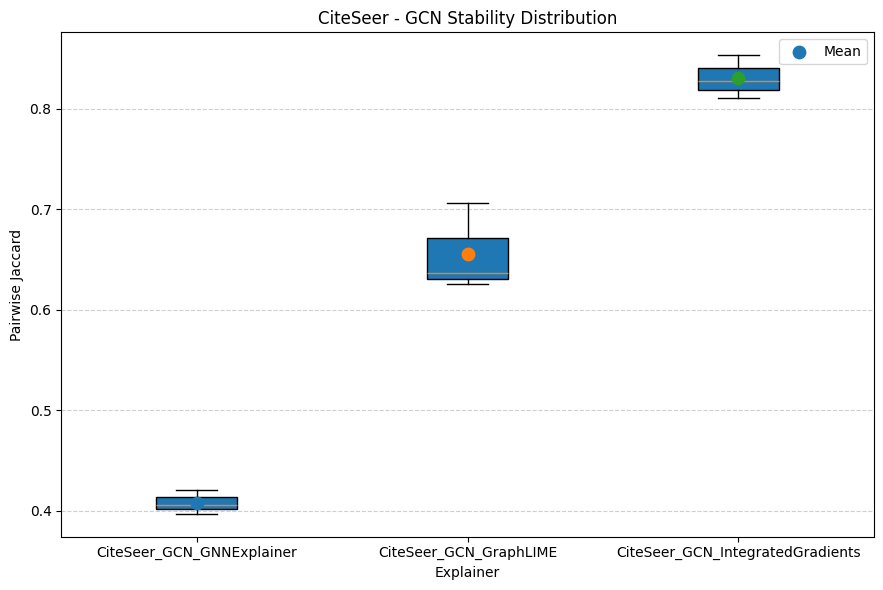

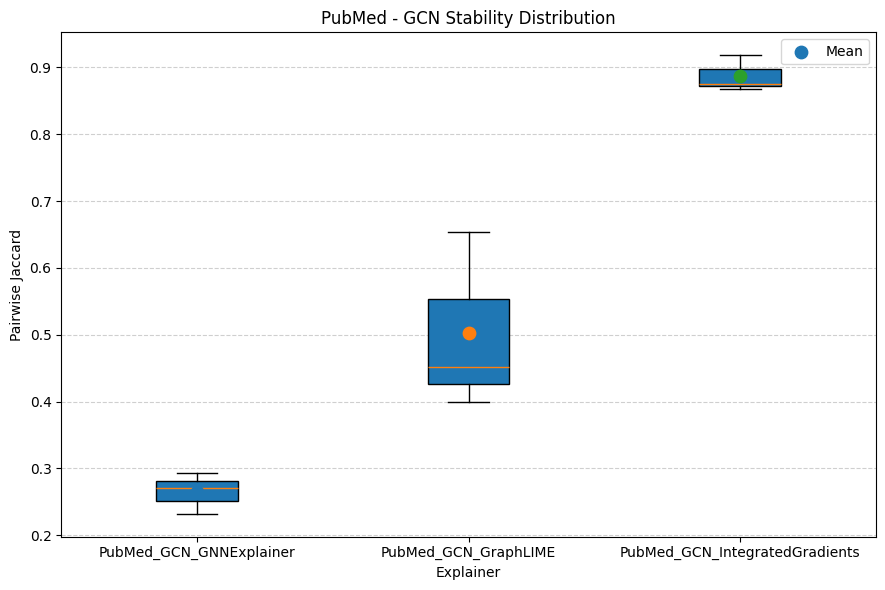

In [416]:
plot_improved_boxplots(
    all_pairwise_df,
    "GCN"
)

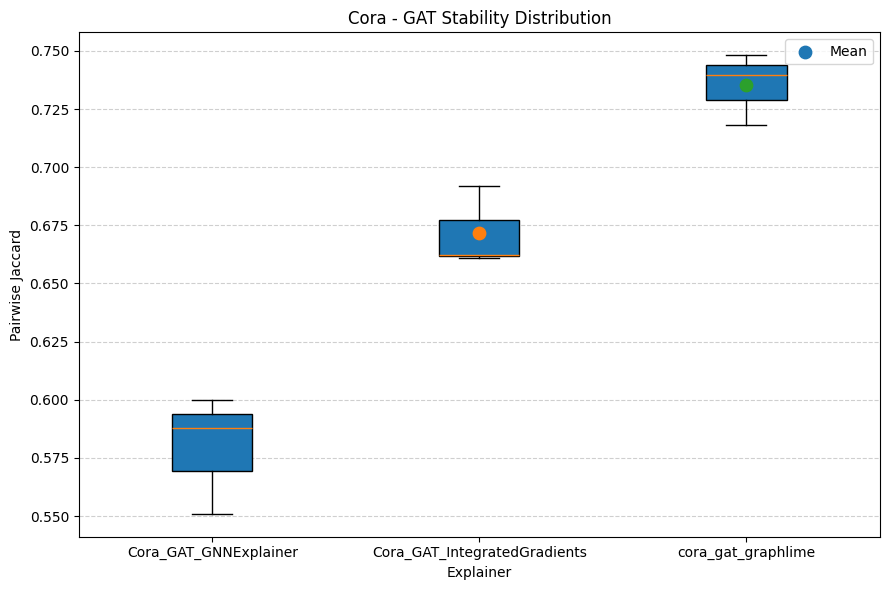

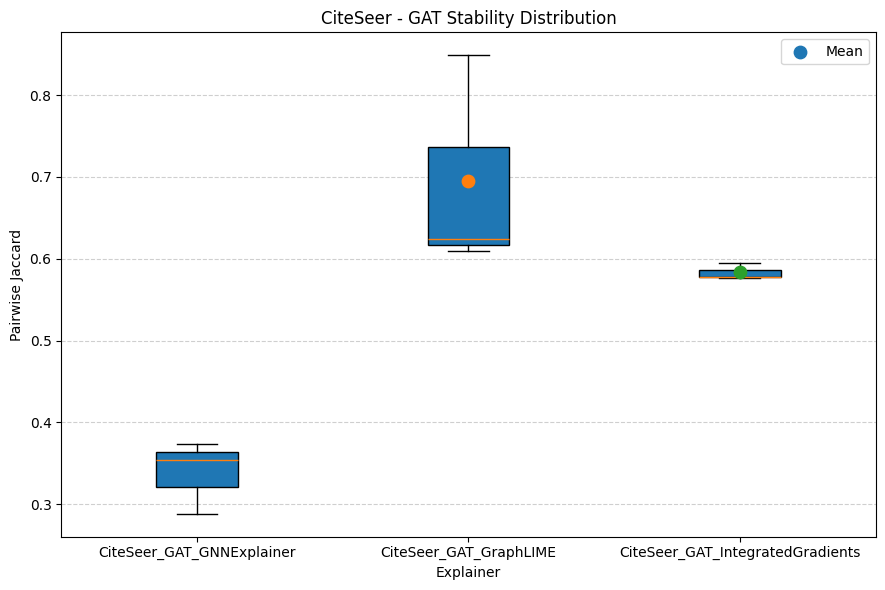

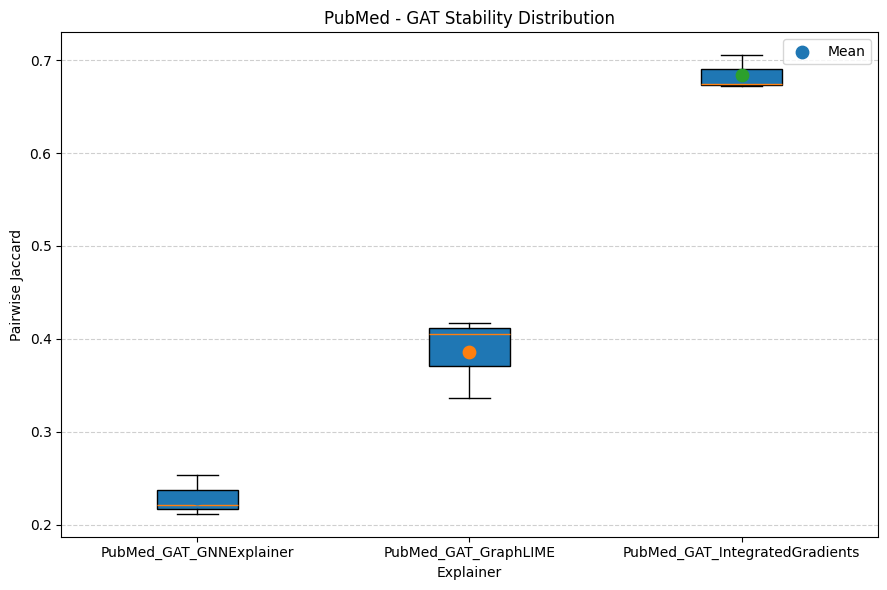

In [417]:
plot_improved_boxplots(
    all_pairwise_df,
    "GAT"
)

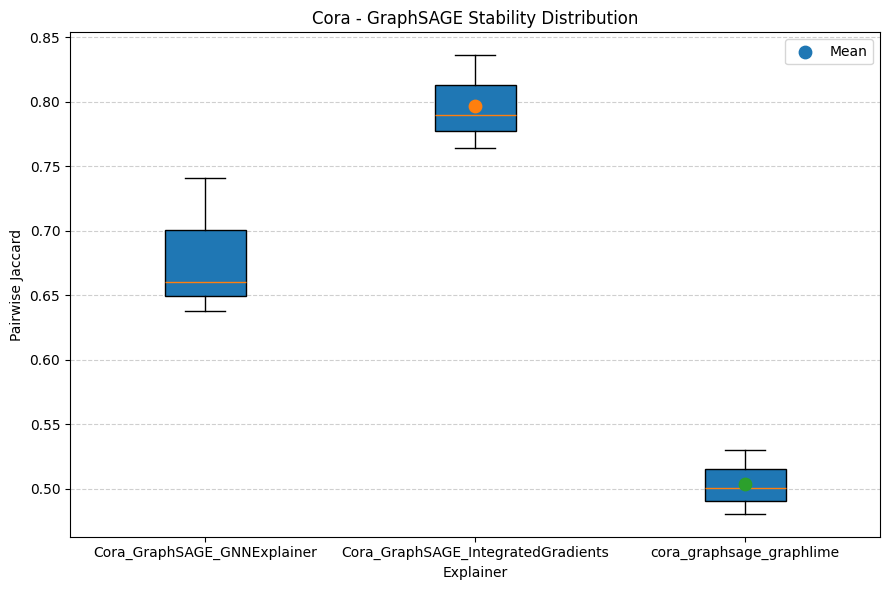

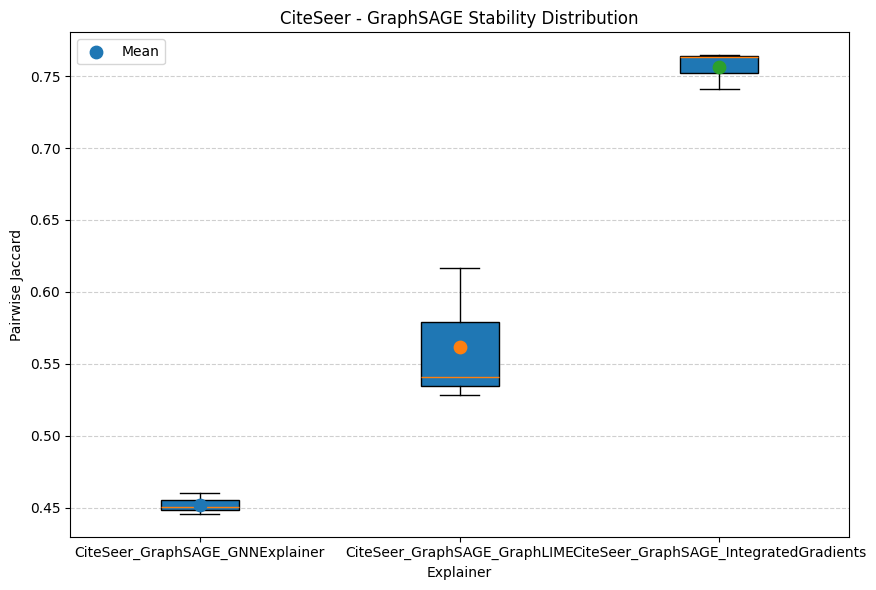

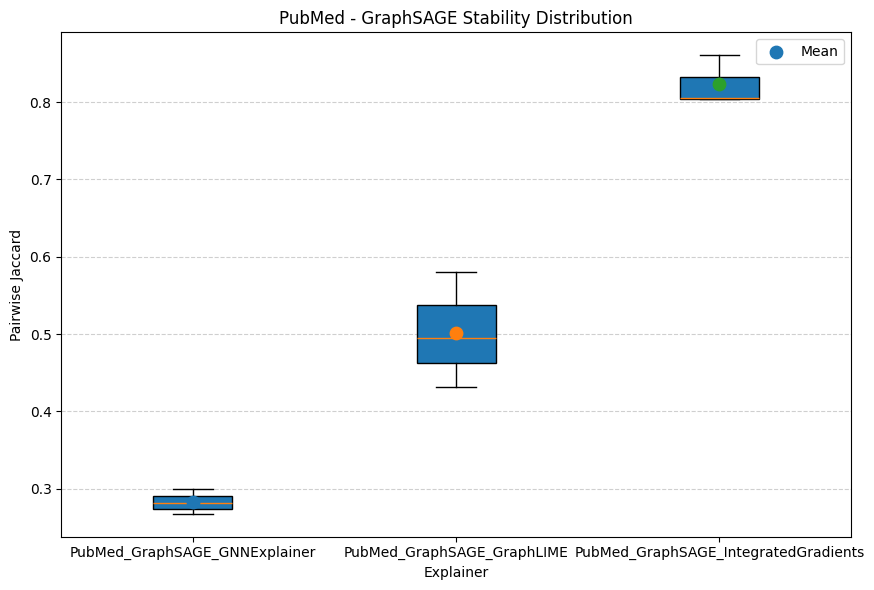

In [418]:
plot_improved_boxplots(
    all_pairwise_df,
    "GraphSAGE"
)

# Fidelidade V3

In [51]:
TOP_DIR = "C:\\faculdade\\Tabalho-Final-XAI\\top_models"

## Dados

In [224]:
PLdataset = Planetoid(root='data/Planetoid', name='Cora')
cora = PLdataset[0]

In [225]:
CSdataset = Planetoid(root='data/Planetoid',name='CiteSeer')
citeseer = CSdataset[0]


In [226]:
MPdataset = Planetoid(root='data/Planetoid',name='PubMed')
pubmed = MPdataset[0]

## Apoio

In [91]:


def fidelity_score(
    model,
    data,
    node_id,
    important_features
):

    model.eval()

    with torch.no_grad():

        logits = model(
            data.x,
            data.edge_index
        )

        probs = F.softmax(
            logits,
            dim=1
        )

        predicted_class = probs[
            node_id
        ].argmax().item()

        original_prob = probs[
            node_id,
            predicted_class
        ].item()

        x_masked = data.x.clone()

        x_masked[
            node_id,
            important_features
        ] = 0

        logits_masked = model(
            x_masked,
            data.edge_index
        )

        probs_masked = F.softmax(
            logits_masked,
            dim=1
        )

        masked_prob = probs_masked[
            node_id,
            predicted_class
        ].item()

        return (
            original_prob
            - masked_prob
        )

In [92]:


def fidelity(
    models,
    explanations,
    selected_nodes,
    data
):

    fidelity_results = []

    for node_id in selected_nodes:

        scores = []

        for model_name, model in models.items():

            important_features = explanations[
                model_name
            ][node_id]

            score = fidelity_score(

                model,

                data,

                node_id,

                important_features
            )

            scores.append(score)

        fidelity_results.append({

            "node": node_id,

            "mean_fidelity":
                np.mean(scores),

            "std_fidelity":
                np.std(scores),

            "min_fidelity":
                np.min(scores),

            "max_fidelity":
                np.max(scores)

        })

    return pd.DataFrame(
        fidelity_results
    )

In [96]:
def get_consensus_nodes(
    models,
    data,
    node_mask=None
):

    if node_mask is None:
        node_mask = data.test_mask

    predictions = []

    for model in models.values():

        model.eval()

        with torch.no_grad():

            out,l = model(
                data.x,
                data.edge_index
            )

            pred = out.argmax(dim=1)

        predictions.append(pred)

    predictions = torch.stack(predictions)

    candidate_nodes = node_mask.nonzero(
        as_tuple=True
    )[0]

    consensus_nodes = []

    for node_id in candidate_nodes:

        preds = predictions[
            :,
            node_id
        ]

        same_prediction = (
            preds == preds[0]
        ).all()

        correct_prediction = (
            preds[0]
            ==
            data.y[node_id]
        )

        if same_prediction and correct_prediction:

            consensus_nodes.append(
                node_id.item()
            )

    return consensus_nodes

In [94]:
def sample_consensus_nodes(
    models,
    data,
    n_nodes=20,
    seed=42,
    node_mask=None
):

    random.seed(seed)

    valid_nodes = get_consensus_nodes(
        models,
        data,
        node_mask
    )

    print(
        f"Nós elegíveis: {len(valid_nodes)}"
    )

    selected_nodes = random.sample(

        valid_nodes,

        min(
            n_nodes,
            len(valid_nodes)
        )
    )

    return selected_nodes

## seleção de nodes

In [231]:
SEED=42

### Cora

In [232]:
cora_GCN_models = load_saved_models(
    "Cora",
    "GCN"
)

In [233]:
cora_GAT_models = load_saved_models(
    "Cora",
    "GAT"
)

In [234]:
cora_GraphSAGE_models = load_saved_models(
    "Cora",
    "GraphSAGE"
)

In [235]:
selected_nodes_cora_GCN = sample_consensus_nodes(
    models=cora_GCN_models,
    data=cora,
    n_nodes=20,
    seed=SEED,
    node_mask=cora.test_mask
)
print(selected_nodes_cora_GCN)

Nós elegíveis: 771
[2541, 1836, 1735, 2688, 2054, 1999, 1970, 1871, 2682, 1825, 2595, 2687, 2422, 1809, 2486, 2241, 1743, 1740, 1815, 1965]


In [236]:
selected_nodes_cora_GAT = sample_consensus_nodes(
    models=cora_GAT_models,
    data=cora,
    n_nodes=20,
    seed=SEED,
    node_mask=cora.test_mask
)
print(selected_nodes_cora_GAT)

Nós elegíveis: 752
[2575, 1846, 1737, 2069, 2027, 1985, 1881, 1831, 2633, 2457, 1816, 2514, 2267, 1746, 1744, 1822, 1978, 2002, 2393, 2526]


In [237]:
selected_nodes_cora_GraphSAGE = sample_consensus_nodes(
    models=cora_GraphSAGE_models,
    data=cora,
    n_nodes=20,
    seed=SEED,
    node_mask=cora.test_mask
)
print(selected_nodes_cora_GraphSAGE)

Nós elegíveis: 770
[2550, 1842, 1737, 2693, 2061, 2005, 1975, 1874, 2685, 1829, 2610, 2691, 2430, 1814, 2493, 2251, 1746, 1744, 1820, 1969]


### CiteSeer

In [238]:
citeseer_GCN_models = load_saved_models(
    "CiteSeer",
    "GCN"
)

In [239]:
citeseer_GAT_models = load_saved_models(
    "CiteSeer",
    "GAT"
)

In [240]:
citeseer_GraphSAGE_models = load_saved_models(
    "CiteSeer",
    "GraphSAGE"
)

In [241]:
selected_nodes_citeseer_GCN = sample_consensus_nodes(
    models=citeseer_GCN_models,
    data=citeseer,
    n_nodes=20,
    seed=SEED,
    node_mask=cora.test_mask
)
print(selected_nodes_citeseer_GCN)

Nós elegíveis: 620
[1905, 1745, 2187, 2140, 2103, 1951, 1887, 2615, 1860, 2687, 2404, 1758, 1755, 1870, 2097, 2118, 2546, 2704, 1752, 2640]


In [242]:
selected_nodes_citeseer_GAT = sample_consensus_nodes(
    models=citeseer_GAT_models,
    data=citeseer,
    n_nodes=20,
    seed=SEED,
    node_mask=cora.test_mask
)
print(selected_nodes_citeseer_GAT)

Nós elegíveis: 575
[1928, 1753, 2226, 2180, 2139, 1973, 1908, 2684, 1880, 2452, 1762, 1760, 1889, 2124, 2159, 2614, 1755, 2707, 2094, 2449]


In [243]:
selected_nodes_citeseer_GraphSAGE = sample_consensus_nodes(
    models=citeseer_GraphSAGE_models,
    data=citeseer,
    n_nodes=20,
    seed=SEED,
    node_mask=cora.test_mask
)
print(selected_nodes_citeseer_GraphSAGE)

Nós elegíveis: 641
[1887, 1741, 2164, 2109, 2071, 1932, 1867, 2594, 1845, 2655, 2383, 1754, 1752, 1855, 2066, 2091, 2512, 2673, 1745, 2613]


### PubMed

In [244]:
pubmed_GCN_models = load_saved_models(
    "PubMed",
    "GCN"
)

In [245]:
pubmed_GAT_models = load_saved_models(
    "PubMed",
    "GAT"
)

In [246]:
pubmed_GraphSAGE_models = load_saved_models(
    "PubMed",
    "GraphSAGE"
)

In [247]:
selected_nodes_pubmed_GCN = sample_consensus_nodes(
    models=pubmed_GCN_models,
    data=pubmed,
    n_nodes=20,
    seed=SEED,
    node_mask=cora.test_mask
)
print(selected_nodes_pubmed_GCN)

Nós elegíveis: 739
[2597, 1856, 1742, 2094, 2039, 2011, 1889, 1843, 2644, 2465, 1828, 2525, 2289, 1751, 1747, 1834, 2003, 2023, 2403, 2543]


In [248]:
selected_nodes_pubmed_GAT = sample_consensus_nodes(
    models=pubmed_GAT_models,
    data=pubmed,
    n_nodes=20,
    seed=SEED,
    node_mask=cora.test_mask
)
print(selected_nodes_pubmed_GAT)

Nós elegíveis: 712
[2623, 1864, 1747, 2105, 2052, 2022, 1901, 1852, 2675, 2484, 1833, 2551, 2305, 1756, 1753, 1839, 2015, 2036, 2420, 2570]


In [249]:
selected_nodes_pubmed_GraphSAGE = sample_consensus_nodes(
    models=pubmed_GraphSAGE_models,
    data=pubmed,
    n_nodes=20,
    seed=SEED,
    node_mask=cora.test_mask
)
print(selected_nodes_pubmed_GraphSAGE)

Nós elegíveis: 711
[2632, 1868, 1748, 2116, 2061, 2031, 1907, 1856, 2678, 2495, 1836, 2566, 2317, 1758, 1756, 1842, 2024, 2045, 2437, 2581]


## GNNExplainer

### Cora

#### GCN

In [288]:
cora_gcn_models = load_saved_models(
    "Cora",
    "GCN"
)

In [289]:
cora_gcn_gnne_exp = load_explanations(
    dataset="Cora",
    model="GCN",
    explainer="GNNExplainer",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

In [290]:
fidelity_cora_gcnV2 = fidelity(

    models=cora_gcn_models,

    explanations=cora_gcn_gnne_exp,

    selected_nodes=selected_nodes_cora_GCN,

    data=cora
)

In [291]:
fidelity_cora_gcnV2

,node,mean_fidelity,std_fidelity,min_fidelity,max_fidelity
0,2541,0.175255,0.096237,0.105523,0.311341
1,1836,0.001879,0.000443,0.001416,0.002476
2,1735,0.227553,0.043232,0.166590,0.262050
3,2688,0.127930,0.019514,0.109472,0.154925
4,2054,0.000556,0.000118,0.000391,0.000660
5,1999,0.388230,0.020076,0.364013,0.413173
6,1970,0.070626,0.013556,0.058020,0.089439
7,1871,0.126401,0.015363,0.111030,0.147384
8,2682,0.146066,0.022686,0.120208,0.175442
9,1825,0.022972,0.002171,0.020083,0.025316


#### GAT

In [292]:
cora_gat_models = load_saved_models(
    "Cora",
    "GAT"
)

In [293]:
cora_gat_gnne_exp = load_explanations(
    dataset="Cora",
    model="GAT",
    explainer="GNNExplainer",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

In [294]:
fidelity_cora_gatV2 = fidelity(

    models=cora_gat_models,

    explanations=cora_gat_gnne_exp,

    selected_nodes=selected_nodes_cora_GAT,

    data=cora
)

In [295]:
fidelity_cora_gatV2

,node,mean_fidelity,std_fidelity,min_fidelity,max_fidelity
0,2575,0.277621,0.071604,0.176897,0.337014
1,1846,-0.006464,0.015337,-0.025111,0.012453
2,1737,0.000458,0.000294,0.000169,0.000861
3,2069,0.241233,0.061775,0.175515,0.323943
4,2027,0.176471,0.018603,0.157995,0.201930
5,1985,0.061183,0.016030,0.049621,0.083851
6,1881,0.000289,0.000266,0.000046,0.000659
7,1831,0.173081,0.015481,0.153749,0.191647
8,2633,0.008240,0.005244,0.001880,0.014725
9,2457,0.310002,0.170417,0.086387,0.499658


#### GraphSAGE

In [296]:
cora_graphsage_models = load_saved_models(
    "Cora",
    "GraphSAGE"
)

In [297]:
cora_graphsage_models

{'Cora_GraphSAGE_h32_d0.3.pth': GraphSAGE(
   (conv1): SAGEConv(1433, 32, aggr=mean)
   (conv2): SAGEConv(32, 7, aggr=mean)
 ),
 'Cora_GraphSAGE_h32_d0.7.pth': GraphSAGE(
   (conv1): SAGEConv(1433, 32, aggr=mean)
   (conv2): SAGEConv(32, 7, aggr=mean)
 ),
 'Cora_GraphSAGE_h64_d0.3.pth': GraphSAGE(
   (conv1): SAGEConv(1433, 64, aggr=mean)
   (conv2): SAGEConv(64, 7, aggr=mean)
 )}

In [298]:
cora_graphsage_gnne_exp = load_explanations(
    dataset="Cora",
    model="GraphSAGE",
    explainer="GNNExplainer",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

In [299]:
cora_graphsage_gnne_exp.keys()

dict_keys(['Cora_GraphSAGE_h32_d0.3.pth', 'Cora_GraphSAGE_h32_d0.7.pth', 'Cora_GraphSAGE_h64_d0.3.pth'])

In [300]:
fidelity_cora_graphsageV2 = fidelity(

    models=cora_graphsage_models,

    explanations=cora_graphsage_gnne_exp,

    selected_nodes=selected_nodes_cora_GraphSAGE,

    data=cora
)

In [301]:
fidelity_cora_graphsageV2

,node,mean_fidelity,std_fidelity,min_fidelity,max_fidelity
0,2550,0.184894,0.011233,0.175732,0.200714
1,1842,0.311075,0.155038,0.105677,0.480211
2,1737,0.002766,0.001958,0.000283,0.005069
3,2693,0.190654,0.115037,0.028001,0.274870
4,2061,0.004542,0.002852,0.000518,0.006795
5,2005,0.221575,0.064151,0.166913,0.311613
6,1975,0.193602,0.042779,0.139704,0.244349
7,1874,0.198897,0.159522,0.047639,0.419479
8,2685,0.030861,0.017921,0.005522,0.044002
9,1829,0.227712,0.045258,0.168597,0.278517


### CiteSeer

#### GCN

In [302]:
cite_seer_gcn_models = load_saved_models(
    "CiteSeer",
    "GCN"
)

In [303]:
cite_seer_gcn_gnne_exp = load_explanations(
    dataset="CiteSeer",
    model="GCN",
    explainer="GNNExplainer",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

In [304]:
fidelity_cite_seer_gcnV2 = fidelity(

    models=cite_seer_gcn_models,

    explanations=cite_seer_gcn_gnne_exp,

    selected_nodes=selected_nodes_citeseer_GCN,

    data=citeseer
)

In [305]:
fidelity_cite_seer_gcnV2

,node,mean_fidelity,std_fidelity,min_fidelity,max_fidelity
0,1905,0.325474,0.020949,0.295864,0.341121
1,1745,0.012646,0.003733,0.007570,0.016442
2,2187,0.016187,0.009321,0.005176,0.027970
3,2140,0.010346,0.004552,0.005099,0.016200
4,2103,0.131817,0.066862,0.069959,0.224681
5,1951,0.131455,0.095612,0.047675,0.265259
6,1887,0.056658,0.030023,0.016146,0.087922
7,2615,0.442600,0.057028,0.361990,0.485127
8,1860,0.242922,0.035908,0.192562,0.273758
9,2687,0.363031,0.018718,0.339234,0.384969


#### GAT

In [306]:
cite_seer_gat_models = load_saved_models(
    "CiteSeer",
    "GAT"
)

In [307]:
cite_seer_gat_gnne_exp = load_explanations(
    dataset="CiteSeer",
    model="GAT",
    explainer="GNNExplainer",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

In [308]:
cite_seer_gat_gnne_exp.keys()

dict_keys(['CiteSeer_GAT_h32_d0.4_heads4.pth', 'CiteSeer_GAT_h32_d0.6_heads8.pth', 'CiteSeer_GAT_h8_d0.4_heads4.pth'])

In [309]:
fidelity_cite_seer_gatV2 = fidelity(

    models=cite_seer_gat_models,

    explanations=cite_seer_gat_gnne_exp,

    selected_nodes=selected_nodes_citeseer_GAT,

    data=citeseer
)

In [310]:
fidelity_cite_seer_gatV2

,node,mean_fidelity,std_fidelity,min_fidelity,max_fidelity
0,1928,0.211996,0.178774,0.083379,0.464808
1,1753,0.000288,0.000203,0.000004,0.000470
2,2226,0.005250,0.000567,0.004737,0.006041
3,2180,0.007183,0.004983,0.000341,0.012068
4,2139,0.021709,0.009755,0.012396,0.035180
5,1973,0.293243,0.156523,0.078634,0.447522
6,1908,0.392217,0.154206,0.176144,0.525819
7,2684,0.000624,0.000600,0.000190,0.001473
8,1880,0.411652,0.157509,0.189004,0.528837
9,2452,0.023796,0.020606,0.007527,0.052868


#### GraphSAGE

In [311]:
citeseer_graphsage_models = load_saved_models(
    "CiteSeer",
    "GraphSAGE"
)

In [312]:
citeseer_graphsage_gnne_exp = load_explanations(
    dataset="CiteSeer",
    model="GraphSAGE",
    explainer="GNNExplainer",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

In [313]:
fidelity_cite_seer_graphsageV2 = fidelity(

    models=citeseer_graphsage_models,

    explanations=citeseer_graphsage_gnne_exp,

    selected_nodes=selected_nodes_citeseer_GraphSAGE,

    data=citeseer
)

In [314]:
fidelity_cite_seer_graphsageV2

,node,mean_fidelity,std_fidelity,min_fidelity,max_fidelity
0,1887,0.259279,0.003202,0.255050,0.262794
1,1741,0.462354,0.059022,0.378886,0.504643
2,2164,0.531417,0.028445,0.503595,0.570491
3,2109,0.217100,0.055292,0.143434,0.276644
4,2071,0.776282,0.015679,0.754197,0.789045
5,1932,0.068516,0.077244,0.012635,0.177746
6,1867,0.239809,0.054346,0.170749,0.303549
7,2594,0.393925,0.020736,0.364867,0.411869
8,1845,0.015496,0.010755,0.004887,0.030240
9,2655,0.150554,0.026989,0.112835,0.174468


### PubMed

#### GCN

In [315]:
pubmed_gcn_models = load_saved_models(
    "PubMed",
    "GCN"
)

In [316]:
pubmed_gcn_gnne_exp = load_explanations(
    dataset="PubMed",
    model="GCN",
    explainer="GNNExplainer",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

In [317]:
fidelity_pubmed_gcnV2 = fidelity(

    models=pubmed_gcn_models,

    explanations=pubmed_gcn_gnne_exp,

    selected_nodes=selected_nodes_pubmed_GCN,

    data=pubmed
)

In [318]:
fidelity_pubmed_gcnV2

,node,mean_fidelity,std_fidelity,min_fidelity,max_fidelity
0,2597,0.403557,0.039201,0.348517,0.436826
1,1856,0.128206,0.028899,0.088352,0.155974
2,1742,0.135368,0.042535,0.083602,0.187785
3,2094,0.017280,0.003245,0.012741,0.020138
4,2039,0.099990,0.013475,0.081264,0.112410
5,2011,0.155512,0.051640,0.083436,0.201740
6,1889,0.148473,0.065146,0.063789,0.222240
7,1843,0.012132,0.007053,0.003662,0.020928
8,2644,0.005161,0.001649,0.003932,0.007492
9,2465,0.098791,0.015588,0.086175,0.120754


#### GAT

In [319]:
pubmed_gat_models = load_saved_models(
    "PubMed",
    "GAT"
)

In [320]:
pubmed_gat_gnne_exp = load_explanations(
    dataset="PubMed",
    model="GAT",
    explainer="GNNExplainer",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

In [321]:
fidelity_pubmed_gatV2 = fidelity(

    models=pubmed_gat_models,

    explanations=pubmed_gat_gnne_exp,

    selected_nodes=selected_nodes_pubmed_GAT,

    data=pubmed
)

In [322]:
fidelity_pubmed_gatV2

,node,mean_fidelity,std_fidelity,min_fidelity,max_fidelity
0,2623,0.014861,0.005493,0.007487,0.020664
1,1864,0.009862,0.002667,0.006529,0.013058
2,1747,0.067289,0.020589,0.051138,0.096346
3,2105,0.085335,0.031763,0.040743,0.112313
4,2052,0.000618,0.000316,0.000173,0.000883
5,2022,0.076432,0.010764,0.062678,0.088957
6,1901,0.025736,0.009629,0.012415,0.034845
7,1852,0.013560,0.005784,0.006809,0.020936
8,2675,0.155966,0.084054,0.077945,0.272644
9,2484,0.001974,0.001261,0.001003,0.003755


#### GraphSAGE

In [323]:
pubmed_graphsage_models = load_saved_models(
    "PubMed",
    "GraphSAGE"
)

In [324]:
pubmed_graphsage_gnne_exp = load_explanations(
    dataset="PubMed",
    model="GraphSAGE",
    explainer="GNNExplainer",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

In [325]:
fidelity_pubmed_graphsageV2 = fidelity(

    models=pubmed_graphsage_models,

    explanations=pubmed_graphsage_gnne_exp,

    selected_nodes=selected_nodes_pubmed_GraphSAGE,

    data=pubmed
)

In [326]:
fidelity_pubmed_graphsageV2

,node,mean_fidelity,std_fidelity,min_fidelity,max_fidelity
0,2632,0.050136,0.022219,0.024760,0.078872
1,1868,0.006130,0.002281,0.002944,0.008156
2,1748,0.099187,0.053640,0.044568,0.172086
3,2116,0.053060,0.024418,0.028254,0.086268
4,2061,0.015431,0.005145,0.009445,0.022006
5,2031,0.018829,0.002860,0.014802,0.021162
6,1907,0.055096,0.035148,0.013111,0.099132
7,1856,0.063272,0.015805,0.041336,0.077956
8,2678,0.066045,0.049755,0.029867,0.136400
9,2495,0.080530,0.015476,0.064102,0.101268


## GraphLIME

### Cora

#### GCN

In [327]:
cora_gcn_models = load_saved_models(
    "Cora",
    "GCN"
)

In [328]:
cora_gcn_graphlime_exp = load_explanations(
    dataset="Cora",
    model="GCN",
    explainer="GraphLIME",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

In [329]:
fidelity_cora_gcn_graphlimeV2 = fidelity(

    models=cora_gcn_models,

    explanations=explanations_graphlime_cora_GCN_conf,

    selected_nodes=selected_nodes_cora_GCN,

    data=cora
)

In [330]:
fidelity_cora_gcn_graphlimeV2

,node,mean_fidelity,std_fidelity,min_fidelity,max_fidelity
0,2541,0.014356,0.006126,0.009993,0.023020
1,1836,0.000153,0.000048,0.000096,0.000213
2,1735,0.000000,0.000000,0.000000,0.000000
3,2688,-0.003797,0.001774,-0.006216,-0.002011
4,2054,0.000000,0.000000,0.000000,0.000000
5,1999,0.022664,0.003164,0.018242,0.025473
6,1970,0.000173,0.000131,0.000000,0.000319
7,1871,-0.000742,0.001372,-0.002665,0.000439
8,2682,0.039905,0.012406,0.027320,0.056785
9,1825,-0.000059,0.000381,-0.000427,0.000467


#### GAT

In [331]:
cora_gat_models = load_saved_models(
    "Cora",
    "GAT"
)

In [332]:
cora_gat_graphlime_exp = load_explanations(
    dataset="Cora",
    model="GAT",
    explainer="GraphLIME",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

In [333]:
fidelity_cora_gat_graphlimeV2 = fidelity(

    models=cora_gat_models,

    explanations=explanations_graphlime_cora_GAT_conf,

    selected_nodes=selected_nodes_cora_GAT,

    data=cora
)

In [334]:
fidelity_cora_gat_graphlimeV2

,node,mean_fidelity,std_fidelity,min_fidelity,max_fidelity
0,2575,-0.021027,0.016982,-0.045008,-7.921934e-03
1,1846,0.000000,0.000000,0.000000,0.000000e+00
2,1737,0.000000,0.000000,0.000000,0.000000e+00
3,2069,-0.019948,0.024101,-0.053679,1.157790e-03
4,2027,0.006343,0.008970,0.000000,1.902854e-02
5,1985,0.017373,0.009141,0.006260,2.864856e-02
6,1881,0.000000,0.000000,0.000000,0.000000e+00
7,1831,-0.018762,0.003416,-0.021954,-1.402575e-02
8,2633,-0.000024,0.000035,-0.000073,1.192093e-07
9,2457,-0.004330,0.005200,-0.011678,-3.877282e-04


#### GraphSAGE

In [335]:
cora_graphsage_models = load_saved_models(
    "Cora",
    "GraphSAGE"
)

In [336]:
cora_graphsage_graphlime_exp = load_explanations(
    dataset="Cora",
    model="GraphSAGE",
    explainer="GraphLIME",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

In [337]:
fidelity_cora_graphsage_graphlimeV2 = fidelity(

    models=cora_graphsage_models,

    explanations=explanations_graphlime_cora_GraphSAGE_conf,

    selected_nodes=selected_nodes_cora_GraphSAGE,

    data=cora
)

In [338]:
fidelity_cora_graphsage_graphlimeV2

,node,mean_fidelity,std_fidelity,min_fidelity,max_fidelity
0,2550,0.085744,0.049050,0.016467,0.123431
1,1842,0.008562,0.012109,0.000000,0.025686
2,1737,0.000000,0.000000,0.000000,0.000000
3,2693,0.011371,0.006625,0.002344,0.018059
4,2061,0.000000,0.000000,0.000000,0.000000
5,2005,0.011547,0.016330,0.000000,0.034641
6,1975,0.000000,0.000000,0.000000,0.000000
7,1874,0.053831,0.076129,0.000000,0.161494
8,2685,0.000057,0.000752,-0.000775,0.001046
9,1829,-0.040870,0.029307,-0.067273,0.000000


### CiteSeer

#### GCN

In [339]:
cite_seer_gcn_models = load_saved_models(
    "CiteSeer",
    "GCN"
)

In [340]:
cite_seer_gcn_graphlime_exp = load_explanations(
    dataset="CiteSeer",
    model="GCN",
    explainer="GraphLIME",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

In [341]:
fidelity_cite_seer_gcn_graphlimeV2 = fidelity(

    models=cite_seer_gcn_models,

    explanations=explanations_graphlime_citeseer_GCN_conf,

    selected_nodes=selected_nodes_citeseer_GCN,

    data=citeseer
)

In [342]:
fidelity_cite_seer_gcn_graphlimeV2

,node,mean_fidelity,std_fidelity,min_fidelity,max_fidelity
0,1905,0.000000,0.000000,0.000000,0.000000
1,1745,0.000000,0.000000,0.000000,0.000000
2,2187,0.000197,0.000318,-0.000030,0.000648
3,2140,0.000766,0.000198,0.000598,0.001044
4,2103,0.038225,0.005880,0.030406,0.044588
5,1951,0.000000,0.000000,0.000000,0.000000
6,1887,-0.000656,0.000377,-0.001051,-0.000148
7,2615,0.022186,0.031375,0.000000,0.066557
8,1860,0.003658,0.008000,-0.005499,0.013990
9,2687,0.028589,0.010004,0.020874,0.042717


#### GAT

In [343]:
cite_seer_gat_models = load_saved_models(
    "CiteSeer",
    "GAT"
)

In [344]:
cite_seer_gat_graphlime_exp = load_explanations(
    dataset="CiteSeer",
    model="GAT",
    explainer="GraphLIME",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

In [345]:
fidelity_cite_seer_gat_graphlimeV2 = fidelity(

    models=cite_seer_gat_models,

    explanations=explanations_graphlime_citeseer_GAT_conf,

    selected_nodes=selected_nodes_citeseer_GAT,

    data=citeseer
)

In [346]:
fidelity_cite_seer_gat_graphlimeV2

,node,mean_fidelity,std_fidelity,min_fidelity,max_fidelity
0,1928,0.000000,0.000000,0.000000,0.000000
1,1753,-0.000004,0.000026,-0.000038,0.000026
2,2226,0.000000,0.000000,0.000000,0.000000
3,2180,0.000000,0.000000,0.000000,0.000000
4,2139,0.000000,0.000000,0.000000,0.000000
5,1973,0.000000,0.000000,0.000000,0.000000
6,1908,0.013171,0.016347,0.000000,0.036210
7,2684,0.000090,0.000100,0.000015,0.000232
8,1880,0.039789,0.022166,0.009744,0.062555
9,2452,0.000000,0.000000,0.000000,0.000000


#### GraphSAGE

In [347]:
citeseer_graphsage_models = load_saved_models(
    "CiteSeer",
    "GraphSAGE"
)

In [348]:
citeseer_graphsage_graphlime_exp = load_explanations(
    dataset="CiteSeer",
    model="GraphSAGE",
    explainer="GraphLIME",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

In [349]:
fidelity_cite_seer_graphsage_graphlimeV2 = fidelity(

    models=citeseer_graphsage_models,

    explanations=explanations_graphlime_citeseer_GraphSAGE_conf,

    selected_nodes=selected_nodes_citeseer_GraphSAGE,

    data=citeseer
)

In [350]:
fidelity_cite_seer_graphsage_graphlimeV2

,node,mean_fidelity,std_fidelity,min_fidelity,max_fidelity
0,1887,0.013062,0.016422,-0.007791,0.032343
1,1741,0.000000,0.000000,0.000000,0.000000
2,2164,0.000000,0.000000,0.000000,0.000000
3,2109,0.060556,0.015369,0.038847,0.072311
4,2071,0.000000,0.000000,0.000000,0.000000
5,1932,-0.000700,0.001343,-0.002579,0.000480
6,1867,0.020382,0.016150,-0.001381,0.037263
7,2594,0.063932,0.036693,0.034637,0.115673
8,1845,-0.000176,0.000065,-0.000266,-0.000118
9,2655,0.002925,0.004137,0.000000,0.008776


### PubMed

#### GCN

In [351]:
pubmed_gcn_models = load_saved_models(
    "PubMed",
    "GCN"
)

In [352]:
pubmed_gcn_graphlime_exp = load_explanations(
    dataset="PubMed",
    model="GCN",
    explainer="GraphLIME",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

In [353]:
fidelity_pubmed_gcn_graphlimeV2 = fidelity(

    models=pubmed_gcn_models,

    explanations=explanations_graphlime_pubmed_GCN_conf,

    selected_nodes=selected_nodes_pubmed_GCN,

    data=pubmed
)

In [354]:
fidelity_pubmed_gcn_graphlimeV2

,node,mean_fidelity,std_fidelity,min_fidelity,max_fidelity
0,2597,0.025578,0.021893,-0.005292,0.043071
1,1856,0.000000,0.000000,0.000000,0.000000
2,1742,0.037669,0.010020,0.024717,0.049124
3,2094,0.000973,0.000067,0.000882,0.001041
4,2039,0.001870,0.000341,0.001408,0.002219
5,2011,-0.001341,0.001896,-0.004022,0.000000
6,1889,0.000000,0.000000,0.000000,0.000000
7,1843,0.000000,0.000000,0.000000,0.000000
8,2644,0.000000,0.000000,0.000000,0.000000
9,2465,0.049247,0.019705,0.023896,0.071943


#### GAT

In [355]:
pubmed_gat_models = load_saved_models(
    "PubMed",
    "GAT"
)

In [356]:
pubmed_gat_graphlime_exp = load_explanations(
    dataset="PubMed",
    model="GAT",
    explainer="GraphLIME",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

In [357]:
fidelity_pubmed_gat_graphlimeV2 = fidelity(

    models=pubmed_gat_models,

    explanations=explanations_graphlime_pubmed_GAT_conf,

    selected_nodes=selected_nodes_pubmed_GAT,

    data=pubmed
)

In [358]:
fidelity_pubmed_gat_graphlimeV2

,node,mean_fidelity,std_fidelity,min_fidelity,max_fidelity
0,2623,0.000000,0.000000,0.000000,0.000000
1,1864,0.000850,0.001880,-0.000624,0.003503
2,1747,0.021329,0.016928,-0.002606,0.033722
3,2105,-0.006439,0.009292,-0.019294,0.002353
4,2052,0.000089,0.000012,0.000075,0.000105
5,2022,-0.011409,0.002952,-0.015380,-0.008309
6,1901,-0.000003,0.000004,-0.000008,0.000000
7,1852,0.006904,0.001724,0.005135,0.009241
8,2675,-0.005278,0.005718,-0.013339,-0.000695
9,2484,0.001681,0.000659,0.001163,0.002611


#### GraphSAGE

In [359]:
pubmed_graphsage_models = load_saved_models(
    "PubMed",
    "GraphSAGE"
)

In [360]:
pubmed_graphsage_graphlime_exp = load_explanations(
    dataset="PubMed",
    model="GraphSAGE",
    explainer="GraphLIME",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

In [361]:
fidelity_pubmed_graphsage_graphlimeV2 = fidelity(

    models=pubmed_graphsage_models,

    explanations=explanations_graphlime_pubmed_GraphSAGE_conf,

    selected_nodes=selected_nodes_pubmed_GraphSAGE,

    data=pubmed
)

In [362]:
fidelity_pubmed_graphsage_graphlimeV2

,node,mean_fidelity,std_fidelity,min_fidelity,max_fidelity
0,2632,0.019481,0.014102,-0.000094,0.032570
1,1868,-0.000006,0.000005,-0.000012,0.000000
2,1748,0.001810,0.001297,0.000150,0.003317
3,2116,0.001162,0.000130,0.001067,0.001346
4,2061,-0.000318,0.003226,-0.004418,0.003464
5,2031,-0.000859,0.000132,-0.001045,-0.000753
6,1907,0.000000,0.000000,0.000000,0.000000
7,1856,0.024997,0.020270,0.000000,0.049649
8,2678,0.001207,0.004074,-0.003069,0.006689
9,2495,0.057400,0.026229,0.020476,0.078932


## Integrated Gradients

### Cora

#### GCN

In [250]:
cora_gcn_models = load_saved_models(
    "Cora",
    "GCN"
)

In [251]:
cora_gcn_integrated_gradients_exp = load_explanations(
    dataset="Cora",
    model="GCN",
    explainer="IntegratedGradients",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

In [252]:
fidelity_cora_gcn_integrated_gradients = fidelity(

    models=cora_gcn_models,

    explanations=cora_gcn_integrated_gradients_exp,

    selected_nodes=selected_nodes_cora_GCN,

    data=cora
)

In [253]:
fidelity_cora_gcn_integrated_gradients

,node,mean_fidelity,std_fidelity,min_fidelity,max_fidelity
0,2541,0.179105,0.096803,0.110253,0.316005
1,1836,0.004223,0.000384,0.003729,0.004667
2,1735,0.276154,0.017150,0.262050,0.300294
3,2688,0.185002,0.032595,0.158114,0.230872
4,2054,0.000665,0.000090,0.000553,0.000773
5,1999,0.391694,0.018602,0.367799,0.413173
6,1970,0.070887,0.013235,0.059461,0.089439
7,1871,0.134382,0.019022,0.108638,0.154012
8,2682,0.146577,0.025257,0.116382,0.178200
9,1825,0.023419,0.002685,0.020083,0.026657


#### GAT

In [254]:
cora_gat_models = load_saved_models(
    "Cora",
    "GAT"
)

In [255]:
cora_gat_integrated_gradients_exp = load_explanations(
    dataset="Cora",
    model="GAT",
    explainer="IntegratedGradients",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

In [256]:
fidelity_cora_gat_integrated_gradients = fidelity(

    models=cora_gat_models,

    explanations=cora_gat_integrated_gradients_exp,

    selected_nodes=selected_nodes_cora_GAT,

    data=cora
)

In [257]:
fidelity_cora_gat_integrated_gradients

,node,mean_fidelity,std_fidelity,min_fidelity,max_fidelity
0,2575,0.352168,0.037276,0.309082,0.400015
1,1846,0.003391,0.021681,-0.024760,0.027989
2,1737,0.001523,0.000810,0.000420,0.002343
3,2069,0.249369,0.063826,0.186541,0.336908
4,2027,0.204954,0.002991,0.201930,0.209028
5,1985,0.125148,0.030715,0.084510,0.158753
6,1881,0.000303,0.000262,0.000044,0.000662
7,1831,0.181439,0.026130,0.156846,0.217622
8,2633,0.061431,0.017589,0.036650,0.075694
9,2457,0.395341,0.125671,0.242763,0.550558


#### GraphSAGE

In [258]:
cora_graphsage_models = load_saved_models(
    "Cora",
    "GraphSAGE"
)

In [259]:
cora_graphsage_integrated_gradients_exp = load_explanations(
    dataset="Cora",
    model="GraphSAGE",
    explainer="IntegratedGradients",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

In [260]:
fidelity_cora_graphsage_integrated_gradients = fidelity(

    models=cora_graphsage_models,

    explanations=cora_graphsage_integrated_gradients_exp,

    selected_nodes=selected_nodes_cora_GraphSAGE,

    data=cora
)

In [261]:
fidelity_cora_graphsage_integrated_gradients

,node,mean_fidelity,std_fidelity,min_fidelity,max_fidelity
0,2550,0.224029,0.033695,0.193244,0.270921
1,1842,0.404951,0.112014,0.249986,0.510895
2,1737,0.027769,0.017595,0.003566,0.044873
3,2693,0.200678,0.111288,0.043724,0.289222
4,2061,0.006395,0.004572,0.000607,0.011784
5,2005,0.264344,0.033425,0.240609,0.311613
6,1975,0.195587,0.045784,0.141481,0.253440
7,1874,0.285203,0.125521,0.117513,0.419479
8,2685,0.046503,0.026578,0.008961,0.066870
9,1829,0.240837,0.038201,0.207146,0.294257


### CiteSeer

#### GCN

In [262]:
cite_seer_gcn_models = load_saved_models(
    "CiteSeer",
    "GCN"
)

In [263]:
cite_seer_gcn_integrated_gradients_exp = load_explanations(
    dataset="CiteSeer",
    model="GCN",
    explainer="IntegratedGradients",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

In [264]:
fidelity_cite_seer_gcn_integrated_gradients = fidelity(

    models=cite_seer_gcn_models,

    explanations=cite_seer_gcn_integrated_gradients_exp,

    selected_nodes=selected_nodes_citeseer_GCN,

    data=citeseer
)

In [265]:
fidelity_cite_seer_gcn_integrated_gradients

,node,mean_fidelity,std_fidelity,min_fidelity,max_fidelity
0,1905,0.325474,0.020949,0.295864,0.341121
1,1745,0.061054,0.021750,0.042474,0.091573
2,2187,0.094240,0.014110,0.074316,0.105151
3,2140,0.045263,0.008549,0.038584,0.057330
4,2103,0.398314,0.015135,0.381087,0.417929
5,1951,0.337282,0.062706,0.255999,0.408628
6,1887,0.072385,0.010590,0.061053,0.086531
7,2615,0.509026,0.036986,0.480682,0.561270
8,1860,0.408494,0.015388,0.386790,0.420721
9,2687,0.426628,0.061598,0.366890,0.511406


#### GAT

In [266]:
cite_seer_gat_models = load_saved_models(
    "CiteSeer",
    "GAT"
)

In [267]:
cite_seer_gat_integrated_gradients_exp = load_explanations(
    dataset="CiteSeer",
    model="GAT",
    explainer="IntegratedGradients",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

In [268]:
fidelity_cite_seer_gat_integrated_gradients = fidelity(

    models=cite_seer_gat_models,

    explanations=cite_seer_gat_integrated_gradients_exp,

    selected_nodes=selected_nodes_citeseer_GAT,

    data=citeseer
)

In [269]:
fidelity_cite_seer_gat_integrated_gradients

,node,mean_fidelity,std_fidelity,min_fidelity,max_fidelity
0,1928,0.378782,0.133442,0.220114,0.546594
1,1753,0.000738,0.000531,0.000037,0.001321
2,2226,0.013128,0.001287,0.012105,0.014943
3,2180,0.009213,0.006764,0.000483,0.016963
4,2139,0.048056,0.028613,0.012396,0.082448
5,1973,0.344839,0.127121,0.178708,0.487404
6,1908,0.476922,0.133084,0.289600,0.586384
7,2684,0.001808,0.000770,0.001086,0.002875
8,1880,0.483566,0.224323,0.189004,0.732858
9,2452,0.108987,0.119684,0.013960,0.277801


#### GraphSAGE

In [270]:
citeseer_graphsage_models = load_saved_models(
    "CiteSeer",
    "GraphSAGE"
)

In [271]:
citeseer_graphsage_integrated_gradients_exp = load_explanations(
    dataset="CiteSeer",
    model="GraphSAGE",
    explainer="IntegratedGradients",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

In [272]:
fidelity_cite_seer_graphsage_integrated_gradients = fidelity(

    models=citeseer_graphsage_models,

    explanations=citeseer_graphsage_integrated_gradients_exp,

    selected_nodes=selected_nodes_citeseer_GraphSAGE,

    data=citeseer
)

In [273]:
fidelity_cite_seer_graphsage_integrated_gradients

,node,mean_fidelity,std_fidelity,min_fidelity,max_fidelity
0,1887,0.329506,0.028069,0.307381,0.369112
1,1741,0.610068,0.015274,0.588938,0.624519
2,2164,0.561242,0.020376,0.532468,0.576980
3,2109,0.256584,0.031018,0.215508,0.290454
4,2071,0.781237,0.008722,0.769063,0.789045
5,1932,0.123985,0.064409,0.052740,0.208758
6,1867,0.292589,0.040955,0.245129,0.345071
7,2594,0.435217,0.014508,0.415726,0.450511
8,1845,0.039957,0.000683,0.038991,0.040465
9,2655,0.311302,0.059394,0.227312,0.354167


### PubMed

#### GCN

In [274]:
pubmed_gcn_models = load_saved_models(
    "PubMed",
    "GCN"
)

In [275]:
pubmed_gcn_integrated_gradients_exp = load_explanations(
    dataset="PubMed",
    model="GCN",
    explainer="IntegratedGradients",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

In [276]:
fidelity_pubmed_gcn_integrated_gradients = fidelity(

    models=pubmed_gcn_models,

    explanations=pubmed_gcn_integrated_gradients_exp,

    selected_nodes=selected_nodes_pubmed_GCN,

    data=pubmed
)

In [277]:
fidelity_pubmed_gcn_integrated_gradients

,node,mean_fidelity,std_fidelity,min_fidelity,max_fidelity
0,2597,0.507300,0.044588,0.445209,0.547865
1,1856,0.245198,0.021814,0.216555,0.269443
2,1742,0.264614,0.016611,0.245659,0.286110
3,2094,0.054998,0.004668,0.048680,0.059813
4,2039,0.133515,0.006602,0.124380,0.139751
5,2011,0.260592,0.029648,0.220462,0.291177
6,1889,0.256239,0.016469,0.235623,0.275931
7,1843,0.023351,0.000833,0.022233,0.024230
8,2644,0.010753,0.000221,0.010443,0.010942
9,2465,0.221046,0.004268,0.217380,0.227031


#### GAT

In [278]:
pubmed_gat_models = load_saved_models(
    "PubMed",
    "GAT"
)

In [279]:
pubmed_gat_integrated_gradients_exp = load_explanations(
    dataset="PubMed",
    model="GAT",
    explainer="IntegratedGradients",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

In [280]:
fidelity_pubmed_gat_integrated_gradients = fidelity(

    models=pubmed_gat_models,

    explanations=pubmed_gat_integrated_gradients_exp,

    selected_nodes=selected_nodes_pubmed_GAT,

    data=pubmed
)

In [281]:
fidelity_pubmed_gat_integrated_gradients

,node,mean_fidelity,std_fidelity,min_fidelity,max_fidelity
0,2623,0.040774,0.006280,0.035684,0.049622
1,1864,0.056619,0.006468,0.049214,0.064971
2,1747,0.134170,0.010339,0.126579,0.148788
3,2105,0.108333,0.033339,0.061421,0.135863
4,2052,0.002194,0.000467,0.001809,0.002851
5,2022,0.121246,0.022156,0.101771,0.152241
6,1901,0.168475,0.064843,0.080964,0.235966
7,1852,0.039074,0.004227,0.033587,0.043873
8,2675,0.451686,0.078745,0.358001,0.550667
9,2484,0.005867,0.000891,0.004943,0.007071


#### GraphSAGE

In [282]:
pubmed_graphsage_models = load_saved_models(
    "PubMed",
    "GraphSAGE"
)

In [283]:
pubmed_graphsage_integrated_gradients_exp = load_explanations(
    dataset="PubMed",
    model="GraphSAGE",
    explainer="IntegratedGradients",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

In [284]:
fidelity_pubmed_graphsage_integrated_gradients = fidelity(

    models=pubmed_graphsage_models,

    explanations=pubmed_graphsage_integrated_gradients_exp,

    selected_nodes=selected_nodes_pubmed_GraphSAGE,

    data=pubmed
)

In [285]:
fidelity_pubmed_graphsage_integrated_gradients

,node,mean_fidelity,std_fidelity,min_fidelity,max_fidelity
0,2632,0.103559,0.008650,0.091794,0.112343
1,1868,0.027862,0.006953,0.021288,0.037481
2,1748,0.240195,0.082539,0.150436,0.349700
3,2116,0.095777,0.021857,0.068488,0.121995
4,2061,0.073445,0.033077,0.039149,0.118143
5,2031,0.211344,0.052517,0.148049,0.276643
6,1907,0.177390,0.025892,0.153168,0.213282
7,1856,0.154453,0.054115,0.091757,0.223808
8,2678,0.278079,0.094544,0.188743,0.408899
9,2495,0.224756,0.008622,0.215329,0.236168


## Resultados

In [363]:
all_results_fidelity_gnnexplainerV2 = {

    "Cora_GCN":
        fidelity_cora_gcnV2,

    "Cora_GAT":
        fidelity_cora_gatV2,

    "Cora_GraphSAGE":
        fidelity_cora_graphsageV2,

    "CiteSeer_GCN":
        fidelity_cite_seer_gcnV2,

    "CiteSeer_GAT":
        fidelity_cite_seer_gatV2,

    "CiteSeer_GraphSAGE":   
        fidelity_cite_seer_graphsageV2,

    "PubMed_GCN":
        fidelity_pubmed_gcnV2,
        
    "PubMed_GAT":
        fidelity_pubmed_gatV2,
        
    "PubMed_GraphSAGE":
        fidelity_pubmed_graphsageV2
}

In [364]:
import pickle

with open(
    r"C:\faculdade\Tabalho-Final-XAI\results\all_fidelity_results_gnnexplainer.pkl",
    "wb"
) as f:

    pickle.dump(
        all_results_fidelity_gnnexplainerV2,
        f
    )

In [365]:
all_results_fidelity_graphlimeV2 = {

    "Cora_GCN":
        fidelity_cora_gcn_graphlimeV2,

    "Cora_GAT":
        fidelity_cora_gat_graphlimeV2,

    "Cora_GraphSAGE":
        fidelity_cora_graphsage_graphlimeV2,

    "CiteSeer_GCN":
        fidelity_cite_seer_gcn_graphlimeV2,

    "CiteSeer_GAT":
        fidelity_cite_seer_gat_graphlimeV2,

    "CiteSeer_GraphSAGE":   
        fidelity_cite_seer_graphsage_graphlimeV2,

    "PubMed_GCN":
        fidelity_pubmed_gcn_graphlimeV2,
        
    "PubMed_GAT":
        fidelity_pubmed_gat_graphlimeV2,
        
    "PubMed_GraphSAGE":
        fidelity_pubmed_graphsage_graphlimeV2
}

In [366]:
import pickle

with open(
    r"C:\faculdade\Tabalho-Final-XAI\results\all_fidelity_results_graphlime.pkl",
    "wb"
) as f:

    pickle.dump(
        all_results_fidelity_graphlimeV2,
        f
    )

In [286]:
all_results_fidelity_integrated_gradients = {

    "Cora_GCN":
        fidelity_cora_gcn_integrated_gradients,

    "Cora_GAT":
        fidelity_cora_gat_integrated_gradients,

    "Cora_GraphSAGE":
        fidelity_cora_graphsage_integrated_gradients,

    "CiteSeer_GCN":
        fidelity_cite_seer_gcn_integrated_gradients,

    "CiteSeer_GAT":
        fidelity_cite_seer_gat_integrated_gradients,

    "CiteSeer_GraphSAGE":   
        fidelity_cite_seer_graphsage_integrated_gradients,

    "PubMed_GCN":
        fidelity_pubmed_gcn_integrated_gradients,
        
    "PubMed_GAT":
        fidelity_pubmed_gat_integrated_gradients,
        
    "PubMed_GraphSAGE":
        fidelity_pubmed_graphsage_integrated_gradients
}

In [287]:
import pickle

with open(
    r"C:\faculdade\Tabalho-Final-XAI\results\all_fidelity_results_integrated_gradients.pkl",
    "wb"
) as f:

    pickle.dump(
        all_results_fidelity_integrated_gradients,
        f
    )

In [ ]:
import pickle

with open(
    r"C:\faculdade\Tabalho-Final-XAI\results\all_fidelity_results_integrated_gradients.pkl",
    "rb"
) as f:

    all_results_fidelity_integrated_gradients = pickle.load(
        f
    )

In [367]:
summary_rows = []

for explainer_name, results in {

    "GNNExplainer":
        all_results_fidelity_gnnexplainerV2,

    "GraphLIME":
        all_results_fidelity_graphlimeV2,
    
    "IntegratedGradients":
        all_results_fidelity_integrated_gradients
    

}.items():

    for experiment_name, df in results.items():

        dataset, model = experiment_name.split("_")

        summary_rows.append({

            "Dataset": dataset,

            "Modelo": model,

            "Explicador": explainer_name,

            "Fidelity":
                df["mean_fidelity"].mean(),

            "Fidelity Std":
                df["mean_fidelity"].std(),

            "Min Fidelity":
                df["min_fidelity"].mean(),

            "Max Fidelity":
                df["max_fidelity"].mean()

        })

fidelity_summary_df = pd.DataFrame(
    summary_rows
)

fidelity_summary_df = fidelity_summary_df.sort_values(
    ["Dataset", "Modelo", "Explicador"]
)

fidelity_summary_df

,Dataset,Modelo,Explicador,Fidelity,Fidelity Std,Min Fidelity,Max Fidelity
4,CiteSeer,GAT,GNNExplainer,0.120140,0.143135,0.046937,0.190704
13,CiteSeer,GAT,GraphLIME,0.004675,0.011790,-0.001493,0.010909
22,CiteSeer,GAT,IntegratedGradients,0.189193,0.189589,0.091532,0.283817
3,CiteSeer,GCN,GNNExplainer,0.224447,0.204647,0.177699,0.272388
12,CiteSeer,GCN,GraphLIME,0.004642,0.028667,-0.001218,0.011615
21,CiteSeer,GCN,IntegratedGradients,0.304802,0.217820,0.261973,0.345402
5,CiteSeer,GraphSAGE,GNNExplainer,0.257248,0.193453,0.206402,0.308235
14,CiteSeer,GraphSAGE,GraphLIME,0.018894,0.031903,0.005849,0.034198
23,CiteSeer,GraphSAGE,IntegratedGradients,0.339284,0.205352,0.305406,0.368150
1,Cora,GAT,GNNExplainer,0.111874,0.133459,0.069579,0.161966


In [368]:
fidelity_summary_df.to_csv(
    r"C:\faculdade\Tabalho-Final-XAI\results\fidelity_globalV2.csv",
    index=False
)

In [370]:
summary_rows = []

for explainer_name, results in {

    "GNNExplainer":
        all_results_fidelity_gnnexplainerV2,

    "GraphLIME":
        all_results_fidelity_graphlimeV2,
    "IntegratedGradients":
        all_results_fidelity_integrated_gradients

}.items():

    for experiment_name, df in results.items():

        dataset, model = experiment_name.split("_")

        for _, row in df.iterrows():

            summary_rows.append({

                "Dataset": dataset,

                "Modelo": model,

                "Explicador": explainer_name,

                "Node": row["node"],

                "Mean Fidelity":
                    row["mean_fidelity"],

                "Std Fidelity":
                    row["std_fidelity"],

                "Min Fidelity":
                    row["min_fidelity"],

                "Max Fidelity":
                    row["max_fidelity"]

            })

fidelity_node_df = pd.DataFrame(
    summary_rows
)

fidelity_node_df

,Dataset,Modelo,Explicador,Node,Mean Fidelity,Std Fidelity,Min Fidelity,Max Fidelity
0,Cora,GCN,GNNExplainer,2541.0,0.175255,0.096237,0.105523,0.311341
1,Cora,GCN,GNNExplainer,1836.0,0.001879,0.000443,0.001416,0.002476
2,Cora,GCN,GNNExplainer,1735.0,0.227553,0.043232,0.166590,0.262050
3,Cora,GCN,GNNExplainer,2688.0,0.127930,0.019514,0.109472,0.154925
4,Cora,GCN,GNNExplainer,2054.0,0.000556,0.000118,0.000391,0.000660
...,...,...,...,...,...,...,...,...
535,PubMed,GraphSAGE,IntegratedGradients,1842.0,0.146962,0.015948,0.125384,0.163435
536,PubMed,GraphSAGE,IntegratedGradients,2024.0,0.282878,0.048270,0.222115,0.340203
537,PubMed,GraphSAGE,IntegratedGradients,2045.0,0.135085,0.014285,0.124591,0.155282
538,PubMed,GraphSAGE,IntegratedGradients,2437.0,0.109181,0.028866,0.075166,0.145736


In [371]:
fidelity_node_df.to_csv(
    r"C:\faculdade\Tabalho-Final-XAI\results\fidelity_nodeV2.csv",
    index=False
)

In [419]:
import matplotlib.pyplot as plt
import numpy as np

def plot_fidelity_barplots(
    fidelity_df,
    model_name
):

    datasets = fidelity_df["Dataset"].unique()

    for dataset in datasets:

        df = fidelity_df[
            (fidelity_df["Modelo"] == model_name) &
            (fidelity_df["Dataset"] == dataset)
        ]

        explainers = df["Explicador"].tolist()
        values = df["Fidelity"].tolist()

        plt.figure(figsize=(8,6))

        plt.bar(
            explainers,
            values
        )

        plt.ylabel("Mean Fidelity")
        plt.xlabel("Explainer")

        plt.title(
            f"{dataset} - {model_name} Fidelity"
        )

        plt.grid(
            axis="y",
            linestyle="--",
            alpha=0.6
        )

        plt.tight_layout()
        plt.show()

In [422]:
fidelity_summary_df = pd.read_csv("C:\\faculdade\\Tabalho-Final-XAI\\results\\fidelity_globalV2.csv")

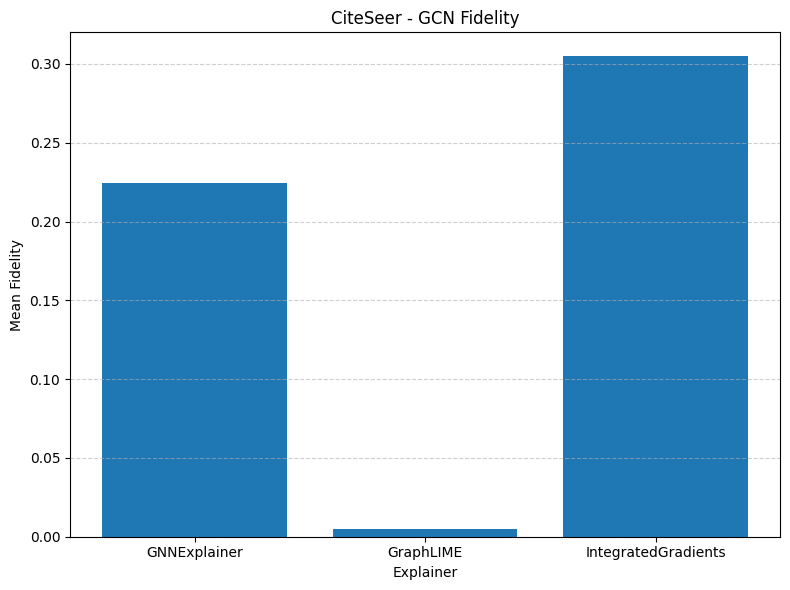

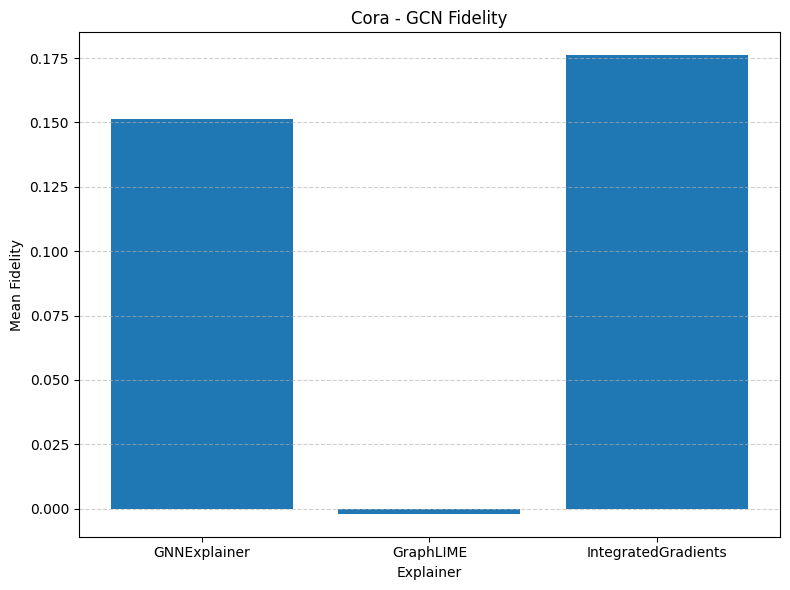

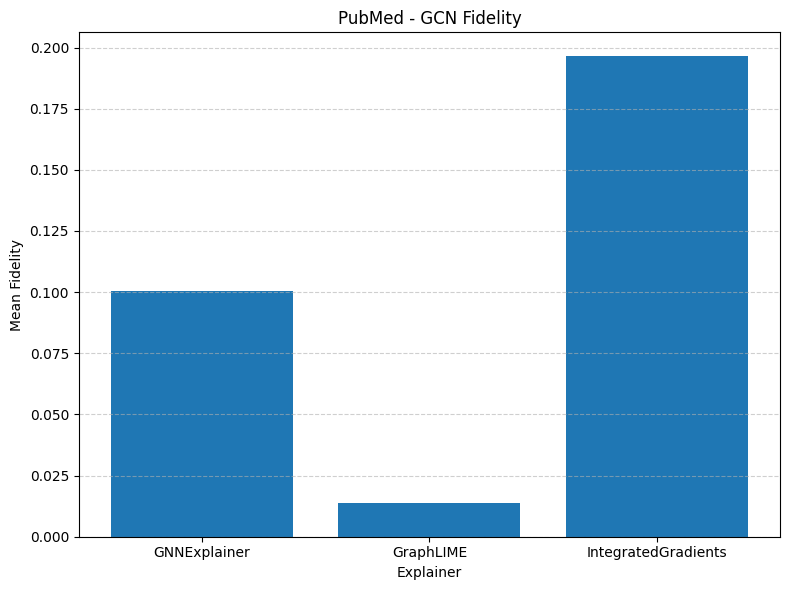

In [423]:
plot_fidelity_barplots(
    fidelity_summary_df,
    "GCN"
)

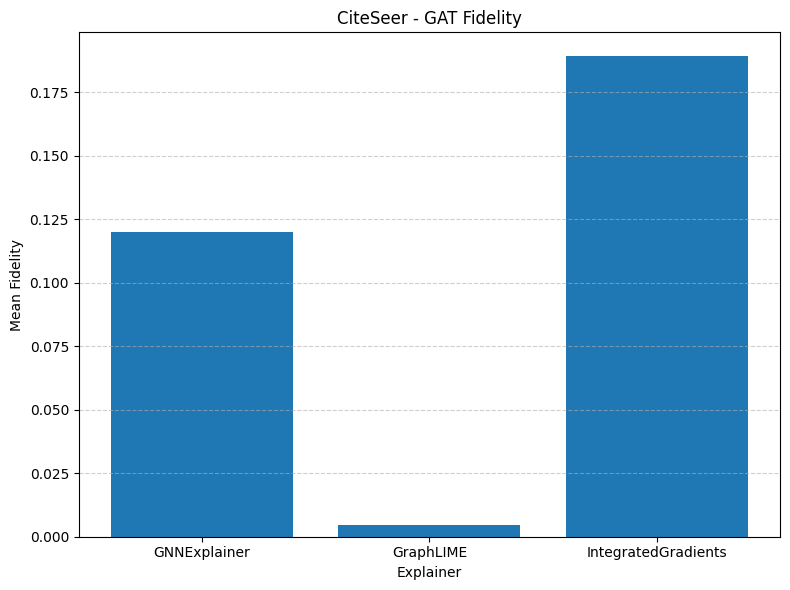

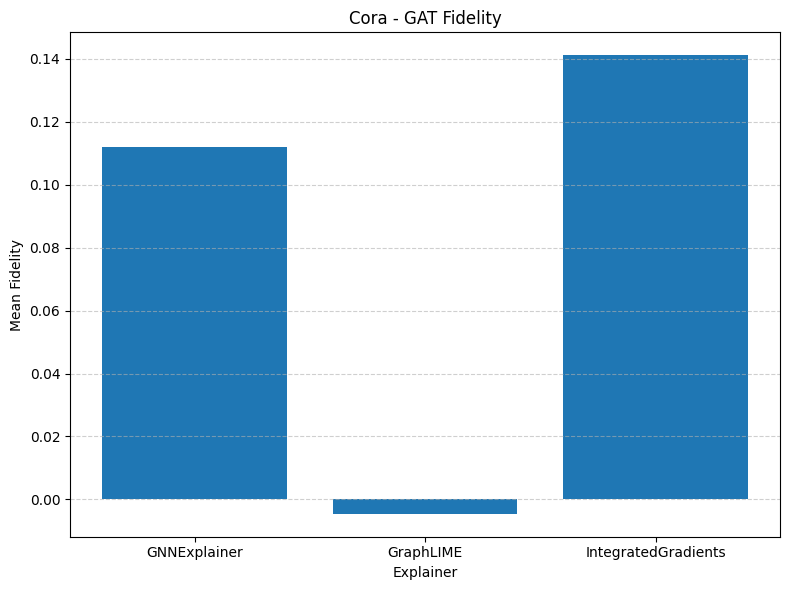

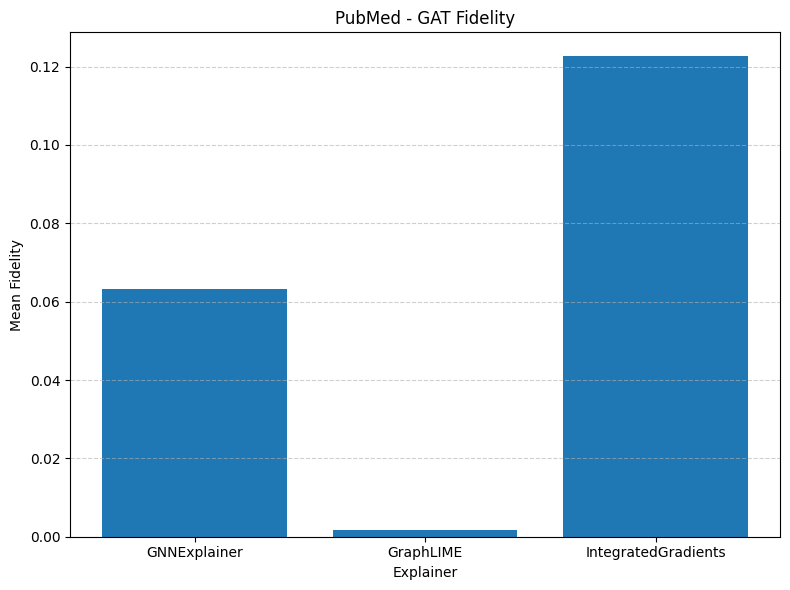

In [424]:
plot_fidelity_barplots(
    fidelity_summary_df,
    "GAT"
)

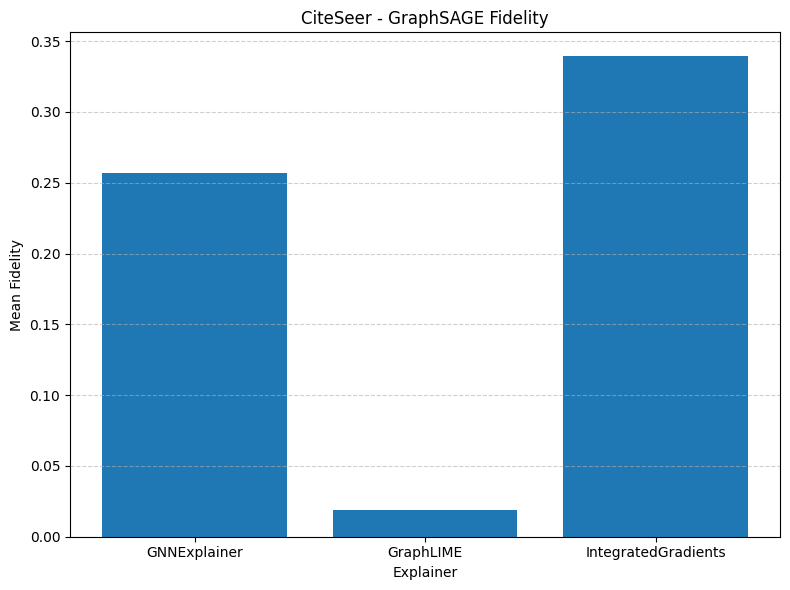

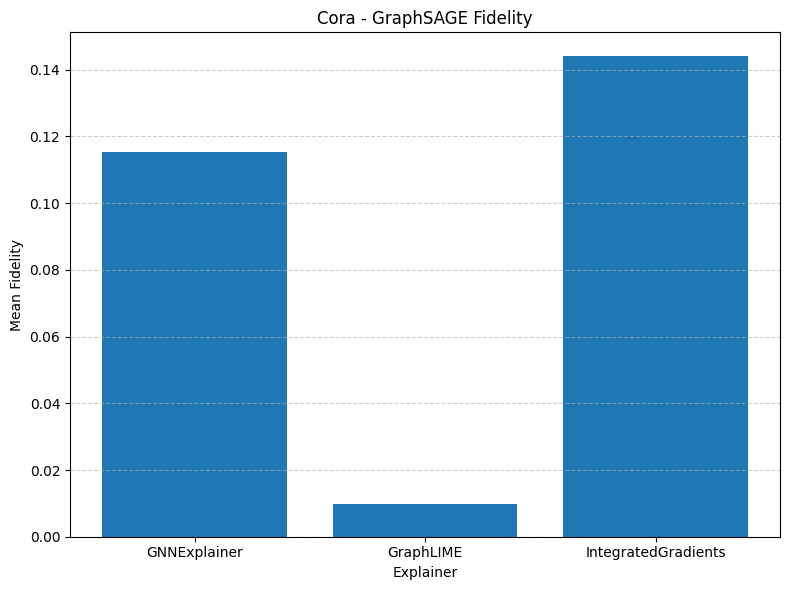

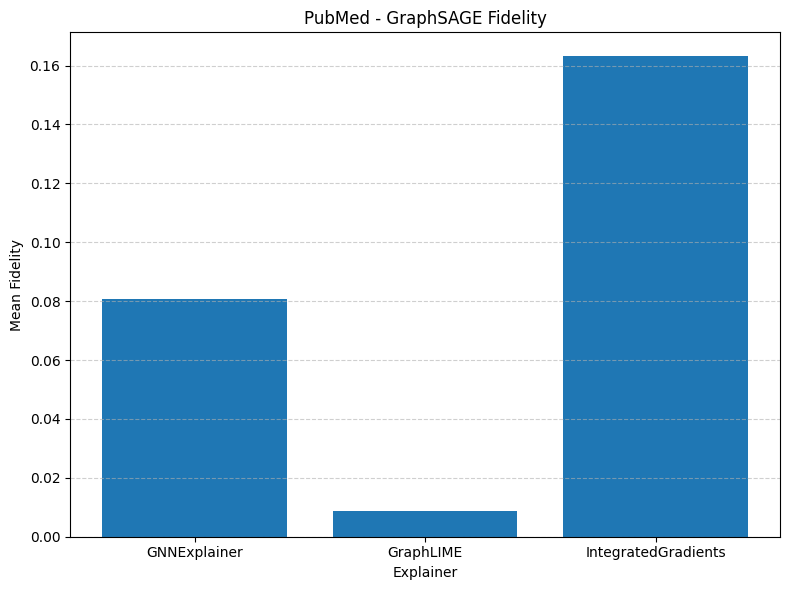

In [425]:
plot_fidelity_barplots(
    fidelity_summary_df,
    "GraphSAGE"
)

In [426]:
fidelity_node_summary_df = pd.read_csv("C:\\faculdade\\Tabalho-Final-XAI\\results\\fidelity_nodeV2.csv")

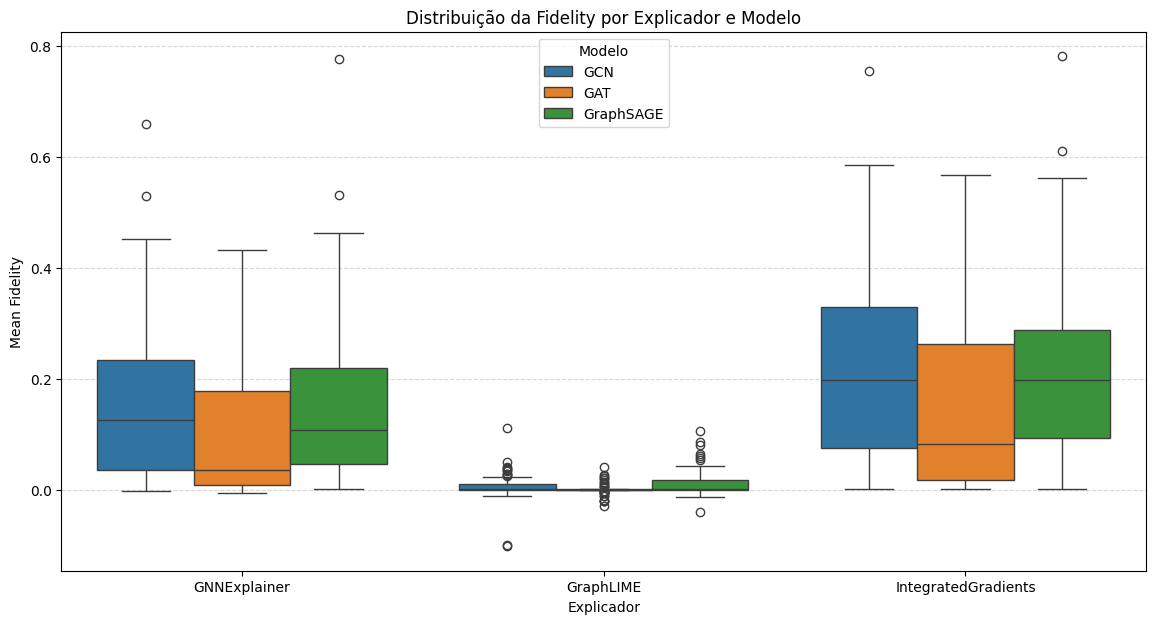

In [428]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

sns.boxplot(
    data=fidelity_node_summary_df,
    x="Explicador",
    y="Mean Fidelity",
    hue="Modelo"
)

plt.title("Distribuição da Fidelity por Explicador e Modelo")
plt.xlabel("Explicador")
plt.ylabel("Mean Fidelity")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.legend(title="Modelo")
plt.show()

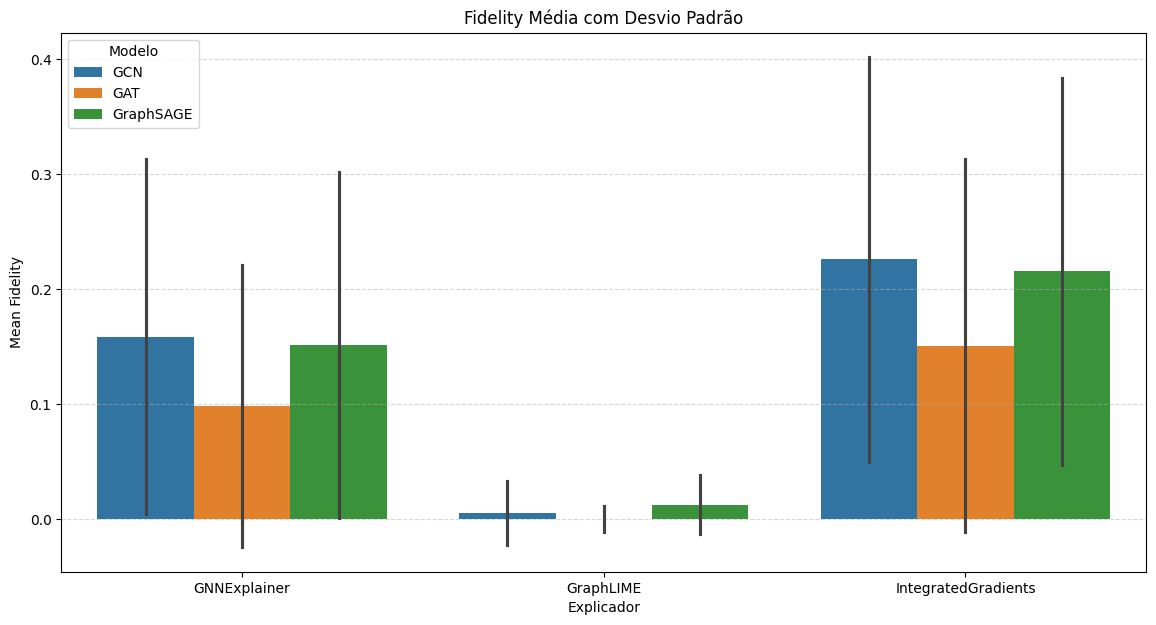

In [429]:
plt.figure(figsize=(14, 7))

sns.barplot(
    data=fidelity_node_summary_df,
    x="Explicador",
    y="Mean Fidelity",
    hue="Modelo",
    errorbar="sd"
)

plt.title("Fidelity Média com Desvio Padrão")
plt.xlabel("Explicador")
plt.ylabel("Mean Fidelity")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.legend(title="Modelo")
plt.show()

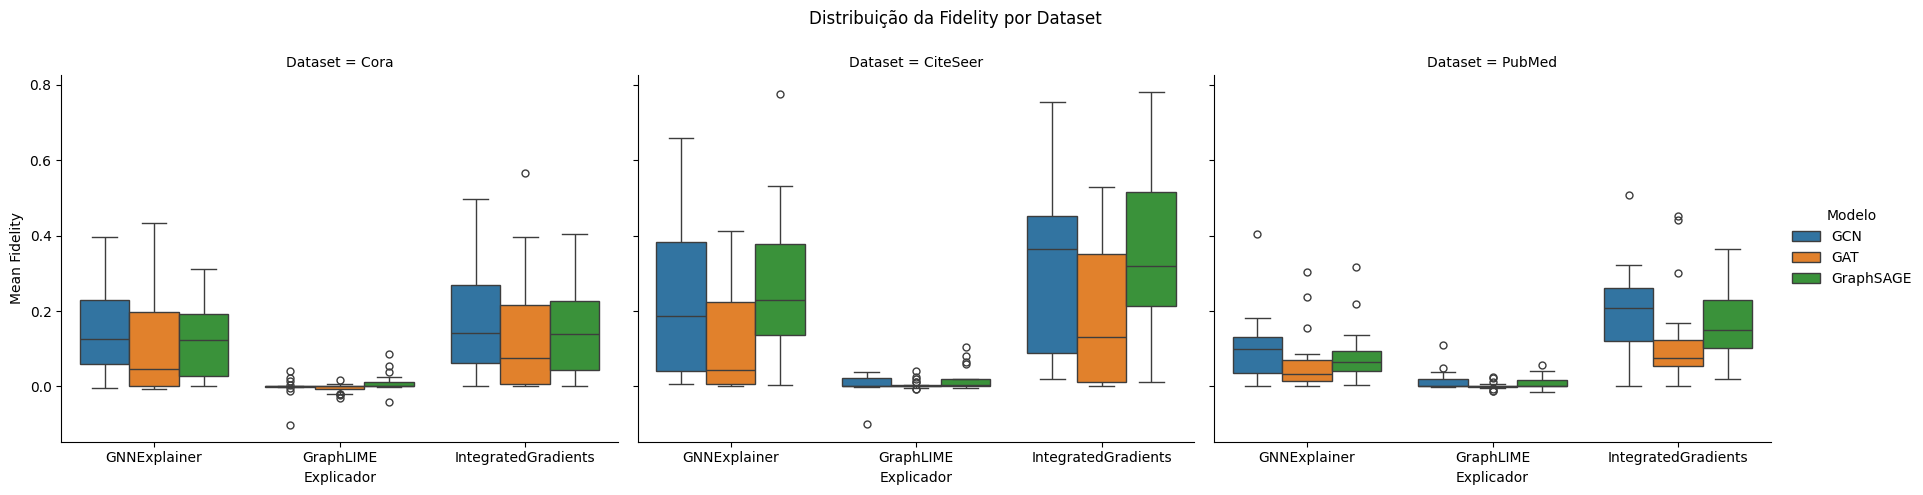

In [430]:
g = sns.catplot(
    data=fidelity_node_summary_df,
    x="Explicador",
    y="Mean Fidelity",
    col="Dataset",
    hue="Modelo",
    kind="box",
    height=5,
    aspect=1.2
)

g.fig.subplots_adjust(top=0.85)
g.fig.suptitle("Distribuição da Fidelity por Dataset")

plt.show()

# LogicXGNN

## Apoio

In [ ]:
def extract_local_subgraph(
    data,
    node_idx,
    num_hops=2
):

    subset, edge_index, mapping, edge_mask = k_hop_subgraph(
        node_idx=node_idx,
        num_hops=num_hops,
        edge_index=data.edge_index,
        relabel_nodes=True
    )

    x_sub = data.x[subset]

    y_sub = data.y[subset]

    return {
        "subset": subset,
        "x": x_sub,
        "edge_index": edge_index,
        "y": y_sub,
        "mapping": mapping
    }

In [ ]:
def fit_local_logic(
    predicates,
    labels
):

    clf = DecisionTreeClassifier(
        max_depth=3
    )

    clf.fit(
        predicates,
        labels
    )

    return clf

In [49]:
def get_local_embeddings(
    model,
    subgraph
):

    model.eval()

    with torch.no_grad():

        out, act = model(
            subgraph["x"],
            subgraph["edge_index"]
        )

    if "relu1" in act:
        embeddings = act["relu1"]

    elif "elu1" in act:
        embeddings = act["elu1"]

    else:
        raise ValueError(
            "Embedding layer não encontrada"
        )

    return {

        "logits": out,

        "activations": act,

        "subgraph_embeddings":
            embeddings
    }

In [50]:
def generate_predicates(
    subgraph_embeddings
):

    predicates = (
        subgraph_embeddings
        .cpu()
        .numpy()
    )

    return predicates

In [51]:
def explain_node_logicxgnn(
    model,
    data,
    node_idx,
    num_hops=2
):

    subgraph = extract_local_subgraph(
        data,
        node_idx,
        num_hops
    )

    local_info = get_local_embeddings(
        model,
        subgraph
    )

    predicates = generate_predicates(

        local_info[
            "subgraph_embeddings"
        ]

    )

    return {

        "subgraph":
            subgraph,

        "predicates":
            predicates,

        "subgraph_embeddings":
            local_info[
                "subgraph_embeddings"
            ]
    }
    

In [52]:
def map_latent_to_input_features(
    model,
    latent_idx,
    top_k=5
):

    # GCN
    if hasattr(
        model,
        "conv1"
    ) and hasattr(
        model.conv1,
        "lin"
    ):

        weights = model.conv1.lin.weight.detach()

    # GraphSAGE
    elif hasattr(
        model,
        "conv1"
    ) and hasattr(
        model.conv1,
        "lin_l"
    ):

        weights_self = model.conv1.lin_l.weight.detach()
        weights_neigh = model.conv1.lin_r.weight.detach()

        # combina as duas importâncias
        weights = (
            weights_self.abs()
            +
            weights_neigh.abs()
        ) / 2

    # GAT
    elif hasattr(
        model,
        "gat1"
    ):

        weights = model.gat1.lin.weight.detach()

    else:
        raise ValueError(
            "Modelo não suportado"
        )

    importance = weights[
        latent_idx
    ].abs()

    top_features = torch.topk(

        importance,

        top_k

    ).indices.tolist()

    return top_features

In [53]:
def extract_latent_rules(
    predicates,
    labels,
    max_depth=1
):

    clf = DecisionTreeClassifier(
        max_depth=max_depth,
        random_state=42
    )

    clf.fit(
        predicates,
        labels
    )

    used_latents = []
    thresholds = []

    for feat, thr in zip(
        clf.tree_.feature,
        clf.tree_.threshold
    ):

        if feat != -2:

            used_latents.append(
                feat
            )

            thresholds.append(
                thr
            )

    return used_latents, thresholds

In [54]:
def build_binary_predicates(
    predicates,
    used_latents,
    thresholds
):

    if len(
        used_latents
    ) == 0:

        return None

    binary_features = []

    for latent_idx, thr in zip(
        used_latents,
        thresholds
    ):

        binary_pred = (
            predicates[:, latent_idx] <= thr
        ).astype(int)

        binary_features.append(
            binary_pred
        )

    return np.stack(
        binary_features,
        axis=1
    )

In [55]:
def train_final_logic_tree(
    binary_predicates,
    labels,
    max_depth=2
):

    clf = DecisionTreeClassifier(
        max_depth=max_depth,
        random_state=42
    )

    clf.fit(
        binary_predicates,
        labels
    )

    return clf

In [ ]:
def generate_logicxgnn_explanations_v2(
    models,
    data,
    selected_nodes,
    num_hops=2,
    latent_depth=1,
    final_depth=2,
    top_k_input=5
):

    all_explanations = {}

    for model_name, model in models.items():

        print(
            f"Gerando explicações para {model_name}"
        )

        all_explanations[
            model_name
        ] = {}

        for node_id in selected_nodes:

            try:

                # subgrafo local
                explanation = explain_node_logicxgnn(
                    model,
                    data,
                    node_id,
                    num_hops=num_hops
                )

                predicates = explanation[
                    "predicates"
                ]

                labels = explanation[
                    "subgraph"
                ]["y"].cpu().numpy()

                # DT_1
                used_latents, thresholds = extract_latent_rules(

                    predicates,
                    labels,
                    max_depth=latent_depth
                )

                # predicados binários
                binary_predicates = build_binary_predicates(

                    predicates,
                    used_latents,
                    thresholds
                )

                if binary_predicates is None:
                        print(
                            f"Node {node_id}: "
                            f"sem splits úteis "
                            f"(labels={np.unique(labels)})"
                        )
                        continue

                # DT_2 final
                final_clf = train_final_logic_tree(

                    binary_predicates,
                    labels,
                    max_depth=final_depth
                )

                # regras finais
                rules = export_text(

                    final_clf,

                    feature_names=[

                        f"predicate_{i}"

                        for i in range(
                            binary_predicates.shape[1]
                        )
                    ]
                )

                # mapear latentes para features originais
                mapped_features = {}

                for latent_idx in used_latents:

                    mapped_features[
                        latent_idx
                    ] = map_latent_to_input_features(

                        model,

                        latent_idx,

                        top_k=top_k_input
                    )

                all_explanations[
                    model_name
                ][node_id] = {

                    "rules":
                        rules,

                    "used_latents":
                        used_latents,

                    "thresholds":
                        thresholds,

                    "mapped_features":
                        mapped_features,

                    "binary_predicates":
                        binary_predicates

                }

            except Exception as e:

                print(
                    f"Erro em node {node_id}: {e}"
                )

    return all_explanations

In [57]:
def compare_logicxgnn_features(
    logic_explanations,
    other_explanations,
    selected_nodes
):

    comparison_rows = []

    for model_name in logic_explanations.keys():

        for node_id in selected_nodes:

            # se LogicXGNN não conseguiu explicar, pula
            if node_id not in logic_explanations[model_name]:
                continue

            # se outro explicador não tem, pula
            if node_id not in other_explanations[model_name]:
                continue

            try:

                logic_feats = []

                mapped = logic_explanations[
                    model_name
                ][node_id][
                    "mapped_features"
                ]

                for latent_feats in mapped.values():

                    logic_feats.extend(
                        latent_feats
                    )

                logic_feats = list(
                    set(logic_feats)
                )

                other_feats = other_explanations[
                    model_name
                ][node_id]

                comparison_rows.append({

                    "Model": model_name,
                    "Node": node_id,

                    "Jaccard":
                        jaccard_similarity(
                            logic_feats,
                            other_feats
                        ),

                    "Overlap":
                        overlap_at_k(
                            logic_feats,
                            other_feats
                        ),

                    "Spearman":
                        spearman_topk(
                            logic_feats,
                            other_feats
                        )

                })

            except Exception as e:

                print(
                    f"Erro em {model_name} node {node_id}: {e}"
                )

    return pd.DataFrame(
        comparison_rows
    )

In [271]:
def get_logic_features(
    logic_explanation
):

    all_feats = []

    for latent_feats in logic_explanation[
        "mapped_features"
    ].values():

        all_feats.extend(
            latent_feats
        )

    return list(
        set(all_feats)
    )

In [ ]:
def stability_logicxgnn(
    explanations,
    selected_nodes
):

    model_pairs = list(
        combinations(
            explanations.keys(),
            2
        )
    )

    stability_rows = []

    for node_id in selected_nodes:

        jaccards = []
        overlaps = []
        spearmans = []

        for model_a, model_b in model_pairs:

            if node_id not in explanations[model_a]:
                continue

            if node_id not in explanations[model_b]:
                continue

            feats_a = get_logic_features(
                explanations[model_a][node_id]
            )

            feats_b = get_logic_features(
                explanations[model_b][node_id]
            )

            jaccards.append(

                jaccard_similarity(
                    feats_a,
                    feats_b
                )
            )

            overlaps.append(

                overlap_at_k(
                    feats_a,
                    feats_b
                )
            )

            spearmans.append(

                spearman_topk(
                    feats_a,
                    feats_b
                )
            )

        if len(jaccards) == 0:
            continue

        stability_rows.append({

            "node": node_id,

            "mean_jaccard":
                np.mean(jaccards),

            "mean_overlap":
                np.mean(overlaps),

            "mean_spearman":
                np.mean(spearmans),

            "std_jaccard":
                np.std(jaccards),

            "std_overlap":
                np.std(overlaps),

            "std_spearman":
                np.std(spearmans)

        })

    return pd.DataFrame(
        stability_rows
    )

In [284]:
def fidelity_score(
    model,
    data,
    node_id,
    important_features
):

    model.eval()

    x_masked = data.x.clone()

    x_masked[
        node_id,
        important_features
    ] = 0

    with torch.no_grad():

        logits = model(
            data.x,
            data.edge_index
        )

        # se vier tuple (logits, embeddings)
        if isinstance(
            logits,
            tuple
        ):
            logits = logits[0]

        probs = F.softmax(
            logits,
            dim=1
        )

        pred_class = probs[
            node_id
        ].argmax().item()

        original_score = probs[
            node_id,
            pred_class
        ].item()

        masked_logits = model(
            x_masked,
            data.edge_index
        )

        if isinstance(
            masked_logits,
            tuple
        ):
            masked_logits = masked_logits[0]

        masked_probs = F.softmax(
            masked_logits,
            dim=1
        )

        masked_score = masked_probs[
            node_id,
            pred_class
        ].item()

    fidelity = (
        original_score
        -
        masked_score
    )

    return fidelity

In [282]:
def fidelity_logicxgnn(
    models,
    explanations,
    selected_nodes,
    data
):

    fidelity_rows = []

    for node_id in selected_nodes:

        scores = []

        for model_name, model in models.items():

            if node_id not in explanations[model_name]:
                continue

            important_features = get_logic_features(

                explanations[
                    model_name
                ][node_id]
            )

            score = fidelity_score(

                model,
                data,
                node_id,
                important_features
            )

            scores.append(
                score
            )

        if len(scores) == 0:
            continue

        fidelity_rows.append({

            "node": node_id,

            "mean_fidelity":
                np.mean(scores),

            "std_fidelity":
                np.std(scores),

            "min_fidelity":
                np.min(scores),

            "max_fidelity":
                np.max(scores)

        })

    return pd.DataFrame(
        fidelity_rows
    )

## Dados

In [58]:
PLdataset = Planetoid(root='data/Planetoid', name='Cora')
cora = PLdataset[0]

In [59]:
CSdataset = Planetoid(root='data/Planetoid',name='CiteSeer')
citeseer = CSdataset[0]


In [60]:
MPdataset = Planetoid(root='data/Planetoid',name='PubMed')
pubmed = MPdataset[0]

## seleção de nodes

In [61]:
SEED=42

### Cora

In [98]:
cora_GCN_models = load_saved_models(
    "Cora",
    "GCN"
)

In [99]:
cora_GAT_models = load_saved_models(
    "Cora",
    "GAT"
)

In [100]:
cora_GraphSAGE_models = load_saved_models(
    "Cora",
    "GraphSAGE"
)

In [101]:
selected_nodes_cora_GCN = sample_consensus_nodes(
    models=cora_GCN_models,
    data=cora,
    n_nodes=20,
    seed=SEED,
    node_mask=cora.test_mask
)
print(selected_nodes_cora_GCN)

Nós elegíveis: 771
[2541, 1836, 1735, 2688, 2054, 1999, 1970, 1871, 2682, 1825, 2595, 2687, 2422, 1809, 2486, 2241, 1743, 1740, 1815, 1965]


In [102]:
selected_nodes_cora_GAT = sample_consensus_nodes(
    models=cora_GAT_models,
    data=cora,
    n_nodes=20,
    seed=SEED,
    node_mask=cora.test_mask
)
print(selected_nodes_cora_GAT)

Nós elegíveis: 752
[2575, 1846, 1737, 2069, 2027, 1985, 1881, 1831, 2633, 2457, 1816, 2514, 2267, 1746, 1744, 1822, 1978, 2002, 2393, 2526]


In [103]:
selected_nodes_cora_GraphSAGE = sample_consensus_nodes(
    models=cora_GraphSAGE_models,
    data=cora,
    n_nodes=20,
    seed=SEED,
    node_mask=cora.test_mask
)
print(selected_nodes_cora_GraphSAGE)

Nós elegíveis: 770
[2550, 1842, 1737, 2693, 2061, 2005, 1975, 1874, 2685, 1829, 2610, 2691, 2430, 1814, 2493, 2251, 1746, 1744, 1820, 1969]


### CiteSeer

In [104]:
citeseer_GCN_models = load_saved_models(
    "CiteSeer",
    "GCN"
)

In [105]:
citeseer_GAT_models = load_saved_models(
    "CiteSeer",
    "GAT"
)

In [106]:
citeseer_GraphSAGE_models = load_saved_models(
    "CiteSeer",
    "GraphSAGE"
)

In [107]:
selected_nodes_citeseer_GCN = sample_consensus_nodes(
    models=citeseer_GCN_models,
    data=citeseer,
    n_nodes=20,
    seed=SEED,
    node_mask=cora.test_mask
)
print(selected_nodes_citeseer_GCN)

Nós elegíveis: 620
[1905, 1745, 2187, 2140, 2103, 1951, 1887, 2615, 1860, 2687, 2404, 1758, 1755, 1870, 2097, 2118, 2546, 2704, 1752, 2640]


In [108]:
selected_nodes_citeseer_GAT = sample_consensus_nodes(
    models=citeseer_GAT_models,
    data=citeseer,
    n_nodes=20,
    seed=SEED,
    node_mask=cora.test_mask
)
print(selected_nodes_citeseer_GAT)

Nós elegíveis: 575
[1928, 1753, 2226, 2180, 2139, 1973, 1908, 2684, 1880, 2452, 1762, 1760, 1889, 2124, 2159, 2614, 1755, 2707, 2094, 2449]


In [109]:
selected_nodes_citeseer_GraphSAGE = sample_consensus_nodes(
    models=citeseer_GraphSAGE_models,
    data=citeseer,
    n_nodes=20,
    seed=SEED,
    node_mask=cora.test_mask
)
print(selected_nodes_citeseer_GraphSAGE)

Nós elegíveis: 641
[1887, 1741, 2164, 2109, 2071, 1932, 1867, 2594, 1845, 2655, 2383, 1754, 1752, 1855, 2066, 2091, 2512, 2673, 1745, 2613]


### PubMed

In [110]:
pubmed_GCN_models = load_saved_models(
    "PubMed",
    "GCN"
)

In [111]:
pubmed_GAT_models = load_saved_models(
    "PubMed",
    "GAT"
)

In [112]:
pubmed_GraphSAGE_models = load_saved_models(
    "PubMed",
    "GraphSAGE"
)

In [113]:
selected_nodes_pubmed_GCN = sample_consensus_nodes(
    models=pubmed_GCN_models,
    data=pubmed,
    n_nodes=20,
    seed=SEED,
    node_mask=cora.test_mask
)
print(selected_nodes_pubmed_GCN)

Nós elegíveis: 739
[2597, 1856, 1742, 2094, 2039, 2011, 1889, 1843, 2644, 2465, 1828, 2525, 2289, 1751, 1747, 1834, 2003, 2023, 2403, 2543]


In [114]:
selected_nodes_pubmed_GAT = sample_consensus_nodes(
    models=pubmed_GAT_models,
    data=pubmed,
    n_nodes=20,
    seed=SEED,
    node_mask=cora.test_mask
)
print(selected_nodes_pubmed_GAT)

Nós elegíveis: 712
[2623, 1864, 1747, 2105, 2052, 2022, 1901, 1852, 2675, 2484, 1833, 2551, 2305, 1756, 1753, 1839, 2015, 2036, 2420, 2570]


In [115]:
selected_nodes_pubmed_GraphSAGE = sample_consensus_nodes(
    models=pubmed_GraphSAGE_models,
    data=pubmed,
    n_nodes=20,
    seed=SEED,
    node_mask=cora.test_mask
)
print(selected_nodes_pubmed_GraphSAGE)

Nós elegíveis: 711
[2632, 1868, 1748, 2116, 2061, 2031, 1907, 1856, 2678, 2495, 1836, 2566, 2317, 1758, 1756, 1842, 2024, 2045, 2437, 2581]


## explicação

### Cora

#### GCN

In [172]:
cora_gcn_models = load_saved_models(
    "Cora",
    "GCN"
)

In [173]:
cora_gcn_models

{'Cora_GCN_h16_d0.5.pth': GCN(
   (conv1): GCNConv(1433, 16)
   (conv2): GCNConv(16, 7)
   (dropout): Dropout(p=0.5, inplace=False)
 ),
 'Cora_GCN_h64_d0.5.pth': GCN(
   (conv1): GCNConv(1433, 64)
   (conv2): GCNConv(64, 7)
   (dropout): Dropout(p=0.5, inplace=False)
 ),
 'Cora_GCN_h64_d0.7.pth': GCN(
   (conv1): GCNConv(1433, 64)
   (conv2): GCNConv(64, 7)
   (dropout): Dropout(p=0.7, inplace=False)
 )}

In [174]:
logic_explanations_cora_gcn = generate_logicxgnn_explanations_v2(

    models=cora_gcn_models,

    data=cora,

    selected_nodes=selected_nodes_cora_GCN,
)

Gerando explicações para Cora_GCN_h16_d0.5.pth
Node 1836: sem splits úteis (labels=[6])
Node 2688: sem splits úteis (labels=[3])
Node 2682: sem splits úteis (labels=[4])
Node 1825: sem splits úteis (labels=[5])
Node 2595: sem splits úteis (labels=[3])
Node 2687: sem splits úteis (labels=[3])
Node 2486: sem splits úteis (labels=[3])
Node 1965: sem splits úteis (labels=[4])
Gerando explicações para Cora_GCN_h64_d0.5.pth
Node 1836: sem splits úteis (labels=[6])
Node 2688: sem splits úteis (labels=[3])
Node 2682: sem splits úteis (labels=[4])
Node 1825: sem splits úteis (labels=[5])
Node 2595: sem splits úteis (labels=[3])
Node 2687: sem splits úteis (labels=[3])
Node 2486: sem splits úteis (labels=[3])
Node 1965: sem splits úteis (labels=[4])
Gerando explicações para Cora_GCN_h64_d0.7.pth
Node 1836: sem splits úteis (labels=[6])
Node 2688: sem splits úteis (labels=[3])
Node 2682: sem splits úteis (labels=[4])
Node 1825: sem splits úteis (labels=[5])
Node 2595: sem splits úteis (labels=[3]

In [175]:
print(

    logic_explanations_cora_gcn[
        "Cora_GCN_h16_d0.5.pth"
    ][2541]

)

{'rules': '|--- predicate_0 <= 0.50\n|   |--- class: 3\n|--- predicate_0 >  0.50\n|   |--- class: 0\n', 'used_latents': [np.int64(0)], 'thresholds': [np.float64(1.7156296968460083)], 'mapped_features': {np.int64(0): [19, 51, 135, 774, 1263]}, 'binary_predicates': array([[1],
       [1],
       [0],
       [0],
       [0]])}


In [176]:
logic_explanations_cora_gcn[
        "Cora_GCN_h16_d0.5.pth"
    ][2541]

{'rules': '|--- predicate_0 <= 0.50\n|   |--- class: 3\n|--- predicate_0 >  0.50\n|   |--- class: 0\n',
 'used_latents': [np.int64(0)],
 'thresholds': [np.float64(1.7156296968460083)],
 'mapped_features': {np.int64(0): [19, 51, 135, 774, 1263]},
 'binary_predicates': array([[1],
        [1],
        [0],
        [0],
        [0]])}

In [177]:
print(

    logic_explanations_cora_gcn[
        "Cora_GCN_h16_d0.5.pth"
    ][2541]["rules"]

)

|--- predicate_0 <= 0.50
|   |--- class: 3
|--- predicate_0 >  0.50
|   |--- class: 0



#### GAT

In [178]:
cora_gat_models = load_saved_models(
    "Cora",
    "GAT"
)

In [179]:
cora_gat_models

{'Cora_GAT_h32_d0.6_heads4.pth': GAT(
   (gat1): GATConv(1433, 32, heads=4)
   (gat2): GATConv(128, 7, heads=1)
 ),
 'Cora_GAT_h8_d0.6_heads4.pth': GAT(
   (gat1): GATConv(1433, 8, heads=4)
   (gat2): GATConv(32, 7, heads=1)
 ),
 'Cora_GAT_h8_d0.6_heads8.pth': GAT(
   (gat1): GATConv(1433, 8, heads=8)
   (gat2): GATConv(64, 7, heads=1)
 )}

In [180]:
logic_explanations_cora_gat = generate_logicxgnn_explanations_v2(

    models=cora_gat_models,

    data=cora,

    selected_nodes=selected_nodes_cora_GAT
)

Gerando explicações para Cora_GAT_h32_d0.6_heads4.pth
Node 2575: sem splits úteis (labels=[0])
Node 1831: sem splits úteis (labels=[2])
Node 2633: sem splits úteis (labels=[3])
Node 2514: sem splits úteis (labels=[2])
Node 2267: sem splits úteis (labels=[0])
Node 2393: sem splits úteis (labels=[4])
Node 2526: sem splits úteis (labels=[4])
Gerando explicações para Cora_GAT_h8_d0.6_heads4.pth
Node 2575: sem splits úteis (labels=[0])
Node 1831: sem splits úteis (labels=[2])
Node 2633: sem splits úteis (labels=[3])
Node 2514: sem splits úteis (labels=[2])
Node 2267: sem splits úteis (labels=[0])
Node 2393: sem splits úteis (labels=[4])
Node 2526: sem splits úteis (labels=[4])
Gerando explicações para Cora_GAT_h8_d0.6_heads8.pth
Node 2575: sem splits úteis (labels=[0])
Node 1831: sem splits úteis (labels=[2])
Node 2633: sem splits úteis (labels=[3])
Node 2514: sem splits úteis (labels=[2])
Node 2267: sem splits úteis (labels=[0])
Node 2393: sem splits úteis (labels=[4])
Node 2526: sem split

In [181]:
print(

    logic_explanations_cora_gat[
        "Cora_GAT_h32_d0.6_heads4.pth"
    ][2069]["rules"]

)

|--- predicate_0 <= 0.50
|   |--- class: 0
|--- predicate_0 >  0.50
|   |--- class: 5



#### GrapgSAGE

In [182]:
cora_graphsage_models = load_saved_models(
    "Cora",
    "GraphSAGE"
)

In [183]:
cora_graphsage_models

{'Cora_GraphSAGE_h32_d0.3.pth': GraphSAGE(
   (conv1): SAGEConv(1433, 32, aggr=mean)
   (conv2): SAGEConv(32, 7, aggr=mean)
 ),
 'Cora_GraphSAGE_h32_d0.7.pth': GraphSAGE(
   (conv1): SAGEConv(1433, 32, aggr=mean)
   (conv2): SAGEConv(32, 7, aggr=mean)
 ),
 'Cora_GraphSAGE_h64_d0.3.pth': GraphSAGE(
   (conv1): SAGEConv(1433, 64, aggr=mean)
   (conv2): SAGEConv(64, 7, aggr=mean)
 )}

In [184]:
logic_explanations_cora_graphsage = generate_logicxgnn_explanations_v2(

    models=cora_graphsage_models,

    data=cora,

    selected_nodes=selected_nodes_cora_GraphSAGE
)

Gerando explicações para Cora_GraphSAGE_h32_d0.3.pth
Node 2693: sem splits úteis (labels=[3])
Node 2061: sem splits úteis (labels=[5])
Node 2685: sem splits úteis (labels=[2])
Node 2610: sem splits úteis (labels=[3])
Node 2430: sem splits úteis (labels=[3])
Node 2493: sem splits úteis (labels=[3])
Gerando explicações para Cora_GraphSAGE_h32_d0.7.pth
Node 2693: sem splits úteis (labels=[3])
Node 2061: sem splits úteis (labels=[5])
Node 2685: sem splits úteis (labels=[2])
Node 2610: sem splits úteis (labels=[3])
Node 2430: sem splits úteis (labels=[3])
Node 2493: sem splits úteis (labels=[3])
Gerando explicações para Cora_GraphSAGE_h64_d0.3.pth
Node 2693: sem splits úteis (labels=[3])
Node 2061: sem splits úteis (labels=[5])
Node 2685: sem splits úteis (labels=[2])
Node 2610: sem splits úteis (labels=[3])
Node 2430: sem splits úteis (labels=[3])
Node 2493: sem splits úteis (labels=[3])


In [185]:
print(

    logic_explanations_cora_graphsage[
        "Cora_GraphSAGE_h32_d0.3.pth"
    ][1842]["rules"]

)

|--- predicate_0 <= 0.50
|   |--- class: 5
|--- predicate_0 >  0.50
|   |--- class: 0



### CiteSeer

#### GCN

In [186]:
citeseer_gcn_models = load_saved_models(
    "CiteSeer",
    "GCN"
)

In [187]:
citeseer_gcn_models

{'CiteSeer_GCN_h64_d0.3.pth': GCN(
   (conv1): GCNConv(3703, 64)
   (conv2): GCNConv(64, 6)
   (dropout): Dropout(p=0.3, inplace=False)
 ),
 'CiteSeer_GCN_h64_d0.5.pth': GCN(
   (conv1): GCNConv(3703, 64)
   (conv2): GCNConv(64, 6)
   (dropout): Dropout(p=0.5, inplace=False)
 ),
 'CiteSeer_GCN_h64_d0.7.pth': GCN(
   (conv1): GCNConv(3703, 64)
   (conv2): GCNConv(64, 6)
   (dropout): Dropout(p=0.7, inplace=False)
 )}

In [188]:
selected_nodes_citeseer_GCN

[1905,
 1745,
 2187,
 2140,
 2103,
 1951,
 1887,
 2615,
 1860,
 2687,
 2404,
 1758,
 1755,
 1870,
 2097,
 2118,
 2546,
 2704,
 1752,
 2640]

In [189]:
logic_explanations_citeseer_gcn = generate_logicxgnn_explanations_v2(

    models=citeseer_gcn_models,

    data=citeseer,

    selected_nodes=selected_nodes_citeseer_GCN
)

Gerando explicações para CiteSeer_GCN_h64_d0.3.pth
Node 1905: sem splits úteis (labels=[5])
Node 1745: sem splits úteis (labels=[5])
Node 2187: sem splits úteis (labels=[1])
Node 2140: sem splits úteis (labels=[5])
Node 2103: sem splits úteis (labels=[3])
Node 1951: sem splits úteis (labels=[1])
Node 1887: sem splits úteis (labels=[3])
Node 2687: sem splits úteis (labels=[3])
Node 1870: sem splits úteis (labels=[4])
Node 2118: sem splits úteis (labels=[1])
Node 2704: sem splits úteis (labels=[1])
Node 1752: sem splits úteis (labels=[0])
Gerando explicações para CiteSeer_GCN_h64_d0.5.pth
Node 1905: sem splits úteis (labels=[5])
Node 1745: sem splits úteis (labels=[5])
Node 2187: sem splits úteis (labels=[1])
Node 2140: sem splits úteis (labels=[5])
Node 2103: sem splits úteis (labels=[3])
Node 1951: sem splits úteis (labels=[1])
Node 1887: sem splits úteis (labels=[3])
Node 2687: sem splits úteis (labels=[3])
Node 1870: sem splits úteis (labels=[4])
Node 2118: sem splits úteis (labels=[

In [190]:
print(

    logic_explanations_citeseer_gcn[
        "CiteSeer_GCN_h64_d0.3.pth"
    ][2640]["rules"]

)

|--- predicate_0 <= 0.50
|   |--- class: 1
|--- predicate_0 >  0.50
|   |--- class: 2



#### GAT

In [191]:
citeseer_gat_models = load_saved_models(
    "CiteSeer",
    "GAT"
)

In [192]:
citeseer_gat_models

{'CiteSeer_GAT_h32_d0.4_heads4.pth': GAT(
   (gat1): GATConv(3703, 32, heads=4)
   (gat2): GATConv(128, 6, heads=1)
 ),
 'CiteSeer_GAT_h32_d0.6_heads8.pth': GAT(
   (gat1): GATConv(3703, 32, heads=8)
   (gat2): GATConv(256, 6, heads=1)
 ),
 'CiteSeer_GAT_h8_d0.4_heads4.pth': GAT(
   (gat1): GATConv(3703, 8, heads=4)
   (gat2): GATConv(32, 6, heads=1)
 )}

In [193]:
selected_nodes_citeseer_GAT

[1928,
 1753,
 2226,
 2180,
 2139,
 1973,
 1908,
 2684,
 1880,
 2452,
 1762,
 1760,
 1889,
 2124,
 2159,
 2614,
 1755,
 2707,
 2094,
 2449]

In [194]:
logic_explanations_citeseer_gat = generate_logicxgnn_explanations_v2(

    models=citeseer_gat_models,

    data=citeseer,

    selected_nodes=selected_nodes_citeseer_GAT
)

Gerando explicações para CiteSeer_GAT_h32_d0.4_heads4.pth
Node 1928: sem splits úteis (labels=[3])
Node 2180: sem splits úteis (labels=[5])
Node 1908: sem splits úteis (labels=[3])
Node 2684: sem splits úteis (labels=[3])
Node 1880: sem splits úteis (labels=[2])
Node 2452: sem splits úteis (labels=[4])
Node 1762: sem splits úteis (labels=[5])
Node 1889: sem splits úteis (labels=[1])
Node 2159: sem splits úteis (labels=[3])
Node 2707: sem splits úteis (labels=[1])
Node 2094: sem splits úteis (labels=[5])
Node 2449: sem splits úteis (labels=[4])
Gerando explicações para CiteSeer_GAT_h32_d0.6_heads8.pth
Node 1928: sem splits úteis (labels=[3])
Node 2180: sem splits úteis (labels=[5])
Node 1908: sem splits úteis (labels=[3])
Node 2684: sem splits úteis (labels=[3])
Node 1880: sem splits úteis (labels=[2])
Node 2452: sem splits úteis (labels=[4])
Node 1762: sem splits úteis (labels=[5])
Node 1889: sem splits úteis (labels=[1])
Node 2159: sem splits úteis (labels=[3])
Node 2707: sem splits ú

In [195]:
print(

    logic_explanations_citeseer_gat[
        "CiteSeer_GAT_h32_d0.4_heads4.pth"
    ][2226]["rules"]

)

|--- predicate_0 <= 0.50
|   |--- class: 1
|--- predicate_0 >  0.50
|   |--- class: 2



#### GrapgSAGE

In [196]:
citeseer_graphsage_models = load_saved_models(
    "CiteSeer",
    "GraphSAGE"
)

In [197]:
citeseer_graphsage_models

{'CiteSeer_GraphSAGE_h32_d0.3.pth': GraphSAGE(
   (conv1): SAGEConv(3703, 32, aggr=mean)
   (conv2): SAGEConv(32, 6, aggr=mean)
 ),
 'CiteSeer_GraphSAGE_h64_d0.3.pth': GraphSAGE(
   (conv1): SAGEConv(3703, 64, aggr=mean)
   (conv2): SAGEConv(64, 6, aggr=mean)
 ),
 'CiteSeer_GraphSAGE_h64_d0.5.pth': GraphSAGE(
   (conv1): SAGEConv(3703, 64, aggr=mean)
   (conv2): SAGEConv(64, 6, aggr=mean)
 )}

In [198]:
selected_nodes_citeseer_GraphSAGE

[1887,
 1741,
 2164,
 2109,
 2071,
 1932,
 1867,
 2594,
 1845,
 2655,
 2383,
 1754,
 1752,
 1855,
 2066,
 2091,
 2512,
 2673,
 1745,
 2613]

In [199]:
logic_explanations_citeseer_graphsage = generate_logicxgnn_explanations_v2(

    models=citeseer_graphsage_models,

    data=citeseer,

    selected_nodes=selected_nodes_citeseer_GraphSAGE
)

Gerando explicações para CiteSeer_GraphSAGE_h32_d0.3.pth
Node 1887: sem splits úteis (labels=[3])
Node 1741: sem splits úteis (labels=[5])
Node 2164: sem splits úteis (labels=[1])
Node 2109: sem splits úteis (labels=[1])
Node 2071: sem splits úteis (labels=[5])
Node 1867: sem splits úteis (labels=[3])
Node 1754: sem splits úteis (labels=[3])
Node 1752: sem splits úteis (labels=[0])
Node 1855: sem splits úteis (labels=[5])
Node 1745: sem splits úteis (labels=[5])
Gerando explicações para CiteSeer_GraphSAGE_h64_d0.3.pth
Node 1887: sem splits úteis (labels=[3])
Node 1741: sem splits úteis (labels=[5])
Node 2164: sem splits úteis (labels=[1])
Node 2109: sem splits úteis (labels=[1])
Node 2071: sem splits úteis (labels=[5])
Node 1867: sem splits úteis (labels=[3])
Node 1754: sem splits úteis (labels=[3])
Node 1752: sem splits úteis (labels=[0])
Node 1855: sem splits úteis (labels=[5])
Node 1745: sem splits úteis (labels=[5])
Gerando explicações para CiteSeer_GraphSAGE_h64_d0.5.pth
Node 1887

In [200]:
print(

    logic_explanations_citeseer_graphsage[
        "CiteSeer_GraphSAGE_h32_d0.3.pth"
    ][1932]["rules"]

)

|--- predicate_0 <= 0.50
|   |--- class: 0
|--- predicate_0 >  0.50
|   |--- class: 4



### PubMed

#### GCN

In [201]:
pubmed_GCN_models = load_saved_models(
    "PubMed",
    "GCN"
)

In [202]:
pubmed_GCN_models

{'PubMed_GCN_h16_d0.7.pth': GCN(
   (conv1): GCNConv(500, 16)
   (conv2): GCNConv(16, 3)
   (dropout): Dropout(p=0.7, inplace=False)
 ),
 'PubMed_GCN_h32_d0.3.pth': GCN(
   (conv1): GCNConv(500, 32)
   (conv2): GCNConv(32, 3)
   (dropout): Dropout(p=0.3, inplace=False)
 ),
 'PubMed_GCN_h32_d0.5.pth': GCN(
   (conv1): GCNConv(500, 32)
   (conv2): GCNConv(32, 3)
   (dropout): Dropout(p=0.5, inplace=False)
 )}

In [203]:
selected_nodes_pubmed_GCN

[2597,
 1856,
 1742,
 2094,
 2039,
 2011,
 1889,
 1843,
 2644,
 2465,
 1828,
 2525,
 2289,
 1751,
 1747,
 1834,
 2003,
 2023,
 2403,
 2543]

In [204]:
logic_explanations_pubmed_GCN = generate_logicxgnn_explanations_v2(

    models=pubmed_GCN_models,

    data=pubmed,

    selected_nodes=selected_nodes_pubmed_GCN
)

Gerando explicações para PubMed_GCN_h16_d0.7.pth
Node 2011: sem splits úteis (labels=[1])
Node 1828: sem splits úteis (labels=[2])
Node 1747: sem splits úteis (labels=[1])
Node 1834: sem splits úteis (labels=[1])
Gerando explicações para PubMed_GCN_h32_d0.3.pth
Node 2011: sem splits úteis (labels=[1])
Node 1828: sem splits úteis (labels=[2])
Node 1747: sem splits úteis (labels=[1])
Node 1834: sem splits úteis (labels=[1])
Gerando explicações para PubMed_GCN_h32_d0.5.pth
Node 2011: sem splits úteis (labels=[1])
Node 1828: sem splits úteis (labels=[2])
Node 1747: sem splits úteis (labels=[1])
Node 1834: sem splits úteis (labels=[1])


In [205]:
print(

    logic_explanations_pubmed_GCN[
        "PubMed_GCN_h16_d0.7.pth"
    ][2597]["rules"]

)

|--- predicate_0 <= 0.50
|   |--- class: 1
|--- predicate_0 >  0.50
|   |--- class: 0



#### GAT

In [206]:
pubmed_GAT_models = load_saved_models(
    "PubMed",
    "GAT"
)

In [207]:
pubmed_GAT_models

{'PubMed_GAT_h16_d0.4_heads4.pth': GAT(
   (gat1): GATConv(500, 16, heads=4)
   (gat2): GATConv(64, 3, heads=1)
 ),
 'PubMed_GAT_h32_d0.6_heads8.pth': GAT(
   (gat1): GATConv(500, 32, heads=8)
   (gat2): GATConv(256, 3, heads=1)
 ),
 'PubMed_GAT_h8_d0.6_heads8.pth': GAT(
   (gat1): GATConv(500, 8, heads=8)
   (gat2): GATConv(64, 3, heads=1)
 )}

In [208]:
selected_nodes_pubmed_GAT

[2623,
 1864,
 1747,
 2105,
 2052,
 2022,
 1901,
 1852,
 2675,
 2484,
 1833,
 2551,
 2305,
 1756,
 1753,
 1839,
 2015,
 2036,
 2420,
 2570]

In [209]:
logic_explanations_pubmed_gat = generate_logicxgnn_explanations_v2(

    models=pubmed_GAT_models,

    data=pubmed,

    selected_nodes=selected_nodes_pubmed_GAT
)

Gerando explicações para PubMed_GAT_h16_d0.4_heads4.pth
Node 1747: sem splits úteis (labels=[1])
Node 2675: sem splits úteis (labels=[2])
Node 2015: sem splits úteis (labels=[2])
Gerando explicações para PubMed_GAT_h32_d0.6_heads8.pth
Node 1747: sem splits úteis (labels=[1])
Node 2675: sem splits úteis (labels=[2])
Node 2015: sem splits úteis (labels=[2])
Gerando explicações para PubMed_GAT_h8_d0.6_heads8.pth
Node 1747: sem splits úteis (labels=[1])
Node 2675: sem splits úteis (labels=[2])
Node 2015: sem splits úteis (labels=[2])


In [210]:
print(

    logic_explanations_pubmed_gat[
        "PubMed_GAT_h16_d0.4_heads4.pth"
    ][2623]["rules"]

)

|--- predicate_0 <= 0.50
|   |--- class: 0
|--- predicate_0 >  0.50
|   |--- class: 1



#### GrapgSAGE

In [211]:
pubmed_GraphSAGE_models = load_saved_models(
    "PubMed",
    "GraphSAGE"
)

In [212]:
pubmed_GraphSAGE_models

{'PubMed_GraphSAGE_h16_d0.5.pth': GraphSAGE(
   (conv1): SAGEConv(500, 16, aggr=mean)
   (conv2): SAGEConv(16, 3, aggr=mean)
 ),
 'PubMed_GraphSAGE_h32_d0.3.pth': GraphSAGE(
   (conv1): SAGEConv(500, 32, aggr=mean)
   (conv2): SAGEConv(32, 3, aggr=mean)
 ),
 'PubMed_GraphSAGE_h64_d0.5.pth': GraphSAGE(
   (conv1): SAGEConv(500, 64, aggr=mean)
   (conv2): SAGEConv(64, 3, aggr=mean)
 )}

In [213]:
selected_nodes_pubmed_GraphSAGE

[2632,
 1868,
 1748,
 2116,
 2061,
 2031,
 1907,
 1856,
 2678,
 2495,
 1836,
 2566,
 2317,
 1758,
 1756,
 1842,
 2024,
 2045,
 2437,
 2581]

In [214]:
logic_explanations_pubmed_graphsage = generate_logicxgnn_explanations_v2(

    models=pubmed_GraphSAGE_models,

    data=pubmed,

    selected_nodes=selected_nodes_pubmed_GraphSAGE
)

Gerando explicações para PubMed_GraphSAGE_h16_d0.5.pth
Node 2632: sem splits úteis (labels=[0])
Node 2566: sem splits úteis (labels=[1])
Gerando explicações para PubMed_GraphSAGE_h32_d0.3.pth
Node 2632: sem splits úteis (labels=[0])
Node 2566: sem splits úteis (labels=[1])
Gerando explicações para PubMed_GraphSAGE_h64_d0.5.pth
Node 2632: sem splits úteis (labels=[0])
Node 2566: sem splits úteis (labels=[1])


In [215]:
print(

    logic_explanations_pubmed_graphsage[
        "PubMed_GraphSAGE_h16_d0.5.pth"
    ][1868]["rules"]

)

|--- predicate_0 <= 0.50
|   |--- class: 1
|--- predicate_0 >  0.50
|   |--- class: 2



## Comparação

### GNNExplainer

#### Cora

In [133]:
cora_gcn_gnne_exp = load_explanations(
    dataset="Cora",
    model="GCN",
    explainer="GNNExplainer",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

In [135]:
logic_vs_gnne_cora_gcn = compare_logicxgnn_features(

    logic_explanations_cora_gcn,

    cora_gcn_gnne_exp,

    selected_nodes_cora_GCN
)
logic_vs_gnne_cora_gcn

,Model,Node,Jaccard,Overlap,Spearman
0,Cora_GCN_h16_d0.5.pth,2541,0.153846,2,-1.0
1,Cora_GCN_h16_d0.5.pth,1735,0.000000,0,0.0
2,Cora_GCN_h16_d0.5.pth,2054,0.071429,1,0.0
3,Cora_GCN_h16_d0.5.pth,1999,0.000000,0,0.0
4,Cora_GCN_h16_d0.5.pth,1970,0.000000,0,0.0
5,Cora_GCN_h16_d0.5.pth,1871,0.000000,0,0.0
6,Cora_GCN_h16_d0.5.pth,2422,0.000000,0,0.0
7,Cora_GCN_h16_d0.5.pth,1809,0.000000,0,0.0
8,Cora_GCN_h16_d0.5.pth,2241,0.153846,2,1.0
9,Cora_GCN_h16_d0.5.pth,1743,0.000000,0,0.0


In [217]:
cora_gat_gnne_exp = load_explanations(
    dataset="Cora",
    model="GAT",
    explainer="GNNExplainer",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

In [218]:
logic_vs_gnne_cora_gat = compare_logicxgnn_features(

    logic_explanations_cora_gat,

    cora_gat_gnne_exp,

    selected_nodes_cora_GAT
)
logic_vs_gnne_cora_gat

,Model,Node,Jaccard,Overlap,Spearman
0,Cora_GAT_h32_d0.6_heads4.pth,1846,0.000000,0,0.0
1,Cora_GAT_h32_d0.6_heads4.pth,1737,0.000000,0,0.0
2,Cora_GAT_h32_d0.6_heads4.pth,2069,0.000000,0,0.0
3,Cora_GAT_h32_d0.6_heads4.pth,2027,0.000000,0,0.0
4,Cora_GAT_h32_d0.6_heads4.pth,1985,0.000000,0,0.0
5,Cora_GAT_h32_d0.6_heads4.pth,1881,0.000000,0,0.0
6,Cora_GAT_h32_d0.6_heads4.pth,2457,0.000000,0,0.0
7,Cora_GAT_h32_d0.6_heads4.pth,1816,0.000000,0,0.0
8,Cora_GAT_h32_d0.6_heads4.pth,1746,0.000000,0,0.0
9,Cora_GAT_h32_d0.6_heads4.pth,1744,0.000000,0,0.0


In [219]:
cora_graphsage_gnne_exp = load_explanations(
    dataset="Cora",
    model="GraphSAGE",
    explainer="GNNExplainer",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

In [220]:
logic_vs_gnne_cora_graphsage = compare_logicxgnn_features(

    logic_explanations_cora_graphsage,

    cora_graphsage_gnne_exp,

    selected_nodes_cora_GraphSAGE
)
logic_vs_gnne_cora_graphsage

,Model,Node,Jaccard,Overlap,Spearman
0,Cora_GraphSAGE_h32_d0.3.pth,2550,0.071429,1,0.0
1,Cora_GraphSAGE_h32_d0.3.pth,1842,0.071429,1,0.0
2,Cora_GraphSAGE_h32_d0.3.pth,1737,0.071429,1,0.0
3,Cora_GraphSAGE_h32_d0.3.pth,2005,0.000000,0,0.0
4,Cora_GraphSAGE_h32_d0.3.pth,1975,0.071429,1,0.0
5,Cora_GraphSAGE_h32_d0.3.pth,1874,0.071429,1,0.0
6,Cora_GraphSAGE_h32_d0.3.pth,1829,0.000000,0,0.0
7,Cora_GraphSAGE_h32_d0.3.pth,2691,0.153846,2,-1.0
8,Cora_GraphSAGE_h32_d0.3.pth,1814,0.000000,0,0.0
9,Cora_GraphSAGE_h32_d0.3.pth,2251,0.000000,0,0.0


#### CiteSeer

In [221]:
citeseer_gcn_gnne_exp = load_explanations(
    dataset="Citeseer",
    model="GCN",
    explainer="GNNExplainer",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

In [222]:
logic_vs_gnne_citeseer_gcn = compare_logicxgnn_features(

    logic_explanations_citeseer_gcn,

    citeseer_gcn_gnne_exp,

    selected_nodes_citeseer_GCN
)
logic_vs_gnne_citeseer_gcn

,Model,Node,Jaccard,Overlap,Spearman
0,CiteSeer_GCN_h64_d0.3.pth,2615,0.071429,1,0
1,CiteSeer_GCN_h64_d0.3.pth,1860,0.000000,0,0
2,CiteSeer_GCN_h64_d0.3.pth,2404,0.000000,0,0
3,CiteSeer_GCN_h64_d0.3.pth,1758,0.000000,0,0
4,CiteSeer_GCN_h64_d0.3.pth,1755,0.000000,0,0
5,CiteSeer_GCN_h64_d0.3.pth,2097,0.000000,0,0
6,CiteSeer_GCN_h64_d0.3.pth,2546,0.000000,0,0
7,CiteSeer_GCN_h64_d0.3.pth,2640,0.000000,0,0
8,CiteSeer_GCN_h64_d0.5.pth,2615,0.071429,1,0
9,CiteSeer_GCN_h64_d0.5.pth,1860,0.000000,0,0


In [223]:
citeseer_gat_gnne_exp = load_explanations(
    dataset="Citeseer",
    model="GAT",
    explainer="GNNExplainer",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

In [224]:
logic_vs_gnne_citeseer_gat = compare_logicxgnn_features(

    logic_explanations_citeseer_gat,

    citeseer_gat_gnne_exp,

    selected_nodes_citeseer_GAT
)
logic_vs_gnne_citeseer_gat

,Model,Node,Jaccard,Overlap,Spearman
0,CiteSeer_GAT_h32_d0.4_heads4.pth,1753,0.000000,0,0
1,CiteSeer_GAT_h32_d0.4_heads4.pth,2226,0.000000,0,0
2,CiteSeer_GAT_h32_d0.4_heads4.pth,2139,0.000000,0,0
3,CiteSeer_GAT_h32_d0.4_heads4.pth,1973,0.000000,0,0
4,CiteSeer_GAT_h32_d0.4_heads4.pth,1760,0.000000,0,0
5,CiteSeer_GAT_h32_d0.4_heads4.pth,2124,0.000000,0,0
6,CiteSeer_GAT_h32_d0.4_heads4.pth,2614,0.000000,0,0
7,CiteSeer_GAT_h32_d0.4_heads4.pth,1755,0.000000,0,0
8,CiteSeer_GAT_h32_d0.6_heads8.pth,1753,0.000000,0,0
9,CiteSeer_GAT_h32_d0.6_heads8.pth,2226,0.000000,0,0


In [225]:
citeseer_graphsage_gnne_exp = load_explanations(
    dataset="Citeseer",
    model="GraphSAGE",
    explainer="GNNExplainer",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

In [226]:
logic_vs_gnne_citeseer_graphsage = compare_logicxgnn_features(

    logic_explanations_citeseer_graphsage,

    citeseer_graphsage_gnne_exp,

    selected_nodes_citeseer_GraphSAGE
)
logic_vs_gnne_citeseer_graphsage

,Model,Node,Jaccard,Overlap,Spearman
0,CiteSeer_GraphSAGE_h32_d0.3.pth,1932,0.000000,0,0
1,CiteSeer_GraphSAGE_h32_d0.3.pth,2594,0.000000,0,0
2,CiteSeer_GraphSAGE_h32_d0.3.pth,1845,0.000000,0,0
3,CiteSeer_GraphSAGE_h32_d0.3.pth,2655,0.000000,0,0
4,CiteSeer_GraphSAGE_h32_d0.3.pth,2383,0.071429,1,0
5,CiteSeer_GraphSAGE_h32_d0.3.pth,2066,0.000000,0,0
6,CiteSeer_GraphSAGE_h32_d0.3.pth,2091,0.000000,0,0
7,CiteSeer_GraphSAGE_h32_d0.3.pth,2512,0.000000,0,0
8,CiteSeer_GraphSAGE_h32_d0.3.pth,2673,0.000000,0,0
9,CiteSeer_GraphSAGE_h32_d0.3.pth,2613,0.000000,0,0


#### PubMed

In [227]:
pubmed_gcn_gnne_exp = load_explanations(
    dataset="Pubmed",
    model="GCN",
    explainer="GNNExplainer",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

In [229]:
logic_vs_gnne_pubmed_gcn = compare_logicxgnn_features(

    logic_explanations_pubmed_GCN,

    pubmed_gcn_gnne_exp,

    selected_nodes_pubmed_GCN
)
logic_vs_gnne_pubmed_gcn

,Model,Node,Jaccard,Overlap,Spearman
0,PubMed_GCN_h16_d0.7.pth,2597,0.071429,1,0
1,PubMed_GCN_h16_d0.7.pth,1856,0.071429,1,0
2,PubMed_GCN_h16_d0.7.pth,1742,0.000000,0,0
3,PubMed_GCN_h16_d0.7.pth,2094,0.000000,0,0
4,PubMed_GCN_h16_d0.7.pth,2039,0.000000,0,0
5,PubMed_GCN_h16_d0.7.pth,1889,0.000000,0,0
6,PubMed_GCN_h16_d0.7.pth,1843,0.000000,0,0
7,PubMed_GCN_h16_d0.7.pth,2644,0.000000,0,0
8,PubMed_GCN_h16_d0.7.pth,2465,0.000000,0,0
9,PubMed_GCN_h16_d0.7.pth,2525,0.000000,0,0


In [230]:
pubmed_gat_gnne_exp = load_explanations(
    dataset="Pubmed",
    model="GAT",
    explainer="GNNExplainer",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

In [231]:
logic_vs_gnne_pubmed_gat = compare_logicxgnn_features(

    logic_explanations_pubmed_gat,

    pubmed_gat_gnne_exp,

    selected_nodes_pubmed_GAT
)
logic_vs_gnne_pubmed_gat

,Model,Node,Jaccard,Overlap,Spearman
0,PubMed_GAT_h16_d0.4_heads4.pth,2623,0.000000,0,0.0
1,PubMed_GAT_h16_d0.4_heads4.pth,1864,0.071429,1,0.0
2,PubMed_GAT_h16_d0.4_heads4.pth,2105,0.071429,1,0.0
3,PubMed_GAT_h16_d0.4_heads4.pth,2052,0.000000,0,0.0
4,PubMed_GAT_h16_d0.4_heads4.pth,2022,0.000000,0,0.0
5,PubMed_GAT_h16_d0.4_heads4.pth,1901,0.153846,2,1.0
6,PubMed_GAT_h16_d0.4_heads4.pth,1852,0.000000,0,0.0
7,PubMed_GAT_h16_d0.4_heads4.pth,2484,0.000000,0,0.0
8,PubMed_GAT_h16_d0.4_heads4.pth,1833,0.071429,1,0.0
9,PubMed_GAT_h16_d0.4_heads4.pth,2551,0.071429,1,0.0


In [232]:
pubmed_graphsage_gnne_exp = load_explanations(
    dataset="Pubmed",
    model="GraphSAGE",
    explainer="GNNExplainer",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

In [234]:
logic_vs_gnne_pubmed_graphsage = compare_logicxgnn_features(

    logic_explanations_pubmed_graphsage,

    pubmed_graphsage_gnne_exp,

    selected_nodes_pubmed_GraphSAGE
)
logic_vs_gnne_pubmed_graphsage

,Model,Node,Jaccard,Overlap,Spearman
0,PubMed_GraphSAGE_h16_d0.5.pth,1868,0.000000,0,0
1,PubMed_GraphSAGE_h16_d0.5.pth,1748,0.000000,0,0
2,PubMed_GraphSAGE_h16_d0.5.pth,2116,0.000000,0,0
3,PubMed_GraphSAGE_h16_d0.5.pth,2061,0.071429,1,0
4,PubMed_GraphSAGE_h16_d0.5.pth,2031,0.071429,1,0
5,PubMed_GraphSAGE_h16_d0.5.pth,1907,0.000000,0,0
6,PubMed_GraphSAGE_h16_d0.5.pth,1856,0.000000,0,0
7,PubMed_GraphSAGE_h16_d0.5.pth,2678,0.000000,0,0
8,PubMed_GraphSAGE_h16_d0.5.pth,2495,0.000000,0,0
9,PubMed_GraphSAGE_h16_d0.5.pth,1836,0.000000,0,0


### GraphLIME

#### Cora

In [235]:
cora_gcn_graphlime_exp = load_explanations(
    dataset="Cora",
    model="GCN",
    explainer="GraphLIME",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

In [236]:
logic_vs_graphlime_cora_gcn = compare_logicxgnn_features(

    logic_explanations_cora_gcn,

    cora_gcn_graphlime_exp,

    selected_nodes_cora_GCN
)
logic_vs_graphlime_cora_gcn

,Model,Node,Jaccard,Overlap,Spearman
0,Cora_GCN_h16_d0.5.pth,2541,0.153846,2,-1.0
1,Cora_GCN_h16_d0.5.pth,1735,0.000000,0,0.0
2,Cora_GCN_h16_d0.5.pth,2054,0.000000,0,0.0
3,Cora_GCN_h16_d0.5.pth,1999,0.153846,2,-1.0
4,Cora_GCN_h16_d0.5.pth,1970,0.000000,0,0.0
5,Cora_GCN_h16_d0.5.pth,1871,0.000000,0,0.0
6,Cora_GCN_h16_d0.5.pth,2422,0.000000,0,0.0
7,Cora_GCN_h16_d0.5.pth,1809,0.071429,1,0.0
8,Cora_GCN_h16_d0.5.pth,2241,0.000000,0,0.0
9,Cora_GCN_h16_d0.5.pth,1743,0.000000,0,0.0


In [237]:
cora_gat_graphlime_exp = load_explanations(
    dataset="Cora",
    model="GAT",
    explainer="GraphLIME",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

In [238]:
logic_vs_graphlime_cora_gat = compare_logicxgnn_features(

    logic_explanations_cora_gat,

    cora_gat_graphlime_exp,

    selected_nodes_cora_GAT
)
logic_vs_graphlime_cora_gat

,Model,Node,Jaccard,Overlap,Spearman
0,Cora_GAT_h32_d0.6_heads4.pth,1846,0.000000,0,0
1,Cora_GAT_h32_d0.6_heads4.pth,1737,0.000000,0,0
2,Cora_GAT_h32_d0.6_heads4.pth,2069,0.071429,1,0
3,Cora_GAT_h32_d0.6_heads4.pth,2027,0.000000,0,0
4,Cora_GAT_h32_d0.6_heads4.pth,1985,0.000000,0,0
5,Cora_GAT_h32_d0.6_heads4.pth,1881,0.000000,0,0
6,Cora_GAT_h32_d0.6_heads4.pth,2457,0.000000,0,0
7,Cora_GAT_h32_d0.6_heads4.pth,1816,0.000000,0,0
8,Cora_GAT_h32_d0.6_heads4.pth,1746,0.000000,0,0
9,Cora_GAT_h32_d0.6_heads4.pth,1744,0.000000,0,0


In [239]:
cora_graphsage_graphlime_exp = load_explanations(
    dataset="Cora",
    model="GraphSAGE",
    explainer="GraphLIME",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

In [240]:
logic_vs_graphlime_cora_graphsage = compare_logicxgnn_features(

    logic_explanations_cora_graphsage,

    cora_graphsage_graphlime_exp,

    selected_nodes_cora_GraphSAGE
)
logic_vs_graphlime_cora_graphsage

,Model,Node,Jaccard,Overlap,Spearman
0,Cora_GraphSAGE_h32_d0.3.pth,2550,0.000000,0,0
1,Cora_GraphSAGE_h32_d0.3.pth,1842,0.000000,0,0
2,Cora_GraphSAGE_h32_d0.3.pth,1737,0.000000,0,0
3,Cora_GraphSAGE_h32_d0.3.pth,2005,0.000000,0,0
4,Cora_GraphSAGE_h32_d0.3.pth,1975,0.000000,0,0
5,Cora_GraphSAGE_h32_d0.3.pth,1874,0.000000,0,0
6,Cora_GraphSAGE_h32_d0.3.pth,1829,0.000000,0,0
7,Cora_GraphSAGE_h32_d0.3.pth,2691,0.071429,1,0
8,Cora_GraphSAGE_h32_d0.3.pth,1814,0.000000,0,0
9,Cora_GraphSAGE_h32_d0.3.pth,2251,0.000000,0,0


#### CiteSeer

In [241]:
citeseer_gcn_graphlime_exp = load_explanations(
    dataset="Citeseer",
    model="GCN",
    explainer="GraphLIME",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

In [242]:
logic_vs_graphlime_citeseer_gcn = compare_logicxgnn_features(

    logic_explanations_citeseer_gcn,

    citeseer_gcn_graphlime_exp,

    selected_nodes_citeseer_GCN
)
logic_vs_graphlime_citeseer_gcn

,Model,Node,Jaccard,Overlap,Spearman
0,CiteSeer_GCN_h64_d0.3.pth,2615,0.071429,1,0.0
1,CiteSeer_GCN_h64_d0.3.pth,1860,0.000000,0,0.0
2,CiteSeer_GCN_h64_d0.3.pth,2404,0.000000,0,0.0
3,CiteSeer_GCN_h64_d0.3.pth,1758,0.000000,0,0.0
4,CiteSeer_GCN_h64_d0.3.pth,1755,0.000000,0,0.0
5,CiteSeer_GCN_h64_d0.3.pth,2097,0.000000,0,0.0
6,CiteSeer_GCN_h64_d0.3.pth,2546,0.000000,0,0.0
7,CiteSeer_GCN_h64_d0.3.pth,2640,0.000000,0,0.0
8,CiteSeer_GCN_h64_d0.5.pth,2615,0.153846,2,1.0
9,CiteSeer_GCN_h64_d0.5.pth,1860,0.000000,0,0.0


In [243]:
citeseer_gat_graphlime_exp = load_explanations(
    dataset="Citeseer",
    model="GAT",
    explainer="GraphLIME",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

In [244]:
logic_vs_graphlime_citeseer_gat = compare_logicxgnn_features(

    logic_explanations_citeseer_gat,

    citeseer_gat_graphlime_exp,

    selected_nodes_citeseer_GAT
)
logic_vs_graphlime_citeseer_gat

,Model,Node,Jaccard,Overlap,Spearman
0,CiteSeer_GAT_h32_d0.4_heads4.pth,1753,0.0,0,0
1,CiteSeer_GAT_h32_d0.4_heads4.pth,2226,0.0,0,0
2,CiteSeer_GAT_h32_d0.4_heads4.pth,2139,0.0,0,0
3,CiteSeer_GAT_h32_d0.4_heads4.pth,1973,0.0,0,0
4,CiteSeer_GAT_h32_d0.4_heads4.pth,1760,0.0,0,0
5,CiteSeer_GAT_h32_d0.4_heads4.pth,2124,0.0,0,0
6,CiteSeer_GAT_h32_d0.4_heads4.pth,2614,0.0,0,0
7,CiteSeer_GAT_h32_d0.4_heads4.pth,1755,0.0,0,0
8,CiteSeer_GAT_h32_d0.6_heads8.pth,1753,0.0,0,0
9,CiteSeer_GAT_h32_d0.6_heads8.pth,2226,0.0,0,0


In [245]:
citeseer_graphsage_graphlime_exp = load_explanations(
    dataset="Citeseer",
    model="GraphSAGE",
    explainer="GraphLIME",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

In [246]:
logic_vs_graphlime_citeseer_graphsage = compare_logicxgnn_features(

    logic_explanations_citeseer_graphsage,

    citeseer_graphsage_graphlime_exp,

    selected_nodes_citeseer_GraphSAGE
)
logic_vs_graphlime_citeseer_graphsage

,Model,Node,Jaccard,Overlap,Spearman
0,CiteSeer_GraphSAGE_h32_d0.3.pth,1932,0.000000,0,0
1,CiteSeer_GraphSAGE_h32_d0.3.pth,2594,0.000000,0,0
2,CiteSeer_GraphSAGE_h32_d0.3.pth,1845,0.000000,0,0
3,CiteSeer_GraphSAGE_h32_d0.3.pth,2655,0.000000,0,0
4,CiteSeer_GraphSAGE_h32_d0.3.pth,2383,0.071429,1,0
5,CiteSeer_GraphSAGE_h32_d0.3.pth,2066,0.071429,1,0
6,CiteSeer_GraphSAGE_h32_d0.3.pth,2091,0.000000,0,0
7,CiteSeer_GraphSAGE_h32_d0.3.pth,2512,0.071429,1,0
8,CiteSeer_GraphSAGE_h32_d0.3.pth,2673,0.000000,0,0
9,CiteSeer_GraphSAGE_h32_d0.3.pth,2613,0.000000,0,0


#### PubMed

In [247]:
pubmed_gcn_graphlime_exp = load_explanations(
    dataset="Pubmed",
    model="GCN",
    explainer="GraphLIME",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

In [248]:
logic_vs_graphlime_pubmed_gcn = compare_logicxgnn_features(

    logic_explanations_pubmed_GCN,

    pubmed_gcn_graphlime_exp,

    selected_nodes_pubmed_GCN
)
logic_vs_graphlime_pubmed_gcn

,Model,Node,Jaccard,Overlap,Spearman
0,PubMed_GCN_h16_d0.7.pth,2597,0.000000,0,0.0
1,PubMed_GCN_h16_d0.7.pth,1856,0.000000,0,0.0
2,PubMed_GCN_h16_d0.7.pth,1742,0.000000,0,0.0
3,PubMed_GCN_h16_d0.7.pth,2094,0.000000,0,0.0
4,PubMed_GCN_h16_d0.7.pth,2039,0.000000,0,0.0
5,PubMed_GCN_h16_d0.7.pth,1889,0.000000,0,0.0
6,PubMed_GCN_h16_d0.7.pth,1843,0.000000,0,0.0
7,PubMed_GCN_h16_d0.7.pth,2644,0.000000,0,0.0
8,PubMed_GCN_h16_d0.7.pth,2465,0.000000,0,0.0
9,PubMed_GCN_h16_d0.7.pth,2525,0.000000,0,0.0


In [249]:
pubmed_gat_graphlime_exp = load_explanations(
    dataset="Pubmed",
    model="GAT",
    explainer="GraphLIME",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

In [250]:
logic_vs_graphlime_pubmed_gat = compare_logicxgnn_features(

    logic_explanations_pubmed_gat,

    pubmed_gat_graphlime_exp,

    selected_nodes_pubmed_GAT
)
logic_vs_graphlime_pubmed_gat

,Model,Node,Jaccard,Overlap,Spearman
0,PubMed_GAT_h16_d0.4_heads4.pth,2623,0.000000,0,0
1,PubMed_GAT_h16_d0.4_heads4.pth,1864,0.000000,0,0
2,PubMed_GAT_h16_d0.4_heads4.pth,2105,0.000000,0,0
3,PubMed_GAT_h16_d0.4_heads4.pth,2052,0.000000,0,0
4,PubMed_GAT_h16_d0.4_heads4.pth,2022,0.000000,0,0
5,PubMed_GAT_h16_d0.4_heads4.pth,1901,0.000000,0,0
6,PubMed_GAT_h16_d0.4_heads4.pth,1852,0.000000,0,0
7,PubMed_GAT_h16_d0.4_heads4.pth,2484,0.000000,0,0
8,PubMed_GAT_h16_d0.4_heads4.pth,1833,0.071429,1,0
9,PubMed_GAT_h16_d0.4_heads4.pth,2551,0.000000,0,0


In [251]:
pubmed_graphsage_graphlime_exp = load_explanations(
    dataset="Pubmed",
    model="GraphSAGE",
    explainer="GraphLIME",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

In [252]:
logic_vs_graphlime_pubmed_graphsage = compare_logicxgnn_features(

    logic_explanations_pubmed_graphsage,

    pubmed_graphsage_graphlime_exp,

    selected_nodes_pubmed_GraphSAGE
)
logic_vs_graphlime_pubmed_graphsage

,Model,Node,Jaccard,Overlap,Spearman
0,PubMed_GraphSAGE_h16_d0.5.pth,1868,0.071429,1,0
1,PubMed_GraphSAGE_h16_d0.5.pth,1748,0.000000,0,0
2,PubMed_GraphSAGE_h16_d0.5.pth,2116,0.000000,0,0
3,PubMed_GraphSAGE_h16_d0.5.pth,2061,0.000000,0,0
4,PubMed_GraphSAGE_h16_d0.5.pth,2031,0.000000,0,0
5,PubMed_GraphSAGE_h16_d0.5.pth,1907,0.000000,0,0
6,PubMed_GraphSAGE_h16_d0.5.pth,1856,0.000000,0,0
7,PubMed_GraphSAGE_h16_d0.5.pth,2678,0.000000,0,0
8,PubMed_GraphSAGE_h16_d0.5.pth,2495,0.000000,0,0
9,PubMed_GraphSAGE_h16_d0.5.pth,1836,0.000000,0,0


### Integrated Gradients

#### Cora

In [253]:
cora_gcn_integratedgradients_exp = load_explanations(
    dataset="Cora",
    model="GCN",
    explainer="IntegratedGradients",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

In [254]:
logic_vs_integratedgradients_cora_gcn = compare_logicxgnn_features(

    logic_explanations_cora_gcn,

    cora_gcn_integratedgradients_exp,

    selected_nodes_cora_GCN
)
logic_vs_integratedgradients_cora_gcn

,Model,Node,Jaccard,Overlap,Spearman
0,Cora_GCN_h16_d0.5.pth,2541,0.250000,3,0.5
1,Cora_GCN_h16_d0.5.pth,1735,0.000000,0,0.0
2,Cora_GCN_h16_d0.5.pth,2054,0.071429,1,0.0
3,Cora_GCN_h16_d0.5.pth,1999,0.000000,0,0.0
4,Cora_GCN_h16_d0.5.pth,1970,0.000000,0,0.0
5,Cora_GCN_h16_d0.5.pth,1871,0.000000,0,0.0
6,Cora_GCN_h16_d0.5.pth,2422,0.000000,0,0.0
7,Cora_GCN_h16_d0.5.pth,1809,0.000000,0,0.0
8,Cora_GCN_h16_d0.5.pth,2241,0.153846,2,1.0
9,Cora_GCN_h16_d0.5.pth,1743,0.000000,0,0.0


In [255]:
cora_gat_integratedgradients_exp = load_explanations(
    dataset="Cora",
    model="GAT",
    explainer="IntegratedGradients",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

In [256]:
logic_vs_integratedgradients_cora_gat = compare_logicxgnn_features(

    logic_explanations_cora_gat,

    cora_gat_integratedgradients_exp,

    selected_nodes_cora_GAT
)
logic_vs_integratedgradients_cora_gat

,Model,Node,Jaccard,Overlap,Spearman
0,Cora_GAT_h32_d0.6_heads4.pth,1846,0.000000,0,0.0
1,Cora_GAT_h32_d0.6_heads4.pth,1737,0.000000,0,0.0
2,Cora_GAT_h32_d0.6_heads4.pth,2069,0.000000,0,0.0
3,Cora_GAT_h32_d0.6_heads4.pth,2027,0.000000,0,0.0
4,Cora_GAT_h32_d0.6_heads4.pth,1985,0.000000,0,0.0
5,Cora_GAT_h32_d0.6_heads4.pth,1881,0.000000,0,0.0
6,Cora_GAT_h32_d0.6_heads4.pth,2457,0.000000,0,0.0
7,Cora_GAT_h32_d0.6_heads4.pth,1816,0.000000,0,0.0
8,Cora_GAT_h32_d0.6_heads4.pth,1746,0.000000,0,0.0
9,Cora_GAT_h32_d0.6_heads4.pth,1744,0.000000,0,0.0


In [257]:
cora_graphsage_integratedgradients_exp = load_explanations(
    dataset="Cora",
    model="GraphSAGE",
    explainer="IntegratedGradients",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

In [258]:
logic_vs_integratedgradients_cora_graphsage = compare_logicxgnn_features(

    logic_explanations_cora_graphsage,

    cora_graphsage_integratedgradients_exp,

    selected_nodes_cora_GraphSAGE
)
logic_vs_integratedgradients_cora_graphsage

,Model,Node,Jaccard,Overlap,Spearman
0,Cora_GraphSAGE_h32_d0.3.pth,2550,0.071429,1,0.0
1,Cora_GraphSAGE_h32_d0.3.pth,1842,0.071429,1,0.0
2,Cora_GraphSAGE_h32_d0.3.pth,1737,0.071429,1,0.0
3,Cora_GraphSAGE_h32_d0.3.pth,2005,0.000000,0,0.0
4,Cora_GraphSAGE_h32_d0.3.pth,1975,0.071429,1,0.0
5,Cora_GraphSAGE_h32_d0.3.pth,1874,0.071429,1,0.0
6,Cora_GraphSAGE_h32_d0.3.pth,1829,0.000000,0,0.0
7,Cora_GraphSAGE_h32_d0.3.pth,2691,0.153846,2,-1.0
8,Cora_GraphSAGE_h32_d0.3.pth,1814,0.000000,0,0.0
9,Cora_GraphSAGE_h32_d0.3.pth,2251,0.000000,0,0.0


#### CiteSeer

In [259]:
citeseer_gcn_integratedgradients_exp = load_explanations(
    dataset="Citeseer",
    model="GCN",
    explainer="IntegratedGradients",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

In [260]:
logic_vs_integratedgradients_citeseer_gcn = compare_logicxgnn_features(

    logic_explanations_citeseer_gcn,

    citeseer_gcn_integratedgradients_exp,

    selected_nodes_citeseer_GCN
)
logic_vs_integratedgradients_citeseer_gcn

,Model,Node,Jaccard,Overlap,Spearman
0,CiteSeer_GCN_h64_d0.3.pth,2615,0.071429,1,0.0
1,CiteSeer_GCN_h64_d0.3.pth,1860,0.000000,0,0.0
2,CiteSeer_GCN_h64_d0.3.pth,2404,0.000000,0,0.0
3,CiteSeer_GCN_h64_d0.3.pth,1758,0.071429,1,0.0
4,CiteSeer_GCN_h64_d0.3.pth,1755,0.071429,1,0.0
5,CiteSeer_GCN_h64_d0.3.pth,2097,0.000000,0,0.0
6,CiteSeer_GCN_h64_d0.3.pth,2546,0.000000,0,0.0
7,CiteSeer_GCN_h64_d0.3.pth,2640,0.000000,0,0.0
8,CiteSeer_GCN_h64_d0.5.pth,2615,0.071429,1,0.0
9,CiteSeer_GCN_h64_d0.5.pth,1860,0.071429,1,0.0


In [261]:
citeseer_gat_integratedgradients_exp = load_explanations(
    dataset="Citeseer",
    model="GAT",
    explainer="IntegratedGradients",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

In [262]:
logic_vs_integratedgradients_citeseer_gat = compare_logicxgnn_features(

    logic_explanations_citeseer_gat,

    citeseer_gat_integratedgradients_exp,

    selected_nodes_citeseer_GAT
)
logic_vs_integratedgradients_citeseer_gat

,Model,Node,Jaccard,Overlap,Spearman
0,CiteSeer_GAT_h32_d0.4_heads4.pth,1753,0.000000,0,0
1,CiteSeer_GAT_h32_d0.4_heads4.pth,2226,0.000000,0,0
2,CiteSeer_GAT_h32_d0.4_heads4.pth,2139,0.000000,0,0
3,CiteSeer_GAT_h32_d0.4_heads4.pth,1973,0.000000,0,0
4,CiteSeer_GAT_h32_d0.4_heads4.pth,1760,0.000000,0,0
5,CiteSeer_GAT_h32_d0.4_heads4.pth,2124,0.000000,0,0
6,CiteSeer_GAT_h32_d0.4_heads4.pth,2614,0.000000,0,0
7,CiteSeer_GAT_h32_d0.4_heads4.pth,1755,0.000000,0,0
8,CiteSeer_GAT_h32_d0.6_heads8.pth,1753,0.000000,0,0
9,CiteSeer_GAT_h32_d0.6_heads8.pth,2226,0.000000,0,0


In [263]:
citeseer_graphsage_integratedgradients_exp = load_explanations(
    dataset="Citeseer",
    model="GraphSAGE",
    explainer="IntegratedGradients",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

In [264]:
logic_vs_integratedgradients_citeseer_graphsage = compare_logicxgnn_features(

    logic_explanations_citeseer_graphsage,

    citeseer_graphsage_integratedgradients_exp,

    selected_nodes_citeseer_GraphSAGE
)
logic_vs_integratedgradients_citeseer_graphsage

,Model,Node,Jaccard,Overlap,Spearman
0,CiteSeer_GraphSAGE_h32_d0.3.pth,1932,0.000000,0,0.0
1,CiteSeer_GraphSAGE_h32_d0.3.pth,2594,0.000000,0,0.0
2,CiteSeer_GraphSAGE_h32_d0.3.pth,1845,0.000000,0,0.0
3,CiteSeer_GraphSAGE_h32_d0.3.pth,2655,0.000000,0,0.0
4,CiteSeer_GraphSAGE_h32_d0.3.pth,2383,0.250000,3,1.0
5,CiteSeer_GraphSAGE_h32_d0.3.pth,2066,0.071429,1,0.0
6,CiteSeer_GraphSAGE_h32_d0.3.pth,2091,0.000000,0,0.0
7,CiteSeer_GraphSAGE_h32_d0.3.pth,2512,0.000000,0,0.0
8,CiteSeer_GraphSAGE_h32_d0.3.pth,2673,0.071429,1,0.0
9,CiteSeer_GraphSAGE_h32_d0.3.pth,2613,0.000000,0,0.0


#### PubMed

In [265]:
pubmed_gcn_integratedgradients_exp = load_explanations(
    dataset="Pubmed",
    model="GCN",
    explainer="IntegratedGradients",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

In [266]:
logic_vs_integratedgradients_pubmed_gcn = compare_logicxgnn_features(

    logic_explanations_pubmed_GCN,

    pubmed_gcn_integratedgradients_exp,

    selected_nodes_pubmed_GCN
)
logic_vs_integratedgradients_pubmed_gcn

,Model,Node,Jaccard,Overlap,Spearman
0,PubMed_GCN_h16_d0.7.pth,2597,0.071429,1,0.0
1,PubMed_GCN_h16_d0.7.pth,1856,0.071429,1,0.0
2,PubMed_GCN_h16_d0.7.pth,1742,0.000000,0,0.0
3,PubMed_GCN_h16_d0.7.pth,2094,0.000000,0,0.0
4,PubMed_GCN_h16_d0.7.pth,2039,0.000000,0,0.0
5,PubMed_GCN_h16_d0.7.pth,1889,0.000000,0,0.0
6,PubMed_GCN_h16_d0.7.pth,1843,0.000000,0,0.0
7,PubMed_GCN_h16_d0.7.pth,2644,0.000000,0,0.0
8,PubMed_GCN_h16_d0.7.pth,2465,0.000000,0,0.0
9,PubMed_GCN_h16_d0.7.pth,2525,0.153846,2,-1.0


In [267]:
pubmed_gat_integratedgradients_exp = load_explanations(
    dataset="Pubmed",
    model="GAT",
    explainer="IntegratedGradients",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

In [268]:
logic_vs_integratedgradients_pubmed_gat = compare_logicxgnn_features(

    logic_explanations_pubmed_gat,

    pubmed_gat_integratedgradients_exp,

    selected_nodes_pubmed_GAT
)
logic_vs_integratedgradients_pubmed_gat

,Model,Node,Jaccard,Overlap,Spearman
0,PubMed_GAT_h16_d0.4_heads4.pth,2623,0.071429,1,0.0
1,PubMed_GAT_h16_d0.4_heads4.pth,1864,0.000000,0,0.0
2,PubMed_GAT_h16_d0.4_heads4.pth,2105,0.071429,1,0.0
3,PubMed_GAT_h16_d0.4_heads4.pth,2052,0.000000,0,0.0
4,PubMed_GAT_h16_d0.4_heads4.pth,2022,0.000000,0,0.0
5,PubMed_GAT_h16_d0.4_heads4.pth,1901,0.250000,3,1.0
6,PubMed_GAT_h16_d0.4_heads4.pth,1852,0.000000,0,0.0
7,PubMed_GAT_h16_d0.4_heads4.pth,2484,0.071429,1,0.0
8,PubMed_GAT_h16_d0.4_heads4.pth,1833,0.153846,2,-1.0
9,PubMed_GAT_h16_d0.4_heads4.pth,2551,0.071429,1,0.0


In [269]:
pubmed_graphsage_integratedgradients_exp = load_explanations(
    dataset="Pubmed",
    model="GraphSAGE",
    explainer="IntegratedGradients",
    save_dir=r"C:\faculdade\Tabalho-Final-XAI\explicacoes"
)

In [270]:
logic_vs_integratedgradients_pubmed_graphsage = compare_logicxgnn_features(

    logic_explanations_pubmed_graphsage,

    pubmed_graphsage_integratedgradients_exp,

    selected_nodes_pubmed_GraphSAGE
)
logic_vs_integratedgradients_pubmed_graphsage

,Model,Node,Jaccard,Overlap,Spearman
0,PubMed_GraphSAGE_h16_d0.5.pth,1868,0.000000,0,0.0
1,PubMed_GraphSAGE_h16_d0.5.pth,1748,0.000000,0,0.0
2,PubMed_GraphSAGE_h16_d0.5.pth,2116,0.000000,0,0.0
3,PubMed_GraphSAGE_h16_d0.5.pth,2061,0.071429,1,0.0
4,PubMed_GraphSAGE_h16_d0.5.pth,2031,0.071429,1,0.0
5,PubMed_GraphSAGE_h16_d0.5.pth,1907,0.071429,1,0.0
6,PubMed_GraphSAGE_h16_d0.5.pth,1856,0.000000,0,0.0
7,PubMed_GraphSAGE_h16_d0.5.pth,2678,0.000000,0,0.0
8,PubMed_GraphSAGE_h16_d0.5.pth,2495,0.071429,1,0.0
9,PubMed_GraphSAGE_h16_d0.5.pth,1836,0.000000,0,0.0


## Estabilidade

### Cora

In [273]:
stability_logic_gcn_cora = stability_logicxgnn(

    logic_explanations_cora_gcn,

    selected_nodes_cora_GCN
)
stability_logic_gcn_cora

,node,mean_jaccard,mean_overlap,mean_spearman,std_jaccard,std_overlap,std_spearman
0,2541,0.309524,2.333333,1.000000,0.084179,0.471405,9.064933e-17
1,1735,0.179894,1.333333,0.333333,0.181598,1.247219,4.714045e-01
2,2054,0.120370,1.000000,0.333333,0.102272,0.816497,4.714045e-01
3,1999,0.203704,1.666667,0.666667,0.065473,0.471405,4.714045e-01
4,1970,0.074074,0.666667,0.000000,0.052378,0.471405,0.000000e+00
5,1871,0.203704,1.666667,0.666667,0.065473,0.471405,4.714045e-01
6,2422,0.120370,1.000000,0.333333,0.102272,0.816497,4.714045e-01
7,1809,0.157407,1.333333,0.333333,0.065473,0.471405,4.714045e-01
8,2241,0.309524,2.333333,1.000000,0.084179,0.471405,9.064933e-17
9,1743,0.216931,1.666667,0.333333,0.149652,0.942809,4.714045e-01


In [274]:
stability_logic_gat_cora = stability_logicxgnn(

    logic_explanations_cora_gat,

    selected_nodes_cora_GAT
)
stability_logic_gat_cora

,node,mean_jaccard,mean_overlap,mean_spearman,std_jaccard,std_overlap,std_spearman
0,1846,0.000000,0.000000,0.0,0.000000,0.000000,0.0
1,1737,0.000000,0.000000,0.0,0.000000,0.000000,0.0
2,2069,0.037037,0.333333,0.0,0.052378,0.471405,0.0
3,2027,0.000000,0.000000,0.0,0.000000,0.000000,0.0
4,1985,0.037037,0.333333,0.0,0.052378,0.471405,0.0
5,1881,0.037037,0.333333,0.0,0.052378,0.471405,0.0
6,2457,0.000000,0.000000,0.0,0.000000,0.000000,0.0
7,1816,0.000000,0.000000,0.0,0.000000,0.000000,0.0
8,1746,0.000000,0.000000,0.0,0.000000,0.000000,0.0
9,1744,0.000000,0.000000,0.0,0.000000,0.000000,0.0


In [275]:
stability_logic_graphsage_cora = stability_logicxgnn(

    logic_explanations_cora_graphsage,

    selected_nodes_cora_GraphSAGE
)
stability_logic_graphsage_cora

,node,mean_jaccard,mean_overlap,mean_spearman,std_jaccard,std_overlap,std_spearman
0,2550,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,1842,0.157407,1.333333,0.333333,0.065473,0.471405,0.471405
2,1737,0.216931,1.666667,0.333333,0.149652,0.942809,0.471405
3,2005,0.263228,2.000000,0.666667,0.129940,0.816497,0.471405
4,1975,0.203704,1.666667,0.000000,0.065473,0.471405,0.816497
5,1874,0.142857,1.000000,0.333333,0.202031,1.414214,0.471405
6,1829,0.263228,2.000000,0.500000,0.129940,0.816497,0.408248
7,2691,0.157407,1.333333,0.333333,0.065473,0.471405,0.471405
8,1814,0.037037,0.333333,0.000000,0.052378,0.471405,0.000000
9,2251,0.142857,1.000000,0.333333,0.202031,1.414214,0.471405


### CiteSeer

In [276]:
stability_logic_gcn_citeseer = stability_logicxgnn(

    logic_explanations_citeseer_gcn,

    selected_nodes_citeseer_GCN
)
stability_logic_gcn_citeseer

,node,mean_jaccard,mean_overlap,mean_spearman,std_jaccard,std_overlap,std_spearman
0,2615,0.203704,1.666667,0.666667,0.065473,0.471405,4.714045e-01
1,1860,0.111111,1.000000,0.000000,0.000000,0.000000,0.000000e+00
2,2404,0.342593,2.333333,0.666667,0.236066,1.247219,4.714045e-01
3,1758,0.369048,2.666667,1.000000,0.084179,0.471405,6.409876e-17
4,1755,0.263228,2.000000,0.666667,0.129940,0.816497,4.714045e-01
5,2097,0.309524,2.333333,1.000000,0.084179,0.471405,9.064933e-17
6,2546,0.142857,1.000000,0.333333,0.202031,1.414214,4.714045e-01
7,2640,0.263228,2.000000,0.666667,0.129940,0.816497,4.714045e-01


In [277]:
stability_logic_gat_citeseer = stability_logicxgnn(

    logic_explanations_citeseer_gat,

    selected_nodes_citeseer_GAT
)
stability_logic_gat_citeseer

,node,mean_jaccard,mean_overlap,mean_spearman,std_jaccard,std_overlap,std_spearman
0,1753,0.037037,0.333333,0.0,0.052378,0.471405,0.0
1,2226,0.000000,0.000000,0.0,0.000000,0.000000,0.0
2,2139,0.037037,0.333333,0.0,0.052378,0.471405,0.0
3,1973,0.000000,0.000000,0.0,0.000000,0.000000,0.0
4,1760,0.000000,0.000000,0.0,0.000000,0.000000,0.0
5,2124,0.000000,0.000000,0.0,0.000000,0.000000,0.0
6,2614,0.037037,0.333333,0.0,0.052378,0.471405,0.0
7,1755,0.000000,0.000000,0.0,0.000000,0.000000,0.0


In [278]:
stability_logic_graphsage_citeseer = stability_logicxgnn(

    logic_explanations_citeseer_graphsage,

    selected_nodes_citeseer_GraphSAGE
)
stability_logic_graphsage_citeseer

,node,mean_jaccard,mean_overlap,mean_spearman,std_jaccard,std_overlap,std_spearman
0,1932,0.309524,2.333333,1.000000,0.084179,0.471405,9.064933e-17
1,2594,0.120370,1.000000,0.333333,0.102272,0.816497,4.714045e-01
2,1845,0.037037,0.333333,0.000000,0.052378,0.471405,0.000000e+00
3,2655,0.309524,2.333333,1.000000,0.084179,0.471405,9.064933e-17
4,2383,0.120370,1.000000,0.333333,0.102272,0.816497,4.714045e-01
5,2066,0.309524,2.333333,0.833333,0.084179,0.471405,2.357023e-01
6,2091,0.500000,3.000000,1.000000,0.353553,1.414214,0.000000e+00
7,2512,0.203704,1.666667,0.666667,0.065473,0.471405,4.714045e-01
8,2673,0.216931,1.666667,0.333333,0.149652,0.942809,4.714045e-01
9,2613,0.179894,1.333333,0.333333,0.181598,1.247219,4.714045e-01


### PubMed

In [279]:
stability_logic_gcn_pubmed = stability_logicxgnn(

    logic_explanations_pubmed_GCN,

    selected_nodes_pubmed_GCN
)
stability_logic_gcn_pubmed

,node,mean_jaccard,mean_overlap,mean_spearman,std_jaccard,std_overlap,std_spearman
0,2597,0.203704,1.666667,0.666667,0.065473,0.471405,4.714045e-01
1,1856,0.157407,1.333333,0.333333,0.065473,0.471405,4.714045e-01
2,1742,0.222222,1.333333,0.333333,0.314270,1.885618,4.714045e-01
3,2094,0.587302,3.666667,1.000000,0.112239,0.471405,0.000000e+00
4,2039,0.777778,4.333333,0.766667,0.157135,0.471405,1.247219e-01
5,1889,0.448413,3.000000,0.933333,0.170681,0.816497,9.428090e-02
6,1843,0.296296,2.000000,0.333333,0.261891,1.414214,4.714045e-01
7,2644,0.407407,2.333333,0.333333,0.419026,1.885618,4.714045e-01
8,2465,0.179894,1.333333,0.333333,0.181598,1.247219,4.714045e-01
9,2525,0.388889,2.666667,1.000000,0.196419,0.942809,9.064933e-17


In [280]:
stability_logic_gat_pubmed = stability_logicxgnn(

    logic_explanations_pubmed_gat,

    selected_nodes_pubmed_GAT
)
stability_logic_gat_pubmed

,node,mean_jaccard,mean_overlap,mean_spearman,std_jaccard,std_overlap,std_spearman
0,2623,0.203704,1.666667,0.666667,0.065473,0.471405,0.471405
1,1864,0.074074,0.666667,0.000000,0.052378,0.471405,0.000000
2,2105,0.083333,0.666667,0.333333,0.117851,0.942809,0.471405
3,2052,0.111111,1.000000,0.000000,0.000000,0.000000,0.000000
4,2022,0.179894,1.333333,0.166667,0.181598,1.247219,0.235702
5,1901,0.157407,1.333333,0.333333,0.065473,0.471405,0.471405
6,1852,0.216931,1.666667,0.333333,0.149652,0.942809,0.471405
7,2484,0.157407,1.333333,0.333333,0.065473,0.471405,0.471405
8,1833,0.157407,1.333333,0.333333,0.065473,0.471405,0.471405
9,2551,0.111111,1.000000,0.000000,0.000000,0.000000,0.000000


In [281]:
stability_logic_graphsage_pubmed = stability_logicxgnn(

    logic_explanations_pubmed_graphsage,

    selected_nodes_pubmed_GraphSAGE
)
stability_logic_graphsage_pubmed

,node,mean_jaccard,mean_overlap,mean_spearman,std_jaccard,std_overlap,std_spearman
0,1868,0.407407,2.333333,0.333333,0.419026,1.885618,4.714045e-01
1,1748,0.369048,2.666667,1.000000,0.084179,0.471405,6.409876e-17
2,2116,0.619048,3.666667,1.000000,0.269374,0.942809,6.409876e-17
3,2061,0.507937,3.333333,1.000000,0.112239,0.471405,0.000000e+00
4,2031,0.369048,2.666667,1.000000,0.084179,0.471405,6.409876e-17
5,1907,0.388889,2.666667,1.000000,0.196419,0.942809,9.064933e-17
6,1856,0.083333,0.666667,0.333333,0.117851,0.942809,4.714045e-01
7,2678,0.587302,3.666667,1.000000,0.112239,0.471405,0.000000e+00
8,2495,0.507937,3.333333,0.933333,0.112239,0.471405,9.428090e-02
9,1836,0.216931,1.666667,0.333333,0.149652,0.942809,4.714045e-01


## Fidelidade

### Cora

In [285]:
fidelity_logic_gcn_cora = fidelity_logicxgnn(

    models=cora_gcn_models,

    explanations=logic_explanations_cora_gcn,

    selected_nodes=selected_nodes_cora_GCN,

    data=cora
)
fidelity_logic_gcn_cora

,node,mean_fidelity,std_fidelity,min_fidelity,max_fidelity
0,2541,0.038818,0.015891,0.026324,0.061242
1,1735,0.044104,0.062372,0.000000,0.132311
2,2054,0.000054,0.000059,0.000000,0.000137
3,1999,0.106530,0.082792,0.000000,0.201871
4,1970,0.000000,0.000000,0.000000,0.000000
5,1871,0.000166,0.000235,0.000000,0.000499
6,2422,0.000000,0.000000,0.000000,0.000000
7,1809,-0.003410,0.004823,-0.010231,0.000000
8,2241,0.032162,0.010091,0.018416,0.042355
9,1743,0.148774,0.105471,0.000000,0.232427


In [286]:
fidelity_logic_gat_cora = fidelity_logicxgnn(

    models=cora_gat_models,

    explanations=logic_explanations_cora_gat,

    selected_nodes=selected_nodes_cora_GAT,

    data=cora
)
fidelity_logic_gat_cora

,node,mean_fidelity,std_fidelity,min_fidelity,max_fidelity
0,1846,0.000000,0.000000,0.000000,0.000000
1,1737,0.000000,0.000000,0.000000,0.000000
2,2069,0.000000,0.000000,0.000000,0.000000
3,2027,0.002930,0.004144,0.000000,0.008790
4,1985,0.000000,0.000000,0.000000,0.000000
5,1881,0.000000,0.000000,0.000000,0.000000
6,2457,0.000000,0.000000,0.000000,0.000000
7,1816,-0.010790,0.015259,-0.032369,0.000000
8,1746,0.000000,0.000000,0.000000,0.000000
9,1744,0.000000,0.000000,0.000000,0.000000


In [287]:
fidelity_logic_graphsage_cora = fidelity_logicxgnn(

    models=cora_graphsage_models,

    explanations=logic_explanations_cora_graphsage,

    selected_nodes=selected_nodes_cora_GraphSAGE,

    data=cora
)
fidelity_logic_graphsage_cora

,node,mean_fidelity,std_fidelity,min_fidelity,max_fidelity
0,2550,0.000000,0.000000,0.000000,0.000000
1,1842,0.049133,0.052382,0.000000,0.121712
2,1737,0.000694,0.000897,0.000000,0.001961
3,2005,0.001185,0.001676,0.000000,0.003556
4,1975,-0.000594,0.013802,-0.017788,0.016005
5,1874,0.015581,0.022667,-0.000890,0.047633
6,1829,-0.069446,0.021545,-0.089261,-0.039494
7,2691,0.001231,0.001771,-0.000069,0.003735
8,1814,0.000000,0.000000,0.000000,0.000000
9,2251,0.000051,0.000073,0.000000,0.000154


### CiteSeer

In [288]:
fidelity_logic_gcn_citeseer = fidelity_logicxgnn(

    models=citeseer_gcn_models,

    explanations=logic_explanations_citeseer_gcn,

    selected_nodes=selected_nodes_citeseer_GCN,

    data=citeseer
)
fidelity_logic_gcn_citeseer

,node,mean_fidelity,std_fidelity,min_fidelity,max_fidelity
0,2615,0.219038,0.002748,0.216549,0.222868
1,1860,0.015681,0.022177,0.000000,0.047044
2,2404,0.000000,0.000000,0.000000,0.000000
3,1758,-0.018532,0.067025,-0.110981,0.045813
4,1755,0.007466,0.005279,0.000000,0.011239
5,2097,-0.000404,0.000571,-0.001157,0.000225
6,2546,0.000000,0.000000,0.000000,0.000000
7,2640,0.008597,0.012157,0.000000,0.025790


In [289]:
fidelity_logic_gat_citeseer = fidelity_logicxgnn(

    models=citeseer_gat_models,

    explanations=logic_explanations_citeseer_gat,

    selected_nodes=selected_nodes_citeseer_GAT,

    data=citeseer
)
fidelity_logic_gat_citeseer

,node,mean_fidelity,std_fidelity,min_fidelity,max_fidelity
0,1753,0.000010,0.000014,0.000000,0.000029
1,2226,0.000000,0.000000,0.000000,0.000000
2,2139,0.000000,0.000000,0.000000,0.000000
3,1973,0.000000,0.000000,0.000000,0.000000
4,1760,0.000000,0.000000,0.000000,0.000000
5,2124,0.007291,0.010311,0.000000,0.021873
6,2614,-0.016718,0.023643,-0.050155,0.000000
7,1755,-0.000142,0.000201,-0.000427,0.000000


In [290]:
fidelity_logic_graphsage_citeseer = fidelity_logicxgnn(

    models=citeseer_graphsage_models,

    explanations=logic_explanations_citeseer_graphsage,

    selected_nodes=selected_nodes_citeseer_GraphSAGE,

    data=citeseer
)
fidelity_logic_graphsage_citeseer

,node,mean_fidelity,std_fidelity,min_fidelity,max_fidelity
0,1932,0.005084,0.007485,-0.000415,0.015667
1,2594,-0.010011,0.007295,-0.017175,0.000000
2,1845,0.000800,0.001132,0.000000,0.002401
3,2655,0.000000,0.000000,0.000000,0.000000
4,2383,0.283864,0.201348,0.000000,0.445224
5,2066,0.002691,0.001057,0.001260,0.003779
6,2091,-0.022413,0.018003,-0.044079,0.000000
7,2512,0.000522,0.000738,0.000000,0.001566
8,2673,0.087820,0.025168,0.067856,0.123320
9,2613,-0.002528,0.003575,-0.007584,0.000000


### PubMed

In [292]:
fidelity_logic_gcn_pubmed = fidelity_logicxgnn(

    models=pubmed_GCN_models,

    explanations=logic_explanations_pubmed_GCN,

    selected_nodes=selected_nodes_pubmed_GCN,

    data=pubmed
)
fidelity_logic_gcn_pubmed

,node,mean_fidelity,std_fidelity,min_fidelity,max_fidelity
0,2597,0.346228,0.058253,0.277781,0.420156
1,1856,0.043261,0.033537,0.000000,0.081728
2,1742,-0.036552,0.085606,-0.154781,0.045125
3,2094,0.000000,0.000000,0.000000,0.000000
4,2039,0.000000,0.000000,0.000000,0.000000
5,1889,0.000000,0.000000,0.000000,0.000000
6,1843,0.000706,0.000998,0.000000,0.002117
7,2644,0.000080,0.000113,0.000000,0.000241
8,2465,0.002539,0.003590,0.000000,0.007616
9,2525,0.045992,0.008834,0.035353,0.056983


In [294]:
fidelity_logic_gat_pubmed = fidelity_logicxgnn(

    models=pubmed_GAT_models,

    explanations=logic_explanations_pubmed_gat,

    selected_nodes=selected_nodes_pubmed_GAT,

    data=pubmed
)
fidelity_logic_gat_pubmed

,node,mean_fidelity,std_fidelity,min_fidelity,max_fidelity
0,2623,0.011862,0.001715,0.009542,0.013636
1,1864,0.003248,0.004999,-0.000749,0.010296
2,2105,0.006504,0.019134,-0.007306,0.033561
3,2052,0.000007,0.000011,0.000000,0.000022
4,2022,-0.009221,0.013041,-0.027663,0.000000
5,1901,0.030165,0.003572,0.027592,0.035216
6,1852,0.000000,0.000000,0.000000,0.000000
7,2484,0.000279,0.000238,0.000000,0.000581
8,1833,0.007830,0.005771,0.000000,0.013737
9,2551,0.010363,0.009730,0.000000,0.023384


In [296]:
fidelity_logic_graphsage_pubmed = fidelity_logicxgnn(

    models=pubmed_GraphSAGE_models,

    explanations=logic_explanations_pubmed_graphsage,

    selected_nodes=selected_nodes_pubmed_GraphSAGE,

    data=pubmed
)
fidelity_logic_graphsage_pubmed

,node,mean_fidelity,std_fidelity,min_fidelity,max_fidelity
0,1868,0.000000,0.000000,0.000000,0.000000
1,1748,0.000000,0.000000,0.000000,0.000000
2,2116,0.000000,0.000000,0.000000,0.000000
3,2061,-0.003594,0.003465,-0.008052,0.000398
4,2031,0.051937,0.008591,0.042066,0.063007
5,1907,-0.006626,0.003147,-0.009943,-0.002398
6,1856,0.014954,0.012873,0.000000,0.031422
7,2678,-0.002636,0.001880,-0.004255,0.000000
8,2495,0.006849,0.009686,0.000000,0.020546
9,1836,-0.000483,0.000343,-0.000764,0.000000
